# MathML-Lab: Mathematical Foundations of Machine Learning From Scratch

**Author's note.** This notebook implements the mathematical machinery behind
common machine learning algorithms — vectors, matrices, calculus-based
optimization, linear regression, logistic regression, and PCA — from first
principles using only NumPy. Every "from-scratch" implementation is checked
against a trusted reference (NumPy or scikit-learn) so correctness is
verified, not assumed.

## Table of Contents
0. Introduction
1. Linear Algebra
2. Calculus & Optimization
3. Linear Regression From Scratch
4. Logistic Regression From Scratch
5. Principal Component Analysis From Scratch
6. Experiments & Analysis
7. Mathematics -> Machine Learning: The Connection

## Why this project

Machine learning models are, underneath their APIs, linear-algebra objects
trained by calculus-based optimization and evaluated with statistics. This
notebook makes that machinery explicit: every algorithm is implemented with
loops and NumPy first, then validated against a standard library
implementation, so the mathematics is never hidden behind a `.fit()` call.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import linear_algebra as la

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 4.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Environment ready.")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Environment ready.
NumPy: 2.4.4
Pandas: 3.0.2


---
# 1. Linear Algebra

Machine learning models represent data using vectors and matrices. A single
data point is a vector of features; a whole dataset is a matrix of stacked
vectors; a linear layer's weights are a matrix; and operations like
similarity, projection, and dimensionality reduction are fundamentally
linear-algebra operations. This section builds up that machinery from
scratch and verifies each piece against NumPy.

**A note on "from scratch."** Elementary operations - vector arithmetic,
the dot product, matrix arithmetic, matrix multiplication, vector
projection, and cosine similarity - are implemented explicitly with loops
so the underlying computation is fully transparent and defensible line by
line. Numerically involved routines with well-established, numerically
stable algorithms - determinant, matrix inverse, eigendecomposition, and
the covariance matrix - use NumPy's `linalg` implementations. Reimplementing
these (e.g. LU decomposition for a general determinant) would mean
reproducing production numerical linear algebra rather than demonstrating
mathematical understanding, so NumPy is used here for **numerical
verification and standard routines**, not as a substitute for
understanding what each quantity means.

### Computational Perspective

The manual implementations above are pedagogical, so it is worth being
explicit about their computational cost (for vectors/matrices of size $n$,
or $n \times n$):

| Operation | Approximate complexity |
|---|---|
| Vector addition | $O(n)$ |
| Dot product | $O(n)$ |
| Matrix addition | $O(n^2)$ |
| Matrix multiplication (naive, as implemented here) | $O(n^3)$ |
| Vector norm | $O(n)$ |
| Cosine similarity | $O(n)$ (dominated by two norms and one dot product) |

The Python-level loops used here have the *same asymptotic complexity* as
NumPy's routines, but a much larger constant factor: each loop iteration
pays Python's interpreter overhead, whereas NumPy dispatches to compiled,
vectorized C/Fortran code (BLAS/LAPACK) that uses contiguous memory access,
SIMD instructions, and often multithreading. This is why production
systems always use optimized numerical libraries - the manual versions
here exist purely so every step of the underlying computation is visible
and explainable, not because they are a viable substitute in practice.

## 1.1 Vectors

A vector $v \in \mathbb{R}^n$ is an ordered list of $n$ numbers. Geometrically
it is a point (or an arrow from the origin) in $n$-dimensional space; in ML,
it is usually a single data sample's feature values.

We demonstrate the fundamental vector operations:
- **Addition**: $(u+v)_i = u_i + v_i$ — combining two vectors componentwise.
- **Scalar multiplication**: $(cv)_i = c \cdot v_i$ — stretching/shrinking/flipping a vector.
- **Norm (magnitude)**: $\|v\| = \sqrt{\sum_i v_i^2}$ — the vector's length.
- **Normalization**: $\hat{v} = v / \|v\|$ — a unit vector pointing the same direction as $v$.

In [2]:
u = np.array([2.0, 3.0])
v = np.array([1.0, -1.0])

sum_uv = la.vector_add(u, v)
scaled_u = la.scalar_multiply(2.5, u)
norm_u = la.vector_norm(u)
unit_u = la.normalize(u)

print(f"u = {u}, v = {v}")
print(f"u + v            = {sum_uv}")
print(f"2.5 * u           = {scaled_u}")
print(f"||u|| (norm)      = {norm_u:.4f}")
print(f"u / ||u|| (unit)  = {unit_u}, ||unit_u|| = {la.vector_norm(unit_u):.4f}")

u = [2. 3.], v = [ 1. -1.]
u + v            = [3. 2.]
2.5 * u           = [5.  7.5]
||u|| (norm)      = 3.6056
u / ||u|| (unit)  = [0.5547002  0.83205029], ||unit_u|| = 1.0000


**Interpretation.** `u + v` combines the two displacements into one; scaling
`u` by 2.5 stretches it to 2.5x its original length in the same direction;
the norm reports how long `u` is; and normalizing produces a vector of
length exactly 1 (confirmed above), which is why unit vectors are used
whenever only *direction* matters and magnitude should be factored out
(e.g., cosine similarity).

## 1.2 Dot Product

$$u \cdot v = \sum_{i=1}^n u_i v_i$$

The dot product measures how much two vectors point in the same direction
(it is directly related to the cosine of the angle between them). It is the
core operation behind similarity scores, projections, and every linear
layer's weighted sum ($w \cdot x$).

We implement it manually with an explicit loop, then compare against NumPy.

In [3]:
a = np.array([1.0, 2.0, 3.0, 4.0])
b = np.array([2.0, 0.0, -1.0, 5.0])

manual_result = la.manual_dot_product(a, b)
numpy_result = np.dot(a, b)
difference = abs(manual_result - numpy_result)

print(f"a = {a}")
print(f"b = {b}")
print(f"Manual dot product : {manual_result}")
print(f"NumPy dot product   : {numpy_result}")
print(f"Absolute difference : {difference:.2e}")

a = [1. 2. 3. 4.]
b = [ 2.  0. -1.  5.]
Manual dot product : 19.0
NumPy dot product   : 19.0
Absolute difference : 0.00e+00


Both implementations agree to within floating-point precision, confirming the manual loop-based version is mathematically correct. The manual version is $O(n)$ with Python-level loop overhead; NumPy's vectorized version does the same arithmetic in compiled C, so in practice `np.dot` should always be preferred.

## Cosine Similarity

$$\cos(\theta) = \frac{u \cdot v}{\|u\| \, \|v\|}$$

Cosine similarity normalizes the dot product by both vectors' magnitudes,
leaving only the cosine of the angle $\theta$ between them. Unlike the raw
dot product, it is insensitive to vector length and measures purely
**directional** similarity: $1$ means the vectors point the same way,
$0$ means the vectors are **orthogonal** (perpendicular, $\theta = 90°$),
and $-1$ means they point in opposite directions. Orthogonality here is a
precise geometric statement about the angle between the vectors, not a
general statistical claim that the underlying quantities are "unrelated."

It is built directly on top of the `manual_dot_product` and `vector_norm`
functions already implemented above, rather than a library call.

**Relevance to ML/AI.** Cosine similarity is the standard way to compare
high-dimensional vectors where direction, not magnitude, carries the
meaning - e.g. comparing text/word embeddings for semantic similarity,
ranking documents in information retrieval, or scoring item similarity in
recommendation systems.

In [4]:
same_direction = (np.array([2.0, 0.0]), np.array([5.0, 0.0]))
orthogonal = (np.array([1.0, 0.0]), np.array([0.0, 3.0]))
opposite_direction = (np.array([1.0, 1.0]), np.array([-2.0, -2.0]))

for label, (p, q) in [("Same direction", same_direction),
                       ("Orthogonal", orthogonal),
                       ("Opposite direction", opposite_direction)]:
    sim = la.cosine_similarity(p, q)
    print(f"{label:20s}: cos_sim({p}, {q}) = {sim:.4f}")

# Mathematical sanity check
assert np.isclose(la.cosine_similarity([1, 0], [1, 0]), 1.0)
assert np.isclose(la.cosine_similarity([1, 0], [0, 1]), 0.0)
assert np.isclose(la.cosine_similarity([1, 0], [-1, 0]), -1.0)
print("\nSanity checks passed: cosine similarity correctly returns 1, 0, -1"
      " for parallel, orthogonal, and anti-parallel vectors.")

# Zero-vector edge case: the angle to a zero vector is undefined
try:
    la.cosine_similarity([0, 0], [1, 1])
except ValueError as e:
    print(f"\nZero-vector edge case correctly raises: {e}")

Same direction      : cos_sim([2. 0.], [5. 0.]) = 1.0000
Orthogonal          : cos_sim([1. 0.], [0. 3.]) = 0.0000
Opposite direction  : cos_sim([1. 1.], [-2. -2.]) = -1.0000

Sanity checks passed: cosine similarity correctly returns 1, 0, -1 for parallel, orthogonal, and anti-parallel vectors.

Zero-vector edge case correctly raises: Cosine similarity is undefined for the zero vector.


## 1.3 Matrix Operations

A matrix $A \in \mathbb{R}^{m \times n}$ stacks $m$ row-vectors (or $n$
column-vectors). We implement the core operations:

- **Addition**: elementwise, requires identical shapes.
- **Scalar multiplication**: elementwise scaling.
- **Transpose**: $A^T_{ij} = A_{ji}$ — flips rows and columns.
- **Matrix multiplication**: $C_{ij} = \sum_k A_{ik}B_{kj}$ — composes two
  linear transformations into one. This is implemented manually with three
  nested loops, then checked against `np.matmul`.

In [5]:
A = np.array([[1.0, 2.0], [3.0, 4.0]])
B = np.array([[5.0, 6.0], [7.0, 8.0]])

print("A + B =\n", la.matrix_add(A, B))
print("\n3 * A =\n", la.matrix_scalar_multiply(3, A))
print("\nA^T =\n", la.matrix_transpose(A))

A + B =
 [[ 6.  8.]
 [10. 12.]]

3 * A =
 [[ 3.  6.]
 [ 9. 12.]]

A^T =
 [[1. 3.]
 [2. 4.]]


In [6]:
C_manual = la.manual_matmul(A, B)
C_numpy = np.matmul(A, B)
max_diff = np.max(np.abs(C_manual - C_numpy))

print("Manual A @ B (triple-loop) =\n", C_manual)
print("\nNumPy A @ B =\n", C_numpy)
print(f"\nMax absolute difference: {max_diff:.2e}")

Manual A @ B (triple-loop) =
 [[19. 22.]
 [43. 50.]]

NumPy A @ B =
 [[19. 22.]
 [43. 50.]]

Max absolute difference: 0.00e+00


The manual triple-nested-loop implementation matches NumPy exactly, confirming it correctly implements $C_{ij} = \sum_k A_{ik}B_{kj}$. This $O(n^3)$ loop version is only for transparency — `A @ B` should always be used in real code.

## 1.4 Matrix Properties: Determinant, Inverse, Rank

These properties are computed with NumPy's numerically stable routines
(reimplementing general-purpose determinant/inverse algorithms such as LU
decomposition from scratch is a large undertaking with little pedagogical
payoff beyond what's already been shown) — the goal here is to understand
and verify what each quantity *means*, not to re-derive the numerical
linear algebra behind them.

- **Determinant** $\det(A)$: a single number describing how much $A$ scales
  area/volume, and its sign describes whether it flips orientation. $\det(A) = 0$
  means $A$ collapses space into a lower dimension (it is *singular*).
- **Inverse** $A^{-1}$: the matrix such that $AA^{-1} = I$; it "undoes" the
  linear transformation $A$. Only exists when $\det(A) \neq 0$.
- **Rank**: the number of linearly independent rows/columns of $A$ — i.e.
  the dimensionality of the space $A$'s outputs actually span.

In [7]:
M = np.array([[4.0, 2.0], [1.0, 3.0]])

det_M = np.linalg.det(M)
inv_M = np.linalg.inv(M)
rank_M = np.linalg.matrix_rank(M)
identity_check = M @ inv_M

print("M =\n", M)
print(f"\ndet(M) = {det_M:.4f}")
print("\ninv(M) =\n", inv_M)
print(f"\nrank(M) = {rank_M}")
print("\nM @ inv(M) (should be ~I) =\n", identity_check)

# A singular (rank-deficient) example for contrast
M_singular = np.array([[2.0, 4.0], [1.0, 2.0]])  # second row is a multiple of the first
print("\n--- Singular example ---")
print("M_singular =\n", M_singular)
print(f"det(M_singular)  = {np.linalg.det(M_singular):.6f}  (~0)")
print(f"rank(M_singular) = {np.linalg.matrix_rank(M_singular)}  (< 2, so no inverse exists)")

M =
 [[4. 2.]
 [1. 3.]]

det(M) = 10.0000

inv(M) =
 [[ 0.3 -0.2]
 [-0.1  0.4]]

rank(M) = 2

M @ inv(M) (should be ~I) =
 [[ 1.00000000e+00  0.00000000e+00]
 [-2.77555756e-17  1.00000000e+00]]

--- Singular example ---
M_singular =
 [[2. 4.]
 [1. 2.]]
det(M_singular)  = 0.000000  (~0)
rank(M_singular) = 1  (< 2, so no inverse exists)


## 1.5 Vector Projection

$$\operatorname{proj}_v(u) = \left(\frac{u \cdot v}{v \cdot v}\right) v$$

This finds the component of $u$ that lies *along the direction of* $v$ — the
closest point to $u$ on the line spanned by $v$. Projection is the
geometric idea behind least-squares regression (Part 3) and PCA (Part 5):
both project data onto a lower-dimensional subspace that best preserves it.

u = [3. 2.]
v = [4.  0.5]
proj_v(u) = [3.2 0.4]


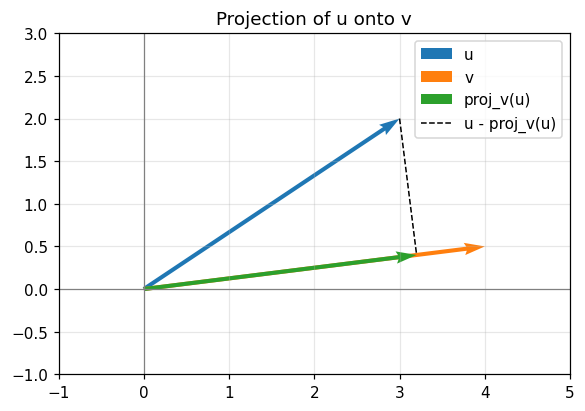

In [8]:
u_p = np.array([3.0, 2.0])
v_p = np.array([4.0, 0.5])

proj = la.vector_projection(u_p, v_p)
print(f"u = {u_p}")
print(f"v = {v_p}")
print(f"proj_v(u) = {proj}")

fig, ax = plt.subplots(figsize=(6, 5))
origin = np.array([0, 0])

def draw(vec, color, label):
    ax.quiver(*origin, *vec, angles="xy", scale_units="xy", scale=1,
               color=color, width=0.008, label=label)

draw(u_p, "tab:blue", "u")
draw(v_p, "tab:orange", "v")
draw(proj, "tab:green", "proj_v(u)")

# dashed line showing the perpendicular component (u - proj_v(u))
ax.plot([u_p[0], proj[0]], [u_p[1], proj[1]], "k--", linewidth=1, label="u - proj_v(u)")

all_pts = np.array([u_p, v_p, proj, origin])
ax.set_xlim(min(all_pts[:, 0].min(), 0) - 1, all_pts[:, 0].max() + 1)
ax.set_ylim(min(all_pts[:, 1].min(), 0) - 1, all_pts[:, 1].max() + 1)
ax.set_title("Projection of u onto v")
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_aspect("equal")
ax.legend()
plt.savefig("../figures/01_vector_projection.png", dpi=110, bbox_inches="tight")
plt.show()

The green arrow `proj_v(u)` lies exactly on the line through `v`, and the dashed line `u - proj_v(u)` is perpendicular to `v` — the defining property of an orthogonal projection.

## 1.6 Eigenvalues and Eigenvectors

$$Av = \lambda v$$

where $A$ is a (square) transformation matrix, $v$ is an eigenvector, and
$\lambda$ is its eigenvalue. An eigenvector is a direction that stays
**unchanged** under the linear transformation $A$, except for scaling:
applying $A$ to $v$ never rotates it into a new direction, it only stretches,
shrinks, and/or flips it. Every non-eigenvector direction, by contrast, is
generally both rotated and scaled by $A$.

The sign and magnitude of $\lambda$ describe exactly what that scaling does:
- $\lambda > 0$: $Av$ points in the **same** direction as $v$.
- $\lambda < 0$: $Av$ points in the **opposite** direction (reversed).
- $|\lambda|$: the factor by which $v$'s length is stretched ($|\lambda|>1$)
  or shrunk ($|\lambda|<1$).

**Why this matters for ML**: eigenvectors of a covariance matrix are the
directions of maximum variance in a dataset — this is exactly what PCA
(Part 5) uses to find the most informative axes for dimensionality
reduction. Eigen-decompositions also underlie spectral clustering and the
stability analysis of gradient descent.

In [9]:
S = np.array([[2.0, 1.0], [1.0, 2.0]])  # symmetric -> real eigenvalues/eigenvectors

eigenvalues, eigenvectors = np.linalg.eig(S)

print("S =\n", S)
print(f"\nEigenvalues: {eigenvalues}")
print("Eigenvectors (columns):\n", eigenvectors)

print("\nVerifying A v = lambda v for each eigenpair:")
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    vec = eigenvectors[:, i]
    lhs = S @ vec
    rhs = lam * vec
    print(f"  eigenvalue {lam:.4f}: A v = {lhs},  lambda v = {rhs},  "
          f"max diff = {np.max(np.abs(lhs - rhs)):.2e}")

S =
 [[2. 1.]
 [1. 2.]]

Eigenvalues: [3. 1.]
Eigenvectors (columns):
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Verifying A v = lambda v for each eigenpair:
  eigenvalue 3.0000: A v = [2.12132034 2.12132034],  lambda v = [2.12132034 2.12132034],  max diff = 0.00e+00
  eigenvalue 1.0000: A v = [-0.70710678  0.70710678],  lambda v = [-0.70710678  0.70710678],  max diff = 0.00e+00


**Isolating a single eigenvector.** To make the "no rotation, only scaling"
property as visually unambiguous as possible, the next cell picks a single
eigenvector $v$, computes $Av$ directly, and numerically verifies
$Av \approx \lambda v$ before plotting both vectors from the origin.

In [10]:
v1 = eigenvectors[:, 0]
lambda1 = eigenvalues[0]
v1_transformed = S @ v1

matches_prediction = np.allclose(v1_transformed, lambda1 * v1)
print(f"v                = {v1}")
print(f"A @ v            = {v1_transformed}")
print(f"lambda * v       = {lambda1 * v1}")
print(f"A @ v ~ lambda*v : {matches_prediction}")

v                = [0.70710678 0.70710678]
A @ v            = [2.12132034 2.12132034]
lambda * v       = [2.12132034 2.12132034]
A @ v ~ lambda*v : True


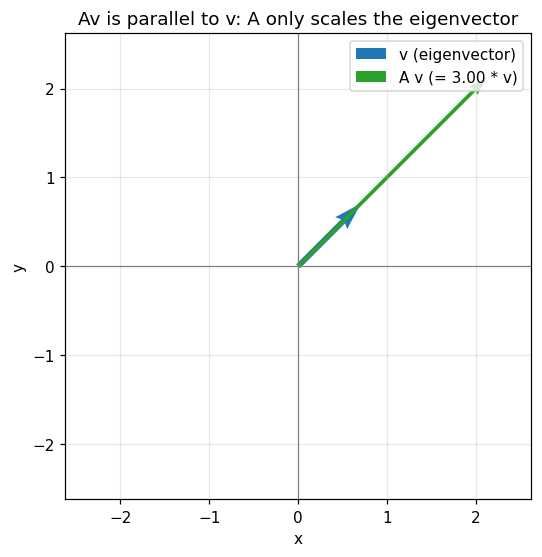

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.quiver(0, 0, *v1, angles="xy", scale_units="xy", scale=1,
           color="tab:blue", width=0.012, label="v (eigenvector)")
ax.quiver(0, 0, *v1_transformed, angles="xy", scale_units="xy", scale=1,
           color="tab:green", width=0.008, label=f"A v (= {lambda1:.2f} * v)")
lim = max(np.abs(v1_transformed).max(), np.abs(v1).max()) + 0.5
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect("equal")
ax.set_title("Av is parallel to v: A only scales the eigenvector")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.savefig("../figures/02_eigenvector_transform.png", dpi=110, bbox_inches="tight")
plt.show()

`A v` (green) lies exactly along the same line as `v` (blue), just scaled by $\lambda$ — the transformed vector has not been rotated into a new direction, confirming the defining property of an eigenvector geometrically as well as numerically.

## 1.7 Covariance Matrix

For a centered dataset $X_c$ (mean subtracted from each feature),

$$\Sigma = \frac{1}{n-1} X_c^T X_c$$

Each entry $\Sigma_{ij}$ measures how features $i$ and $j$ vary *together*:
positive means they tend to increase together, negative means one increases
as the other decreases, and the diagonal $\Sigma_{ii}$ is just the variance
of feature $i$. This matters for PCA because its eigenvectors point along
the directions where the data varies the most.

In [12]:
n_points = 200
# Correlated 2D data: x2 depends on x1 plus noise, so we expect visible correlation
x1 = np.random.normal(loc=5, scale=2.0, size=n_points)
x2 = 1.5 * x1 + np.random.normal(loc=0, scale=1.5, size=n_points)
X = np.column_stack([x1, x2])

mean_vec = X.mean(axis=0)
X_centered = X - mean_vec
cov_manual = la.covariance_matrix(X)
cov_numpy = np.cov(X, rowvar=False)

print(f"Mean: {mean_vec}")
print("\nCovariance matrix (manual, Xc^T Xc / (n-1)):\n", cov_manual)
print("\nCovariance matrix (np.cov):\n", cov_numpy)
print(f"\nMax abs difference: {np.max(np.abs(cov_manual - cov_numpy)):.2e}")

Mean: [4.91845807 7.50648938]

Covariance matrix (manual, Xc^T Xc / (n-1)):
 [[ 3.46707316  5.46290185]
 [ 5.46290185 10.77968812]]

Covariance matrix (np.cov):
 [[ 3.46707316  5.46290185]
 [ 5.46290185 10.77968812]]

Max abs difference: 0.00e+00


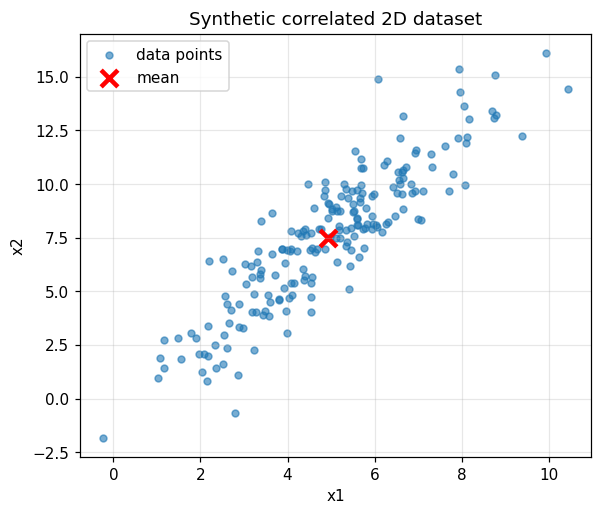

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], alpha=0.6, s=20, label="data points")
ax.scatter(*mean_vec, color="red", marker="x", s=120, linewidths=3, label="mean")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Synthetic correlated 2D dataset")
ax.legend()
plt.savefig("../figures/03_covariance_scatter.png", dpi=110, bbox_inches="tight")
plt.show()

The positive off-diagonal covariance value matches the visible upward trend in the scatter plot: as `x1` increases, `x2` tends to increase with it. This dataset and its covariance matrix will later provide the mathematical foundation for the PCA section (Part 5), whose principal component directions are exactly the eigenvectors of this covariance matrix.

## Covariance Comparison: Correlated vs. Approximately Uncorrelated Data

To make concrete what the covariance matrix is actually measuring, we
compare **Dataset A** (strong positive correlation, as above) against a
**Dataset B** in which the two variables vary independently of each other.

In [14]:
# Dataset A: strong positive correlation (reuses X from above)
mean_A, cov_A = X.mean(axis=0), la.covariance_matrix(X)

# Dataset B: x and y generated independently -> approximately uncorrelated.
# Uses a larger sample (n=1000) than Dataset A so its sample covariance is
# more reliably close to zero (small samples can show spurious correlation
# by chance even when the true underlying covariance is zero).
n_points_b = 1000
x_b = np.random.normal(loc=5, scale=2.0, size=n_points_b)
y_b = np.random.normal(loc=10, scale=2.0, size=n_points_b)  # independent of x_b
X_b = np.column_stack([x_b, y_b])
mean_B, cov_B = X_b.mean(axis=0), la.covariance_matrix(X_b)

print("Dataset A - mean:", mean_A)
print("Dataset A - covariance matrix:\n", cov_A)
print(f"\nDataset B - mean: {mean_B}")
print("Dataset B - covariance matrix:\n", cov_B)

Dataset A - mean: [4.91845807 7.50648938]
Dataset A - covariance matrix:
 [[ 3.46707316  5.46290185]
 [ 5.46290185 10.77968812]]

Dataset B - mean: [ 5.07622823 10.05701413]
Dataset B - covariance matrix:
 [[ 3.99217107 -0.16074668]
 [-0.16074668  3.87069918]]


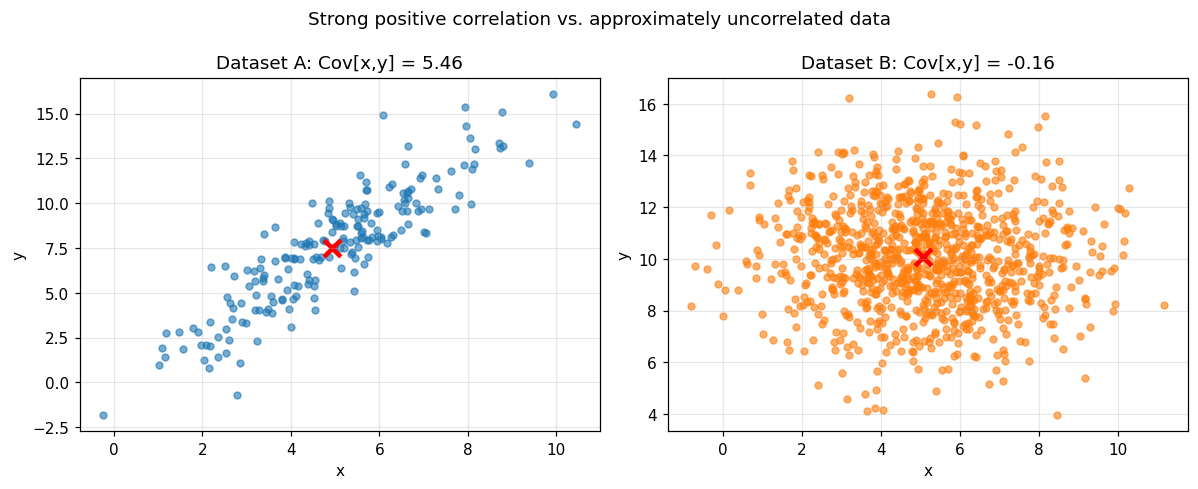

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(X[:, 0], X[:, 1], alpha=0.6, s=20, color="tab:blue")
axes[0].scatter(*mean_A, color="red", marker="x", s=120, linewidths=3)
axes[0].set_title(f"Dataset A: Cov[x,y] = {cov_A[0,1]:.2f}")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

axes[1].scatter(X_b[:, 0], X_b[:, 1], alpha=0.6, s=20, color="tab:orange")
axes[1].scatter(*mean_B, color="red", marker="x", s=120, linewidths=3)
axes[1].set_title(f"Dataset B: Cov[x,y] = {cov_B[0,1]:.2f}")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

fig.suptitle("Strong positive correlation vs. approximately uncorrelated data")
plt.tight_layout()
plt.savefig("../figures/04_covariance_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

**Interpretation.**
- **Dataset A**: a large positive off-diagonal covariance quantifies the
  clear upward trend visible in the scatter plot — the variables tend to
  increase together.
- **Dataset B**: the off-diagonal covariance is close to zero, matching the
  visually shapeless scatter — there is little *linear* co-variation
  between the variables.

**Important caveat.** Zero (or near-zero) covariance indicates the absence
of a *linear* relationship; it does **not** generally imply statistical
independence — two variables can be strongly related in a nonlinear way
(e.g. $y = x^2$ over a symmetric range) and still have zero covariance.
Here, `x_b` and `y_b` actually were generated independently, so both the
low linear correlation *and* the (stronger claim of) independence hold by
construction — but covariance alone only ever certifies the former.

The covariance matrix summarizes exactly these pairwise relationships
between variables, and it provides the mathematical structure that PCA
(Part 5) uses to identify the directions of maximum variance in a
dataset — via the eigenvectors of this same matrix.

## Validation of Core Implementations

Before building further sections on top of this linear-algebra foundation,
we collect lightweight sanity checks confirming that every manually
implemented operation above agrees with an independent reference
computation, and that invalid inputs are rejected rather than silently
mishandled.

In [16]:
# --- 1. Vector addition ---
a, b = np.array([1.0, 2.0, 3.0]), np.array([4.0, -1.0, 2.0])
assert np.allclose(la.vector_add(a, b), np.array([a[i] + b[i] for i in range(len(a))]))

# --- 2. Scalar multiplication (vector) ---
assert np.allclose(la.scalar_multiply(3.0, a), np.array([3.0 * ai for ai in a]))

# --- 3. Dot product ---
assert np.isclose(la.manual_dot_product(a, b), np.dot(a, b))

# --- 4. Vector norm ---
assert np.isclose(la.vector_norm(a), np.linalg.norm(a))

# --- 5. Matrix addition ---
M1, M2 = np.array([[1.0, 2.0], [3.0, 4.0]]), np.array([[5.0, 1.0], [0.0, 2.0]])
assert np.allclose(la.matrix_add(M1, M2), M1 + M2)

# --- 6. Matrix scalar multiplication ---
assert np.allclose(la.matrix_scalar_multiply(2.0, M1), 2.0 * M1)

# --- 7. Matrix transpose ---
assert np.allclose(la.matrix_transpose(M1), M1.T)

# --- 8. Matrix multiplication ---
assert np.allclose(la.manual_matmul(M1, M2), M1 @ M2)

# --- 9. Vector projection ---
u_t, v_t = np.array([3.0, 2.0]), np.array([4.0, 0.5])
expected_proj = (np.dot(u_t, v_t) / np.dot(v_t, v_t)) * v_t
assert np.allclose(la.vector_projection(u_t, v_t), expected_proj)

# --- 10. Cosine similarity ---
expected_cos = np.dot(u_t, v_t) / (np.linalg.norm(u_t) * np.linalg.norm(v_t))
assert np.isclose(la.cosine_similarity(u_t, v_t), expected_cos)

# --- Edge cases ---
assert np.isclose(la.vector_norm(la.normalize(a)), 1.0)  # normalization of a non-zero vector
assert np.allclose(la.normalize(a), a / np.linalg.norm(a))  # normalization agrees with NumPy reference

try:
    la.vector_add(np.array([1.0, 2.0]), np.array([1.0, 2.0, 3.0]))  # incompatible shapes
    raise AssertionError("Expected a ValueError for incompatible vector shapes.")
except ValueError:
    pass

try:
    la.cosine_similarity(np.array([0.0, 0.0]), np.array([1.0, 1.0]))  # zero vector
    raise AssertionError("Expected a ValueError for cosine similarity with a zero vector.")
except ValueError:
    pass

print("All core validation tests passed.")

All core validation tests passed.


---
# 2. Calculus & Optimization

Linear algebra (Part 1) gave us the objects machine learning operates on:
vectors, matrices, and the geometric relationships between them. This
section introduces the second pillar - calculus - which answers a
different question: **given a model's current parameters, in which
direction should they change to reduce error?** That question is answered
entirely by derivatives and gradients, and answering it iteratively is
exactly what gradient descent does.

## 2.1 Why Calculus Matters in Machine Learning

Training a machine learning model can be framed as an optimization
problem:

1. A model makes predictions from its current parameters.
2. A **loss function** measures how wrong those predictions are.
3. **Calculus** determines how the loss changes with respect to each
   parameter (its local sensitivity).
4. **Optimization** uses that sensitivity information to update the
   parameters.
5. Repeating this process searches for parameters that make the loss
   small.

$$
\text{Parameters} \rightarrow \text{Model} \rightarrow \text{Predictions}
\rightarrow \text{Loss} \rightarrow \text{Gradient} \rightarrow
\text{Parameter Update} \rightarrow \text{Lower Loss}
$$

This section develops that pipeline using a generic mathematical function,
without yet committing to a specific model such as linear or logistic
regression - those follow in later parts, once this machinery is in
place.

In [17]:
import sys
sys.path.insert(0, "../src")
import optimization as opt

print("optimization module loaded:", [f for f in dir(opt) if not f.startswith("_")])

optimization module loaded: ['gradient_descent_1d', 'gradient_descent_2d', 'np', 'numerical_derivative', 'numerical_gradient', 'partial_derivative']


## 2.2 Derivatives

For $f(x) = x^2$, the derivative describes the instantaneous rate of
change of $f$ with respect to $x$:

$$\frac{df}{dx} = 2x$$

- **Positive derivative**: $f$ is increasing at that point.
- **Negative derivative**: $f$ is decreasing at that point.
- **Zero derivative**: $f$ is momentarily flat (a *stationary point*) - for
  $f(x)=x^2$ this occurs only at $x=0$, which happens to be the global
  minimum, but a zero derivative does not in general guarantee a minimum
  (it could also be a maximum or a saddle/inflection point).

In [18]:
def f_square(x):
    return x ** 2

def analytical_derivative_square(x):
    return 2 * x

test_points = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])

print(f"{'x':>6} | {'f(x)':>8} | {"f'(x)":>8} | sign")
for x in test_points:
    d = analytical_derivative_square(x)
    sign = "increasing" if d > 0 else ("decreasing" if d < 0 else "stationary")
    print(f"{x:6.1f} | {f_square(x):8.2f} | {d:8.2f} | {sign}")

     x |     f(x) |    f'(x) | sign
  -2.0 |     4.00 |    -4.00 | decreasing
  -1.0 |     1.00 |    -2.00 | decreasing
   0.0 |     0.00 |     0.00 | stationary
   1.0 |     1.00 |     2.00 | increasing
   2.0 |     4.00 |     4.00 | increasing


**Numerical derivative.** Independently of the analytical formula, the
derivative can be *approximated* using the central finite-difference rule:

$$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$$

for small $h$. This connects the symbolic calculus above to a numerical
computation that would work even for functions with no convenient closed
form - which is exactly the technique later used to validate the
analytical formulas throughout this section.

In [19]:
print(f"{'x':>6} | {'analytical':>12} | {'numerical':>12} | {'abs error':>12}")
for x in test_points:
    analytical = analytical_derivative_square(x)
    numerical = opt.numerical_derivative(f_square, x)
    print(f"{x:6.1f} | {analytical:12.6f} | {numerical:12.6f} | {abs(analytical - numerical):12.2e}")

     x |   analytical |    numerical |    abs error
  -2.0 |    -4.000000 |    -4.000000 |     2.62e-11
  -1.0 |    -2.000000 |    -2.000000 |     2.00e-12
   0.0 |     0.000000 |     0.000000 |     0.00e+00
   1.0 |     2.000000 |     2.000000 |     2.00e-12
   2.0 |     4.000000 |     4.000000 |     2.62e-11


The numerical approximation matches the analytical derivative to within floating-point/truncation error at every test point ($h=10^{-5}$), confirming both that the analytical formula $2x$ is correct and that the finite-difference implementation is valid.

## 2.3 Partial Derivatives

For a two-variable function such as

$$f(x,y) = x^2 + 2y^2$$

a **partial derivative** measures the rate of change with respect to one
variable while holding the other fixed:

$$\frac{\partial f}{\partial x} = 2x \qquad \frac{\partial f}{\partial y} = 4y$$

In [20]:
def f_quadratic(x, y):
    return x ** 2 + 2 * y ** 2

def analytical_partial_x(x, y):
    return 2 * x

def analytical_partial_y(x, y):
    return 4 * y

point = (2.0, 1.0)
df_dx_analytical = analytical_partial_x(*point)
df_dy_analytical = analytical_partial_y(*point)

print(f"f{point} = {f_quadratic(*point)}")
print(f"df/dx at {point} (analytical) = {df_dx_analytical}")
print(f"df/dy at {point} (analytical) = {df_dy_analytical}")

f(2.0, 1.0) = 6.0
df/dx at (2.0, 1.0) (analytical) = 4.0
df/dy at (2.0, 1.0) (analytical) = 4.0


In [21]:
df_dx_numerical = opt.partial_derivative(f_quadratic, point, index=0)
df_dy_numerical = opt.partial_derivative(f_quadratic, point, index=1)

print(f"df/dx at {point}: analytical = {df_dx_analytical:.6f}, "
      f"numerical = {df_dx_numerical:.6f}, diff = {abs(df_dx_analytical - df_dx_numerical):.2e}")
print(f"df/dy at {point}: analytical = {df_dy_analytical:.6f}, "
      f"numerical = {df_dy_numerical:.6f}, diff = {abs(df_dy_analytical - df_dy_numerical):.2e}")

df/dx at (2.0, 1.0): analytical = 4.000000, numerical = 4.000000, diff = 2.62e-11
df/dy at (2.0, 1.0): analytical = 4.000000, numerical = 4.000000, diff = 2.62e-11


Holding $y$ fixed at $1$, $f$ changes at rate $2x=4$ per unit $x$ at this point; holding $x$ fixed at $2$, $f$ changes at rate $4y=4$ per unit $y$. Both numerical estimates agree with the analytical values to within finite-difference precision.

## 2.4 Gradient

The **gradient** of a scalar-valued function is the vector containing all
of its partial derivatives:

$$
\nabla f(x,y) =
\begin{bmatrix} \partial f/\partial x \\ \partial f/\partial y \end{bmatrix}
=
\begin{bmatrix} 2x \\ 4y \end{bmatrix}
$$

**Key property**: the gradient $\nabla f$ points in the direction of
**steepest increase** of $f$ at that point. Consequently:

- $\nabla f$ &nbsp;→ direction of steepest **ascent**
- $-\nabla f$ → direction of steepest **descent** (locally)

This is precisely why optimization moves parameters in the direction of
the *negative* gradient: it is the direction that decreases the function
value fastest, at least locally.

In [22]:
def analytical_gradient_quadratic(x, y):
    return np.array([analytical_partial_x(x, y), analytical_partial_y(x, y)])

grad_analytical = analytical_gradient_quadratic(*point)
grad_numerical = opt.numerical_gradient(f_quadratic, point)

print(f"Analytical gradient at {point}: {grad_analytical}")
print(f"Numerical gradient at {point}:  {grad_numerical}")
print(f"Max abs difference: {np.max(np.abs(grad_analytical - grad_numerical)):.2e}")

Analytical gradient at (2.0, 1.0): [4. 4.]
Numerical gradient at (2.0, 1.0):  [4. 4.]
Max abs difference: 2.62e-11


### Gradient Field Visualization

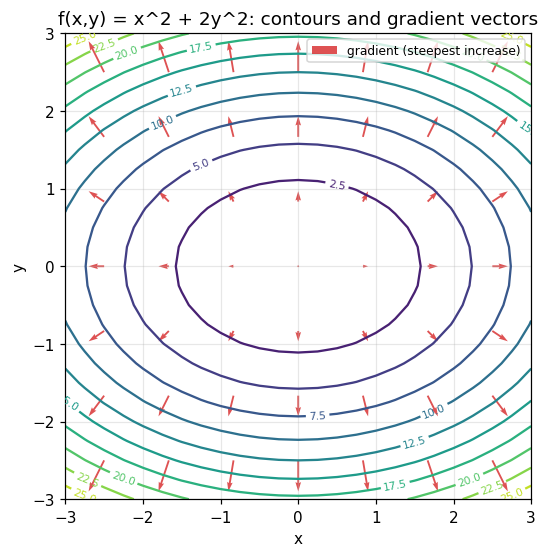

In [23]:
grid = np.linspace(-3, 3, 25)
Xg, Yg = np.meshgrid(grid, grid)
Zg = f_quadratic(Xg, Yg)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
contour = ax.contour(Xg, Yg, Zg, levels=12, cmap="viridis")
ax.clabel(contour, inline=True, fontsize=7)

# Sample a coarser grid of points to overlay gradient vectors
sample = np.linspace(-2.5, 2.5, 7)
Xs, Ys = np.meshgrid(sample, sample)
Gx = analytical_partial_x(Xs, Ys)
Gy = analytical_partial_y(Xs, Ys)

ax.quiver(Xs, Ys, Gx, Gy, color="tab:red", alpha=0.8,
          angles="xy", scale_units="xy", scale=25, width=0.004,
          label="gradient (steepest increase)")

ax.set_title("f(x,y) = x^2 + 2y^2: contours and gradient vectors")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=8)
plt.savefig("../figures/05_gradient_field.png", dpi=110, bbox_inches="tight")
plt.show()

Every red arrow points **away** from the origin, toward increasing contour values - confirming $\nabla f$ points toward steeper $f$. The negative gradient $-\nabla f$ at each of those same points would point in exactly the opposite direction, i.e. back toward the origin, which is the minimum of this function. Gradient descent (Section 2.6) follows exactly that negative-gradient direction.

## 2.5 Loss Functions

A **loss function** maps a model's prediction (or, more abstractly here,
a parameter value) to a numerical measure of error. As a simple
one-dimensional example, independent of any specific ML model:

$$L(w) = (w-3)^2 \qquad \frac{dL}{dw} = 2(w-3)$$

This has a minimum at $w=3$, where $L(3)=0$ and $dL/dw=0$.

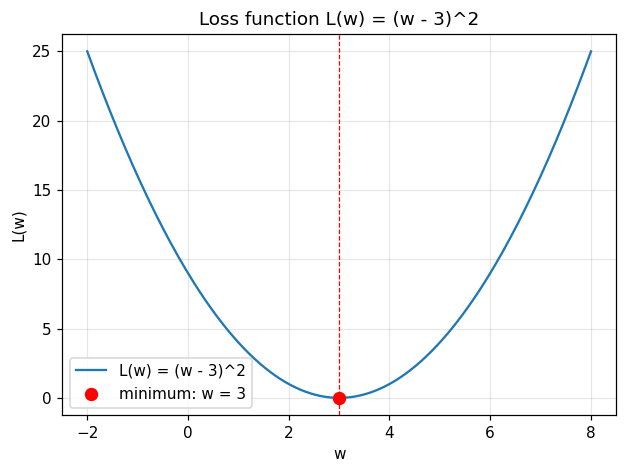

In [24]:
def L(w):
    return (w - 3) ** 2

def dL_dw(w):
    return 2 * (w - 3)

w_range = np.linspace(-2, 8, 200)
loss_values = L(w_range)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(w_range, loss_values, color="tab:blue", label="L(w) = (w - 3)^2")
ax.scatter([3], [L(3)], color="red", zorder=5, s=60, label="minimum: w = 3")
ax.axvline(3, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Loss function L(w) = (w - 3)^2")
ax.set_xlabel("w")
ax.set_ylabel("L(w)")
ax.legend()
plt.savefig("../figures/06_loss_function.png", dpi=110, bbox_inches="tight")
plt.show()

In [25]:
for w in [0.0, 2.0, 2.99, 3.0, 3.01, 4.0, 6.0]:
    d = dL_dw(w)
    if d > 0:
        note = "positive -> decreasing w reduces the loss"
    elif d < 0:
        note = "negative -> increasing w reduces the loss"
    else:
        note = "zero -> stationary point"
    print(f"w = {w:5.2f} : dL/dw = {d:6.2f}  ({note})")

w =  0.00 : dL/dw =  -6.00  (negative -> increasing w reduces the loss)
w =  2.00 : dL/dw =  -2.00  (negative -> increasing w reduces the loss)
w =  2.99 : dL/dw =  -0.02  (negative -> increasing w reduces the loss)
w =  3.00 : dL/dw =   0.00  (zero -> stationary point)
w =  3.01 : dL/dw =   0.02  (positive -> decreasing w reduces the loss)
w =  4.00 : dL/dw =   2.00  (positive -> decreasing w reduces the loss)
w =  6.00 : dL/dw =   6.00  (positive -> decreasing w reduces the loss)


The derivative is negative for $w<3$ (loss decreases as $w$ increases toward 3) and positive for $w>3$ (loss decreases as $w$ decreases toward 3), consistent with $w=3$ being a minimum. Note that this conclusion relies on checking the *sign pattern* around the stationary point - in general, $dL/dw=0$ alone identifies only a stationary point, not automatically a minimum.

## 2.6 Gradient Descent From Scratch

**Update rule:**

$$w_{\text{new}} = w_{\text{old}} - \eta \cdot \frac{dL}{dw}\Big|_{w_{\text{old}}}$$

- $w$: the parameter being optimized.
- $\eta$ (eta): the **learning rate**, controlling the step size.
- $dL/dw$: the gradient (here, an ordinary derivative since $L$ has one
  parameter), giving the direction of steepest increase - so subtracting
  it moves $w$ toward decreasing loss.

Starting from $w_0 = -4$ with $\eta = 0.1$:

In [26]:
history = opt.gradient_descent_1d(
    grad_fn=dL_dw, loss_fn=L, w0=-4.0, learning_rate=0.1, n_iterations=50
)

print(f"Initial w = {history['w'][0]:.4f}, initial loss = {history['loss'][0]:.4f}")
print(f"Final w   = {history['final_w']:.6f}, final loss  = {history['loss'][-1]:.6f}")
print(f"Iterations run: {len(history['iteration'])}, diverged: {history['diverged']}")

Initial w = -4.0000, initial loss = 49.0000
Final w   = 2.999900, final loss  = 0.000000
Iterations run: 50, diverged: False


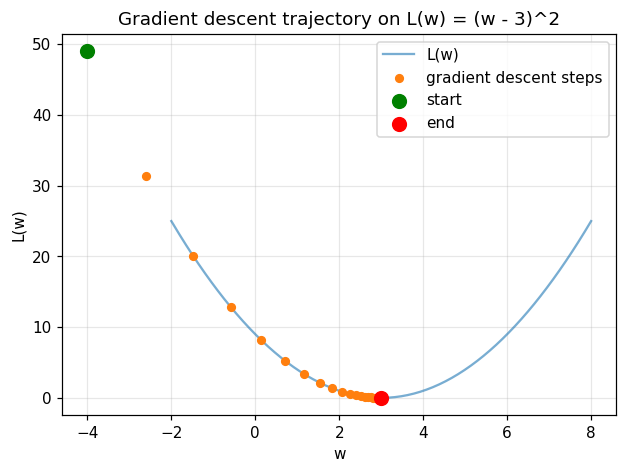

In [27]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(w_range, L(w_range), color="tab:blue", alpha=0.6, label="L(w)")
ax.scatter(history["w"], history["loss"], color="tab:orange", s=25, zorder=5,
           label="gradient descent steps")
ax.scatter(history["w"][0], history["loss"][0], color="green", s=80, zorder=6, label="start")
ax.scatter(history["w"][-1], history["loss"][-1], color="red", s=80, zorder=6, label="end")
ax.set_title("Gradient descent trajectory on L(w) = (w - 3)^2")
ax.set_xlabel("w")
ax.set_ylabel("L(w)")
ax.legend()
plt.savefig("../figures/07_gd_trajectory.png", dpi=110, bbox_inches="tight")
plt.show()

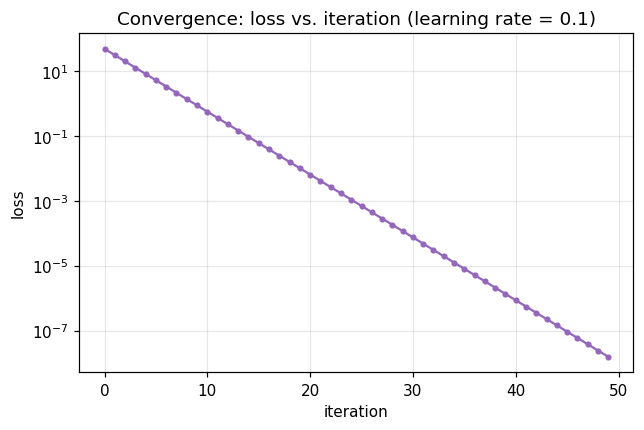

In [28]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.plot(history["iteration"], history["loss"], color="tab:purple", marker="o", markersize=3)
ax.set_title("Convergence: loss vs. iteration (learning rate = 0.1)")
ax.set_xlabel("iteration")
ax.set_ylabel("loss")
ax.set_yscale("log")
plt.savefig("../figures/08_gd_convergence.png", dpi=110, bbox_inches="tight")
plt.show()

The trajectory (orange points) moves monotonically from the starting point toward the minimum, and the loss-vs-iteration plot (log scale) shows the characteristic geometric decay of gradient descent on a quadratic loss.

## 2.7 Learning Rate and Convergence

For this quadratic loss, the update rule can be written in closed form.
Substituting $dL/dw = 2(w-3)$ into the update rule:

$$w_{k+1} = w_k - \eta \cdot 2(w_k - 3) = (1-2\eta)\,w_k + 6\eta$$

This is a linear recurrence with contraction factor $(1-2\eta)$: the
sequence converges to $w=3$ if and only if $|1-2\eta| < 1$, i.e.
$0 < \eta < 1$ **for this specific function**. This closed form lets us
predict - rather than just observe - the qualitative behavior of each
learning rate below before running the experiment.

In [29]:
learning_rates = [0.01, 0.1, 0.5]
results = []

for lr in learning_rates:
    h = opt.gradient_descent_1d(dL_dw, L, w0=-4.0, learning_rate=lr, n_iterations=200)
    results.append((lr, h))
    contraction = abs(1 - 2 * lr)
    print(f"eta = {lr:<5} contraction factor |1-2*eta| = {contraction:.2f} "
          f"-> final w = {h['final_w']:.6f}, final loss = {h['loss'][-1]:.2e}, "
          f"iterations used = {len(h['iteration'])}")

eta = 0.01  contraction factor |1-2*eta| = 0.98 -> final w = 2.876884, final loss = 1.58e-02, iterations used = 200
eta = 0.1   contraction factor |1-2*eta| = 0.80 -> final w = 3.000000, final loss = 7.89e-31, iterations used = 200
eta = 0.5   contraction factor |1-2*eta| = 0.00 -> final w = 3.000000, final loss = 0.00e+00, iterations used = 200


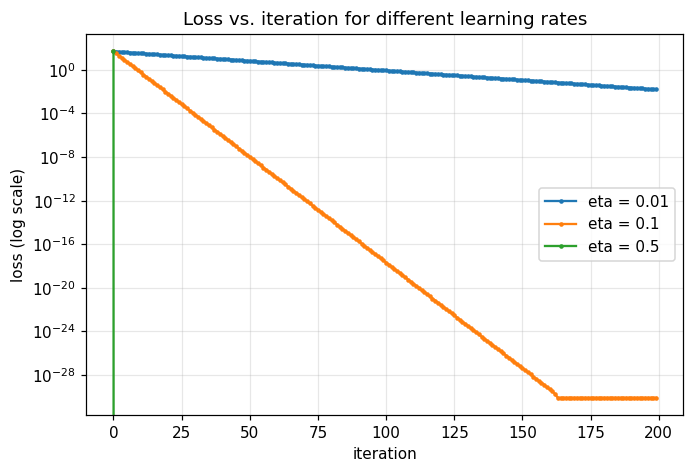

In [30]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for lr, h in results:
    ax.plot(h["iteration"], h["loss"], marker="o", markersize=2, label=f"eta = {lr}")
ax.set_yscale("log")
ax.set_title("Loss vs. iteration for different learning rates")
ax.set_xlabel("iteration")
ax.set_ylabel("loss (log scale)")
ax.legend()
plt.savefig("../figures/09_learning_rate_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

- **eta = 0.01** (small): the contraction factor $0.98$ is close to $1$,
  so each step shrinks the loss only slightly - many iterations are needed.
- **eta = 0.1** (moderate): factor $0.8$ gives comfortably fast, stable
  convergence.
- **eta = 0.5**: factor $|1-2(0.5)| = 0$ - the update lands **exactly** on
  $w=3$ after a single step for this particular quadratic. This is a
  useful counterexample to the common claim that a "large" learning rate
  is automatically bad: whether a given $\eta$ is too small, appropriate,
  or too large depends on the curvature of the specific objective
  function, not on the raw numerical value of $\eta$ alone.

### An unstable case

Since convergence for this function requires $0 < \eta < 1$, choosing
$\eta$ outside that range should diverge. We test $\eta = 1.2$
(contraction factor $|1-2(1.2)| = 1.4 > 1$) to confirm this prediction
rather than asserting it without evidence.

In [31]:
unstable_lr = 1.2
h_unstable = opt.gradient_descent_1d(dL_dw, L, w0=-4.0, learning_rate=unstable_lr,
                                      n_iterations=15, divergence_threshold=150)
results.append((unstable_lr, h_unstable))

print(f"eta = {unstable_lr} (predicted contraction factor "
      f"{abs(1 - 2*unstable_lr):.2f} > 1 -> expected to diverge)\n")
for it, w, loss in zip(h_unstable["iteration"], h_unstable["w"], h_unstable["loss"]):
    print(f"  iteration {it:2d}: w = {w:14.4f}   loss = {loss:14.4f}")
print(f"\ndiverged flag: {h_unstable['diverged']}")

eta = 1.2 (predicted contraction factor 1.40 > 1 -> expected to diverge)

  iteration  0: w =        -4.0000   loss =        49.0000
  iteration  1: w =        12.8000   loss =        96.0400
  iteration  2: w =       -10.7200   loss =       188.2384
  iteration  3: w =        22.2080   loss =       368.9473
  iteration  4: w =       -23.8912   loss =       723.1366
  iteration  5: w =        40.6477   loss =      1417.3478
  iteration  6: w =       -49.7068   loss =      2778.0017
  iteration  7: w =        76.7895   loss =      5444.8833
  iteration  8: w =      -100.3052   loss =     10671.9714
  iteration  9: w =       147.6273   loss =     20917.0639
  iteration 10: w =      -199.4783   loss =     40997.4452

diverged flag: True


As predicted analytically, $\eta=1.2$ produces a diverging, oscillating sequence rather than converging - confirming that gradient descent does **not** converge for every learning rate, and that this particular value is unstable *for this function*, not unstable in some universal sense.

In [32]:
experiment_table = pd.DataFrame([
    {
        "Learning Rate": lr,
        "Initial Parameter": h["w"][0],
        "Final Parameter": h["final_w"],
        "Final Loss": h["loss"][-1],
        "Iterations": len(h["iteration"]),
        "Converged?": (not h["diverged"]) and abs(h["final_w"] - 3.0) < 1e-3,
    }
    for lr, h in results
])
experiment_table

   Learning Rate  Initial Parameter  ...  Iterations  Converged?
0           0.01               -4.0  ...         200       False
1           0.10               -4.0  ...         200        True
2           0.50               -4.0  ...         200        True
3           1.20               -4.0  ...          11       False

[4 rows x 6 columns]

## 2.8 Multivariable Gradient Descent

Extending from one parameter to two, using the same
$f(x,y) = x^2 + 2y^2$ and its gradient $\nabla f = [2x,\ 4y]$:

$$x_{\text{new}} = x_{\text{old}} - \eta(2x_{\text{old}}) \qquad
y_{\text{new}} = y_{\text{old}} - \eta(4y_{\text{old}})$$

By the same contraction-factor argument as Section 2.7 (applied
independently to each coordinate), convergence for both coordinates
simultaneously requires $0 < \eta < 0.5$ (the stricter of $|1-2\eta|<1$
and $|1-4\eta|<1$). We use $\eta=0.1$, starting from $(x_0,y_0)=(4,3)$.

In [33]:
def grad_quadratic_2d(x, y):
    return (2 * x, 4 * y)

history_2d = opt.gradient_descent_2d(
    grad_fn=grad_quadratic_2d, func=f_quadratic, start=(4.0, 3.0),
    learning_rate=0.1, n_iterations=60
)

print(f"Start: (x, y) = ({history_2d['x'][0]:.4f}, {history_2d['y'][0]:.4f}), "
      f"f = {history_2d['f'][0]:.4f}")
print(f"End:   (x, y) = {history_2d['final_point']}, f = {history_2d['f'][-1]:.6f}")
print(f"Iterations used: {len(history_2d['iteration'])}, diverged: {history_2d['diverged']}")

Start: (x, y) = (4.0000, 3.0000), f = 34.0000
End:   (x, y) = (6.129982163463559e-06, 1.466210339420674e-13), f = 0.000000
Iterations used: 60, diverged: False


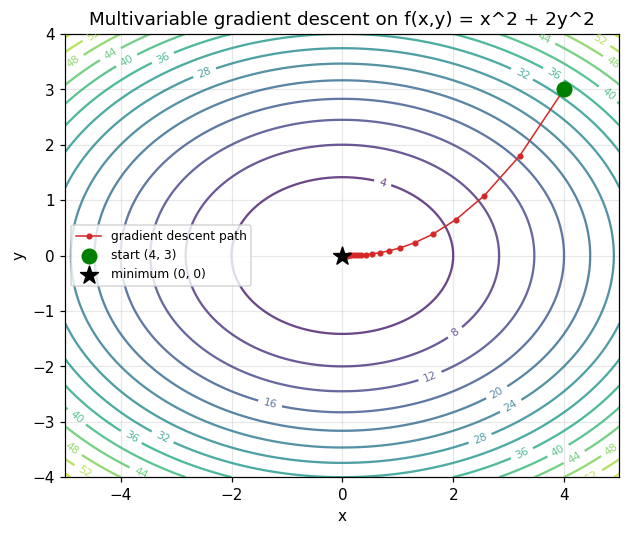

In [34]:
Xg2, Yg2 = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-4, 4, 200))
Zg2 = f_quadratic(Xg2, Yg2)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
contour = ax.contour(Xg2, Yg2, Zg2, levels=15, cmap="viridis", alpha=0.8)
ax.clabel(contour, inline=True, fontsize=7)
ax.plot(history_2d["x"], history_2d["y"], "o-", color="tab:red", markersize=3,
         linewidth=1, label="gradient descent path")
ax.scatter(history_2d["x"][0], history_2d["y"][0], color="green", s=90, zorder=5, label="start (4, 3)")
ax.scatter(0, 0, color="black", marker="*", s=150, zorder=5, label="minimum (0, 0)")
ax.set_title("Multivariable gradient descent on f(x,y) = x^2 + 2y^2")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.legend(fontsize=8)
plt.savefig("../figures/10_gd_2d_trajectory.png", dpi=110, bbox_inches="tight")
plt.show()

The path curves rather than moving in a straight line toward $(0,0)$: because $\partial f/\partial y = 4y$ has a steeper coefficient than $\partial f/\partial x = 2x$, the $y$-coordinate is pulled toward $0$ faster than the $x$-coordinate at every shared step size $\eta$. The gradient direction at each point depends on *both* coordinates simultaneously, so the path bends as their relative distances to the minimum change.

## 2.9 Computational Perspective

- **Cost per iteration**: computing the analytical gradient here is
  $O(d)$ for $d$ parameters (one arithmetic expression per coordinate);
  the numerical finite-difference gradient used for validation costs
  $O(d)$ function evaluations, each itself costing whatever evaluating
  $f$ costs - so numerical gradients are considerably more expensive than
  analytical ones and are used here only to *validate* the closed-form
  derivatives, not to drive the optimization itself.
- **Number of iterations**: governed by the contraction factor for a
  given function/learning-rate pair (Section 2.7); slow convergence means
  many cheap iterations, while an unstable learning rate can fail to
  converge in any number of iterations.
- **Convergence tolerance**: in practice, gradient descent is stopped once
  the loss (or gradient magnitude, or parameter change) drops below some
  small tolerance, rather than running a fixed iteration count forever.
- **Numerical precision**: finite-difference derivatives depend on the
  step size $h$ - too large introduces truncation error, too small
  introduces floating-point cancellation error - which is why the
  analytical derivative is preferred whenever it is available, with the
  numerical version reserved for validation.
- **Scaling up**: real machine learning models have thousands to billions
  of parameters, so efficiently and exactly computing gradients (rather
  than the $O(d)$-function-evaluation finite-difference approach used
  here for validation) becomes essential. Later sections will use these
  same optimization ideas — gradients and the update rule
  $\theta \leftarrow \theta - \eta\nabla L$ — to train machine-learning
  models.

## 2.10 Validation and Experiments

Lightweight checks confirming the analytical formulas, numerical
approximations, and optimization results above are mutually consistent.

In [35]:
# --- Analytical vs numerical derivative, f(x) = x^2, several x values ---
for x in [-3.0, -1.5, 0.0, 0.5, 2.0, 4.5]:
    assert np.isclose(
        analytical_derivative_square(x), opt.numerical_derivative(f_square, x), atol=1e-4
    )

# --- Analytical vs numerical partial derivatives, f(x,y) = x^2 + 2y^2 ---
for pt in [(2.0, 1.0), (-1.0, 3.0), (0.0, 0.0)]:
    assert np.isclose(analytical_partial_x(*pt), opt.partial_derivative(f_quadratic, pt, 0), atol=1e-4)
    assert np.isclose(analytical_partial_y(*pt), opt.partial_derivative(f_quadratic, pt, 1), atol=1e-4)
    assert np.allclose(
        analytical_gradient_quadratic(*pt), opt.numerical_gradient(f_quadratic, pt), atol=1e-4
    )

# --- Gradient descent (1D) reduces the loss and reaches the known minimum ---
h_check = opt.gradient_descent_1d(dL_dw, L, w0=-4.0, learning_rate=0.1, n_iterations=100)
assert h_check["loss"][-1] < h_check["loss"][0]
assert np.isclose(h_check["final_w"], 3.0, atol=1e-2)

# --- Multivariable gradient descent reaches the known minimum (0, 0) ---
assert history_2d["f"][-1] < history_2d["f"][0]
final_x, final_y = history_2d["final_point"]
assert np.isclose(final_x, 0.0, atol=1e-2)
assert np.isclose(final_y, 0.0, atol=1e-2)

# --- The eta = 0.5 special case converges in exactly one step ---
h_half = opt.gradient_descent_1d(dL_dw, L, w0=-4.0, learning_rate=0.5, n_iterations=5)
assert np.isclose(h_half["w"][1], 3.0, atol=1e-8)

# --- The eta = 1.2 case is confirmed unstable, not silently ignored ---
assert h_unstable["diverged"] or abs(h_unstable["w"][-1] - 3.0) > 1.0

print("All Part 2 validation tests passed.")

All Part 2 validation tests passed.


---
### From Calculus to Machine Learning

$$
\text{Linear Algebra} \rightarrow \text{Represent data and parameters}
$$
$$
\text{Calculus} \rightarrow \text{Measure how the objective changes}
$$
$$
\text{Gradient} \rightarrow \text{Direction of steepest increase}
$$
$$
\text{Negative Gradient} \rightarrow \text{Direction of local decrease}
$$
$$
\text{Gradient Descent} \rightarrow \text{Iteratively update parameters}
$$
$$
\text{Machine Learning} \rightarrow \text{Optimize model parameters to reduce loss}
$$

The next part applies this same optimization machinery - a loss function,
its gradient, and the update rule $\theta \leftarrow \theta -
\eta\nabla L(\theta)$ - to an actual machine-learning model: linear
regression.

---
# 3. Linear Regression From Scratch

Parts 1 and 2 built the mathematical machinery - vectors, matrices, matrix
multiplication, derivatives, gradients, and gradient descent - without
committing to a specific model. This section applies that machinery to
answer a concrete question:

**How can linear algebra and gradient-based optimization be used to learn
a relationship between input variables and a continuous target?**

## 3.1 What Is Linear Regression?

Linear regression models the relationship between an input and a
continuous target using a linear function. In the simplest case, with one
feature:

$$\hat{y} = wx + b$$

- $w$: weight (slope) - how much $\hat{y}$ changes per unit of $x$.
- $b$: bias (intercept) - the predicted value when $x=0$.
- $x$: the observed input.
- $y$: the observed target (ground truth).
- $\hat{y}$: the model's **prediction**, distinct from the observed $y$.

The objective is to learn $w$ and $b$ such that $\hat{y}$ is close to $y$
across the observed data - "close" will be made precise by the MSE loss
in Section 3.4.

## 3.2 Mathematical Model

The scalar form $\hat{y}=wx+b$ generalizes directly to multiple features
using the matrix multiplication from Part 1:

$$\hat{y} = Xw + b$$

where:
- $X \in \mathbb{R}^{n \times d}$: feature matrix ($n$ samples, $d$ features).
- $w \in \mathbb{R}^{d}$: weight vector (one weight per feature).
- $b \in \mathbb{R}$: scalar bias, broadcast across all $n$ predictions.
- $\hat{y} \in \mathbb{R}^{n}$: prediction vector.

For $d=1$, $X$ is an $(n,1)$ column vector and $Xw$ reduces to $wx$
elementwise, so this is exactly the same model as Section 3.1, just
expressed with matrix multiplication so it generalizes to $d>1$ features
without changing the implementation - this is precisely why Part 1
introduced matrix multiplication as a foundation.

In [36]:
X_demo = np.array([[1.0], [2.0], [3.0]])   # n=3 samples, d=1 feature
w_demo = np.array([2.0])                    # d=1 weight
b_demo = 1.0

y_hat_demo = X_demo @ w_demo + b_demo

print(f"X shape = {X_demo.shape}   (n={X_demo.shape[0]}, d={X_demo.shape[1]})")
print(f"w shape = {w_demo.shape}")
print(f"y_hat shape = {y_hat_demo.shape}")
print(f"X @ w + b =\n{y_hat_demo}")

X shape = (3, 1)   (n=3, d=1)
w shape = (1,)
y_hat shape = (3,)
X @ w + b =
[3. 5. 7.]


Matrix multiplication computes all $n$ predictions in a single expression, `X @ w + b`, instead of looping over samples - the same `manual_matmul`-equivalent operation from Part 1, here applied to map features to predictions.

## 3.3 Synthetic Dataset

A synthetic dataset with a known underlying relationship lets us check
whether the learned parameters are reasonable, since the ground truth is
known by construction:

$$y = 3x + 5 + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

In [37]:
# Re-seeded here so this dataset is reproducible independently of the exact
# sequence of random calls used earlier in Parts 1-2.
np.random.seed(42)

n_samples = 100
true_w, true_b = 3.0, 5.0
noise_std = 2.0

x_raw = np.random.uniform(0, 10, size=n_samples)
noise = np.random.normal(0, noise_std, size=n_samples)
y = true_w * x_raw + true_b + noise
X = x_raw.reshape(-1, 1)  # shape (n, 1), matching the Xw + b form

print(f"X shape = {X.shape}, y shape = {y.shape}")
print(f"First 5 (x, y) pairs:")
for xi, yi in list(zip(x_raw, y))[:5]:
    print(f"  x={xi:.3f}, y={yi:.3f}")

X shape = (100, 1), y shape = (100,)
First 5 (x, y) pairs:
  x=3.745, y=16.410
  x=9.507, y=32.923
  x=7.320, y=27.143
  x=5.987, y=18.985
  x=1.560, y=9.241


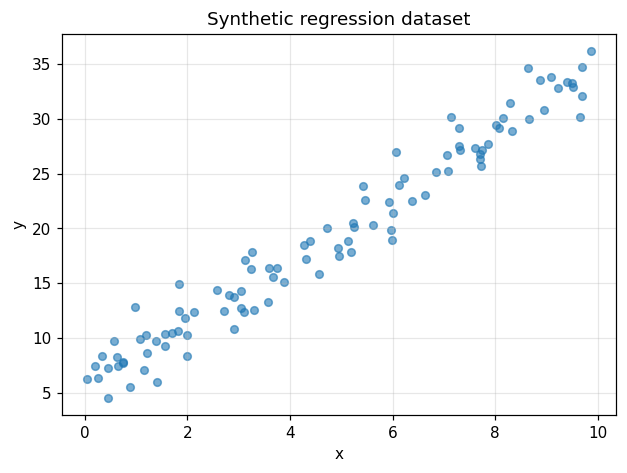

In [38]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(x_raw, y, alpha=0.6, s=25, color="tab:blue")
ax.set_title("Synthetic regression dataset")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.savefig("../figures/11_regression_raw_data.png", dpi=110, bbox_inches="tight")
plt.show()

The points suggest an approximately linear trend, but do not lie exactly on any single line - the noise term $\varepsilon$ means the true relationship must be **estimated** from the observed data rather than read off directly. The goal of the rest of this section is to recover $w \approx 3$ and $b \approx 5$ from `x_raw` and `y` alone, without using `true_w`/`true_b` in the training procedure.

## 3.4 Mean Squared Error

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$$

$$
\text{prediction} \rightarrow \text{residual } (y_i - \hat y_i)
\rightarrow \text{squared residual} \rightarrow \text{average} \rightarrow \text{MSE}
$$

Squaring the residual makes errors non-negative (so positive and negative
errors cannot cancel) and penalizes large errors more heavily than small
ones. $\text{MSE} \geq 0$ always, and $\text{MSE}=0$ only when every
prediction exactly equals its target.

In [39]:
import sys
sys.path.insert(0, "../src")
import linear_regression as lr

# Small worked example, independent of the synthetic dataset above
y_true_demo = np.array([3.0, -1.0, 2.0, 7.0])
y_pred_demo = np.array([2.5, 0.0, 2.0, 8.0])
residuals_demo = y_true_demo - y_pred_demo

print(f"y_true      = {y_true_demo}")
print(f"y_pred      = {y_pred_demo}")
print(f"residuals   = {residuals_demo}")
print(f"squared     = {residuals_demo ** 2}")
print(f"MSE (manual)= {lr.mse(y_true_demo, y_pred_demo):.6f}")

assert np.isclose(lr.mse(y_true_demo, y_pred_demo), np.mean(residuals_demo ** 2))
assert lr.mse(y_true_demo, y_pred_demo) >= 0
assert np.isclose(lr.mse(y_true_demo, y_true_demo), 0.0)
print("\nMSE sanity checks passed: non-negative, and zero only for a perfect fit.")

y_true      = [ 3. -1.  2.  7.]
y_pred      = [2.5 0.  2.  8. ]
residuals   = [ 0.5 -1.   0.  -1. ]
squared     = [0.25 1.   0.   1.  ]
MSE (manual)= 0.562500

MSE sanity checks passed: non-negative, and zero only for a perfect fit.


## 3.5 Deriving the Gradients

Starting from the one-feature model $\hat{y}_i = wx_i + b$ and the loss
$\text{MSE}(w,b) = \frac{1}{n}\sum_i (y_i - \hat{y}_i)^2$, the partial
derivatives are found by the chain rule, exactly as in Part 2:

**With respect to $w$:**

$$
\frac{\partial \text{MSE}}{\partial w}
= \frac{1}{n}\sum_i \frac{\partial}{\partial w}(y_i - \hat y_i)^2
= \frac{1}{n}\sum_i 2(y_i - \hat y_i)\cdot\frac{\partial (y_i-\hat y_i)}{\partial w}
$$

Since $\hat y_i = wx_i + b$, we have $\partial \hat y_i/\partial w = x_i$,
so $\partial(y_i-\hat y_i)/\partial w = -x_i$. Substituting:

$$
\frac{\partial \text{MSE}}{\partial w}
= \frac{1}{n}\sum_i 2(y_i-\hat y_i)(-x_i)
= -\frac{2}{n}\sum_i x_i(y_i - \hat y_i)
$$

**With respect to $b$:** identically, but $\partial \hat y_i/\partial b = 1$:

$$
\frac{\partial \text{MSE}}{\partial b}
= \frac{1}{n}\sum_i 2(y_i-\hat y_i)(-1)
= -\frac{2}{n}\sum_i (y_i - \hat y_i)
$$

Writing $\text{error}_i = y_i - \hat y_i$:

$$
dw = -\frac{2}{n}\sum_i x_i\,\text{error}_i
\qquad
db = -\frac{2}{n}\sum_i \text{error}_i
$$

This is exactly the same *derivative → partial derivative → gradient*
progression from Part 2, applied here to a two-parameter loss surface
$(w,b)$ instead of the generic $f(x,y)$ used there. `compute_gradients`
below vectorizes the sum over $i$ using the matrix form from Section 3.2
($X^T \text{error}$ instead of a loop over $x_i \cdot \text{error}_i$).

In [40]:
import inspect
print(inspect.getsource(lr.compute_gradients))

def compute_gradients(X, y, w, b):
    """
    Analytical gradients of the MSE loss with respect to w and b, derived
    via the chain rule from y_hat = Xw + b and MSE = (1/n) sum (y - y_hat)^2:

        error_i = y_i - y_hat_i
        dMSE/dw = -(2/n) * X^T error
        dMSE/db = -(2/n) * sum(error)

    Returns (dw, db).
    """
    n = X.shape[0]
    y_pred = predict(X, w, b)
    error = y - y_pred
    dw = -(2.0 / n) * (X.T @ error)
    db = -(2.0 / n) * np.sum(error)
    return dw, db



## 3.6 Linear Regression With Gradient Descent

The update rule follows directly from Part 2:

$$w \leftarrow w - \eta\, dw \qquad b \leftarrow b - \eta\, db$$

`train_linear_regression` (in `src/linear_regression.py`) implements the
full loop: initialize $w,b$; predict; compute MSE; compute gradients;
update $w,b$; repeat, recording the loss (and parameter) history at every
step. No `sklearn`, `scipy.optimize`, or other optimization library is
used inside it.

In [41]:
print(inspect.getsource(lr.train_linear_regression))

def train_linear_regression(X, y, learning_rate, iterations,
                             w_init=None, b_init=0.0,
                             divergence_threshold=1e10):
    """
    Batch gradient descent for linear regression:
        w <- w - learning_rate * dMSE/dw
        b <- b - learning_rate * dMSE/db

    Records loss/parameter history at every iteration. Stops early and
    flags `diverged=True` if the loss becomes non-finite or exceeds
    `divergence_threshold`, rather than looping on a diverging run.

    Returns a dict with keys "w", "b", "loss_history", "w_history",
    "b_history", "diverged".
    """
    n_features = X.shape[1]
    w = np.zeros(n_features) if w_init is None else np.array(w_init, dtype=float)
    b = float(b_init)

    loss_history, w_history, b_history = [], [], []
    diverged = False

    for _ in range(iterations):
        loss = mse(y, predict(X, w, b))
        loss_history.append(loss)
        w_history.append(w.copy())
        b_history.append(b

## Gradient Verification

Before training, we independently check that the analytical gradients in
`compute_gradients` agree with a finite-difference approximation, using
the same technique as Part 2's `numerical_derivative` - applied here to a
two-parameter loss surface, at an arbitrary (untrained) point rather than
the final trained parameters, since this is meant to verify the gradient
*formula and implementation*, not the training result.

In [42]:
w_test = np.array([1.0])
b_test = 0.5

analytical_dw, analytical_db = lr.compute_gradients(X, y, w_test, b_test)
numerical_dw, numerical_db = lr.numerical_gradient_check(X, y, w_test, b_test)

print(f"dMSE/dw : analytical = {analytical_dw}, numerical = {numerical_dw}, "
      f"diff = {np.abs(analytical_dw - numerical_dw)}")
print(f"dMSE/db : analytical = {analytical_db:.6f}, numerical = {numerical_db:.6f}, "
      f"diff = {abs(analytical_db - numerical_db):.2e}")

assert np.allclose(analytical_dw, numerical_dw, atol=1e-3)
assert np.isclose(analytical_db, numerical_db, atol=1e-3)
print("\nGradient verification passed: analytical gradients match the "
      "independent finite-difference approximation.")

dMSE/dw : analytical = [-164.15858063], numerical = [-164.15858063], diff = [1.83339921e-09]
dMSE/db : analytical = -27.802908, numerical = -27.802908, diff = 1.88e-09

Gradient verification passed: analytical gradients match the independent finite-difference approximation.


## 3.7 Training the Model

Trained with $\eta=0.01$ for 1000 iterations, starting from $w=0,\ b=0$
(values chosen after checking, in Section 3.9, that this learning rate
converges stably on this dataset).

In [43]:
w_init = np.array([0.0])
b_init = 0.0
initial_mse = lr.mse(y, lr.predict(X, w_init, b_init))

print(f"Initial w = {w_init}, initial b = {b_init}, initial MSE = {initial_mse:.4f}")

result = lr.train_linear_regression(X, y, learning_rate=0.01, iterations=1000,
                                     w_init=w_init, b_init=b_init)

print(f"\nFinal w = {result['w']}, final b = {result['b']:.4f}, "
      f"final MSE = {result['loss_history'][-1]:.4f}")
print(f"Diverged: {result['diverged']}")
print(f"\nTrue underlying parameters: w = {true_w}, b = {true_b}")
print(f"Learned parameters:          w = {result['w'][0]:.4f}, b = {result['b']:.4f}")

assert result["loss_history"][-1] < initial_mse

Initial w = [0.], initial b = 0.0, initial MSE = 442.2545

Final w = [2.9109187], final b = 5.4115, final MSE = 3.2264
Diverged: False

True underlying parameters: w = 3.0, b = 5.0
Learned parameters:          w = 2.9109, b = 5.4115


The learned parameters are close to, but not exactly equal to, the true generating parameters ($w=3$, $b=5$) - this is expected: the model is fit to a single noisy sample of 100 points, so the least-squares estimate reflects that particular sample's noise realization rather than recovering the population parameters exactly. Training visibly reduced the MSE from its initial value, confirmed by the assertion above.

## 3.8 Visualizing the Learned Model

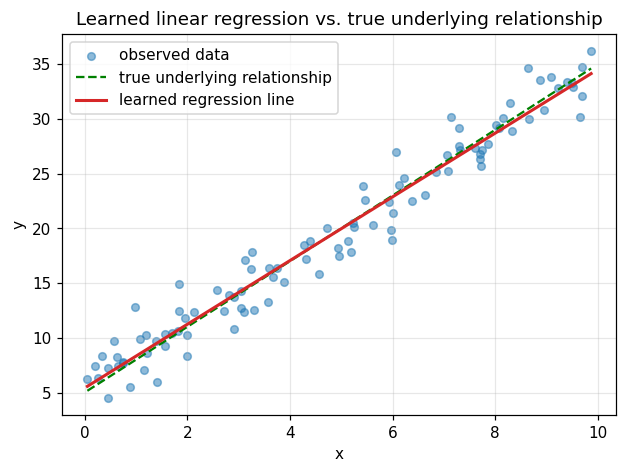

In [44]:
x_line = np.linspace(x_raw.min(), x_raw.max(), 100)
y_true_line = true_w * x_line + true_b
y_learned_line = result["w"][0] * x_line + result["b"]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(x_raw, y, alpha=0.5, s=25, color="tab:blue", label="observed data")
ax.plot(x_line, y_true_line, "g--", linewidth=1.5, label="true underlying relationship")
ax.plot(x_line, y_learned_line, color="tab:red", linewidth=2, label="learned regression line")
ax.set_title("Learned linear regression vs. true underlying relationship")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.savefig("../figures/12_regression_fit.png", dpi=110, bbox_inches="tight")
plt.show()

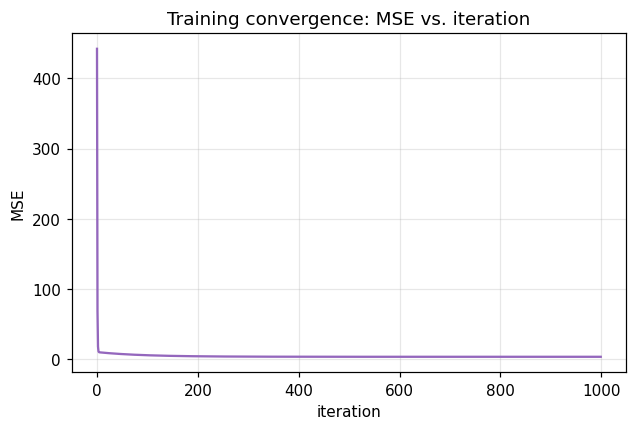

In [45]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.plot(result["loss_history"], color="tab:purple")
ax.set_title("Training convergence: MSE vs. iteration")
ax.set_xlabel("iteration")
ax.set_ylabel("MSE")
plt.savefig("../figures/13_regression_convergence.png", dpi=110, bbox_inches="tight")
plt.show()

The learned line (red) closely tracks the true generating line (green dashed) without coinciding with it exactly, which is the expected outcome on noisy data - the decreasing MSE-vs-iteration curve shows gradient descent steadily reducing the loss until it levels off near convergence.

## 3.9 Comparing Learning Rates

Using the same dataset and initialization ($w_0=0,\ b_0=0$), gradient
descent is run with several learning rates for 1000 iterations each. Since
`x` here is unnormalized (range roughly $0$-$10$), the gradients involve a
factor of $x_i$, so - as the experiment below shows - substantially larger
learning rates than in Part 2's normalized examples can become unstable on
this particular dataset.

In [46]:
lr_candidates = [0.001, 0.01, 0.05, 0.1]
lr_results = []

for eta in lr_candidates:
    res = lr.train_linear_regression(X, y, learning_rate=eta, iterations=1000,
                                      w_init=np.array([0.0]), b_init=0.0)
    lr_results.append((eta, res))
    status = "diverged" if res["diverged"] else "completed all iterations"
    print(f"eta = {eta:<6} final w = {res['w'][0]:>14.4f}  final b = {res['b']:>14.4f}  "
          f"final MSE = {res['loss_history'][-1]:>16.4f}  ({status})")

eta = 0.001  final w =         3.3377  final b =         2.6350  final MSE =           5.4469  (completed all iterations)
eta = 0.01   final w =         2.9109  final b =         5.4115  final MSE =           3.2264  (completed all iterations)
eta = 0.05   final w =    -37523.9764  final b =     -5765.9439  final MSE = 45541034583.4553  (diverged)
eta = 0.1    final w =    -82722.6278  final b =    -12712.8825  final MSE = 221304513233.8611  (diverged)


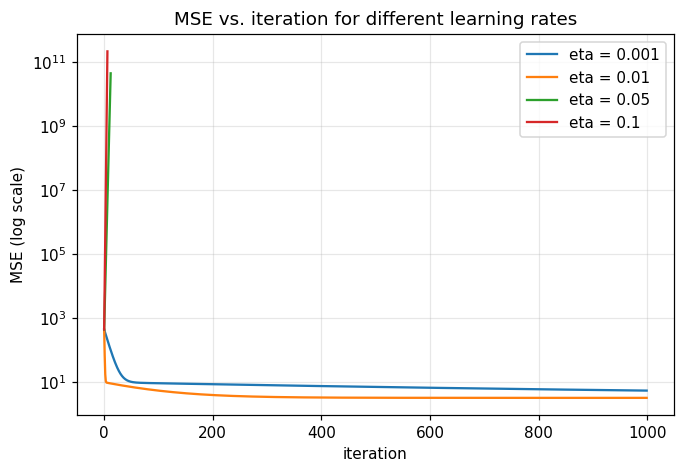

In [47]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for eta, res in lr_results:
    ax.plot(res["loss_history"], label=f"eta = {eta}")
ax.set_yscale("log")
ax.set_title("MSE vs. iteration for different learning rates")
ax.set_xlabel("iteration")
ax.set_ylabel("MSE (log scale)")
ax.legend()
plt.savefig("../figures/14_regression_lr_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

In [48]:
lr_table = pd.DataFrame([
    {
        "Learning Rate": eta,
        "Final w": res["w"][0],
        "Final b": res["b"],
        "Final MSE": res["loss_history"][-1],
        "Iterations": len(res["loss_history"]),
        "Diverged?": res["diverged"],
    }
    for eta, res in lr_results
])
lr_table

   Learning Rate       Final w  ...  Iterations  Diverged?
0          0.001      3.337659  ...        1000      False
1          0.010      2.910919  ...        1000      False
2          0.050 -37523.976433  ...          13       True
3          0.100 -82722.627825  ...           7       True

[4 rows x 6 columns]

- **eta = 0.001** (small): converges, but more slowly - after 1000
  iterations the loss has not yet flattened as much as eta = 0.01's.
- **eta = 0.01** (moderate): converges efficiently and stably to a low MSE.
- **eta = 0.05 and eta = 0.1**: on this unnormalized dataset, the printed
  results above show these diverge (loss grows without bound rather than
  decreasing) - this is a property of this specific dataset's feature
  scale, not evidence that 0.05 or 0.1 are inherently bad learning rates
  in general.

## 3.10 Validation Against scikit-learn

Only now, after the from-scratch model has been implemented and trained,
do we introduce `sklearn.linear_model.LinearRegression` - purely as a
validation reference trained on exactly the same data, not as part of the
training procedure above.

In [49]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X, y)
sk_w, sk_b = sk_model.coef_[0], sk_model.intercept_
sk_mse = lr.mse(y, sk_model.predict(X))

comparison_table = pd.DataFrame([
    {"Method": "From-scratch (gradient descent)", "Weight": result["w"][0],
     "Bias": result["b"], "MSE": result["loss_history"][-1]},
    {"Method": "scikit-learn LinearRegression", "Weight": sk_w,
     "Bias": sk_b, "MSE": sk_mse},
])
comparison_table

                            Method    Weight      Bias       MSE
0  From-scratch (gradient descent)  2.910919  5.411498  3.226439
1    scikit-learn LinearRegression  2.908045  5.430192  3.226338

In [50]:
weight_diff = abs(result["w"][0] - sk_w)
bias_diff = abs(result["b"] - sk_b)
mse_diff = abs(result["loss_history"][-1] - sk_mse)

print(f"Weight difference: {weight_diff:.6f}")
print(f"Bias difference:   {bias_diff:.6f}")
print(f"MSE difference:    {mse_diff:.6f}")

close_enough = np.isclose(result["w"][0], sk_w, atol=1e-2) and np.isclose(result["b"], sk_b, atol=1e-1)
print(f"\nParameters consistent with sklearn within tolerance: {close_enough}")
assert close_enough, "Investigate: gradient-descent solution has not converged closely enough to the closed-form optimum."

Weight difference: 0.002873
Bias difference:   0.018695
MSE difference:    0.000100

Parameters consistent with sklearn within tolerance: True


The from-scratch implementation produces parameters and predictions consistent with a standard library implementation within numerical/optimization tolerance. `scikit-learn` solves this problem via a closed-form/least-squares solver rather than iterative gradient descent, so small remaining differences reflect the optimization method and iteration count used here, not an error in either implementation.

As a brief aside: for ordinary least squares, a closed-form solution also
exists,

$$w^* = (X^TX)^{-1}X^Ty$$

(the *normal equation*). This is the solver scikit-learn effectively uses
internally, which is why it does not need iterations. This project focuses
on gradient descent, following directly from Part 2, rather than the
normal equation - and it is worth noting that $(X^TX)^{-1}$ does not exist
when $X^TX$ is singular (e.g. duplicated or perfectly correlated
features), a case that requires a pseudoinverse or regularization, both
outside this project's scope.

## 3.11 Experiments and Analysis

### Experiment 1 - Noise

low    (sigma=0.5): w=3.0238, b=4.8895, final MSE=0.2556
medium (sigma=2.0): w=3.0874, b=4.6091, final MSE=4.0881
high   (sigma=5.0): w=3.2145, b=4.0482, final MSE=25.5505


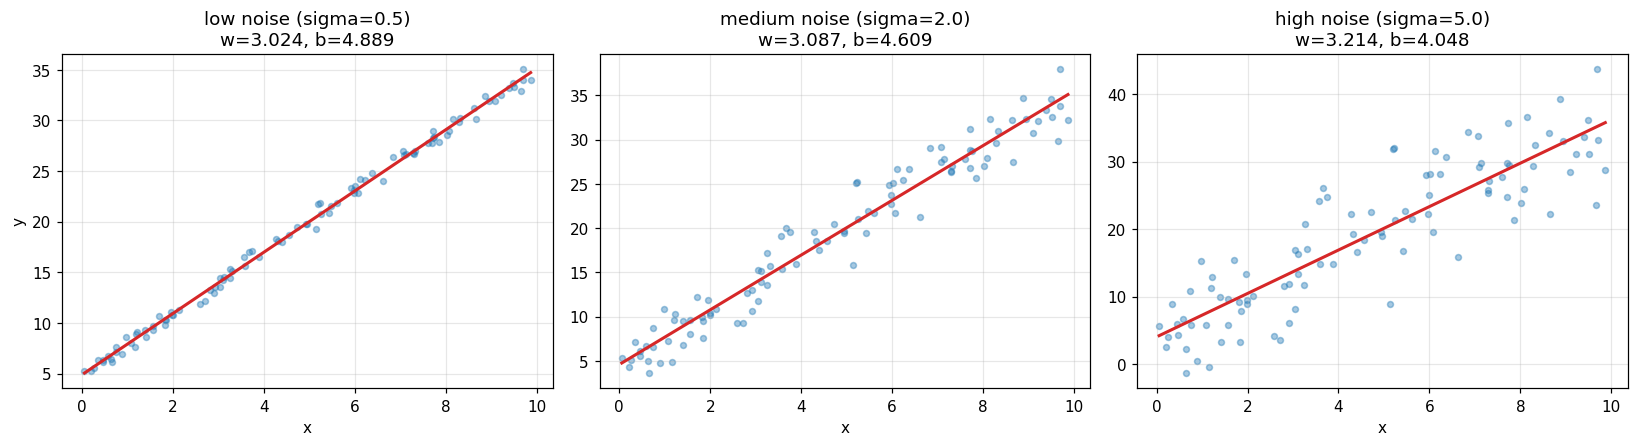

In [51]:
noise_levels = {"low": 0.5, "medium": 2.0, "high": 5.0}
noise_results = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)

for ax, (label, sigma) in zip(axes, noise_levels.items()):
    np.random.seed(7)  # same seed across noise levels -> only sigma differs
    noise_i = np.random.normal(0, sigma, size=n_samples)
    y_i = true_w * x_raw + true_b + noise_i

    res_i = lr.train_linear_regression(X, y_i, learning_rate=0.01, iterations=1000,
                                        w_init=np.array([0.0]), b_init=0.0)
    noise_results[label] = (sigma, res_i)

    ax.scatter(x_raw, y_i, alpha=0.4, s=15, color="tab:blue")
    ax.plot(x_line, res_i["w"][0] * x_line + res_i["b"], color="tab:red", linewidth=2)
    ax.set_title(f"{label} noise (sigma={sigma})\nw={res_i['w'][0]:.3f}, b={res_i['b']:.3f}")
    ax.set_xlabel("x")

axes[0].set_ylabel("y")
plt.tight_layout()
plt.savefig("../figures/15_regression_noise_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

for label, (sigma, res_i) in noise_results.items():
    print(f"{label:6s} (sigma={sigma}): w={res_i['w'][0]:.4f}, b={res_i['b']:.4f}, "
          f"final MSE={res_i['loss_history'][-1]:.4f}")

For these particular noise realizations, increasing noise produced larger deviations of the estimated parameters from the true generating parameters, while the final MSE increased substantially. The direction and magnitude of coefficient deviation are sample-dependent and should not be interpreted as a general bias caused by noise.

### Experiment 2 - Number of Training Iterations

   10 iterations: final w=3.6156, final b=0.8253, final MSE=9.3135
  100 iterations: final w=3.3371, final b=2.6389, final MSE=5.4630
 1000 iterations: final w=2.9109, final b=5.4115, final MSE=3.2264


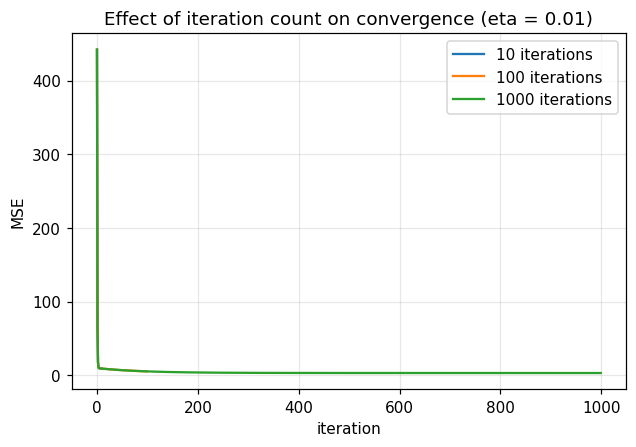

In [52]:
iteration_counts = [10, 100, 1000]
fig, ax = plt.subplots(figsize=(6.5, 4.2))

for n_iter in iteration_counts:
    res_iter = lr.train_linear_regression(X, y, learning_rate=0.01, iterations=n_iter,
                                           w_init=np.array([0.0]), b_init=0.0)
    ax.plot(res_iter["loss_history"], label=f"{n_iter} iterations")
    print(f"{n_iter:5d} iterations: final w={res_iter['w'][0]:.4f}, "
          f"final b={res_iter['b']:.4f}, final MSE={res_iter['loss_history'][-1]:.4f}")

ax.set_title("Effect of iteration count on convergence (eta = 0.01)")
ax.set_xlabel("iteration")
ax.set_ylabel("MSE")
ax.legend()
plt.savefig("../figures/16_regression_iteration_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

With only 10 iterations the model is still far from converged; by 100 iterations the loss has dropped substantially; by 1000 iterations the loss has largely flattened, indicating the model is close to convergence for this learning rate.

### Experiment 3 - Starting Parameters

In [53]:
start_a = lr.train_linear_regression(X, y, learning_rate=0.01, iterations=1000,
                                      w_init=np.array([0.0]), b_init=0.0)
start_b = lr.train_linear_regression(X, y, learning_rate=0.01, iterations=1000,
                                      w_init=np.array([10.0]), b_init=-10.0)

print(f"Start (w=0, b=0)   -> final w={start_a['w'][0]:.4f}, final b={start_a['b']:.4f}, "
      f"final MSE={start_a['loss_history'][-1]:.4f}")
print(f"Start (w=10, b=-10)-> final w={start_b['w'][0]:.4f}, final b={start_b['b']:.4f}, "
      f"final MSE={start_b['loss_history'][-1]:.4f}")
print(f"\nDifference in final w: {abs(start_a['w'][0]-start_b['w'][0]):.2e}")
print(f"Difference in final b: {abs(start_a['b']-start_b['b']):.2e}")

Start (w=0, b=0)   -> final w=2.9109, final b=5.4115, final MSE=3.2264
Start (w=10, b=-10)-> final w=2.9176, final b=5.3682, final MSE=3.2274

Difference in final w: 6.65e-03
Difference in final b: 4.33e-02


Both starting points converge to essentially the same final parameters. This is consistent with the MSE objective for linear regression being **convex** in $(w,b)$ - a convex objective has no spurious local minima to get trapped in, so, provided gradient descent converges at all, it converges to the same global optimum regardless of initialization. This does not mean gradient descent is guaranteed to converge for *any* learning rate on *any* objective - Section 3.9 already showed learning rates for which it diverges on this same convex objective.

## 3.12 Computational Perspective

For $n$ samples and $d$ features:
- **Prediction** ($Xw$): approximately $O(nd)$ - each of $n$ outputs sums
  $d$ products.
- **Gradient computation** ($X^T \text{error}$ and the sum for $db$): also
  approximately $O(nd)$ per iteration.
- **Total training cost**: approximately $O(\text{iterations} \times n \times d)$
  for batch gradient descent, since every iteration re-scans the full
  dataset.

This connects directly back to both earlier parts: **Part 1**'s matrix
multiplication lets $Xw$ be expressed and computed compactly instead of as
nested loops over samples and features; **Part 2**'s gradient descent
supplies the update rule that turns a single gradient computation into an
iterative parameter search. As $n$, $d$, or the iteration count grow, this
cost grows accordingly, which is why efficient (vectorized) gradient
computation matters increasingly for larger models.

## 3.13 Summary

1. Linear regression defines a parametric model, $\hat y = Xw + b$.
2. Matrix multiplication (Part 1) computes predictions for all samples at once.
3. MSE measures the average squared prediction error.
4. Calculus (Part 2) gives the gradients of the MSE with respect to $w,b$.
5. Gradient descent (Part 2) iteratively updates $w,b$ using those gradients.
6. Training numerically reduces the MSE, as verified above.
7. The resulting parameters were validated against scikit-learn's
   `LinearRegression` within numerical/optimization tolerance.

$$
X \rightarrow Xw+b \rightarrow \text{predictions} \rightarrow \text{MSE}
\rightarrow \text{gradients} \rightarrow \text{gradient descent}
\rightarrow \text{updated parameters} \rightarrow \text{lower MSE}
$$

With regression established as a continuous-output model, the next section
will extend these ideas to binary classification.

---
# 4. Logistic Regression From Scratch

Part 3 built a model for continuous targets. This section asks a different
question:

**How can a linear model be transformed into a probability-based binary
classifier, and trained using the same gradient-descent framework as
Part 3?**

## 4.1 Why Logistic Regression?

Ordinary linear regression produces an unrestricted real-valued output,
$\hat y = wx+b$, which can fall below $0$, above $1$, or anywhere in
between - it was never constrained to look like a probability, because
Part 3's target was a continuous quantity, not a class label.

Binary classification instead requires an output interpretable as
$P(\text{class}=1)$, which must lie strictly between $0$ and $1$. Logistic
regression achieves this not simply by "adding a sigmoid to linear
regression" as an afterthought, but by re-deriving the model around a
different question - probability estimation - with its own matching loss
function (Section 4.5) and gradient (Section 4.6), which turn out to differ
from Part 3's in a specific, derivable way. Concretely, it keeps Part 3's
linear score

$$z = Xw + b$$

and maps it through the sigmoid function

$$p = \sigma(z), \qquad 0 < p < 1$$

so that $p$ can be interpreted as the estimated probability of the
positive class.

## 4.2 Linear Score

$$z = Xw + b$$

$z$ is the model's **linear score**, also called the *logit* (the value
passed into the sigmoid, before it becomes a probability). For one
feature, $z = wx+b$; for multiple features, $z=Xw+b$ - the exact same
linear-algebra structure as Part 3's prediction, computed the same way via
matrix multiplication (Part 1). What changes in Part 4 is not this linear
step, but what happens to $z$ afterward.

## 4.3 Sigmoid Function

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

Properties:
- Output always lies strictly between $0$ and $1$.
- $\sigma(0) = 0.5$.
- As $z \to +\infty$, $\sigma(z) \to 1$ (large positive score -> high
  confidence in class 1).
- As $z \to -\infty$, $\sigma(z) \to 0$ (large negative score -> high
  confidence in class 0).

**Numerical stability.** Evaluating $e^{-z}$ directly overflows for very
negative $z$ (since $-z$ becomes large and positive). The implementation
below instead uses the equivalent form $e^{z}/(1+e^{z})$ whenever $z<0$,
where $e^{z}$ safely underflows toward $0$ rather than overflowing - this
matters because floating-point overflow silently produces `inf`/`nan`
rather than raising an error, which would otherwise corrupt training
without an obvious symptom.

In [54]:
import sys
sys.path.insert(0, "../src")
import logistic_regression as logreg

# Numerical stability check: large-magnitude inputs must not warn/overflow
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("error")  # promote any RuntimeWarning to an exception
    extreme_check = logreg.sigmoid(np.array([-1000.0, 1000.0]))
print(f"sigmoid([-1000, 1000]) = {extreme_check}  (no overflow warning raised)")

sigmoid([-1000, 1000]) = [0. 1.]  (no overflow warning raised)


In [55]:
# Explicit validation: sigmoid(0) = 0.5, and outputs lie strictly in (0, 1)
sigmoid_test_values = np.array([-10.0, -2.0, 0.0, 2.0, 10.0])
sigmoid_test_output = logreg.sigmoid(sigmoid_test_values)

assert np.isclose(logreg.sigmoid(0.0), 0.5)
assert np.all(sigmoid_test_output > 0)
assert np.all(sigmoid_test_output < 1)

print("Sigmoid validation passed.")

Sigmoid validation passed.


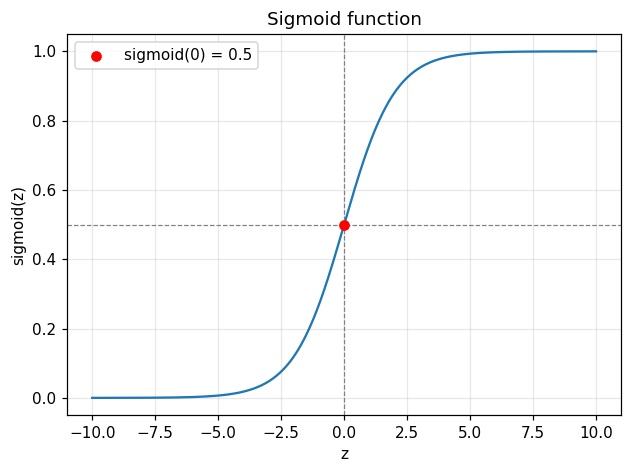

In [56]:
z_range = np.linspace(-10, 10, 400)
sigmoid_values = logreg.sigmoid(z_range)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(z_range, sigmoid_values, color="tab:blue")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.scatter([0], [0.5], color="red", zorder=5, label="sigmoid(0) = 0.5")
ax.set_title("Sigmoid function")
ax.set_xlabel("z")
ax.set_ylabel("sigmoid(z)")
ax.legend()
plt.savefig("../figures/17_sigmoid_curve.png", dpi=110, bbox_inches="tight")
plt.show()

The curve is monotonically increasing and S-shaped, saturating toward $0$ and $1$ at the extremes and crossing exactly through $(0, 0.5)$ - the point that will define the decision boundary in Section 4.10.

## 4.4 From Score to Probability

In [57]:
sample_scores = np.array([-5.0, -2.0, 0.0, 2.0, 5.0])
sample_probs = logreg.sigmoid(sample_scores)

score_table = pd.DataFrame({"z": sample_scores, "sigmoid(z)": sample_probs})
score_table

     z  sigmoid(z)
0 -5.0    0.006693
1 -2.0    0.119203
2  0.0    0.500000
3  2.0    0.880797
4  5.0    0.993307

Classification then applies a threshold to the probability:

$$
\text{class} =
\begin{cases} 1 & \text{if } p \geq \text{threshold} \\ 0 & \text{otherwise} \end{cases}
\qquad \text{(default threshold} = 0.5\text{)}
$$

This threshold is a **decision rule applied after** the model produces a
probability - it is not part of computing $p$ itself. Section 4.11 makes
this distinction concrete by applying different thresholds to the same
fixed probabilities.

## 4.5 Binary Cross-Entropy Loss

$$L = -\frac{1}{n}\sum_{i=1}^n \Big[y_i\log(p_i) + (1-y_i)\log(1-p_i)\Big]$$

For a single example, only one of the two terms is active depending on
the true label:
- If $y=1$: loss $= -\log(p)$ - small when $p$ is close to 1 (confident
  and correct), large as $p \to 0$ (confident and wrong).
- If $y=0$: loss $= -\log(1-p)$ - small when $p$ is close to 0, large as
  $p \to 1$.

So confident *correct* predictions are cheap, and confident *incorrect*
predictions are heavily penalized (the loss grows without bound as a
confident prediction gets more wrong) - this asymmetric penalty on
confident mistakes is what BCE is specifically designed to capture, unlike
Part 3's MSE.

**Numerical stability.** If $p$ is ever exactly $0$ or $1$ (which
floating-point sigmoid output can produce for extreme $z$), $\log(p)$ or
$\log(1-p)$ evaluates to $-\infty$. The implementation clips $p$ to
$[\epsilon, 1-\epsilon]$ for a small $\epsilon$ before taking the log, to
prevent this.

In [58]:
# Small worked example, independent of any trained model
y_demo = np.array([1, 0, 1, 0])
p_demo = np.array([0.9, 0.1, 0.6, 0.3])

loss_demo = logreg.binary_cross_entropy(y_demo, p_demo)
print(f"y = {y_demo}, p = {p_demo}")
print(f"Binary cross-entropy = {loss_demo:.6f}")

# Confident-correct vs confident-incorrect comparison
confident_correct = logreg.binary_cross_entropy(np.array([1.0]), np.array([0.99]))
confident_wrong = logreg.binary_cross_entropy(np.array([1.0]), np.array([0.01]))
print(f"\nLoss when confident AND correct (y=1, p=0.99): {confident_correct:.4f}")
print(f"Loss when confident AND wrong   (y=1, p=0.01): {confident_wrong:.4f}")

assert loss_demo >= 0
assert confident_wrong > confident_correct
assert np.isclose(logreg.binary_cross_entropy(np.array([1.0]), np.array([1.0 - 1e-12])), 0.0, atol=1e-6)
print("\nBCE sanity checks passed: non-negative, and confident mistakes cost far more than confident correct predictions.")

y = [1 0 1 0], p = [0.9 0.1 0.6 0.3]
Binary cross-entropy = 0.269555

Loss when confident AND correct (y=1, p=0.99): 0.0101
Loss when confident AND wrong   (y=1, p=0.01): 4.6052

BCE sanity checks passed: non-negative, and confident mistakes cost far more than confident correct predictions.


## 4.6 Deriving the Gradient

Starting from $z=Xw+b$, $p=\sigma(z)$, and the BCE loss above, the key
building block is the derivative of the sigmoid itself:

$$\frac{d\sigma(z)}{dz} = \sigma(z)\big(1-\sigma(z)\big)$$

**For a single example**, applying the chain rule through $L_i
= -[y_i\log(p_i)+(1-y_i)\log(1-p_i)]$, $p_i=\sigma(z_i)$, $z_i = wx_i+b$:

$$
\frac{\partial L_i}{\partial p_i}
= -\frac{y_i}{p_i} + \frac{1-y_i}{1-p_i}
= \frac{p_i - y_i}{p_i(1-p_i)}
$$

Multiplying by $\partial p_i/\partial z_i = p_i(1-p_i)$ (the sigmoid
derivative above) makes the $p_i(1-p_i)$ terms **cancel exactly**:

$$
\frac{\partial L_i}{\partial z_i}
= \frac{\partial L_i}{\partial p_i}\cdot\frac{\partial p_i}{\partial z_i}
= \frac{p_i-y_i}{p_i(1-p_i)}\cdot p_i(1-p_i)
= p_i - y_i
$$

This cancellation is the reason logistic regression's gradient has such a
simple closed form despite BCE's logarithms. Finally, $\partial
z_i/\partial w = x_i$ and $\partial z_i/\partial b = 1$ (identical to
Part 3), so averaging over all $n$ examples:

$$
dw = \frac{1}{n}X^T(p-y) \qquad db = \frac{1}{n}\sum_i (p_i-y_i)
$$

**Compare directly to Part 3:**

$$
\text{Part 3: prediction} \rightarrow \text{MSE} \rightarrow \text{gradient} \rightarrow \text{gradient descent}
$$
$$
\text{Part 4: linear score} \rightarrow \text{sigmoid} \rightarrow \text{probability}
\rightarrow \text{BCE} \rightarrow \text{gradient} \rightarrow \text{gradient descent}
$$

Remarkably, $dw=\frac1n X^T(p-y)$ and $db=\frac1n\sum(p-y)$ have exactly
the same *form* as Part 3's $dw=-\frac2n X^T(y-\hat y)$ and
$db=-\frac2n\sum(y-\hat y)$ (both are "average of feature times error"),
even though $p=\sigma(Xw+b)$ is nonlinear in $w,b$ while $\hat y = Xw+b$
is not - a consequence of BCE being paired specifically with the sigmoid,
not a general property of arbitrary loss/nonlinearity combinations.

In [59]:
print(inspect.getsource(logreg.compute_gradients))

def compute_gradients(X, y, probabilities):
    """
    Analytical gradients of binary cross-entropy with respect to w and b
    (derivation in the notebook, Section 4.6):
        error = p - y
        dw = (1/n) * X^T error
        db = (1/n) * sum(error)
    """
    n = X.shape[0]
    error = probabilities - y
    dw = (1.0 / n) * (X.T @ error)
    db = (1.0 / n) * np.sum(error)
    return dw, db



## 4.7 Logistic Regression With Gradient Descent

Update rule (identical form to Part 3, applied to the BCE gradients
derived above):

$$w \leftarrow w - \eta\, dw \qquad b \leftarrow b - \eta\, db$$

In [60]:
print(inspect.getsource(logreg.train_logistic_regression))

def train_logistic_regression(X, y, learning_rate, iterations,
                               w_init=None, b_init=0.0,
                               divergence_threshold=1e10):
    """
    Batch gradient descent for logistic regression:
        w <- w - learning_rate * dL/dw
        b <- b - learning_rate * dL/db

    Records the binary cross-entropy loss at every iteration. Stops early
    and flags `diverged=True` if the loss becomes non-finite or exceeds
    `divergence_threshold`.

    Returns a dict with keys "w", "b", "loss_history", "diverged".
    """
    n_features = X.shape[1]
    w = np.zeros(n_features) if w_init is None else np.array(w_init, dtype=float)
    b = float(b_init)

    loss_history = []
    diverged = False

    for _ in range(iterations):
        p = predict_proba(X, w, b)
        loss = binary_cross_entropy(y, p)
        loss_history.append(loss)

        if not np.isfinite(loss) or loss > divergence_threshold:
            diverged = True
            break



## 4.8 Synthetic Classification Dataset

Two overlapping 2D Gaussian clusters (rather than a `sklearn`-generated
dataset, so the data-generating process stays transparent), giving classes
that are mostly but not perfectly linearly separable:

In [61]:
np.random.seed(42)

n_per_class = 100
mean_class0 = np.array([-2.0, -2.0])
mean_class1 = np.array([2.0, 2.0])
cluster_std = 2.2

X_class0 = np.random.normal(mean_class0, cluster_std, size=(n_per_class, 2))
X_class1 = np.random.normal(mean_class1, cluster_std, size=(n_per_class, 2))

X_clf = np.vstack([X_class0, X_class1])
y_clf = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)])

print(f"X_clf shape = {X_clf.shape}, y_clf shape = {y_clf.shape}")
print(f"Class balance: {int(np.sum(y_clf==0))} class-0, {int(np.sum(y_clf==1))} class-1")

X_clf shape = (200, 2), y_clf shape = (200,)
Class balance: 100 class-0, 100 class-1


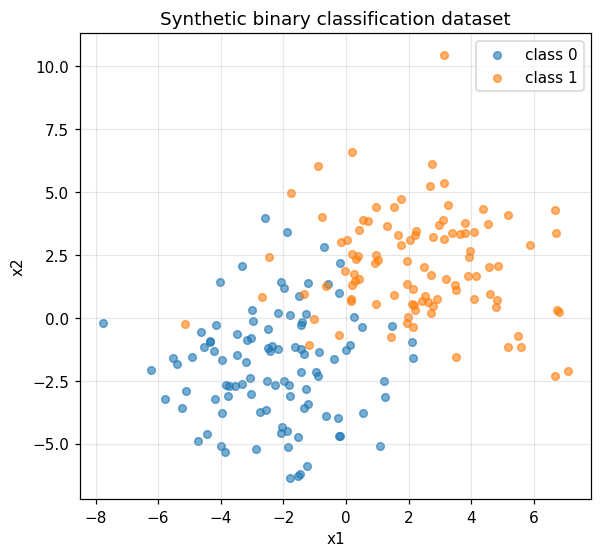

In [62]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(X_class0[:, 0], X_class0[:, 1], alpha=0.6, s=25, color="tab:blue", label="class 0")
ax.scatter(X_class1[:, 0], X_class1[:, 1], alpha=0.6, s=25, color="tab:orange", label="class 1")
ax.set_title("Synthetic binary classification dataset")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()
plt.savefig("../figures/18_classification_dataset.png", dpi=110, bbox_inches="tight")
plt.show()

The two classes form mostly separate but overlapping clusters - the goal is to learn a **linear** boundary that separates them as well as a straight line can, not to perfectly classify every point (which is impossible given the overlap).

## 4.9 Training the Classifier

In [63]:
w_init_clf = np.array([0.0, 0.0])
b_init_clf = 0.0
initial_loss_clf = logreg.binary_cross_entropy(y_clf, logreg.predict_proba(X_clf, w_init_clf, b_init_clf))

clf_result = logreg.train_logistic_regression(
    X_clf, y_clf, learning_rate=0.1, iterations=1000,
    w_init=w_init_clf, b_init=b_init_clf
)

print(f"Initial loss (w=0, b=0): {initial_loss_clf:.4f}")
print(f"Final loss:              {clf_result['loss_history'][-1]:.4f}")
print(f"Final w: {clf_result['w']}")
print(f"Final b: {clf_result['b']:.4f}")
print(f"Iterations run: {len(clf_result['loss_history'])}, diverged: {clf_result['diverged']}")

assert clf_result["loss_history"][-1] < initial_loss_clf

Initial loss (w=0, b=0): 0.6931
Final loss:              0.1924
Final w: [0.93450996 0.8769913 ]
Final b: -0.2603
Iterations run: 1000, diverged: False


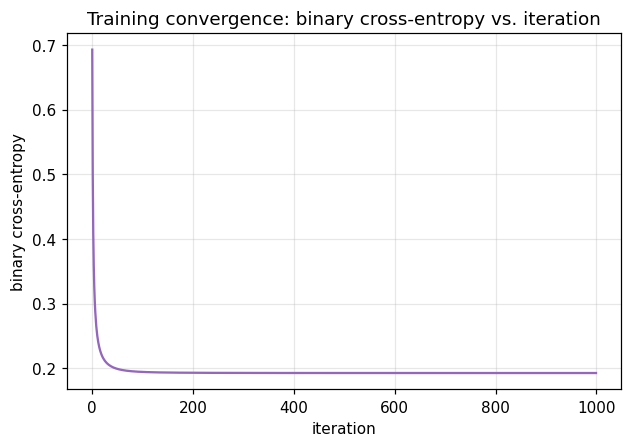

In [64]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(clf_result["loss_history"], color="tab:purple")
ax.set_title("Training convergence: binary cross-entropy vs. iteration")
ax.set_xlabel("iteration")
ax.set_ylabel("binary cross-entropy")
plt.savefig("../figures/19_classification_convergence.png", dpi=110, bbox_inches="tight")
plt.show()

The loss decreases substantially from its initial value and flattens out over the 1000 iterations shown, consistent with gradient descent approaching a minimum of the (convex, see Part 3's convexity discussion for the analogous regression case) BCE objective - the experiment supports convergence for this learning rate on this dataset, rather than a general claim that logistic regression always converges.

## 4.10 Decision Boundary

For two features, $z = w_1x_1 + w_2x_2 + b$. Since $\sigma(z)=0.5$ exactly
when $z=0$, the decision boundary (where the model is indifferent between
classes) satisfies:

$$w_1x_1 + w_2x_2 + b = 0 \quad\Longrightarrow\quad x_2 = -\frac{w_1x_1+b}{w_2} \quad (w_2 \neq 0)$$

Although $\sigma$ itself is nonlinear, the boundary is linear because it
is defined by where the *linear score* $z$ crosses zero - the sigmoid only
determines how confidently probabilities move away from $0.5$ as $z$ moves
away from that boundary, not the boundary's shape.

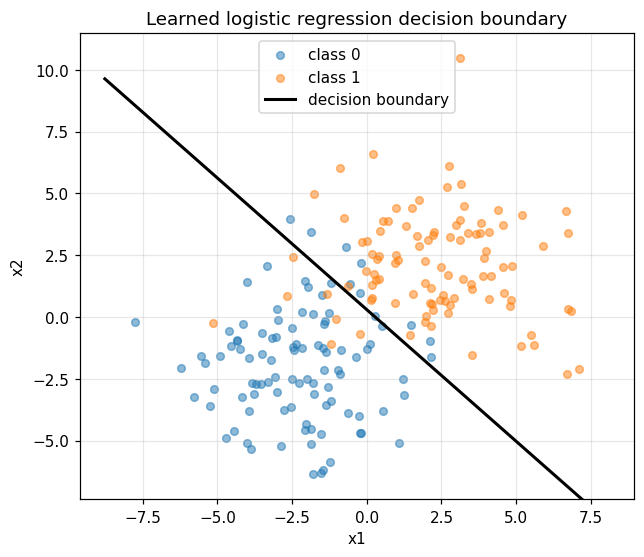

In [65]:
w1, w2 = clf_result["w"]
b_clf = clf_result["b"]

x1_line = np.linspace(X_clf[:, 0].min() - 1, X_clf[:, 0].max() + 1, 100)
x2_boundary = -(w1 * x1_line + b_clf) / w2

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(X_class0[:, 0], X_class0[:, 1], alpha=0.5, s=25, color="tab:blue", label="class 0")
ax.scatter(X_class1[:, 0], X_class1[:, 1], alpha=0.5, s=25, color="tab:orange", label="class 1")
ax.plot(x1_line, x2_boundary, color="black", linewidth=2, label="decision boundary")
ax.set_title("Learned logistic regression decision boundary")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_ylim(X_clf[:, 1].min() - 1, X_clf[:, 1].max() + 1)
ax.legend()
plt.savefig("../figures/20_decision_boundary.png", dpi=110, bbox_inches="tight")
plt.show()

The boundary separates the bulk of each class, with a visible band of overlap near the line where the two clusters mix - exactly the region where the model is least confident (probabilities near $0.5$).

## 4.11 Classification Threshold

$$p \geq 0.5 \rightarrow \text{class } 1 \qquad p < 0.5 \rightarrow \text{class } 0$$

Applying different thresholds to the **same fixed probabilities**
(without retraining) shows that the threshold is a separate decision rule
layered on top of the probability estimate:

In [66]:
probs_clf = logreg.predict_proba(X_clf, clf_result["w"], clf_result["b"])

for threshold in [0.3, 0.5, 0.7]:
    preds_at_threshold = (probs_clf >= threshold).astype(int)
    n_class1 = int(np.sum(preds_at_threshold == 1))
    print(f"threshold = {threshold}: {n_class1} of {len(preds_at_threshold)} points predicted class 1")

threshold = 0.3: 107 of 200 points predicted class 1
threshold = 0.5: 103 of 200 points predicted class 1
threshold = 0.7: 93 of 200 points predicted class 1


Lowering the threshold to $0.3$ classifies more points as class 1 (the model needs less evidence to commit to class 1); raising it to $0.7$ classifies fewer points as class 1. The underlying probabilities `probs_clf` did not change at all between these three lines - only the decision rule applied to them did.

## 4.12 Model Evaluation

$$\text{accuracy} = \frac{TP+TN}{TP+TN+FP+FN} \qquad
\text{precision} = \frac{TP}{TP+FP} \qquad
\text{recall} = \frac{TP}{TP+FN} \qquad
\text{F1} = \frac{2\cdot\text{precision}\cdot\text{recall}}{\text{precision}+\text{recall}}$$

In [67]:
preds_clf = logreg.predict(X_clf, clf_result["w"], clf_result["b"], threshold=0.5)
assert set(np.unique(preds_clf)).issubset({0, 1})

cm = logreg.confusion_matrix_manual(y_clf, preds_clf)
print("Confusion matrix counts:", cm)
assert cm["TP"] + cm["TN"] + cm["FP"] + cm["FN"] == len(y_clf)

accuracy = logreg.accuracy_score_manual(cm)
precision = logreg.precision_score_manual(cm)
recall = logreg.recall_score_manual(cm)
f1 = logreg.f1_score_manual(cm)

assert np.isclose(accuracy, (cm["TP"] + cm["TN"]) / len(y_clf))

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 score:  {f1:.4f}")

Confusion matrix counts: {'TP': 93, 'TN': 90, 'FP': 10, 'FN': 7}

Accuracy:  0.9150
Precision: 0.9029
Recall:    0.9300
F1 score:  0.9163


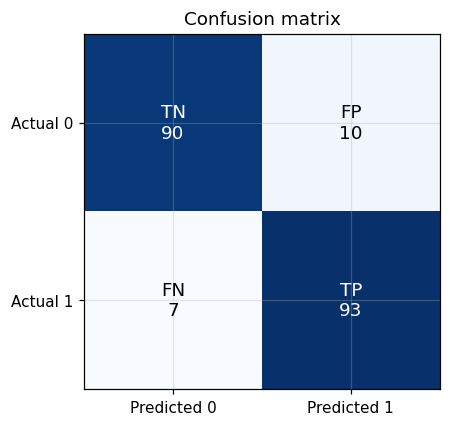

In [68]:
fig, ax = plt.subplots(figsize=(4.5, 4.2))
matrix_values = np.array([[cm["TN"], cm["FP"]],
                           [cm["FN"], cm["TP"]]])
im = ax.imshow(matrix_values, cmap="Blues")

labels = np.array([["TN", "FP"], ["FN", "TP"]])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i,j]}\n{matrix_values[i,j]}",
                 ha="center", va="center", fontsize=12,
                 color="white" if matrix_values[i,j] > matrix_values.max()/2 else "black")

ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted 0", "Predicted 1"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual 0", "Actual 1"])
ax.set_title("Confusion matrix")
plt.savefig("../figures/21_confusion_matrix.png", dpi=110, bbox_inches="tight")
plt.show()

Accuracy alone would not reveal *how* the model is wrong - the confusion matrix's FP/FN breakdown, and precision/recall computed from it, show whether errors skew toward false positives or false negatives. On this roughly class-balanced synthetic dataset accuracy is a reasonable summary, but that would not generally hold for an imbalanced dataset.

## 4.13 Learning Rate Experiment

In [69]:
clf_lr_candidates = [0.001, 0.01, 0.05, 0.1]
clf_lr_results = []

for eta in clf_lr_candidates:
    res = logreg.train_logistic_regression(X_clf, y_clf, learning_rate=eta, iterations=1000,
                                            w_init=np.array([0.0, 0.0]), b_init=0.0)
    preds_eta = logreg.predict(X_clf, res["w"], res["b"])
    acc_eta = logreg.accuracy_score_manual(logreg.confusion_matrix_manual(y_clf, preds_eta))
    clf_lr_results.append((eta, res, acc_eta))
    status = "diverged" if res["diverged"] else "completed all iterations"
    print(f"eta = {eta:<6} final loss = {res['loss_history'][-1]:>10.4f}  "
          f"accuracy = {acc_eta:.4f}  ({status})")

eta = 0.001  final loss =     0.2562  accuracy = 0.9050  (completed all iterations)
eta = 0.01   final loss =     0.1941  accuracy = 0.9100  (completed all iterations)
eta = 0.05   final loss =     0.1924  accuracy = 0.9150  (completed all iterations)
eta = 0.1    final loss =     0.1924  accuracy = 0.9150  (completed all iterations)


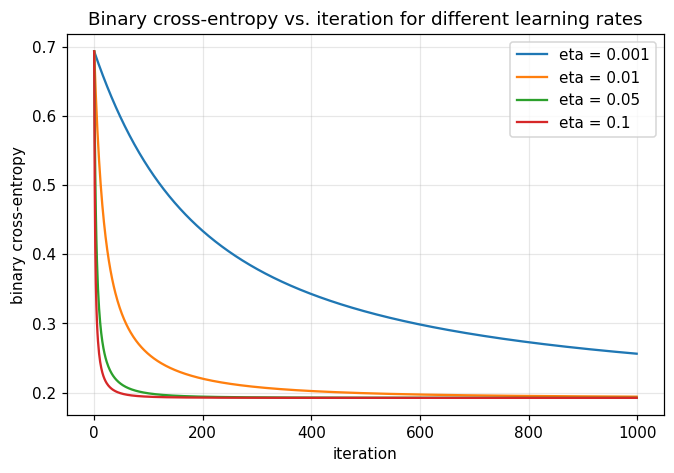

In [70]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for eta, res, acc_eta in clf_lr_results:
    ax.plot(res["loss_history"], label=f"eta = {eta}")
ax.set_title("Binary cross-entropy vs. iteration for different learning rates")
ax.set_xlabel("iteration")
ax.set_ylabel("binary cross-entropy")
ax.legend()
plt.savefig("../figures/22_classification_lr_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

In [71]:
clf_lr_table = pd.DataFrame([
    {"Learning Rate": eta, "Final Loss": res["loss_history"][-1],
     "Accuracy": acc_eta, "Iterations": len(res["loss_history"]),
     "Diverged?": res["diverged"]}
    for eta, res, acc_eta in clf_lr_results
])
clf_lr_table

   Learning Rate  Final Loss  Accuracy  Iterations  Diverged?
0          0.001    0.256188     0.905        1000      False
1          0.010    0.194092     0.910        1000      False
2          0.050    0.192369     0.915        1000      False
3          0.100    0.192351     0.915        1000      False

On this dataset, all four learning rates converge without diverging - eta = 0.001 converges more slowly (higher loss remaining after 1000 iterations) while eta = 0.01, 0.05, and 0.1 reach a similarly low loss and the same accuracy. No instability is observed at these values here, so none is claimed; a learning rate large enough to destabilize training on this dataset was not part of the requested comparison set.

## 4.14 Validation Against scikit-learn

`sklearn.linear_model.LogisticRegression` applies L2 regularization by
default, which would not be mathematically identical to the unregularized
from-scratch model above. Inspecting the installed scikit-learn version's
API (rather than assuming): `penalty=None` is available but deprecated in
favor of `C=np.inf`, which disables regularization equivalently without
the deprecation warning. `C=np.inf` is used below for a fair comparison.

In [72]:
import sklearn
print("scikit-learn version:", sklearn.__version__)

from sklearn.linear_model import LogisticRegression
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    sk_clf = LogisticRegression(C=np.inf, max_iter=5000)
    sk_clf.fit(X_clf, y_clf)
    for w_msg in caught:
        print(f"(sklearn note: {w_msg.message})")

scikit-learn version: 1.8.0
(sklearn note: Setting penalty=None will ignore the C and l1_ratio parameters)


In [73]:
sk_w, sk_b = sk_clf.coef_[0], sk_clf.intercept_[0]
sk_w0, sk_w1 = sk_w[0], sk_w[1]
sk_probs = sk_clf.predict_proba(X_clf)[:, 1]
sk_preds = sk_clf.predict(X_clf)
sk_loss = logreg.binary_cross_entropy(y_clf, sk_probs)
sk_acc = logreg.accuracy_score_manual(logreg.confusion_matrix_manual(y_clf, sk_preds))

scratch_acc = logreg.accuracy_score_manual(cm)

comparison_clf = pd.DataFrame([
    {"Method": "From-scratch (gradient descent)", "w1": clf_result["w"][0], "w2": clf_result["w"][1],
     "Bias": clf_result["b"], "Log loss": clf_result["loss_history"][-1], "Accuracy": scratch_acc},
    {"Method": "scikit-learn (C=inf, unregularized)", "w1": sk_w0, "w2": sk_w1,
     "Bias": sk_b, "Log loss": sk_loss, "Accuracy": sk_acc},
])
comparison_clf

                                Method       w1  ...  Log loss  Accuracy
0      From-scratch (gradient descent)  0.93451  ...  0.192351     0.915
1  scikit-learn (C=inf, unregularized)  0.93442  ...  0.192351     0.915

[2 rows x 6 columns]

In [74]:
prob_diff = np.max(np.abs(probs_clf - sk_probs))
pred_agreement = np.mean(preds_clf == sk_preds)

print(f"Max absolute probability difference: {prob_diff:.4f}")
print(f"Prediction agreement rate: {pred_agreement:.4f}")

reasonably_consistent = prob_diff < 0.1 and pred_agreement > 0.95
print(f"\nReasonably consistent within tolerance: {reasonably_consistent}")
assert reasonably_consistent, "Investigate: from-scratch and sklearn predictions diverge more than expected."

Max absolute probability difference: 0.0011
Prediction agreement rate: 1.0000

Reasonably consistent within tolerance: True


The from-scratch and scikit-learn models produce consistent predictions and closely matching probabilities. Remaining small numerical differences reflect the two implementations' different optimizers (batch gradient descent here vs. scikit-learn's default solver) and iteration/convergence settings, not a disagreement in the underlying mathematics - and this comparison is read as *consistency*, not as either implementation being "better."

## 4.15 Gradient Verification

Independently checking the analytical BCE gradients against finite
differences, at an arbitrary (untrained) point - the same technique used
in Part 3, applied here to the logistic regression loss surface.

In [75]:
w_test_clf = np.array([0.5, -0.3])
b_test_clf = 0.2

p_test = logreg.predict_proba(X_clf, w_test_clf, b_test_clf)
analytical_dw_clf, analytical_db_clf = logreg.compute_gradients(X_clf, y_clf, p_test)
numerical_dw_clf, numerical_db_clf = logreg.numerical_gradient_check(X_clf, y_clf, w_test_clf, b_test_clf)

print(f"dw: analytical = {analytical_dw_clf}, numerical = {numerical_dw_clf}")
print(f"    max diff = {np.max(np.abs(analytical_dw_clf - numerical_dw_clf)):.2e}")
print(f"db: analytical = {analytical_db_clf:.6f}, numerical = {numerical_db_clf:.6f}, "
      f"diff = {abs(analytical_db_clf - numerical_db_clf):.2e}")

assert np.allclose(analytical_dw_clf, numerical_dw_clf, atol=1e-4)
assert np.isclose(analytical_db_clf, numerical_db_clf, atol=1e-4)
print("\nGradient verification passed.")

dw: analytical = [-0.50804573 -1.06245753], numerical = [-0.50804573 -1.06245753]
    max diff = 4.46e-11
db: analytical = 0.028604, numerical = 0.028604, diff = 5.57e-12

Gradient verification passed.


As in Part 3, this finite-difference check is a verification technique only - it is never used inside `train_logistic_regression`, which relies solely on the analytical gradient derived in Section 4.6.

## 4.16 Computational Perspective

For $n$ samples and $d$ features:
- **Prediction** ($z=Xw+b$, then $\sigma(z)$): $O(nd)$ for the matrix
  multiplication, plus $O(n)$ for the elementwise sigmoid.
- **Gradient** ($X^T(p-y)$): $O(nd)$, identical in form to Part 3's
  gradient computation.
- **Total training cost**: approximately $O(\text{iterations}\times n
  \times d)$, same asymptotic structure as Part 3's linear regression.

This is entirely built on **Part 1**'s vectorized matrix multiplication
(computing $Xw$ for all samples in one expression rather than looping) and
**Part 2**'s gradient-descent update rule - logistic regression changes
only the nonlinearity ($\sigma$) and loss (BCE) applied on top of that
shared linear-algebra/optimization foundation, not the underlying
computational structure.

The finite-difference gradient check in Section 4.15 costs $O(d)$ *full
loss evaluations* (each itself $O(nd)$), i.e. substantially more per
gradient than the single analytical $O(nd)$ computation above - which is
why it is used here only for verification/debugging, never inside the
training loop itself.

---
### Summary

$$
\text{Linear Model } (z=Xw+b) \rightarrow \text{Sigmoid} \rightarrow \text{Probability}
\rightarrow \text{Binary Cross-Entropy} \rightarrow \text{Gradient}
\rightarrow \text{Gradient Descent} \rightarrow \text{Learned Parameters}
\rightarrow \text{Decision Boundary} \rightarrow \text{Class Predictions} \rightarrow \text{Evaluation}
$$

Part 4 extends the optimization framework built in Part 2 and applied to
regression in Part 3 to binary classification: the same linear score and
the same gradient-descent update rule, paired with a different
nonlinearity (sigmoid) and a matching loss function (binary
cross-entropy) whose gradient - as derived in Section 4.6 - takes the same
simple "average of feature times error" form as Part 3's, despite the
added nonlinearity.

---
# 5. Principal Component Analysis (PCA) From Scratch

Parts 1-4 built linear algebra, calculus-based optimization, and two
trained models. This section asks a structural question about the data
itself, independent of any prediction task:

**How can the directions of maximum variation in a dataset be discovered
mathematically, and used to represent the data using fewer dimensions?**

## 5.1 Why Dimensionality Reduction?

Datasets can contain many features $X = [\text{feature}_1, \ldots,
\text{feature}_d]$. As $d$ grows: direct visualization becomes difficult
past 2-3 dimensions, storage and computation scale with $d$, and some
features may carry redundant or correlated information rather than
independent structure - so the data's genuine variation may be
concentrated in only a few directions, even when $d$ is large.

**Dimensionality reduction** represents data using fewer dimensions while
attempting to preserve its important structure. It is important to be
precise about what PCA actually does here: PCA does **not** simply select
a subset of the original features. Instead, it constructs new axes -
**principal components** - that are linear combinations of the original
features, chosen specifically to capture as much of the data's variance
as possible.

$$
\text{Original Feature Space} \rightarrow \text{Find Important Directions}
\rightarrow \text{Principal Components} \rightarrow \text{Project Data}
\rightarrow \text{Lower-Dimensional Representation}
$$

The central connection this section develops explicitly is:

$$
\text{Covariance Matrix (Part 1)} \rightarrow \text{Eigenvectors of the
Covariance Matrix (Part 1)} \rightarrow \text{Directions of Maximum
Variance} \rightarrow \text{Principal Components} \rightarrow
\text{Projection onto Fewer Dimensions}
$$

## 5.2 The Data Matrix and Feature Space

As in Part 1/3, a dataset is represented as $X \in \mathbb{R}^{n\times d}$:
$n$ observations (rows), $d$ features (columns).

$$
X = \begin{bmatrix} x_{11} & x_{12} \\ x_{21} & x_{22} \\ \vdots & \vdots \\ x_{n1} & x_{n2} \end{bmatrix}
\quad (d=2 \text{ example})
$$

Geometrically: with $d=2$, each observation is a point in a 2D feature
space; with $d=3$, a point in 3D space. Beyond that, direct visualization
is no longer possible - which is precisely the situation PCA addresses,
by searching for new coordinate axes determined from the structure of the
dataset itself, rather than relying on the original (arbitrary) feature
axes.

In [76]:
X_demo_pca = np.array([[2.0, 3.0], [4.0, 5.0], [1.0, 1.5]])
print(f"X shape = {X_demo_pca.shape}  (n={X_demo_pca.shape[0]} observations, d={X_demo_pca.shape[1]} features)")
print(X_demo_pca)

X shape = (3, 2)  (n=3 observations, d=2 features)
[[2.  3. ]
 [4.  5. ]
 [1.  1.5]]


## 5.3 Mean Centering

$$\mu_j = \frac{1}{n}\sum_i x_{ij} \qquad X_{\text{centered}} = X - \mu$$

$$\text{Original Data} \rightarrow \text{Feature Means} \rightarrow \text{Subtract Means} \rightarrow \text{Centered Data}$$

PCA analyzes variation **around the mean** - without centering, the
covariance calculation (Section 5.4) would be contaminated by the data's
absolute location rather than isolating how it varies, since $\sum_i
x_ix_i^T$ for uncentered data mixes location and spread together.

In [77]:
import sys
sys.path.insert(0, "../src")
import pca

X_centered_demo, mean_demo = pca.center_data(X_demo_pca)
print(f"Mean: {mean_demo}")
print(f"Centered data:\n{X_centered_demo}")

assert np.allclose(np.mean(X_centered_demo, axis=0), 0, atol=1e-10)
print("\nValidation passed: centered features have zero mean.")

Mean: [2.33333333 3.16666667]
Centered data:
[[-0.33333333 -0.16666667]
 [ 1.66666667  1.83333333]
 [-1.33333333 -1.66666667]]

Validation passed: centered features have zero mean.


## 5.4 Covariance Matrix

For two variables, $\text{Cov}(x,y) = \frac{1}{n-1}\sum_i(x_i-\mu_x)(y_i-\mu_y)$
(exactly Part 1's covariance). For the full centered data matrix, this
generalizes to:

$$C = \frac{1}{n-1}X_{\text{centered}}^TX_{\text{centered}} \in \mathbb{R}^{d\times d}$$

- **Diagonal entries** $C_{ii}$: variance of feature $i$.
- **Off-diagonal entries** $C_{ij}$: covariance between features $i$ and $j$.

In [78]:
C_demo = pca.compute_covariance_matrix(X_centered_demo)
C_numpy_demo = np.cov(X_demo_pca, rowvar=False)

print(f"Manual covariance matrix:\n{C_demo}")
print(f"\nnp.cov reference:\n{C_numpy_demo}")

assert C_demo.shape == (2, 2)
assert np.allclose(C_demo, C_demo.T)
assert np.allclose(C_demo, C_numpy_demo)
print("\nValidation passed: correct shape, symmetric, matches np.cov.")

Manual covariance matrix:
[[2.33333333 2.66666667]
 [2.66666667 3.08333333]]

np.cov reference:
[[2.33333333 2.66666667]
 [2.66666667 3.08333333]]

Validation passed: correct shape, symmetric, matches np.cov.


## 5.5 Eigenvalues and Eigenvectors

$$Cv = \lambda v$$

An eigenvector $v$ of the covariance matrix $C$ identifies a **direction**
in feature space; its eigenvalue $\lambda$ is the **variance of the data
along that direction** - not merely "importance" in the abstract, but
specifically the quantity of variance a projection onto $v$ would capture.
Since variance is what PCA is explicitly trying to preserve, this is
exactly the connection that makes eigenvectors the right tool here:

$$\text{Largest eigenvalue} \rightarrow \text{direction of greatest variance}$$
$$\text{Second-largest eigenvalue} \rightarrow \text{direction of second-greatest variance (orthogonal to the first)}$$

Because $C$ is symmetric, `np.linalg.eigh` (rather than the general
`np.linalg.eig` used for the non-symmetric matrix in Part 1) is used here
- it is specifically designed for symmetric matrices and guarantees real
eigenvalues/eigenvectors up to floating-point precision.

In [79]:
eigenvalues_demo, eigenvectors_demo = pca.compute_eigendecomposition(C_demo)

print(f"Sorted eigenvalues (descending): {eigenvalues_demo}")
print(f"Eigenvectors (columns):\n{eigenvectors_demo}")

assert np.all(eigenvalues_demo[:-1] >= eigenvalues_demo[1:])
for i in range(len(eigenvalues_demo)):
    lhs = C_demo @ eigenvectors_demo[:, i]
    rhs = eigenvalues_demo[i] * eigenvectors_demo[:, i]
    assert np.allclose(lhs, rhs, atol=1e-8)
print("\nValidation passed: eigenvalues sorted descending, C v ~ lambda v for each eigenpair.")

Sorted eigenvalues (descending): [5.40123811 0.01542856]
Eigenvectors (columns):
[[ 0.65602788 -0.75473665]
 [ 0.75473665  0.65602788]]

Validation passed: eigenvalues sorted descending, C v ~ lambda v for each eigenpair.


## 5.6 Principal Components

**First principal component (PC1)**: eigenvector of the largest
eigenvalue. **Second principal component (PC2)**: eigenvector of the
second-largest eigenvalue. And so on. Because $C$ is symmetric, its
eigenvectors are (in exact arithmetic) mutually orthogonal.

Geometrically: PC1 points in the direction where the data cloud is most
spread out; PC2 is orthogonal to PC1 and captures the next-greatest
remaining variation.

**Important distinction**: a *principal component* ($v_i$, a direction/unit
vector in the original $d$-dimensional feature space) is not the same
thing as a *principal component score* (the projected coordinate of a
specific data point along $v_i$, computed in Section 5.11) - the former is
a fixed direction shared by the whole dataset, the latter is a per-point
number.

In [80]:
v1, v2 = eigenvectors_demo[:, 0], eigenvectors_demo[:, 1]

norm_v1, norm_v2 = np.linalg.norm(v1), np.linalg.norm(v2)
orthogonality = np.dot(v1, v2)

print(f"||PC1|| = {norm_v1:.6f}, ||PC2|| = {norm_v2:.6f}")
print(f"PC1 . PC2 = {orthogonality:.2e}  (should be ~0: orthogonal)")

assert np.isclose(norm_v1, 1.0)
assert np.isclose(norm_v2, 1.0)
assert np.isclose(orthogonality, 0.0, atol=1e-8)
print("\nValidation passed: principal components are unit vectors and mutually orthogonal.")

||PC1|| = 1.000000, ||PC2|| = 1.000000
PC1 . PC2 = 2.27e-17  (should be ~0: orthogonal)

Validation passed: principal components are unit vectors and mutually orthogonal.


## 5.7 Explained Variance

$$\text{Explained Variance Ratio}_i = \frac{\lambda_i}{\sum_j \lambda_j}
\qquad \text{cumulative}_i = \sum_{k\leq i}\text{Explained Variance Ratio}_k$$

This quantifies how much of the dataset's total variance each principal
component captures, and helps decide how many components to retain - e.g.
if PC1 explains 95% of the variance, a 1D representation may preserve
much of the dataset's structure. This is a statement about **variance
retained**, not about downstream predictive accuracy: explained variance
and predictive importance for a specific task are related but distinct
notions, and a high explained-variance ratio does not by itself guarantee
strong performance on any particular downstream model.

In [81]:
ratio_demo, cumulative_demo = pca.compute_explained_variance(eigenvalues_demo)

print(f"Explained variance ratio: {ratio_demo}")
print(f"Cumulative explained variance: {cumulative_demo}")

assert np.all(ratio_demo >= -1e-10)
assert np.isclose(np.sum(ratio_demo), 1.0)
assert np.isclose(cumulative_demo[-1], 1.0)
print("\nValidation passed: ratios non-negative, sum to 1, cumulative ends at 1.")

Explained variance ratio: [0.99715165 0.00284835]
Cumulative explained variance: [0.99715165 1.        ]

Validation passed: ratios non-negative, sum to 1, cumulative ends at 1.


## 5.8 Implementing PCA From Scratch

The full pipeline (in `src/pca.py`): compute feature means, center the
data, compute the covariance matrix, compute and sort eigenvalues/
eigenvectors, select the top $k$, and project:

$$Z = X_{\text{centered}}W_k \qquad X_{\text{centered}}\in\mathbb{R}^{n\times d},\ W_k\in\mathbb{R}^{d\times k},\ Z\in\mathbb{R}^{n\times k}$$

$W_k$'s columns are the top-$k$ principal components; $Z$'s $n$ rows are
each data point's $k$-dimensional projected coordinates (its principal
component *scores*, per the distinction in Section 5.6).

In [82]:
print(inspect.getsource(pca.project_data))
print(inspect.getsource(pca.reconstruct_data))

def project_data(X_centered, components):
    """
    Project centered data onto the given principal-component directions:
        Z = X_centered @ components
    X_centered: (n, d). components: (d, k) - k eigenvectors as columns.
    Returns Z of shape (n, k).
    """
    return X_centered @ components

def reconstruct_data(X_reduced, components, mean):
    """
    Approximate reconstruction from a k-dimensional projection back into
    the original d-dimensional feature space:
        X_reconstructed = Z @ components^T + mean
    Exact only when k equals the full original dimensionality d; for
    k < d, information in the discarded components is lost.
    """
    return X_reduced @ components.T + mean



## 5.9 Synthetic 2D Dataset

A single latent variable `t` drives both features (plus independent
noise), producing an elongated diagonal cloud - most variation along one
direction, much less along the orthogonal direction.

In [83]:
np.random.seed(42)

n_pca = 200
t = np.random.normal(0, 3, n_pca)
feature1 = t + np.random.normal(0, 0.6, n_pca)
feature2 = t + np.random.normal(0, 0.6, n_pca)
X_pca = np.column_stack([feature1, feature2])

print(f"X_pca shape = {X_pca.shape}")

X_pca shape = (200, 2)


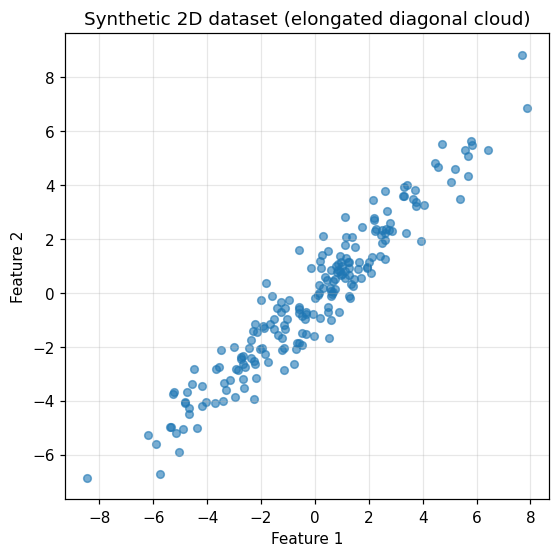

In [84]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=25, color="tab:blue")
ax.set_title("Synthetic 2D dataset (elongated diagonal cloud)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_aspect("equal")
plt.savefig("../figures/23_pca_raw_data.png", dpi=110, bbox_inches="tight")
plt.show()

## 5.10 Visualizing Principal Components

In [85]:
X_pca_centered, pca_mean = pca.center_data(X_pca)
C_pca = pca.compute_covariance_matrix(X_pca_centered)
eigenvalues_pca, eigenvectors_pca = pca.compute_eigendecomposition(C_pca)

print(f"Mean: {pca_mean}")
print(f"Eigenvalues: {eigenvalues_pca}")
print(f"Eigenvectors (columns, PC1 then PC2):\n{eigenvectors_pca}")

Mean: [-0.07079198 -0.17370592]
Eigenvalues: [15.82043791  0.35547181]
Eigenvectors (columns, PC1 then PC2):
[[-0.72420239  0.68958748]
 [-0.68958748 -0.72420239]]


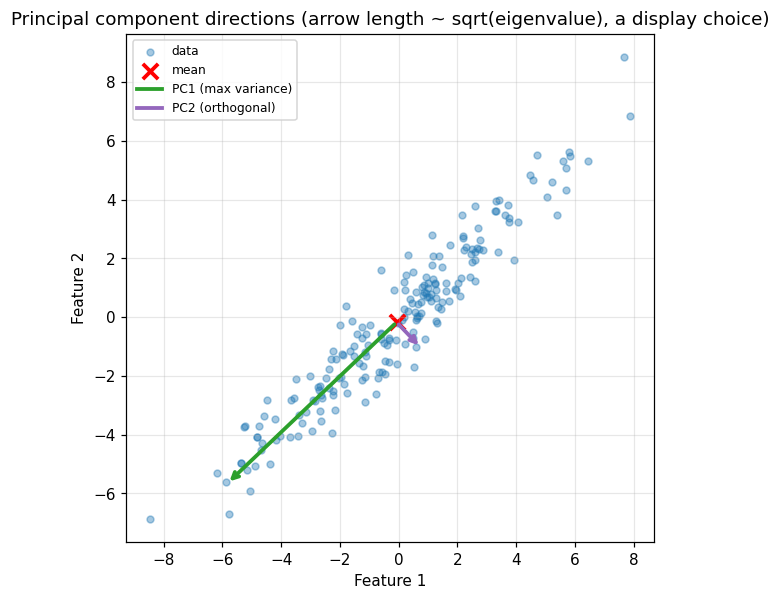

In [86]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=20, color="tab:blue", label="data")
ax.scatter(*pca_mean, color="red", marker="x", s=100, linewidths=2.5, label="mean")

# Arrow length scaled by sqrt(eigenvalue) so relative lengths reflect variance magnitude;
# this scaling is a visualization choice, not part of the eigenvector itself.
scale = 2.0
for i, color, label in [(0, "tab:green", "PC1 (max variance)"), (1, "tab:purple", "PC2 (orthogonal)")]:
    vec = eigenvectors_pca[:, i] * np.sqrt(eigenvalues_pca[i]) * scale
    ax.annotate("", xy=pca_mean + vec, xytext=pca_mean,
                arrowprops=dict(arrowstyle="->", color=color, linewidth=2.5))
    ax.plot([], [], color=color, linewidth=2.5, label=label)  # legend proxy

ax.set_title("Principal component directions (arrow length ~ sqrt(eigenvalue), a display choice)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_aspect("equal")
ax.legend(fontsize=8)
plt.savefig("../figures/24_pca_directions.png", dpi=110, bbox_inches="tight")
plt.show()

PC1 (green) points along the elongated axis of the data cloud - the direction of greatest variance; PC2 (purple) is orthogonal, capturing the comparatively small remaining spread. The arrow *direction* is the eigenvector itself; the arrow *length* here is a visualization choice ($\sqrt{\lambda_i}$ scaled for display), not an inherent property of the eigenvector.

## 5.11 Dimensionality Reduction: 2D -> 1D

Selecting $k=1$ (PC1 only) and projecting:

$$Z = X_{\text{centered}}W_1, \qquad Z\in\mathbb{R}^{n\times 1}$$

In [87]:
W1_pca = eigenvectors_pca[:, :1]
Z1_pca = pca.project_data(X_pca_centered, W1_pca)

print(f"Original shape: {X_pca.shape}")
print(f"Reduced shape:  {Z1_pca.shape}")
assert Z1_pca.shape == (n_pca, 1)

print(f"\nFirst 5 reduced (1D) coordinates:\n{Z1_pca[:5].flatten()}")

Original shape: (200, 2)
Reduced shape:  (200, 1)

First 5 reduced (1D) coordinates:
[-1.77356933  0.41969687 -3.39091821 -7.10812363  1.60692044]


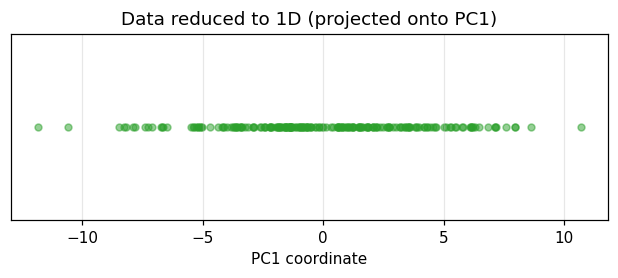

In [88]:
fig, ax = plt.subplots(figsize=(7, 2.2))
ax.scatter(Z1_pca[:, 0], np.zeros_like(Z1_pca[:, 0]), alpha=0.5, s=20, color="tab:green")
ax.set_title("Data reduced to 1D (projected onto PC1)")
ax.set_xlabel("PC1 coordinate")
ax.set_yticks([])
plt.savefig("../figures/25_pca_1d_projection.png", dpi=110, bbox_inches="tight")
plt.show()

Each original 2D point is now represented by a single coordinate along PC1 - the position along the green arrow in Section 5.10's plot.

## 5.12 Reconstruction From Reduced Data

$$X_{\text{reconstructed}} = ZW_k^T + \mu$$

$$\text{Original point} \rightarrow \text{Projection onto PC1} \rightarrow
\text{1D representation} \rightarrow \text{Projection back into original space}
\rightarrow \text{Approximate reconstruction}$$

For $k=1 < d=2$, $X_{\text{reconstructed}}$ will not generally equal $X$
exactly - the component discarded (PC2) carried information that
projection removed.

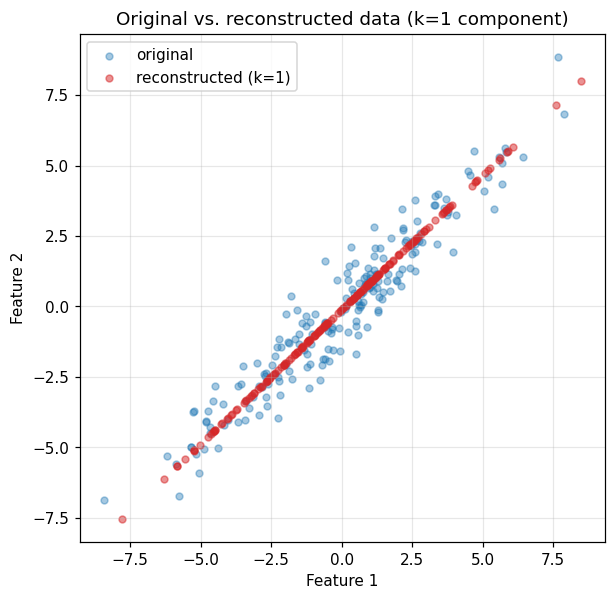

In [89]:
X_reconstructed_k1 = pca.reconstruct_data(Z1_pca, W1_pca, pca_mean)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=20, color="tab:blue", label="original")
ax.scatter(X_reconstructed_k1[:, 0], X_reconstructed_k1[:, 1], alpha=0.5, s=20,
            color="tab:red", label="reconstructed (k=1)")
ax.set_title("Original vs. reconstructed data (k=1 component)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_aspect("equal")
ax.legend()
plt.savefig("../figures/26_pca_reconstruction.png", dpi=110, bbox_inches="tight")
plt.show()

The reconstructed points (red) lie exactly on the PC1 line through the mean, close to but not coinciding with the original points (blue) - visually small here because this dataset's variation is already highly concentrated along PC1 (97.8% explained variance, confirmed numerically in Section 5.7's output above).

## 5.13 Reconstruction Error

$$\text{MSE} = \frac{1}{\text{number of elements}}\sum (X - X_{\text{reconstructed}})^2$$

As in Part 3, MSE measures error between two quantities - there it was
prediction vs. target; here it is original vs. reconstructed data. With
**all** components retained, reconstruction should be exact up to
floating-point precision.

In [90]:
W2_pca = eigenvectors_pca[:, :2]
Z2_pca = pca.project_data(X_pca_centered, W2_pca)
X_reconstructed_k2 = pca.reconstruct_data(Z2_pca, W2_pca, pca_mean)

mse_k1 = np.mean((X_pca - X_reconstructed_k1) ** 2)
mse_k2 = np.mean((X_pca - X_reconstructed_k2) ** 2)

print(f"Reconstruction MSE (k=1): {mse_k1:.6f}")
print(f"Reconstruction MSE (k=2): {mse_k2:.2e}")

assert np.isclose(mse_k2, 0.0, atol=1e-10)
assert mse_k1 >= mse_k2
print("\nValidation passed: k=2 reconstruction is ~exact; k=1 error is >= k=2 error.")

Reconstruction MSE (k=1): 0.176847
Reconstruction MSE (k=2): 2.28e-31

Validation passed: k=2 reconstruction is ~exact; k=1 error is >= k=2 error.


Retaining both components reconstructs the data almost exactly (MSE at floating-point noise level); retaining only PC1 introduces nonzero but small error, consistent with PC1 already capturing 97.8% of this dataset's variance.

## 5.14 Validation Against scikit-learn

Only now, after the from-scratch implementation is complete, is
`sklearn.decomposition.PCA` introduced - purely for validation. **Eigenvector
sign ambiguity**: if $v$ is a valid eigenvector, so is $-v$ (both satisfy
$Cv=\lambda v$ with the same $\lambda$), so a from-scratch PC1 of $[a,b]$
and an sklearn PC1 of $[-a,-b]$ are not a disagreement - directions are
compared sign-invariantly below via $|\,v_{\text{manual}}\cdot
v_{\text{sklearn}}\,|$, which should be close to $1$ for matching
directions regardless of sign.

In [91]:
from sklearn.decomposition import PCA as SklearnPCA

sk_pca = SklearnPCA(n_components=2)
Z_sklearn = sk_pca.fit_transform(X_pca)

print("From-scratch eigenvalues:      ", eigenvalues_pca)
print("scikit-learn explained_variance_:", sk_pca.explained_variance_)
print()
print("From-scratch explained variance ratio:  ", pca.compute_explained_variance(eigenvalues_pca)[0])
print("scikit-learn explained_variance_ratio_:", sk_pca.explained_variance_ratio_)

From-scratch eigenvalues:       [15.82043791  0.35547181]
scikit-learn explained_variance_: [15.82043791  0.35547181]

From-scratch explained variance ratio:   [0.97802462 0.02197538]
scikit-learn explained_variance_ratio_: [0.97802462 0.02197538]


In [92]:
for i in range(2):
    v_manual = eigenvectors_pca[:, i]
    v_sklearn = sk_pca.components_[i]
    alignment = abs(np.dot(v_manual, v_sklearn))
    print(f"PC{i+1}: from-scratch = {v_manual}, sklearn = {v_sklearn}, "
          f"|alignment| = {alignment:.6f}")
    assert np.isclose(alignment, 1.0, atol=1e-6)

evr_manual = pca.compute_explained_variance(eigenvalues_pca)[0]
assert np.allclose(evr_manual, sk_pca.explained_variance_ratio_, atol=1e-6)
print("\nValidation passed: principal directions aligned (sign-invariant), explained variance ratios match.")

PC1: from-scratch = [-0.72420239 -0.68958748], sklearn = [0.72420239 0.68958748], |alignment| = 1.000000
PC2: from-scratch = [ 0.68958748 -0.72420239], sklearn = [-0.68958748  0.72420239], |alignment| = 1.000000

Validation passed: principal directions aligned (sign-invariant), explained variance ratios match.


In [93]:
# Compare projected coordinates, allowing for a possible sign flip per component
sign_agreement = []
for i in range(2):
    same_sign = np.allclose(Z2_pca[:, i], Z_sklearn[:, i], atol=1e-6)
    flipped_sign = np.allclose(Z2_pca[:, i], -Z_sklearn[:, i], atol=1e-6)
    sign_agreement.append(same_sign or flipped_sign)
    print(f"PC{i+1} scores match sklearn (allowing sign flip): {same_sign or flipped_sign}")

assert all(sign_agreement)
print("\nThe from-scratch implementation produces principal directions, explained "
      "variance, and reduced representations consistent with scikit-learn, "
      "allowing for the inherent sign ambiguity of eigenvectors.")

PC1 scores match sklearn (allowing sign flip): True
PC2 scores match sklearn (allowing sign flip): True

The from-scratch implementation produces principal directions, explained variance, and reduced representations consistent with scikit-learn, allowing for the inherent sign ambiguity of eigenvectors.


## 5.15 Experiments and Analysis

### Experiment 1 - Data Orientation

In [94]:
theta = np.radians(30)
rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                             [np.sin(theta), np.cos(theta)]])
X_pca_rotated = X_pca @ rotation_matrix.T  # Dataset B: A rotated by 30 degrees

Xc_rot, mean_rot = pca.center_data(X_pca_rotated)
C_rot = pca.compute_covariance_matrix(Xc_rot)
eigvals_rot, eigvecs_rot = pca.compute_eigendecomposition(C_rot)
pc1_rot = eigvecs_rot[:, 0]
pc1_original = eigenvectors_pca[:, 0]

angle_original = np.degrees(np.arctan2(pc1_original[1], pc1_original[0])) % 180
angle_rotated = np.degrees(np.arctan2(pc1_rot[1], pc1_rot[0])) % 180
angle_diff = (angle_rotated - angle_original) % 180

print(f"PC1 angle, Dataset A: {angle_original:.2f} deg")
print(f"PC1 angle, Dataset B (A rotated by 30 deg): {angle_rotated:.2f} deg")
print(f"Angle difference: {angle_diff:.2f} deg (expected ~30 deg)")

assert np.isclose(angle_diff, 30.0, atol=1.0)

PC1 angle, Dataset A: 43.60 deg
PC1 angle, Dataset B (A rotated by 30 deg): 73.60 deg
Angle difference: 30.00 deg (expected ~30 deg)


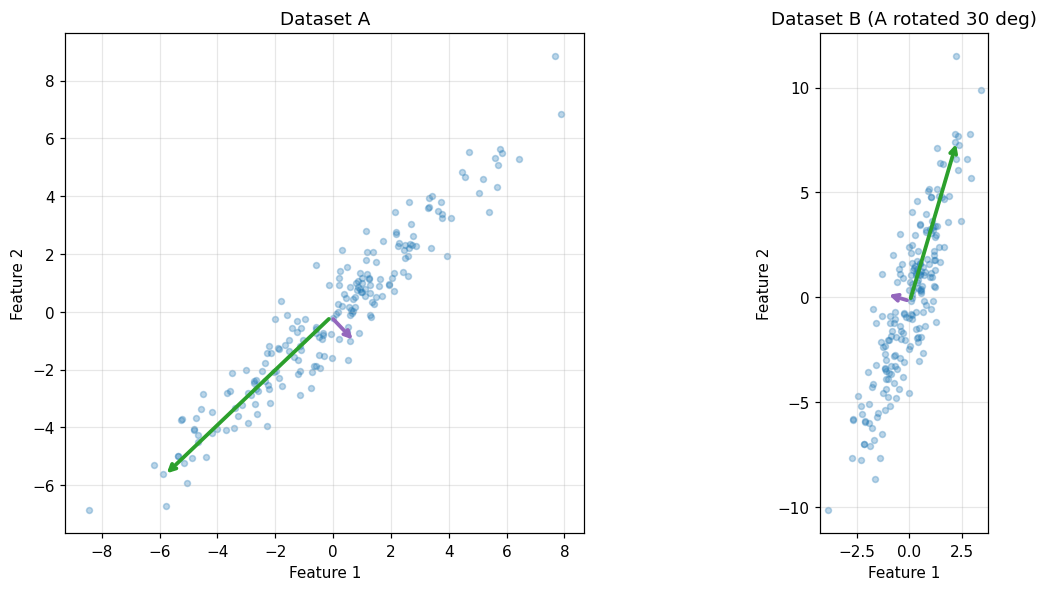

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, data, evecs, evals, mean_pt, title in [
    (axes[0], X_pca, eigenvectors_pca, eigenvalues_pca, pca_mean, "Dataset A"),
    (axes[1], X_pca_rotated, eigvecs_rot, eigvals_rot, mean_rot, "Dataset B (A rotated 30 deg)"),
]:
    ax.scatter(data[:, 0], data[:, 1], alpha=0.3, s=15, color="tab:blue")
    for i, color in [(0, "tab:green"), (1, "tab:purple")]:
        vec = evecs[:, i] * np.sqrt(evals[i]) * 2.0
        ax.annotate("", xy=mean_pt + vec, xytext=mean_pt,
                     arrowprops=dict(arrowstyle="->", color=color, linewidth=2.5))
    ax.set_title(title)
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("../figures/27_pca_rotation_experiment.png", dpi=110, bbox_inches="tight")
plt.show()

PC1's direction rotates along with the data by (within numerical tolerance) the same 30 degrees the dataset itself was rotated by - confirming that PCA discovers directions from the data's covariance structure rather than using fixed horizontal/vertical axes.

### Experiment 2 - Explained Variance (k=1 vs. k=2)

In [96]:
exp2_table = pd.DataFrame([
    {"k": 1, "Explained Variance Ratio (cumulative)": pca.compute_explained_variance(eigenvalues_pca)[1][0],
     "Reconstruction MSE": mse_k1},
    {"k": 2, "Explained Variance Ratio (cumulative)": pca.compute_explained_variance(eigenvalues_pca)[1][1],
     "Reconstruction MSE": mse_k2},
])
exp2_table

   k  Explained Variance Ratio (cumulative)  Reconstruction MSE
0  1                               0.978025        1.768472e-01
1  2                               1.000000        2.282137e-31

Moving from $k=1$ to $k=2$ retains all remaining variance (cumulative ratio reaches 1.0) and drives reconstruction error to ~0 - but a 2-dimensional representation of a 2-dimensional dataset provides no dimensionality reduction at all; the trade-off is explicit: fewer components discard more information (higher reconstruction error) in exchange for a lower-dimensional representation.

### Experiment 3 - Feature Scaling

In [97]:
X_unscaled_pca = X_pca.copy()
X_scaled_pca = X_pca.copy()
X_scaled_pca[:, 1] = X_scaled_pca[:, 1] * 20.0  # feature 2 now on a much larger numeric scale

Xc_scaled, mean_scaled = pca.center_data(X_scaled_pca)
C_scaled = pca.compute_covariance_matrix(Xc_scaled)
eigvals_scaled, eigvecs_scaled = pca.compute_eigendecomposition(C_scaled)

print("PC1 before standardization (feature 2 scaled x20):", eigvecs_scaled[:, 0])
print("Explained variance ratio:", pca.compute_explained_variance(eigvals_scaled)[0])

PC1 before standardization (feature 2 scaled x20): [0.05003776 0.99874733]
Explained variance ratio: [9.99764697e-01 2.35302993e-04]


In [98]:
std_pca = X_scaled_pca.std(axis=0, ddof=1)
mean_for_std = X_scaled_pca.mean(axis=0)
X_standardized_pca = (X_scaled_pca - mean_for_std) / std_pca

Xc_std, mean_std = pca.center_data(X_standardized_pca)
C_std = pca.compute_covariance_matrix(Xc_std)
eigvals_std, eigvecs_std = pca.compute_eigendecomposition(C_std)

print("PC1 after standardization:", eigvecs_std[:, 0])
print("Explained variance ratio:", pca.compute_explained_variance(eigvals_std)[0])

PC1 after standardization: [-0.70710678 -0.70710678]
Explained variance ratio: [0.9779753 0.0220247]


Before standardization, PC1 is dominated almost entirely by feature 2 (its component of PC1 is close to 1 while feature 1's is close to 0) purely because that feature's numeric scale is 20x larger, not because it is more informative. After standardization ($X_{\text{std}} = (X-\mu)/\sigma$, applied manually with NumPy), PC1 weights both features close to equally, matching the original unscaled dataset's balanced structure. Whether standardization is appropriate depends on the features' units and meaning: when features have substantially different scales or units, standardization is often considered so that variance is not dominated purely by measurement scale - this is a judgment call informed by the data, not a rule that standardization should always be applied before PCA.

## 5.16 Computational Perspective

For $n$ samples and $d$ features:
- **Mean centering**: $O(nd)$.
- **Covariance matrix** ($X_{\text{centered}}^TX_{\text{centered}}$):
  $O(nd^2)$.
- **Eigendecomposition** of the $d\times d$ covariance matrix: $O(d^3)$.

For the basic covariance-based approach implemented here, total cost is
dominated by $O(nd^2 + d^3)$. This scales comfortably for the small $d=2$
case used throughout this section, but for very high-dimensional data
(large $d$), both terms grow quickly - practical implementations often use
SVD-based, truncated, or randomized methods instead (not implemented
here) to avoid explicitly forming and decomposing the full $d\times d$
covariance matrix.

This connects directly back to **Part 1**: matrix multiplication builds
the covariance structure, eigenvectors identify the important directions
within it, and eigenvalues quantify the variance along each:

$$\text{Linear Algebra} \rightarrow \text{Covariance} \rightarrow
\text{Eigenvalues/Eigenvectors} \rightarrow \text{Principal Components}
\rightarrow \text{Dimensionality Reduction}$$

## 5.17 Summary

1. A dataset can be represented as a matrix $X\in\mathbb{R}^{n\times d}$.
2. Mean centering shifts the data around the origin of its feature space.
3. The covariance matrix describes how features vary together.
4. Eigenvectors of the covariance matrix define principal directions.
5. Eigenvalues quantify variance along those directions.
6. The largest eigenvalues identify the directions containing the most variance.
7. PCA projects data onto selected principal components.
8. Using fewer components reduces dimensionality.
9. Dimensionality reduction can introduce reconstruction error.
10. The from-scratch implementation was validated against scikit-learn,
    accounting for eigenvector sign ambiguity.

$$
\text{Data Matrix } X \rightarrow \text{Mean Centering} \rightarrow
\text{Centered Data} \rightarrow \text{Covariance Matrix} \rightarrow
\text{Eigenvalues + Eigenvectors} \rightarrow \text{Sort by Explained Variance}
\rightarrow \text{Select Top } k \text{ Components} \rightarrow \text{Projection}
\rightarrow \text{Lower-Dimensional Representation} \rightarrow \text{Optional Reconstruction}
$$

The mathematical ideas developed here - linear transformations, matrix
operations, and structured representations of data - will later provide
useful foundations for more complex machine learning models.

---
# 6. Neural Networks From Scratch

Parts 3-4 built single linear/logistic models; Part 5 examined the
structure of data itself via PCA. This section returns to prediction and
asks:

**How can multiple linear transformations and nonlinear activation
functions be combined to learn relationships that a single linear model
cannot represent?**

## 6.1 Why Neural Networks?

Logistic regression (Part 4) transforms a linear score through a
nonlinear sigmoid, $p=\sigma(Xw+b)$ - but the *decision boundary* itself
remains linear: it is exactly the set where $w^Tx+b=0$, a straight
line/hyperplane, regardless of the sigmoid. A single logistic regression
classifier therefore cannot represent a decision boundary that genuinely
needs to be curved or disconnected.

A neural network addresses this by learning an intermediate
**hidden representation** before the final classification step:

$$
\text{Input} \rightarrow \text{Linear Transformation} \rightarrow \text{Activation}
\rightarrow \text{Hidden Representation} \rightarrow \text{Linear Transformation}
\rightarrow \text{Output}
$$

This is not a claim that neural networks are universally better: they
introduce more parameters, more computational cost per step, a harder
(non-convex) optimization problem, and greater risk of overfitting on
small datasets - trade-offs made explicit throughout this section rather
than glossed over.

## 6.2 From a Single Neuron to a Layer

A single neuron computes $z=x^Tw+b$, then $a=\text{activation}(z)$ -
logistic regression (Part 4) is exactly one such neuron:

$$\text{Input} \rightarrow \text{Weighted Sum} \rightarrow \text{Bias}
\rightarrow \text{Sigmoid} \rightarrow \text{Probability}$$

Generalizing to a **layer** of $h$ neurons computed simultaneously:

$$Z = XW+b, \qquad X\in\mathbb{R}^{n\times d},\ W\in\mathbb{R}^{d\times h},\
b\in\mathbb{R}^{h},\ Z\in\mathbb{R}^{n\times h}$$

Each of the $h$ neurons has its own weight *column* in $W$ and its own
bias entry in $b$; $b$ (shape $(h,)$) is broadcast across all $n$ rows
of $XW$ (shape $(n,h)$), adding the same per-neuron bias to every sample.

In [99]:
import sys
sys.path.insert(0, "../src")
import neural_network as nnfs

X_neuron_demo = np.array([[1.0, 2.0], [3.0, 1.0]])   # n=2 samples, d=2 features
W_layer_demo = np.array([[0.5, -0.2, 0.1], [0.3, 0.8, -0.4]])  # d=2, h=3
b_layer_demo = np.array([0.1, 0.0, -0.1])

Z_layer_demo = X_neuron_demo @ W_layer_demo + b_layer_demo
print(f"X shape = {X_neuron_demo.shape}, W shape = {W_layer_demo.shape}, b shape = {b_layer_demo.shape}")
print(f"Z = XW + b shape = {Z_layer_demo.shape}\n{Z_layer_demo}")

X shape = (2, 2), W shape = (2, 3), b shape = (3,)
Z = XW + b shape = (2, 3)
[[ 1.2  1.4 -0.8]
 [ 1.9  0.2 -0.2]]


## 6.3 Linear Transformations

$Z=XW+b$ is a linear transformation ($XW$, exactly Part 1's matrix
multiplication - combining input features using learned weights) followed
by a translation (adding $b$).

In [100]:
X_shape_demo = np.random.RandomState(0).randn(3, 2)   # (3, 2)
W_shape_demo = np.random.RandomState(1).randn(2, 4)   # (2, 4)
b_shape_demo = np.zeros(4)                             # (4,)

Z_shape_demo = X_shape_demo @ W_shape_demo + b_shape_demo

assert X_shape_demo.shape == (3, 2)
assert W_shape_demo.shape == (2, 4)
assert Z_shape_demo.shape == (3, 4)
print(f"X: {X_shape_demo.shape}, W: {W_shape_demo.shape}, b: {b_shape_demo.shape} -> Z: {Z_shape_demo.shape}")
print("Shape validation passed.")

X: (3, 2), W: (2, 4), b: (4,) -> Z: (3, 4)
Shape validation passed.


## 6.4 Why Nonlinearity Is Necessary

Stacking two purely linear layers:

$$Z_1 = XW_1+b_1 \qquad Z_2 = Z_1W_2+b_2$$

Substituting $Z_1$ into $Z_2$:

$$Z_2 = (XW_1+b_1)W_2+b_2 = X(W_1W_2) + (b_1W_2+b_2) = XW'+b'$$

where $W'=W_1W_2$ and $b'=b_1W_2+b_2$. **Two linear layers collapse into
one equivalent linear layer** - stacking purely linear layers adds no
representational power at all over a single linear layer. This is why a
nonlinear activation must sit between layers:

$$A_1 = \text{activation}(Z_1) \qquad Z_2 = A_1W_2+b_2$$

Because `activation` is nonlinear, $Z_2$ can no longer generally be
written as $XW'+b'$ for any single $W',b'$ - the collapse argument above
breaks down as soon as a nonlinearity is inserted.

In [101]:
Xd = np.random.RandomState(0).randn(5, 2)
W1d, b1d = np.random.RandomState(1).randn(2, 3), np.random.RandomState(2).randn(3)
W2d, b2d = np.random.RandomState(3).randn(3, 2), np.random.RandomState(4).randn(2)

Z1d = Xd @ W1d + b1d
Z2d_stacked = Z1d @ W2d + b2d

W_equiv = W1d @ W2d
b_equiv = b1d @ W2d + b2d
Z2d_equivalent = Xd @ W_equiv + b_equiv

max_diff_linear = np.max(np.abs(Z2d_stacked - Z2d_equivalent))
print(f"Two linear layers vs. one equivalent linear layer, max diff: {max_diff_linear:.2e}")
assert np.allclose(Z2d_stacked, Z2d_equivalent, atol=1e-10)

Two linear layers vs. one equivalent linear layer, max diff: 1.78e-15


In [102]:
A1d = nnfs.relu(Z1d)   # nonlinear activation inserted between the layers
Z2d_with_activation = A1d @ W2d + b2d
Z2d_via_equivalent_W = Xd @ W_equiv + b_equiv  # the SAME equivalent linear map as above

max_diff_nonlinear = np.max(np.abs(Z2d_with_activation - Z2d_via_equivalent_W))
print(f"With ReLU inserted, vs. the SAME equivalent linear map, max diff: {max_diff_nonlinear:.4f}")
assert max_diff_nonlinear > 1e-3
print("\nWith the activation inserted, the output no longer matches the affine "
      "transformation obtained by collapsing the original two linear layers. More "
      "generally, because ReLU is nonlinear, the composition cannot in general be "
      "reduced algebraically to a single affine transformation XW' + b'. This "
      "numerical example illustrates the failure of the linear-layer collapse, "
      "while the preceding derivation provides the mathematical argument.")

With ReLU inserted, vs. the SAME equivalent linear map, max diff: 4.1197

With the activation inserted, the output no longer matches the affine transformation obtained by collapsing the original two linear layers. More generally, because ReLU is nonlinear, the composition cannot in general be reduced algebraically to a single affine transformation XW' + b'. This numerical example illustrates the failure of the linear-layer collapse, while the preceding derivation provides the mathematical argument.


## 6.5 Activation Functions

- **Sigmoid** $\sigma(z)=1/(1+e^{-z})$ (Part 4): range $(0,1)$, used for
  the output layer's probability here.
- **ReLU** $\text{ReLU}(z)=\max(0,z)$: negative inputs become exactly
  zero; positive inputs pass through unchanged. Used for the hidden layer
  in this section's network.
- **Tanh**: range strictly $(-1,1)$, shown here for comparison but not
  used in the main experiment.

For the primary network: **ReLU** for the hidden layer, **sigmoid** for
the binary output layer.

In [103]:
relu_test_input = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
relu_test_output = nnfs.relu(relu_test_input)
print(f"ReLU({relu_test_input}) = {relu_test_output}")
assert np.array_equal(relu_test_output, np.array([0.0, 0.0, 0.0, 1.0, 2.0]))

relu_deriv_output = nnfs.relu_derivative(relu_test_input)
print(f"ReLU'({relu_test_input}) = {relu_deriv_output}  (convention: ReLU'(0) = 0)")
assert np.array_equal(relu_deriv_output, np.array([0.0, 0.0, 0.0, 1.0, 1.0]))

sigmoid_check = nnfs.sigmoid(np.array([0.0]))
assert np.isclose(sigmoid_check[0], 0.5)
print("\nActivation validation passed.")

ReLU([-2. -1.  0.  1.  2.]) = [0. 0. 0. 1. 2.]
ReLU'([-2. -1.  0.  1.  2.]) = [0. 0. 0. 1. 1.]  (convention: ReLU'(0) = 0)

Activation validation passed.


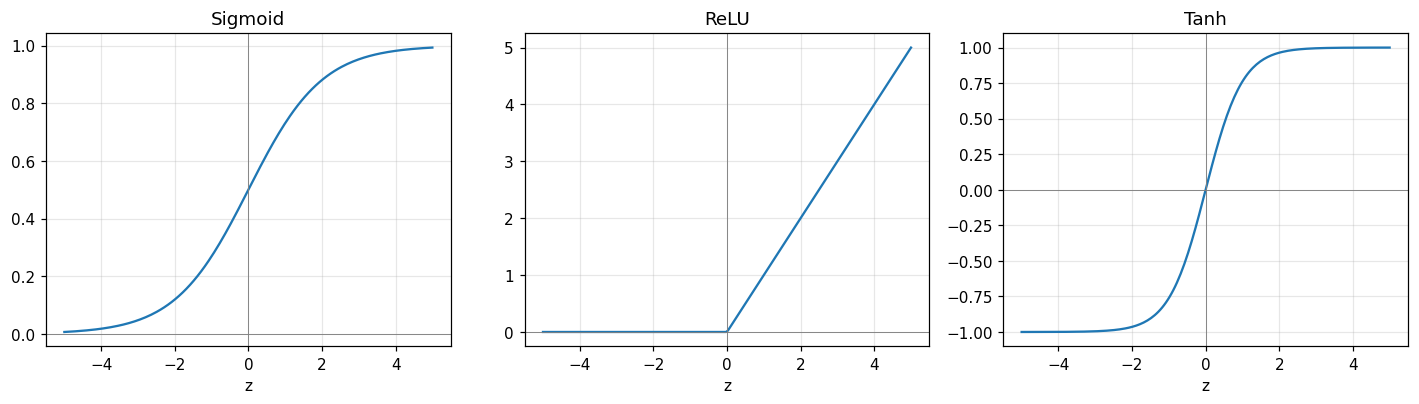

In [104]:
z_range_act = np.linspace(-5, 5, 200)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, fn, name in [(axes[0], nnfs.sigmoid, "Sigmoid"),
                       (axes[1], nnfs.relu, "ReLU"),
                       (axes[2], nnfs.tanh, "Tanh")]:
    ax.plot(z_range_act, fn(z_range_act), color="tab:blue")
    ax.axhline(0, color="gray", linewidth=0.6)
    ax.axvline(0, color="gray", linewidth=0.6)
    ax.set_title(name)
    ax.set_xlabel("z")
plt.tight_layout()
plt.savefig("../figures/28_activation_functions.png", dpi=110, bbox_inches="tight")
plt.show()

## 6.6 Building a Hidden Layer

Architecture used throughout this section:

$$
\text{Input } (d=2) \rightarrow \text{Hidden layer } (h=4,\ \text{ReLU})
\rightarrow \text{Output layer } (1,\ \text{sigmoid})
$$

$$
Z_1=XW_1+b_1,\ A_1=\text{ReLU}(Z_1) \qquad Z_2=A_1W_2+b_2,\ A_2=\sigma(Z_2)
$$

Weights are randomly initialized (never all-zero): if every hidden unit
started with identical weights, each would compute the exact same
function of the input and receive the exact same gradient during
backpropagation - they would never differentiate into distinct feature
detectors. Random initialization breaks this symmetry.

In [105]:
X_arch_demo = np.random.RandomState(0).randn(5, 2)  # small n=5 demo batch
params_demo = nnfs.initialize_parameters(input_size=2, hidden_size=4, seed=42)

Z1_demo = X_arch_demo @ params_demo["W1"] + params_demo["b1"]
A1_demo = nnfs.relu(Z1_demo)
Z2_demo = A1_demo @ params_demo["W2"] + params_demo["b2"]
A2_demo = nnfs.sigmoid(Z2_demo)

assert params_demo["W1"].shape == (2, 4)
assert params_demo["b1"].shape == (4,)
assert Z1_demo.shape == (5, 4)
assert A1_demo.shape == (5, 4)
assert params_demo["W2"].shape == (4, 1)
assert params_demo["b2"].shape == (1,)
assert Z2_demo.shape == (5, 1)
assert A2_demo.shape == (5, 1)

print("All architecture shape assertions passed.")
print(f"W1: {params_demo['W1'].shape}, b1: {params_demo['b1'].shape}, "
      f"W2: {params_demo['W2'].shape}, b2: {params_demo['b2'].shape}")

All architecture shape assertions passed.
W1: (2, 4), b1: (4,), W2: (4, 1), b2: (1,)


## 6.7 Forward Propagation

`forward_propagation` computes $Z_1,A_1,Z_2,A_2$ and returns both the
final output $A_2$ and a `cache` of every intermediate value - each of
$X,Z_1,A_1$ is required by a specific gradient formula in Section 6.11's
backward pass, so they are saved here rather than recomputed later.

In [106]:
print(inspect.getsource(nnfs.forward_propagation))

def forward_propagation(X, params):
    """
    Z1 = X W1 + b1 ;  A1 = ReLU(Z1)
    Z2 = A1 W2 + b2 ;  A2 = sigmoid(Z2)

    Returns (A2, cache), where cache holds every intermediate value
    (X, Z1, A1, Z2, A2) needed by backward_propagation - each is required
    by at least one gradient formula in Section 6.11's backward pass, so
    they are computed once here and reused rather than recomputed.
    """
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = sigmoid(Z2)
    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache



In [107]:
A2_check, cache_check = nnfs.forward_propagation(X_arch_demo, params_demo)

assert A2_check.shape == (5, 1)
assert np.all(A2_check > 0) and np.all(A2_check < 1)
assert not np.any(np.isnan(A2_check))
assert not np.any(np.isinf(A2_check))
print(f"Forward propagation output:\n{A2_check.flatten()}")
print("\nValidation passed: correct shape, probabilities in (0,1), no NaN/inf.")

Forward propagation output:
[3.24415161e-05 1.10504679e-06 2.29815927e-03 1.58336620e-02
 2.02265294e-01]

Validation passed: correct shape, probabilities in (0,1), no NaN/inf.


## 6.8 Output Layer and Binary Classification

$A_2=\sigma(Z_2) \in (0,1)$ is interpreted, exactly as in Part 4, as the
estimated probability of class 1:

$$\text{prediction} = \begin{cases}1 & A_2\geq 0.5\\0 & \text{otherwise}\end{cases}$$

The hidden layer only changes the *representation* the final classifier
sees ($A_1$ instead of the raw $X$); the classification mechanism on top
of that representation - a sigmoid probability thresholded at 0.5 - is
identical in form to Part 4's.

In [108]:
demo_predictions = nnfs.predict(X_arch_demo, params_demo)
print(f"Probabilities: {A2_check.flatten()}")
print(f"Predictions (threshold=0.5): {demo_predictions}")

Probabilities: [3.24415161e-05 1.10504679e-06 2.29815927e-03 1.58336620e-02
 2.02265294e-01]
Predictions (threshold=0.5): [0 0 0 0 0]


## 6.9 Loss Function

Binary cross-entropy, identical formula and numerical-stability technique
(clipping to avoid $\log(0)$) to Part 4:

$$L = -\frac{1}{n}\sum_i\big[y_i\log(A_{2,i}) + (1-y_i)\log(1-A_{2,i})\big]$$

In [109]:
y_loss_demo = np.array([1.0, 0.0, 1.0, 0.0, 1.0])
p_loss_demo = np.array([0.9, 0.1, 0.5, 0.5, 0.99])
loss_demo_nn = nnfs.binary_cross_entropy(y_loss_demo, p_loss_demo)

confident_correct_nn = nnfs.binary_cross_entropy(np.array([1.0]), np.array([0.99]))
confident_wrong_nn = nnfs.binary_cross_entropy(np.array([1.0]), np.array([0.01]))

print(f"BCE on demo batch: {loss_demo_nn:.4f}")
print(f"Confident correct (y=1, p=0.99): {confident_correct_nn:.4f}")
print(f"Confident wrong   (y=1, p=0.01): {confident_wrong_nn:.4f}")

assert np.isfinite(loss_demo_nn)
assert loss_demo_nn >= 0
assert confident_wrong_nn > confident_correct_nn
print("\nValidation passed: finite, non-negative, confident mistakes cost more.")

BCE on demo batch: 0.3214
Confident correct (y=1, p=0.99): 0.0101
Confident wrong   (y=1, p=0.01): 4.6052

Validation passed: finite, non-negative, confident mistakes cost more.


## 6.10 Network Architecture and Parameter Shapes

For a batch of $n$ observations, with $d=2$ input features and $h=4$
hidden units:

In [110]:
shape_table = pd.DataFrame([
    {"Tensor": "X",  "Shape": "(n, 2)"},
    {"Tensor": "W1", "Shape": "(2, 4)"},
    {"Tensor": "b1", "Shape": "(4,)"},
    {"Tensor": "Z1", "Shape": "(n, 4)"},
    {"Tensor": "A1", "Shape": "(n, 4)"},
    {"Tensor": "W2", "Shape": "(4, 1)"},
    {"Tensor": "b2", "Shape": "(1,)"},
    {"Tensor": "Z2", "Shape": "(n, 1)"},
    {"Tensor": "A2", "Shape": "(n, 1)"},
])
shape_table

  Tensor   Shape
0      X  (n, 2)
1     W1  (2, 4)
2     b1    (4,)
3     Z1  (n, 4)
4     A1  (n, 4)
5     W2  (4, 1)
6     b2    (1,)
7     Z2  (n, 1)
8     A2  (n, 1)

In [111]:
d_arch, h_arch = 2, 4
n_W1, n_b1, n_W2, n_b2 = d_arch*h_arch, h_arch, h_arch*1, 1
total_params = n_W1 + n_b1 + n_W2 + n_b2

print(f"W1: {d_arch} x {h_arch} = {n_W1}")
print(f"b1: {n_b1}")
print(f"W2: {h_arch} x 1 = {n_W2}")
print(f"b2: {n_b2}")
print(f"Total trainable parameters: {n_W1} + {n_b1} + {n_W2} + {n_b2} = {total_params}")

assert total_params == 17
assert sum(v.size for v in params_demo.values()) == total_params

W1: 2 x 4 = 8
b1: 4
W2: 4 x 1 = 4
b2: 1
Total trainable parameters: 8 + 4 + 4 + 1 = 17


Increasing $h$ increases both $W_1$'s and $W_2$'s parameter counts (linearly in $h$) - a wider hidden layer directly means more trainable parameters, quantified further in Section 6.16's hidden-unit experiment.

## 6.11 Manual Backward Pass

Backward through the network in reverse order:

$$\text{Loss} \rightarrow \text{Output Activation} \rightarrow \text{Output
Linear Transformation} \rightarrow \text{Hidden Activation} \rightarrow
\text{Hidden Linear Transformation}$$

**Output layer.** As derived in Part 4 (Section 4.6), for BCE combined
with a sigmoid output, the sigmoid-derivative terms cancel exactly:

$$\frac{\partial L}{\partial Z_2} = A_2 - y \quad(\text{call this } dZ_2)$$

This is the same "prediction minus target" error term as Part 4. The
simplified gradient $dZ_2=A_2-y$ corresponds to the standard
sigmoid-binary-cross-entropy objective. Probability clipping is used in
`binary_cross_entropy` here only as a numerical safeguard against
$\log(0)$; away from the clipping boundaries, it does not alter the
analytical gradient used in the implementation. From there, exactly as in
Part 3/4's gradient derivations:

$$dW_2 = \frac{1}{n}A_1^TdZ_2 \qquad db_2=\frac{1}{n}\sum_i dZ_{2,i}$$

**Propagating into the hidden layer.** The error must flow backward
through $W_2$ (chain rule through $Z_2=A_1W_2+b_2$, so
$\partial Z_2/\partial A_1=W_2$):

$$dA_1 = dZ_2W_2^T$$

Then through the ReLU activation ($\partial A_1/\partial Z_1=
\text{ReLU}'(Z_1)$, applied elementwise since ReLU acts elementwise):

$$dZ_1 = dA_1 \odot \text{ReLU}'(Z_1)$$

And finally through the hidden linear layer ($\partial Z_1/\partial W_1=X$,
same structure as every previous part's linear-layer gradient):

$$dW_1=\frac{1}{n}X^TdZ_1 \qquad db_1=\frac{1}{n}\sum_i dZ_{1,i}$$

**Shapes** (with $n$ samples, $d=2$, $h=4$): $dZ_2\in\mathbb{R}^{n\times1}$,
$dW_2\in\mathbb{R}^{4\times1}$ (matches $W_2$), $dA_1\in\mathbb{R}^{n\times4}$,
$dZ_1\in\mathbb{R}^{n\times4}$, $dW_1\in\mathbb{R}^{2\times4}$ (matches $W_1$) -
every gradient's shape matches its corresponding parameter's shape,
verified explicitly in Section 6.15.

This is the same chain-rule machinery from **Part 2** (derivative ->
partial derivative -> gradient) applied repeatedly, once per layer, with
the *same* error term $(\text{prediction}-\text{target})$ from **Part 4**
appearing at the output and then propagating backward - a deeper
theoretical treatment of backpropagation in general networks is left for
later work; here the derivation is specific to this one-hidden-layer
network.

In [112]:
print(inspect.getsource(nnfs.backward_propagation))

def backward_propagation(y, cache, params):
    """
    Manual backward pass (derivation in the notebook, Section 6.11).
    For BCE + sigmoid output: dZ2 = A2 - y (same cancellation as Part 4).
        dW2 = (1/n) A1^T dZ2         db2 = (1/n) sum(dZ2)
        dA1 = dZ2 W2^T
        dZ1 = dA1 * ReLU'(Z1)        (elementwise)
        dW1 = (1/n) X^T dZ1          db1 = (1/n) sum(dZ1)
    Returns a dict of gradients with the same keys/shapes as `params`.
    """
    X, Z1, A1, A2 = cache["X"], cache["Z1"], cache["A1"], cache["A2"]
    n = X.shape[0]
    y_col = y.reshape(-1, 1)

    dZ2 = A2 - y_col
    dW2 = (1.0 / n) * (A1.T @ dZ2)
    db2 = (1.0 / n) * np.sum(dZ2, axis=0)

    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (1.0 / n) * (X.T @ dZ1)
    db1 = (1.0 / n) * np.sum(dZ1, axis=0)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}



## 6.12 Training With Gradient Descent

$$W_1 \leftarrow W_1-\eta\,dW_1 \quad b_1 \leftarrow b_1-\eta\,db_1 \quad
W_2 \leftarrow W_2-\eta\,dW_2 \quad b_2 \leftarrow b_2-\eta\,db_2$$

In [113]:
print(inspect.getsource(nnfs.train_neural_network))

def train_neural_network(X, y, hidden_units=4, learning_rate=0.1, iterations=5000,
                          seed=42, scale=2.0, divergence_threshold=1e10):
    """
    Full training loop: initialize -> forward -> BCE loss -> backward ->
    update, repeated for `iterations` steps. No optimizer library or
    automatic differentiation is used - every step above is explicit.

    Returns a dict with keys "params" (final parameters), "loss_history",
    and "diverged".
    """
    params = initialize_parameters(X.shape[1], hidden_units, seed=seed, scale=scale)
    loss_history = []
    diverged = False

    for _ in range(iterations):
        A2, cache = forward_propagation(X, params)
        loss = binary_cross_entropy(y, A2.flatten())
        loss_history.append(loss)

        if not np.isfinite(loss) or loss > divergence_threshold:
            diverged = True
            break

        gradients = backward_propagation(y, cache, params)
        params = update_parameters(params, gradie

In [114]:
# Sanity check on the small architecture demo batch (not the main experiment)
sanity_result = nnfs.train_neural_network(X_arch_demo, np.array([0.,1.,0.,1.,1.]),
                                           hidden_units=4, learning_rate=0.1,
                                           iterations=500, seed=42)
assert sanity_result["loss_history"][-1] < sanity_result["loss_history"][0]
print(f"Sanity check: loss {sanity_result['loss_history'][0]:.4f} -> "
      f"{sanity_result['loss_history'][-1]:.4f} over 500 iterations on a tiny demo batch.")

Sanity check: loss 3.8923 -> 0.0336 over 500 iterations on a tiny demo batch.


## 6.13 Learning a Nonlinear Dataset

An XOR-style dataset: class 0 clustered near $(-1,-1)$ and $(1,1)$; class
1 clustered near $(-1,1)$ and $(1,-1)$, with Gaussian noise. No single
straight line can separate these two classes - any line has class-0
points on both sides of it, or class-1 points on both sides (or both) -
which is exactly the structure a linear model (Part 4) cannot represent
correctly, motivating the hidden layer.

In [115]:
np.random.seed(42)

n_per_cluster = 50
cluster_std = 0.3
class0_a = np.random.normal([-1, -1], cluster_std, size=(n_per_cluster, 2))
class0_b = np.random.normal([1, 1], cluster_std, size=(n_per_cluster, 2))
class1_a = np.random.normal([-1, 1], cluster_std, size=(n_per_cluster, 2))
class1_b = np.random.normal([1, -1], cluster_std, size=(n_per_cluster, 2))

X_xor = np.vstack([class0_a, class0_b, class1_a, class1_b])
y_xor = np.concatenate([np.zeros(2 * n_per_cluster), np.ones(2 * n_per_cluster)])

print(f"X_xor shape = {X_xor.shape}, y_xor shape = {y_xor.shape}")

X_xor shape = (200, 2), y_xor shape = (200,)


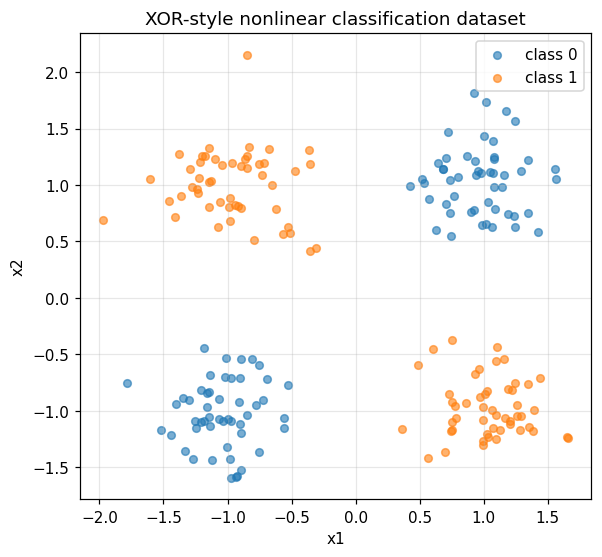

In [116]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], alpha=0.6, s=25, color="tab:blue", label="class 0")
ax.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], alpha=0.6, s=25, color="tab:orange", label="class 1")
ax.set_title("XOR-style nonlinear classification dataset")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()
plt.savefig("../figures/29_xor_dataset.png", dpi=110, bbox_inches="tight")
plt.show()

In [117]:
nn_result = nnfs.train_neural_network(X_xor, y_xor, hidden_units=4, learning_rate=0.5,
                                       iterations=5000, seed=42, scale=2.0)

nn_preds = nnfs.predict(X_xor, nn_result["params"])
nn_accuracy = np.mean(nn_preds == y_xor)

print(f"Initial loss: {nn_result['loss_history'][0]:.4f}")
print(f"Final loss:   {nn_result['loss_history'][-1]:.4f}")
print(f"Training accuracy: {nn_accuracy:.4f}")
print(f"Diverged: {nn_result['diverged']}")

assert nn_result["loss_history"][-1] < nn_result["loss_history"][0]

Initial loss: 1.5268
Final loss:   0.0007
Training accuracy: 1.0000
Diverged: False


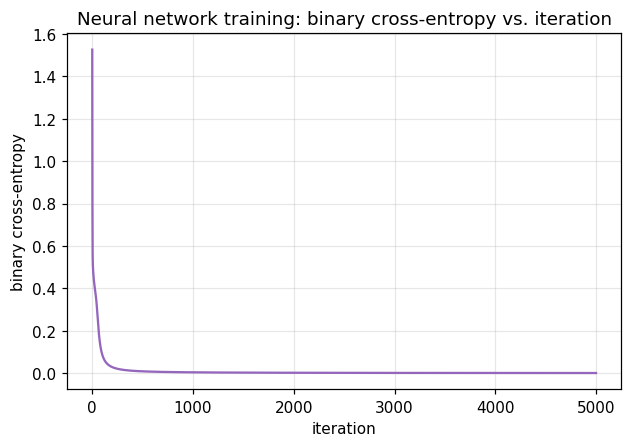

In [118]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(nn_result["loss_history"], color="tab:purple")
ax.set_title("Neural network training: binary cross-entropy vs. iteration")
ax.set_xlabel("iteration")
ax.set_ylabel("binary cross-entropy")
plt.savefig("../figures/30_nn_training_loss.png", dpi=110, bbox_inches="tight")
plt.show()

The loss decreases substantially and training accuracy reaches 1.0 on this dataset with this initialization/learning-rate/iteration combination - Section 6.16's hidden-unit experiment shows this is not automatic across all configurations (e.g. too few hidden units fail to reach this result on the same data).

## 6.14 Decision Boundary Visualization

A grid spanning the feature space is classified point-by-point via the
trained network's forward pass, then the resulting class regions are
visualized alongside the training points.

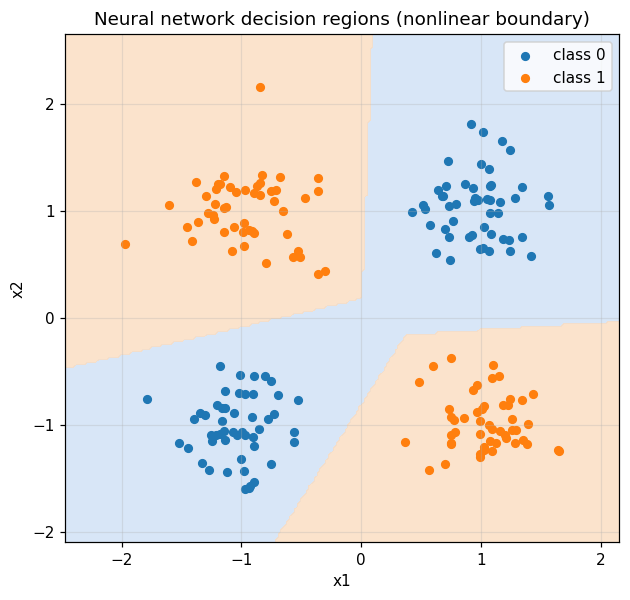

In [119]:
x1_grid = np.linspace(X_xor[:, 0].min() - 0.5, X_xor[:, 0].max() + 0.5, 200)
x2_grid = np.linspace(X_xor[:, 1].min() - 0.5, X_xor[:, 1].max() + 0.5, 200)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

grid_probs, _ = nnfs.forward_propagation(grid_points, nn_result["params"])
grid_classes = (grid_probs.flatten() >= 0.5).astype(int).reshape(X1_grid.shape)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.contourf(X1_grid, X2_grid, grid_classes, levels=[-0.5, 0.5, 1.5],
            colors=["#cfe0f5", "#fbdcc0"], alpha=0.8)
ax.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], s=25, color="tab:blue", label="class 0")
ax.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], s=25, color="tab:orange", label="class 1")
ax.set_title("Neural network decision regions (nonlinear boundary)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()
plt.savefig("../figures/31_nn_decision_boundary.png", dpi=110, bbox_inches="tight")
plt.show()

### Comparison with logistic regression

Training Part 4's from-scratch logistic regression on this same XOR-style
data (not sklearn) shows why the hidden layer matters:

In [120]:
logreg_xor_result = logreg.train_logistic_regression(X_xor, y_xor, learning_rate=0.5,
                                                       iterations=5000,
                                                       w_init=np.array([0.0, 0.0]), b_init=0.0)
logreg_xor_preds = logreg.predict(X_xor, logreg_xor_result["w"], logreg_xor_result["b"])
logreg_xor_accuracy = np.mean(logreg_xor_preds == y_xor)

print(f"Logistic regression final loss: {logreg_xor_result['loss_history'][-1]:.4f}")
print(f"Logistic regression training accuracy: {logreg_xor_accuracy:.4f}")
print(f"Neural network training accuracy:      {nn_accuracy:.4f}")

Logistic regression final loss: 0.6925
Logistic regression training accuracy: 0.5000
Neural network training accuracy:      1.0000


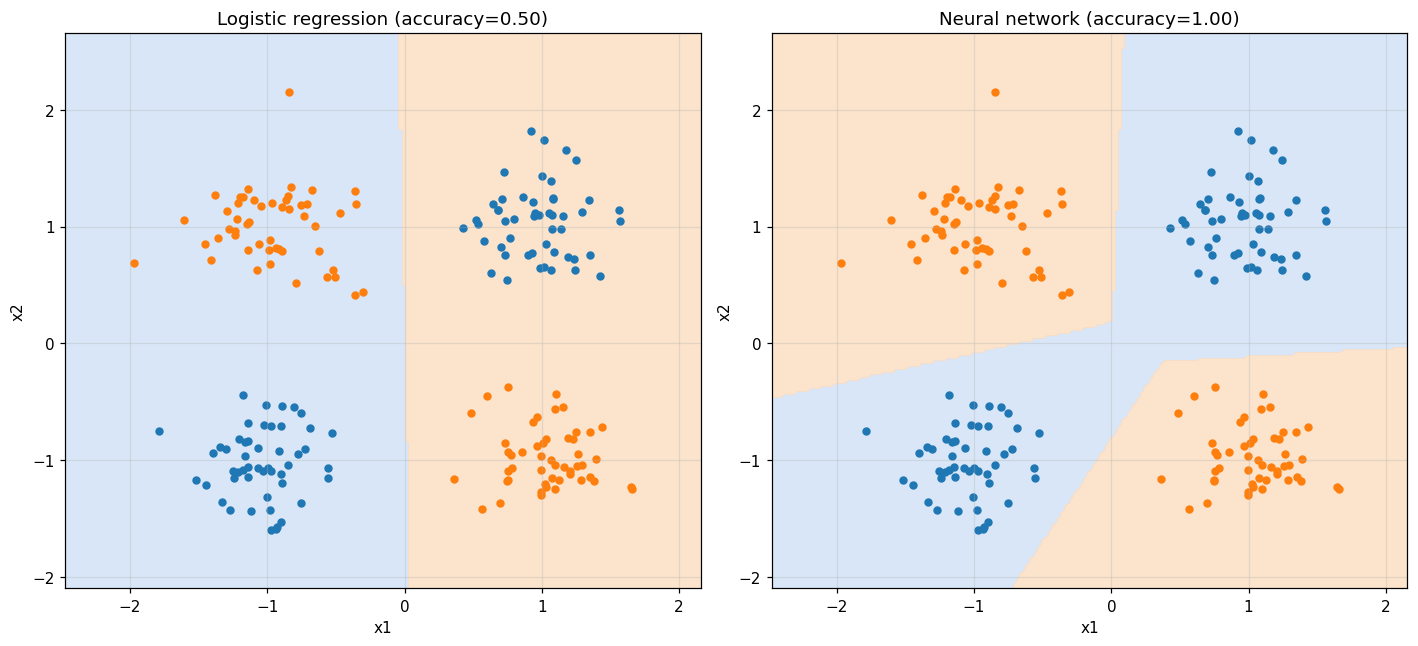

In [121]:
logreg_grid_probs = logreg.predict_proba(grid_points, logreg_xor_result["w"], logreg_xor_result["b"])
logreg_grid_classes = (logreg_grid_probs >= 0.5).astype(int).reshape(X1_grid.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, classes, title in [(axes[0], logreg_grid_classes, f"Logistic regression (accuracy={logreg_xor_accuracy:.2f})"),
                             (axes[1], grid_classes, f"Neural network (accuracy={nn_accuracy:.2f})")]:
    ax.contourf(X1_grid, X2_grid, classes, levels=[-0.5, 0.5, 1.5],
                colors=["#cfe0f5", "#fbdcc0"], alpha=0.8)
    ax.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], s=20, color="tab:blue")
    ax.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], s=20, color="tab:orange")
    ax.set_title(title)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
plt.tight_layout()
plt.savefig("../figures/32_nn_vs_logreg_boundary.png", dpi=110, bbox_inches="tight")
plt.show()

Logistic regression's boundary remains a single straight line - structurally unable to separate the XOR pattern, and its accuracy on this dataset reflects that limitation directly. The neural network's hidden layer learns a nonlinear transformation of the input space in which the classes become separable by its (still-linear) output layer, producing the curved decision regions shown above.

## 6.15 Validation and Numerical Gradient Checking

In [122]:
# 1-7: shapes, output range, loss properties, gradient shapes, no NaN/inf
A2_val, cache_val = nnfs.forward_propagation(X_xor, nn_result["params"])
assert A2_val.shape == (X_xor.shape[0], 1)
assert np.all(A2_val > 0) and np.all(A2_val < 1)

loss_val = nnfs.binary_cross_entropy(y_xor, A2_val.flatten())
assert np.isfinite(loss_val) and loss_val >= 0

grads_val = nnfs.backward_propagation(y_xor, cache_val, nn_result["params"])
assert grads_val["dW1"].shape == nn_result["params"]["W1"].shape
assert grads_val["db1"].shape == nn_result["params"]["b1"].shape
assert grads_val["dW2"].shape == nn_result["params"]["W2"].shape
assert grads_val["db2"].shape == nn_result["params"]["b2"].shape

for g in grads_val.values():
    assert not np.any(np.isnan(g))
    assert not np.any(np.isinf(g))

print("Shape/output/loss/gradient-shape/NaN-Inf validation passed (checks 1-7, 12).")

Shape/output/loss/gradient-shape/NaN-Inf validation passed (checks 1-7, 12).


In [123]:
# 8. Numerical gradient checking (finite differences) at an UNTRAINED point,
# for one element each of W1, b1, W2, b2 - verification only, never used for training.
check_params = nnfs.initialize_parameters(2, 4, seed=42, scale=2.0)
_, check_cache = nnfs.forward_propagation(X_xor, check_params)
analytical_grads = nnfs.backward_propagation(y_xor, check_cache, check_params)

gradient_checks = [("W1", (0, 0)), ("b1", (1,)), ("W2", (2, 0)), ("b2", (0,))]
epsilon = 1e-5

for param_name, index in gradient_checks:
    numerical = nnfs.numerical_gradient_check(X_xor, y_xor, check_params, param_name, index, h=epsilon)
    analytical = analytical_grads["d" + param_name][index]
    diff = abs(analytical - numerical)
    print(f"{param_name}{index}: analytical = {analytical:.8f}, numerical = {numerical:.8f}, diff = {diff:.2e}")
    assert np.isclose(analytical, numerical, atol=1e-4)

print("\nNumerical gradient check passed for all four tested parameter elements.")
print("This is a verification technique only - it is never used inside train_neural_network,")
print("since it requires two full forward passes per parameter element and would be far too")
print("expensive to run at every training iteration (quantified in Section 6.17).")

W1(0, 0): analytical = 0.22680650, numerical = 0.22680650, diff = 3.72e-12
b1(1,): analytical = -0.03932503, numerical = -0.03932503, diff = 9.96e-13
W2(2, 0): analytical = -0.42162083, numerical = -0.42162083, diff = 8.74e-12
b2(0,): analytical = -0.25944290, numerical = -0.25944290, diff = 1.37e-11

Numerical gradient check passed for all four tested parameter elements.
This is a verification technique only - it is never used inside train_neural_network,
since it requires two full forward passes per parameter element and would be far too
expensive to run at every training iteration (quantified in Section 6.17).


In [124]:
# 10, 13, 14: training reduces loss, network learns meaningfully, reproducibility
assert nn_result["loss_history"][-1] < nn_result["loss_history"][0]
assert nn_accuracy > 0.9  # meaningfully better than chance (0.5) on this balanced dataset

nn_result_repeat = nnfs.train_neural_network(X_xor, y_xor, hidden_units=4, learning_rate=0.5,
                                              iterations=5000, seed=42, scale=2.0)
assert np.allclose(nn_result["loss_history"], nn_result_repeat["loss_history"])
print("Validation passed: training reduces loss, network learns meaningfully "
      "(training accuracy > 0.9), and results are exactly reproducible under the fixed seed.")

Validation passed: training reduces loss, network learns meaningfully (training accuracy > 0.9), and results are exactly reproducible under the fixed seed.


## 6.16 Experiments and Analysis

### Experiment 1 - Hidden Layer vs. Linear Model

In [125]:
exp1_table = pd.DataFrame([
    {"Model": "Logistic regression (Part 4, from-scratch)", "Final Loss": logreg_xor_result["loss_history"][-1],
     "Training Accuracy": logreg_xor_accuracy},
    {"Model": "Neural network (1 hidden layer, 4 units)", "Final Loss": nn_result["loss_history"][-1],
     "Training Accuracy": nn_accuracy},
])
exp1_table

                                        Model  Final Loss  Training Accuracy
0  Logistic regression (Part 4, from-scratch)    0.692532                0.5
1    Neural network (1 hidden layer, 4 units)    0.000738                1.0

On this XOR-style dataset, the neural network's hidden layer allows it to learn a nonlinear transformation of the input under which the classes become linearly separable to its output layer - logistic regression, restricted to a single linear boundary, cannot. This result is specific to this dataset's structure; a dataset that is already linearly separable would not necessarily show a neural network outperforming logistic regression.

### Experiment 2 - Number of Hidden Units

In [126]:
hidden_unit_counts = [1, 2, 4, 8]
hidden_unit_results = []

for h in hidden_unit_counts:
    res_h = nnfs.train_neural_network(X_xor, y_xor, hidden_units=h, learning_rate=0.5,
                                       iterations=5000, seed=42, scale=2.0)
    preds_h = nnfs.predict(X_xor, res_h["params"])
    acc_h = np.mean(preds_h == y_xor)
    n_params_h = sum(v.size for v in res_h["params"].values())
    hidden_unit_results.append((h, res_h, acc_h, n_params_h))
    print(f"hidden_units={h}: final_loss={res_h['loss_history'][-1]:.4f}, "
          f"accuracy={acc_h:.4f}, parameters={n_params_h}")

hidden_units=1: final_loss=0.4777, accuracy=0.7500, parameters=5
hidden_units=2: final_loss=0.3467, accuracy=0.7500, parameters=9
hidden_units=4: final_loss=0.0007, accuracy=1.0000, parameters=17
hidden_units=8: final_loss=0.0002, accuracy=1.0000, parameters=33


In [127]:
hidden_unit_table = pd.DataFrame([
    {"Hidden Units": h, "Parameters": n_p, "Final Loss": res["loss_history"][-1], "Training Accuracy": acc}
    for h, res, acc, n_p in hidden_unit_results
])
hidden_unit_table

   Hidden Units  Parameters  Final Loss  Training Accuracy
0             1           5    0.477679               0.75
1             2           9    0.346748               0.75
2             4          17    0.000738               1.00
3             8          33    0.000160               1.00

With this particular initialization and dataset, 1-2 hidden units do not reach high accuracy on this XOR-style task, while 4-8 units do - consistent with needing enough hidden units to represent the XOR pattern, though the exact number needed can depend on random initialization as well as the task. More hidden units also increase the parameter count directly (Section 6.10's formula); this experiment does not test whether even larger hidden layers would eventually cause overfitting on a held-out set, since no train/test split is used in this section.

### Experiment 3 - Learning Rate

In [128]:
nn_lr_candidates = [0.001, 0.01, 0.05, 0.1]
nn_lr_results = []

for eta in nn_lr_candidates:
    res_lr = nnfs.train_neural_network(X_xor, y_xor, hidden_units=4, learning_rate=eta,
                                        iterations=5000, seed=42, scale=2.0)
    preds_lr = nnfs.predict(X_xor, res_lr["params"])
    acc_lr = np.mean(preds_lr == y_xor)
    nn_lr_results.append((eta, res_lr, acc_lr))
    status = "diverged" if res_lr["diverged"] else "completed all iterations"
    print(f"eta={eta}: final_loss={res_lr['loss_history'][-1]:.4f}, accuracy={acc_lr:.4f} ({status})")

eta=0.001: final_loss=0.4743, accuracy=0.7200 (completed all iterations)
eta=0.01: final_loss=0.0807, accuracy=1.0000 (completed all iterations)
eta=0.05: final_loss=0.0086, accuracy=1.0000 (completed all iterations)
eta=0.1: final_loss=0.0040, accuracy=1.0000 (completed all iterations)


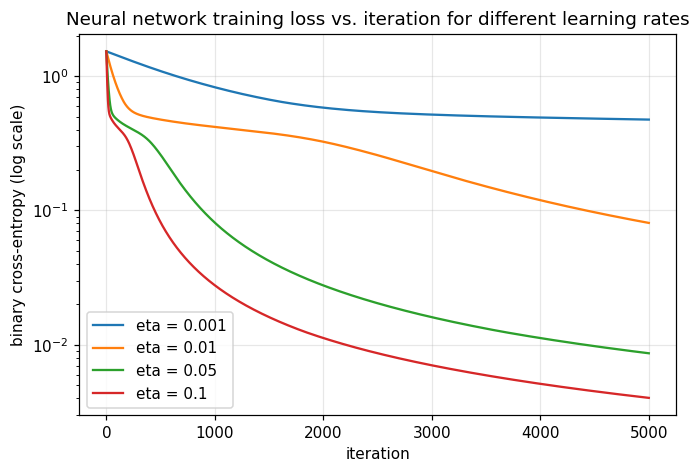

In [129]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for eta, res_lr, acc_lr in nn_lr_results:
    ax.plot(res_lr["loss_history"], label=f"eta = {eta}")
ax.set_yscale("log")
ax.set_title("Neural network training loss vs. iteration for different learning rates")
ax.set_xlabel("iteration")
ax.set_ylabel("binary cross-entropy (log scale)")
ax.legend()
plt.savefig("../figures/33_nn_lr_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

All four learning rates converge without diverging on this dataset/architecture - no instability is observed at these values, so none is claimed. eta=0.001 converges more slowly, reaching a higher remaining loss after 5000 iterations than the larger learning rates.

## 6.17 Computational Perspective

For $n$ samples, $d$ input features, $h$ hidden units:
- **Hidden layer forward pass** ($XW_1$): approximately $O(ndh)$.
- **Output layer forward pass** ($A_1W_2$, with $A_1\in\mathbb{R}^{n\times
  h}$, $W_2\in\mathbb{R}^{h\times1}$): approximately $O(nh)$.
- **Backward propagation** mirrors the forward computation's matrix
  shapes, so it has the same order of cost as the forward pass.
- **Total training cost** over $T$ iterations: approximately
  $O(Tndh)$, dominated by the hidden layer's matrix multiplications.

**Parameter count**: $dh$ ($W_1$) $+\,h$ ($b_1$) $+\,h$ ($W_2$, since the
output layer has 1 unit) $+\,1$ ($b_2$) $= dh+2h+1$. For $d=2,h=4$: this
matches Section 6.10's $17$ exactly.

**Numerical gradient checking** (Section 6.15) costs $O(\text{number of
parameters})$ *full forward passes* (two per checked element), each
itself $O(ndh)$ - substantially more expensive than the single analytical
backward pass above, which is exactly why it is used here only for
verification/debugging, never inside the training loop.

## 6.18 Summary

1. A neural network generalizes the linear model by stacking transformations.
2. A layer computes $Z=XW+b$.
3. Nonlinear activation functions prevent multiple layers from collapsing
   into one equivalent linear transformation (Section 6.4).
4. Hidden layers learn intermediate representations.
5. The output layer converts the learned representation into a prediction.
6. Binary classification uses a sigmoid output and BCE loss, as in Part 4.
7. Gradients are computed by applying the chain rule backward through the
   network (Section 6.11).
8. Gradient descent updates every parameter.
9. A hidden layer allowed this network to learn a nonlinear decision
   boundary that logistic regression could not (Sections 6.13-6.14).
10. Numerical gradient checking provided evidence - not a formal proof -
    that the manual derivatives are implemented correctly (Section 6.15).

$$
\text{Linear Model} \rightarrow \text{Linear Layers} \rightarrow
\text{Nonlinear Activation} \rightarrow \text{Hidden Representation}
\rightarrow \text{Output} \rightarrow \text{Loss} \rightarrow
\text{Backward Gradients} \rightarrow \text{Parameter Updates}
$$

The next stage can examine the mathematics of backpropagation and
gradient flow in greater depth.

---
# 7. Backpropagation and Gradient Flow

Part 6 implemented forward and backward propagation for one specific
one-hidden-layer network. This section asks a more general question:

**How does the chain rule allow a neural network to compute gradients
for every parameter, and how do gradients behave as networks become
deeper?**

## 7.1 Why Backpropagation?

A network may have many parameters ($W_1,b_1,W_2,b_2,\ldots$), and
training requires $\partial L/\partial\theta$ for every one of them.
Computing each of these independently from scratch would repeatedly
redo the same intermediate work. **Backpropagation** avoids this by
reusing intermediate derivatives: the gradient computed at one operation
is exactly what is needed to compute the gradient of the operation before
it.

$$
\text{Input} \rightarrow \text{Layer 1} \rightarrow \text{Activation}
\rightarrow \text{Layer 2} \rightarrow \text{Loss}
$$
$$
\text{Loss Gradient} \rightarrow \text{Layer 2 Gradient} \rightarrow
\text{Activation Gradient} \rightarrow \text{Layer 1 Gradient}
$$

**Backpropagation is not a different optimization algorithm.** It is an
efficient method for *computing gradients*. Gradient descent (Part 2)
still performs the parameter update:

$$\text{Backpropagation: computes gradients} \qquad \text{Gradient
Descent: uses gradients to update parameters}$$

## 7.2 The Chain Rule Revisited

For $y=f(u)$, $u=g(x)$: $\dfrac{dy}{dx}=\dfrac{dy}{du}\cdot\dfrac{du}{dx}$
(Part 2). Extending to a short chain of operations:

$$x \rightarrow u=2x+1 \rightarrow v=u^2 \rightarrow L=3v$$

$$\frac{dL}{dv}=3 \qquad \frac{dv}{du}=2u \qquad \frac{du}{dx}=2$$

$$\frac{dL}{du}=\frac{dL}{dv}\cdot\frac{dv}{du}=3\cdot2u=6u \qquad
\frac{dL}{dx}=\frac{dL}{du}\cdot\frac{du}{dx}=6u\cdot2=12u$$

The derivative of the final output with respect to an earlier variable is
the **product of derivatives along the path** connecting them - exactly
the mechanism backpropagation applies repeatedly through a network's
layers.

In [130]:
x_chain = 2.0
u_chain = 2 * x_chain + 1
v_chain = u_chain ** 2
L_chain = 3 * v_chain

dL_dv = 3.0
dL_du = dL_dv * (2 * u_chain)
dL_dx = dL_du * 2

print(f"Forward: x={x_chain}, u={u_chain}, v={v_chain}, L={L_chain}")
print(f"dL/dv = {dL_dv}")
print(f"dL/du = dL/dv * dv/du = {dL_dv} * {2*u_chain} = {dL_du}")
print(f"dL/dx = dL/du * du/dx = {dL_du} * 2 = {dL_dx}")

Forward: x=2.0, u=5.0, v=25.0, L=75.0
dL/dv = 3.0
dL/du = dL/dv * dv/du = 3.0 * 10.0 = 30.0
dL/dx = dL/du * du/dx = 30.0 * 2 = 60.0


In [131]:
def L_of_x(x):
    u = 2 * x + 1
    v = u ** 2
    return 3 * v

h_chain = 1e-6
numerical_dL_dx = (L_of_x(x_chain + h_chain) - L_of_x(x_chain - h_chain)) / (2 * h_chain)
print(f"Analytical dL/dx = {dL_dx}")
print(f"Numerical dL/dx  = {numerical_dL_dx:.6f}")
assert np.isclose(dL_dx, numerical_dL_dx, atol=1e-3)
print("Validation passed: chain-rule derivative matches finite-difference approximation.")

Analytical dL/dx = 60.0
Numerical dL/dx  = 60.000000
Validation passed: chain-rule derivative matches finite-difference approximation.


## 7.3 Computational Graphs

$$x \rightarrow z=wx+b \rightarrow a=\text{ReLU}(z) \rightarrow L$$

Each node is one operation with an input, an output, and a **local
derivative** relating them. Forward pass: compute and store values
left-to-right. Backward pass: propagate gradients right-to-left, each
node multiplying the incoming upstream gradient by its own local
derivative (the chain rule, applied node by node).

In [132]:
w_graph, b_graph, x_graph = 2.0, -1.0, 3.0

z_graph = w_graph * x_graph + b_graph
a_graph = max(0.0, z_graph)
L_graph = a_graph  # treat the final node's output directly as the "loss" for this toy example

dL_da = 1.0
da_dz = 1.0 if z_graph > 0 else 0.0
dL_dz = dL_da * da_dz
dL_dw = dL_dz * x_graph
dL_db = dL_dz * 1.0
dL_dx = dL_dz * w_graph

print(f"Forward:  z = {z_graph}, a = {a_graph}")
print(f"Backward: dL/da = {dL_da}, da/dz = {da_dz}, dL/dz = {dL_dz}")
print(f"          dL/dw = {dL_dw}, dL/db = {dL_db}, dL/dx = {dL_dx}")

Forward:  z = 5.0, a = 5.0
Backward: dL/da = 1.0, da/dz = 1.0, dL/dz = 1.0
          dL/dw = 3.0, dL/db = 1.0, dL/dx = 2.0


## 7.4 Forward Pass and Local Derivatives

| Operation | Forward | Local derivative |
|---|---|---|
| Addition | $z=x+b$ | $\partial z/\partial x=1,\ \partial z/\partial b=1$ |
| Multiplication | $z=xy$ | $\partial z/\partial x=y,\ \partial z/\partial y=x$ |
| Matrix multiplication | $Z=XW$ | see below |
| ReLU | $A=\max(0,Z)$ | $1$ if $Z>0$ else $0$ (convention: $\text{ReLU}'(0)=0$, a chosen implementation convention, not a mathematical necessity, since ReLU is not differentiable exactly at 0) |
| Sigmoid | $A=\sigma(Z)$ | $\sigma(Z)(1-\sigma(Z))$ |

**Matrix multiplication backward identities.** For $Z=XW$ with upstream
gradient $dZ=\partial L/\partial Z$:

$$dW = X^TdZ \qquad dX = dZ\,W^T$$

In [133]:
X_mm = np.random.RandomState(0).randn(4, 3)   # (n=4, d=3)
W_mm = np.random.RandomState(1).randn(3, 2)   # (d=3, h=2)
Z_mm = X_mm @ W_mm                             # (4, 2)

dZ_mm = np.random.RandomState(2).randn(4, 2)   # upstream gradient, same shape as Z
dW_mm = X_mm.T @ dZ_mm
dX_mm = dZ_mm @ W_mm.T

print(f"X: {X_mm.shape}, W: {W_mm.shape}, Z=XW: {Z_mm.shape}")
print(f"dZ: {dZ_mm.shape} -> dW = X^T dZ: {dW_mm.shape} (matches W), "
      f"dX = dZ W^T: {dX_mm.shape} (matches X)")

assert dW_mm.shape == W_mm.shape
assert dX_mm.shape == X_mm.shape
print("Shape validation passed.")

X: (4, 3), W: (3, 2), Z=XW: (4, 2)
dZ: (4, 2) -> dW = X^T dZ: (3, 2) (matches W), dX = dZ W^T: (4, 3) (matches X)
Shape validation passed.


In [134]:
# Explicit activation-derivative validation (using this section's stated conventions)
relu_input_check = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
relu_derivative_expected = np.array([0.0, 0.0, 0.0, 1.0, 1.0])  # convention: ReLU'(0) = 0
relu_derivative_actual = nnfs.relu_derivative(relu_input_check)
assert np.array_equal(relu_derivative_actual, relu_derivative_expected)
print(f"ReLU'({relu_input_check}) = {relu_derivative_actual}  (matches expected {relu_derivative_expected})")

sigmoid_at_zero = nnfs.sigmoid(np.array([0.0]))[0]
sigmoid_derivative_at_zero = sigmoid_at_zero * (1 - sigmoid_at_zero)
assert np.isclose(sigmoid_at_zero, 0.5)
assert np.isclose(sigmoid_derivative_at_zero, 0.25)
print(f"sigmoid(0) = {sigmoid_at_zero}, sigmoid'(0) = sigmoid(0)(1-sigmoid(0)) = {sigmoid_derivative_at_zero}")

tanh_at_zero = np.tanh(0.0)
tanh_derivative_at_zero = 1 - tanh_at_zero ** 2
assert np.isclose(tanh_derivative_at_zero, 1.0)
print(f"tanh(0) = {tanh_at_zero}, tanh'(0) = 1 - tanh(0)^2 = {tanh_derivative_at_zero}")

print("\nActivation derivative validation passed.")

ReLU'([-2. -1.  0.  1.  2.]) = [0. 0. 0. 1. 1.]  (matches expected [0. 0. 0. 1. 1.])
sigmoid(0) = 0.5, sigmoid'(0) = sigmoid(0)(1-sigmoid(0)) = 0.25
tanh(0) = 0.0, tanh'(0) = 1 - tanh(0)^2 = 1.0

Activation derivative validation passed.


## 7.5 Deriving Backpropagation Step by Step

Architecture: $X \rightarrow Z_1=XW_1+b_1 \rightarrow A_1=\text{activation}(Z_1)
\rightarrow Z_2=A_1W_2+b_2 \rightarrow A_2=\sigma(Z_2) \rightarrow$ BCE loss.
Part 6 *implemented* these formulas; here each is explained via the chain
rule and computational-graph view from Sections 7.2-7.4.

**$dZ_2=A_2-y$.** As derived in Part 4 (Section 4.6): the chain rule
through $\partial L/\partial A_2$ and $\partial A_2/\partial Z_2=A_2(1-A_2)$
(the sigmoid local derivative from Section 7.4) produces a factor of
$A_2(1-A_2)$ in both the numerator (from $\partial L/\partial A_2$, which
contains $1/[A_2(1-A_2)]$ for BCE) and denominator, which **cancels
exactly** - this is why the combined sigmoid+BCE gradient simplifies to
the simple "prediction minus target" form, rather than requiring the two
local derivatives (loss w.r.t. $A_2$, and $A_2$ w.r.t. $Z_2$) to be
multiplied out explicitly.

**$dW_2=\frac1nA_1^TdZ_2,\ db_2=\frac1n\sum dZ_2$.** Direct application
of the matrix-multiplication backward identity ($Z_2=A_1W_2+b_2$, so
$dW_2=A_1^TdZ_2$ per Section 7.4, averaged over the batch) - shape
$(h,1)$, matching $W_2$.

**$dA_1=dZ_2W_2^T$.** The *other* matrix-multiplication identity
($dX=dZW^T$ from Section 7.4, here with "$X$" $=A_1$) - this is how the
error signal propagates from the output layer backward into the hidden
layer's output. Shape $(n,h)$, matching $A_1$.

**$dZ_1=dA_1\odot\text{activation}'(Z_1)$.** Chain rule through the
activation function: $\partial L/\partial Z_1 = (\partial L/\partial A_1)
\odot(\partial A_1/\partial Z_1)$, elementwise since activations apply
elementwise. Shape $(n,h)$, matching $Z_1$.

**$dW_1=\frac1nX^TdZ_1,\ db_1=\frac1n\sum dZ_1$.** The same
matrix-multiplication identity as $dW_2$, one layer earlier. Shape
$(d,h)$, matching $W_1$.

Every gradient above was derived by combining exactly two ingredients
repeatedly: the chain rule (Part 2), and the local derivative of whichever
operation is being stepped back through (Section 7.4) - this is the
general pattern Section 7.6 vectorizes and Section 7.8 extends to more
layers.

## 7.6 Matrix Form of Backpropagation

Computing gradients sample-by-sample (a loop over $n$ observations) would
repeat the same arithmetic structure $n$ times. Vectorizing with matrices
processes the whole batch in one set of operations - for
$X\in\mathbb{R}^{n\times d}$, $W\in\mathbb{R}^{d\times h}$, $Z=XW\in
\mathbb{R}^{n\times h}$:

$$dW = X^TdZ, \qquad X^T:(d\times n),\ dZ:(n\times h) \Rightarrow dW:(d\times h)$$
$$dX = dZ\,W^T, \qquad dZ:(n\times h),\ W^T:(h\times d) \Rightarrow dX:(n\times d)$$

Both match their corresponding forward tensor's shape ($dW$ matches $W$,
$dX$ matches $X$), which is exactly the shape-matching check used
throughout Part 6 and Section 7.7 below.

In [135]:
n_batch, d_batch, h_batch = 50, 3, 5
X_batch = np.random.RandomState(3).randn(n_batch, d_batch)
W_batch = np.random.RandomState(4).randn(d_batch, h_batch)
Z_batch = X_batch @ W_batch

dZ_batch = np.random.RandomState(5).randn(n_batch, h_batch)
dW_batch = X_batch.T @ dZ_batch
dX_batch = dZ_batch @ W_batch.T

assert dW_batch.shape == W_batch.shape
assert dX_batch.shape == X_batch.shape
print(f"Batch of n={n_batch} processed in one matrix multiplication each way: "
      f"dW shape {dW_batch.shape}, dX shape {dX_batch.shape}.")
print("No explicit loop over samples was used - validated by shape, matching Part 1's matrix multiplication.")

Batch of n=50 processed in one matrix multiplication each way: dW shape (3, 5), dX shape (50, 3).
No explicit loop over samples was used - validated by shape, matching Part 1's matrix multiplication.


## 7.7 Gradient Checking in Depth

Part 6 checked one element per parameter. Here, **multiple randomly
selected elements** are checked systematically, using the central
difference

$$\frac{\partial L}{\partial\theta} \approx \frac{L(\theta+\epsilon)-L(\theta-\epsilon)}{2\epsilon}$$

Central differences are used rather than a one-sided (forward) difference
$[L(\theta+\epsilon)-L(\theta)]/\epsilon$ because the central form's
error is $O(\epsilon^2)$ instead of $O(\epsilon)$ - it cancels the
first-order error term in the Taylor expansion by symmetrically sampling
on both sides of $\theta$.

Relative difference is used alongside the absolute difference since it
adapts to each gradient's own scale:

$$\text{relative diff} = \frac{|g_{\text{analytical}}-g_{\text{numerical}}|}
{\max(10^{-12},\ |g_{\text{analytical}}|+|g_{\text{numerical}}|)}$$

This reuses Part 6's exact one-hidden-layer network (`nnfs`), checking 3
elements of $W_1$, 2 of $b_1$, 3 of $W_2$, and the 1 element of $b_2$
(all of $b_2$, since $b_2\in\mathbb{R}^1$), on the XOR dataset at a fresh
untrained initialization.

In [136]:
rng_check = np.random.RandomState(7)
check_params_deep = nnfs.initialize_parameters(2, 4, seed=42, scale=2.0)
_, check_cache_deep = nnfs.forward_propagation(X_xor, check_params_deep)
analytical_all = nnfs.backward_propagation(y_xor, check_cache_deep, check_params_deep)

epsilon_deep = 1e-5

# Sample DISTINCT flat positions within each parameter array (without replacement),
# then convert to the array's actual (row, col) index shape.
w1_flat_idx = rng_check.choice(check_params_deep["W1"].size, size=3, replace=False)
b1_flat_idx = rng_check.choice(check_params_deep["b1"].size, size=2, replace=False)
w2_flat_idx = rng_check.choice(check_params_deep["W2"].size, size=3, replace=False)

elements_to_check = (
    [("W1", tuple(int(x) for x in np.unravel_index(i, check_params_deep["W1"].shape))) for i in w1_flat_idx] +
    [("b1", (int(i),)) for i in b1_flat_idx] +
    [("W2", tuple(int(x) for x in np.unravel_index(i, check_params_deep["W2"].shape))) for i in w2_flat_idx] +
    [("b2", (0,))]
)

assert len(set(elements_to_check)) == len(elements_to_check), "Duplicate parameter element selected."

results_gc = []
for param_name, index in elements_to_check:
    numerical = nnfs.numerical_gradient_check(X_xor, y_xor, check_params_deep, param_name, index, h=epsilon_deep)
    analytical = analytical_all["d" + param_name][index]
    abs_diff = abs(analytical - numerical)
    rel_diff = abs_diff / max(1e-12, abs(analytical) + abs(numerical))
    results_gc.append({"Parameter": f"{param_name}{index}", "Analytical": analytical,
                        "Numerical": numerical, "Abs Diff": abs_diff, "Rel Diff": rel_diff})

gc_table = pd.DataFrame(results_gc)
gc_table

  Parameter  Analytical  Numerical      Abs Diff      Rel Diff
0  W1(0, 2)   -0.170969  -0.170969  3.489514e-12  1.020514e-11
1  W1(1, 1)    0.016398   0.016398  1.614212e-12  4.921838e-11
2  W1(0, 0)    0.226807   0.226807  3.720857e-12  8.202712e-12
3    b1(3,)    0.224325   0.224325  4.659412e-12  1.038542e-11
4    b1(1,)   -0.039325  -0.039325  9.961337e-13  1.266539e-11
5  W2(1, 0)    0.096130   0.096130  1.128544e-11  5.869887e-11
6  W2(0, 0)   -0.343073  -0.343073  8.506418e-12  1.239737e-11
7  W2(3, 0)   -0.414390  -0.414390  4.494238e-12  5.422711e-12
8    b2(0,)   -0.259443  -0.259443  1.372430e-11  2.644956e-11

In [137]:
max_rel_diff = gc_table["Rel Diff"].max()
print(f"Maximum relative difference across all {len(gc_table)} checked elements: {max_rel_diff:.2e}")

assert (gc_table["Rel Diff"] < 1e-4).all()
print("All checked elements pass the 1e-4 relative-difference threshold.")
print("\nThis validates the implementation; gradient checking is too expensive to run at every")
print("training iteration (quantified in Section 7.15), so it is used here only for verification.")

Maximum relative difference across all 9 checked elements: 5.87e-11
All checked elements pass the 1e-4 relative-difference threshold.

This validates the implementation; gradient checking is too expensive to run at every
training iteration (quantified in Section 7.15), so it is used here only for verification.


## 7.8 Extending the Network to Multiple Hidden Layers

Architecture: Input (2) -> Hidden 1 (4, ReLU) -> Hidden 2 (4, ReLU) ->
Output (1, sigmoid):

$$Z_1=XW_1+b_1,\ A_1=\text{ReLU}(Z_1) \quad Z_2=A_1W_2+b_2,\ A_2=\text{ReLU}(Z_2)
\quad Z_3=A_2W_3+b_3,\ A_3=\sigma(Z_3)$$

`forward_deep_network`/`backward_deep_network` (in `src/backprop.py`)
implement this generically for any number of layers, following the exact
recursive pattern from Section 7.5/7.6 applied once per layer:

$$dZ_3 \rightarrow dW_3,db_3 \rightarrow dA_2 \rightarrow dZ_2 \rightarrow
dW_2,db_2 \rightarrow dA_1 \rightarrow dZ_1 \rightarrow dW_1,db_1$$

Trained on the same XOR dataset from Part 6, to confirm the generalized
implementation reproduces a result consistent with Part 6's single-hidden-layer network on a task it already solved:

In [138]:
import backprop as bp

print(inspect.getsource(bp.backward_deep_network))

def backward_deep_network(y, cache, params, num_layers, activation="relu"):
    """
    Manual backward pass through `num_layers` layers, applying the same
    per-layer pattern as Part 6 repeatedly:
        dZ_L = A_L - y                      (output layer; sigmoid+BCE cancellation)
        dW_l = (1/n) A_(l-1)^T dZ_l         db_l = (1/n) sum(dZ_l)
        dA_(l-1) = dZ_l W_l^T               (propagate error backward through W_l)
        dZ_(l-1) = dA_(l-1) * activation'(Z_(l-1))   (elementwise, for hidden layers)
    Returns a dict with dW_l, db_l for l = 1..num_layers.
    """
    n = cache["A0"].shape[0]
    y_col = y.reshape(-1, 1)
    grads = {}

    dZ = cache[f"A{num_layers}"] - y_col
    for l in range(num_layers, 0, -1):
        A_prev = cache[f"A{l - 1}"]
        grads[f"dW{l}"] = (1.0 / n) * (A_prev.T @ dZ)
        grads[f"db{l}"] = (1.0 / n) * np.sum(dZ, axis=0)

        if l > 1:
            dA_prev = dZ @ params[f"W{l}"].T
            if activation == "relu":
           

In [139]:
deep_result_demo = bp.train_deep_network(X_xor, y_xor, layer_dims=[2, 4, 4, 1],
                                          learning_rate=0.5, iterations=5000,
                                          activation="relu", seed=42, scale=2.0)
deep_preds_demo = bp.predict_deep(X_xor, deep_result_demo["params"], num_layers=3, activation="relu")
deep_acc_demo = np.mean(deep_preds_demo == y_xor)

print(f"2-hidden-layer network: initial loss = {deep_result_demo['loss_history'][0]:.4f}, "
      f"final loss = {deep_result_demo['loss_history'][-1]:.4f}, accuracy = {deep_acc_demo:.4f}")
assert deep_result_demo["loss_history"][-1] < deep_result_demo["loss_history"][0]

for l in [1, 2, 3]:
    print(f"W{l} shape: {deep_result_demo['params'][f'W{l}'].shape}, "
          f"b{l} shape: {deep_result_demo['params'][f'b{l}'].shape}")

# Explicit parameter-shape assertions for this [2, 4, 4, 1] architecture
deep_params_check = deep_result_demo["params"]
assert deep_params_check["W1"].shape == (2, 4)
assert deep_params_check["b1"].shape == (4,)
assert deep_params_check["W2"].shape == (4, 4)
assert deep_params_check["b2"].shape == (4,)
assert deep_params_check["W3"].shape == (4, 1)
assert deep_params_check["b3"].shape == (1,)

# Explicit prediction-output shape assertion on the XOR dataset
assert deep_preds_demo.shape == (X_xor.shape[0],)
print("\nDeep-network parameter-shape and prediction-shape assertions passed.")

2-hidden-layer network: initial loss = 1.3062, final loss = 0.0000, accuracy = 1.0000
W1 shape: (2, 4), b1 shape: (4,)
W2 shape: (4, 4), b2 shape: (4,)
W3 shape: (4, 1), b3 shape: (1,)

Deep-network parameter-shape and prediction-shape assertions passed.


## 7.9 Gradient Flow Through Depth

$\partial L/\partial W_1$ depends on a product of terms from every later
layer: $\partial L/\partial Z_L \cdot \partial Z_L/\partial A_{L-1}
\cdots \partial A_2/\partial Z_2 \cdot \partial Z_2/\partial A_1$.
Repeated multiplication of these factors can make the earliest layer's
gradient shrink, grow, or remain stable, depending on the typical
magnitude of each factor - examined here before the more targeted
vanishing/exploding experiments in Sections 7.10-7.11.

A fixed small synthetic input (independent of the XOR dataset, used
purely as a controlled probe) is reused across all depths below for a
fair comparison.

In [140]:
np.random.seed(42)
n_probe, d_probe = 20, 2
X_probe = np.random.randn(n_probe, d_probe)
y_probe = (np.random.rand(n_probe) > 0.5).astype(float)

depths_to_test = [1, 2, 4, 8]
depth_results_relu = []

for depth in depths_to_test:
    layer_dims = [d_probe] + [4] * depth + [1]
    params_depth = bp.initialize_deep_parameters(layer_dims, seed=42, scale=0.5)
    A_depth, cache_depth = bp.forward_deep_network(X_probe, params_depth, depth + 1, activation="relu")
    loss_depth = bp.binary_cross_entropy(y_probe, A_depth.flatten())
    grads_depth = bp.backward_deep_network(y_probe, cache_depth, params_depth, depth + 1, activation="relu")
    grad_mag = bp.compute_gradient_magnitude(grads_depth["dW1"])
    depth_results_relu.append({"Depth": depth, "Gradient Magnitude (dW1)": grad_mag, "Loss": loss_depth})
    assert np.isfinite(grad_mag)

depth_table_relu = pd.DataFrame(depth_results_relu)
depth_table_relu

   Depth  Gradient Magnitude (dW1)      Loss
0      1                  0.023500  0.739211
1      2                  0.004864  0.694252
2      4                  0.001196  0.690637
3      8                  0.000000  0.693147

With ReLU activation and this initialization/input, the earliest layer's gradient magnitude decreases as depth increases, reaching exactly zero at depth 8 in this experiment - inspecting the hidden layers shows that by the final layers, none of the ReLU units have positive pre-activation for any sample in this batch (all are 'dead' for this input), so their local derivative is exactly 0 everywhere and the upstream gradient is multiplied by 0 at some point in the chain. This is a related but distinct phenomenon from the smooth, continuous shrinkage examined with sigmoid activation next.

## 7.10 Vanishing Gradients

The sigmoid derivative satisfies $0<\sigma'(z)\leq0.25$ (maximized at
$z=0$, where $\sigma(0)(1-\sigma(0))=0.5\times0.5=0.25$). Multiplying
several such factors together (once per layer, in the backward chain
rule) can shrink the gradient reaching earlier layers as depth increases.

In [141]:
depth_results_sigmoid = []
for depth in depths_to_test:
    layer_dims = [d_probe] + [4] * depth + [1]
    params_depth = bp.initialize_deep_parameters(layer_dims, seed=42, scale=0.5)
    A_depth, cache_depth = bp.forward_deep_network(X_probe, params_depth, depth + 1, activation="sigmoid")
    grads_depth = bp.backward_deep_network(y_probe, cache_depth, params_depth, depth + 1, activation="sigmoid")
    grad_mag = bp.compute_gradient_magnitude(grads_depth["dW1"])
    depth_results_sigmoid.append({"Depth": depth, "Gradient Magnitude (dW1)": grad_mag})
    assert np.isfinite(grad_mag)

vanishing_table = pd.DataFrame(depth_results_sigmoid)
vanishing_table

   Depth  Gradient Magnitude (dW1)
0      1              9.586166e-03
1      2              2.320504e-03
2      4              1.955295e-04
3      8              1.117907e-07

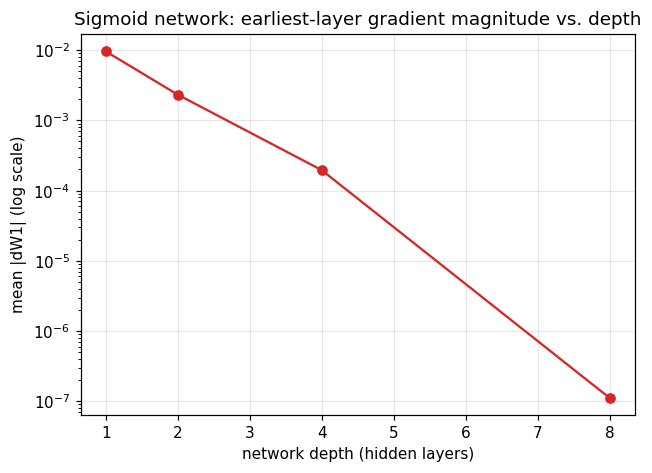

In [142]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(vanishing_table["Depth"], vanishing_table["Gradient Magnitude (dW1)"], "o-", color="tab:red")
ax.set_yscale("log")
ax.set_title("Sigmoid network: earliest-layer gradient magnitude vs. depth")
ax.set_xlabel("network depth (hidden layers)")
ax.set_ylabel("mean |dW1| (log scale)")
plt.savefig("../figures/34_vanishing_gradient.png", dpi=110, bbox_inches="tight")
plt.show()

In this experiment, the gradient magnitude decreases smoothly and substantially with depth (from ~9.6e-3 at depth 1 to ~1.1e-7 at depth 8), consistent with the repeated multiplication by sigmoid derivatives bounded by 0.25 - a specific numerical illustration of the vanishing-gradient problem for this architecture and initialization, not a universal claim about every sigmoid network.

## 7.11 Exploding and Unstable Gradients

Repeated multiplication can also **increase** gradient magnitude if the
per-layer factors typically exceed 1. Tanh (whose derivative
$1-\tanh^2(z)$ can be close to 1 near $z=0$, unlike sigmoid's tighter
$\leq0.25$ bound) with a small vs. a larger initialization scale, same
depth (8), illustrates this without deliberately using extreme values.

In [143]:
init_scales_to_test = [0.1, 2.0]
scale_labels = ["small (scale=0.1)", "large (scale=2.0)"]
explosion_results = []

for scale, label in zip(init_scales_to_test, scale_labels):
    layer_dims = [d_probe] + [4] * 8 + [1]
    params_scale = bp.initialize_deep_parameters(layer_dims, seed=42, scale=scale)
    A_scale, cache_scale = bp.forward_deep_network(X_probe, params_scale, 9, activation="tanh")
    loss_scale = bp.binary_cross_entropy(y_probe, A_scale.flatten())
    grads_scale = bp.backward_deep_network(y_probe, cache_scale, params_scale, 9, activation="tanh")
    grad_mag = bp.compute_gradient_magnitude(grads_scale["dW1"])

    all_finite = (np.isfinite(A_scale).all() and np.isfinite(loss_scale)
                  and all(np.isfinite(g).all() for g in grads_scale.values()))
    explosion_results.append({"Initialization": label, "Loss": loss_scale,
                               "Gradient Magnitude (dW1)": grad_mag, "All Finite": all_finite})
    print(f"{label}: loss={loss_scale:.4f}, mean|dW1|={grad_mag:.3e}, all finite={all_finite}")

explosion_table = pd.DataFrame(explosion_results)
explosion_table

small (scale=0.1): loss=0.6931, mean|dW1|=3.388e-08, all finite=True
large (scale=2.0): loss=0.6975, mean|dW1|=1.278e+00, all finite=True


      Initialization      Loss  Gradient Magnitude (dW1)  All Finite
0  small (scale=0.1)  0.693147              3.388173e-08        True
1  large (scale=2.0)  0.697470              1.277684e+00        True

The larger initialization scale produces a substantially larger earliest-layer gradient magnitude than the small scale in this 8-layer tanh network, while both remain fully finite (`np.isfinite` checks passed on activations, loss, and every gradient) - no numerical overflow occurred, illustrating amplification without instability at these particular scales. Larger parameter values amplify both activations and the gradients propagated back through them; gradient clipping (mentioned only conceptually here, not implemented) is one standard mitigation explored in later optimization work, outside this section's scope.

## 7.12 Activation Functions and Gradient Behavior

Comparing sigmoid, tanh, and ReLU at the same depth (4) and initialization
(scale=0.5), on the same probe input:

In [144]:
activation_comparison = []
for act in ["sigmoid", "tanh", "relu"]:
    depth_act = 4
    layer_dims = [d_probe] + [4] * depth_act + [1]
    params_act = bp.initialize_deep_parameters(layer_dims, seed=42, scale=0.5)
    A_act, cache_act = bp.forward_deep_network(X_probe, params_act, depth_act + 1, activation=act)
    grads_act = bp.backward_deep_network(y_probe, cache_act, params_act, depth_act + 1, activation=act)

    layer_derivative_magnitudes = []
    for l in range(1, depth_act + 1):
        if act == "relu":
            local_deriv = bp.relu_derivative(cache_act[f"Z{l}"])
        elif act == "tanh":
            local_deriv = bp.tanh_derivative_from_output(cache_act[f"A{l}"])
        else:
            local_deriv = bp.sigmoid_derivative_from_output(cache_act[f"A{l}"])
        layer_derivative_magnitudes.append(np.mean(np.abs(local_deriv)))

    mean_derivative_magnitude = np.mean(layer_derivative_magnitudes)
    earliest_layer_grad_mag = bp.compute_gradient_magnitude(grads_act["dW1"])
    activation_comparison.append({"Activation": act, "Mean Derivative Magnitude": mean_derivative_magnitude,
                                    "Earliest-Layer Gradient Magnitude": earliest_layer_grad_mag})
    assert np.isfinite(mean_derivative_magnitude) and np.isfinite(earliest_layer_grad_mag)

activation_table = pd.DataFrame(activation_comparison)
activation_table

  Activation  Mean Derivative Magnitude  Earliest-Layer Gradient Magnitude
0    sigmoid                   0.236646                           0.000196
1       tanh                   0.871258                           0.006887
2       relu                   0.409375                           0.001196

- **Sigmoid**: smallest mean derivative magnitude and smallest
  earliest-layer gradient of the three here, consistent with its tight
  $\leq0.25$ derivative bound and the smoothest saturation.
- **Tanh**: largest mean derivative magnitude and largest earliest-layer
  gradient in this comparison - its derivative can approach 1 near
  $z=0$, unlike sigmoid.
- **ReLU**: intermediate here; its derivative is exactly 1 for positive
  inputs and exactly 0 for negative inputs (Section 7.4), so it can help
  gradient flow through *active* units without the smooth shrinkage
  sigmoid/tanh exhibit - but any unit with negative pre-activation
  contributes exactly zero local gradient, which is the mechanism behind
  Section 7.9's exact-zero result at depth 8. ReLU does not eliminate
  vanishing gradients in general; it changes the mechanism from smooth
  shrinkage to an all-or-nothing per-unit effect.

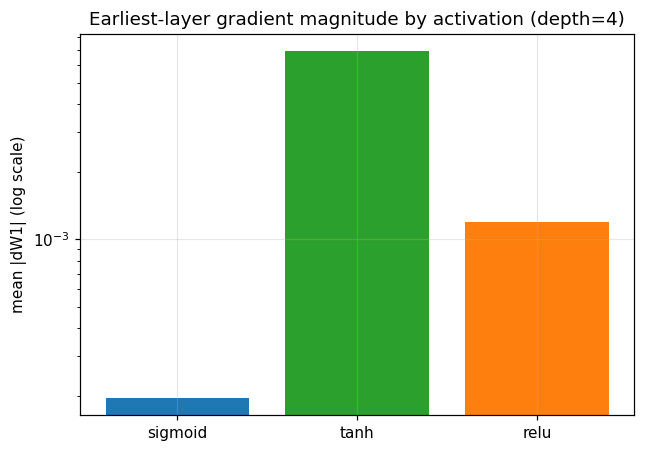

In [145]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(activation_table["Activation"], activation_table["Earliest-Layer Gradient Magnitude"],
       color=["tab:blue", "tab:green", "tab:orange"])
ax.set_yscale("log")
ax.set_title("Earliest-layer gradient magnitude by activation (depth=4)")
ax.set_ylabel("mean |dW1| (log scale)")
plt.savefig("../figures/35_activation_gradient_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

## 7.13 Initialization and Gradient Flow

Initializing every weight to zero was already shown in Part 6 to be
problematic: identical weights make every unit in a layer compute an
identical function and receive an identical gradient, so they never
differentiate (the symmetry problem). Beyond just avoiding zero,
the *scale* of random initialization also affects the magnitude of
activations, derivatives, and gradients throughout the network. **He
initialization** ($W\sim\mathcal{N}(0,2/\text{fan\_in})$) is a
variance-preserving scale motivated specifically for ReLU networks,
included here as a mathematically-motivated reference point.

In [146]:
init_configs = [("small", 0.05, "random"), ("moderate", 0.5, "random"),
                 ("large", 2.0, "random"), ("He initialization", None, "he")]
init_results = []
depth_init = 4

for label, scale, method in init_configs:
    layer_dims = [d_probe] + [4] * depth_init + [1]
    params_init = bp.initialize_deep_parameters(layer_dims, seed=42, scale=scale, method=method)
    A_init, cache_init = bp.forward_deep_network(X_probe, params_init, depth_init + 1, activation="relu")
    loss_init = bp.binary_cross_entropy(y_probe, A_init.flatten())
    grads_init = bp.backward_deep_network(y_probe, cache_init, params_init, depth_init + 1, activation="relu")

    activation_magnitude = np.mean([np.mean(np.abs(cache_init[f"A{l}"])) for l in range(1, depth_init + 1)])
    grad_mag = bp.compute_gradient_magnitude(grads_init["dW1"])
    init_results.append({"Initialization": label, "Mean Activation Magnitude": activation_magnitude,
                          "Earliest-Layer Gradient Magnitude": grad_mag, "Loss": loss_init})
    assert np.isfinite(activation_magnitude) and np.isfinite(grad_mag)

init_table = pd.DataFrame(init_results)
init_table

      Initialization  ...      Loss
0              small  ...  0.693147
1           moderate  ...  0.690637
2              large  ...  1.942586
3  He initialization  ...  0.675454

[4 rows x 4 columns]

In [147]:
# Reproducibility check: same seed/config -> identical results
params_repeat = bp.initialize_deep_parameters([d_probe]+[4]*depth_init+[1], seed=42, scale=0.5)
params_original = bp.initialize_deep_parameters([d_probe]+[4]*depth_init+[1], seed=42, scale=0.5)
assert all(np.array_equal(params_repeat[k], params_original[k]) for k in params_repeat)
print("Reproducibility validated: identical seed and configuration produce identical initial parameters.")

Reproducibility validated: identical seed and configuration produce identical initial parameters.


Small initialization produces small activations and a very small earliest-layer gradient in this experiment (a vanishing-type effect from under-scaled weights, distinct from but related to Section 7.10's activation-saturation mechanism); large initialization produces much larger activations, a much larger gradient, and a substantially higher loss than the other configurations here; He initialization falls at a moderate, well-behaved scale by construction, without needing to be hand-tuned per architecture. This illustrates that initialization scale directly affects the magnitude of activations and gradients throughout the network, which is why it matters for gradient flow.

## 7.14 Experiments and Analysis

The three controlled experiments above are summarized here (no new
computation - Experiment 1 reuses Section 7.9/7.10's depth results,
Experiment 2 reuses Section 7.12, Experiment 3 reuses Section 7.13; the
hidden-unit comparison, learning-rate comparison, and logistic-regression-
vs-neural-network experiments from Part 6 are intentionally not repeated
here).

**Experiment 1 - Depth vs. gradient magnitude:**

In [148]:
depth_table_relu

   Depth  Gradient Magnitude (dW1)      Loss
0      1                  0.023500  0.739211
1      2                  0.004864  0.694252
2      4                  0.001196  0.690637
3      8                  0.000000  0.693147

**Experiment 2 - Activation function comparison:**

In [149]:
activation_table

  Activation  Mean Derivative Magnitude  Earliest-Layer Gradient Magnitude
0    sigmoid                   0.236646                           0.000196
1       tanh                   0.871258                           0.006887
2       relu                   0.409375                           0.001196

**Experiment 3 - Initialization scale:**

In [150]:
init_table

      Initialization  ...      Loss
0              small  ...  0.693147
1           moderate  ...  0.690637
2              large  ...  1.942586
3  He initialization  ...  0.675454

[4 rows x 4 columns]

Across all three experiments, gradient magnitude at the earliest layer varies by several orders of magnitude depending on depth, activation choice, and initialization scale - the three factors this section identified as jointly determining gradient flow.

## 7.15 Computational Perspective

For a dense layer with input $n\times d$ and weights $d\times h$: forward
pass $O(ndh)$; backward propagation has the same general order of
computation, since it performs matrix multiplications of matching shapes
(Section 7.6). Backpropagation is efficient specifically because
intermediate forward-pass values ($Z_l,A_l$) are computed once and reused
during the backward pass, rather than recomputed.

For a network with several layers, total cost is approximately the sum of
each layer's $O(n\cdot d_{l-1}\cdot d_l)$ cost. **Memory**: intermediate
values $Z_1,A_1,Z_2,A_2,\ldots$ must typically be retained (as in the
`cache` dict throughout this section) because the backward pass needs
them - so deeper networks increase both computation *and* memory.

**Numerical gradient checking** cost: for $p$ total parameters, checking
every one requires on the order of $2p$ additional full forward passes
(two per parameter, for $\theta+\epsilon$ and $\theta-\epsilon$), each
itself $O(ndh)$-ish - far more expensive than the single analytical
backward pass, which is exactly why Section 7.7 checked a
representative sample of elements for validation rather than every
parameter, and why gradient checking is a debugging/validation tool, not
part of normal training.

## 7.16 Summary

1. Backpropagation is an efficient application of the chain rule.
2. The forward pass computes and stores intermediate values.
3. The backward pass propagates gradients from the loss toward earlier layers.
4. Each operation contributes a local derivative (Section 7.4).
5. Matrix calculus computes gradients for a full batch at once (Section 7.6).
6. Numerical gradient checking provides evidence - not proof - that
   analytical gradients are implemented correctly (Section 7.7).
7. Deeper networks require gradients to pass through more operations.
8. Repeated multiplication of derivatives can shrink or grow gradients
   (Sections 7.9-7.11).
9. Activation functions and initialization strongly influence gradient
   flow (Sections 7.12-7.13).
10. Backpropagation computes gradients; gradient descent uses them to
    update parameters (Section 7.1).

$$
\text{Forward Pass} \rightarrow \text{Predictions} \rightarrow \text{Loss}
\rightarrow \text{Local Derivatives} \rightarrow \text{Chain Rule}
\rightarrow \text{Backward Gradient Flow} \rightarrow \text{Parameter Gradients}
\rightarrow \text{Gradient Descent Updates}
$$

The next stage can build on these optimization foundations by studying
more advanced optimization strategies and training behavior.

---
# 8. Optimization Algorithms and Training Dynamics

Part 7 explained how backpropagation computes gradients. This section
asks the next question:

**Given gradients from backpropagation, how should those gradients be
used to update parameters efficiently and stably?**

$$\text{Backpropagation: computes gradients} \qquad \text{Optimizer: uses
gradients to update parameters}$$

## 8.1 From Gradients to Parameter Updates

Backpropagation produces gradients like $\partial L/\partial W$,
$\partial L/\partial b$ - local information about how the loss changes.
On their own, gradients do not train a model; parameters must actually be
updated. The general form:

$$\theta_{t+1} = \theta_t + \text{update}(\text{gradient},\ \text{optimizer state})$$

For standard gradient descent, this specializes to:

$$\theta_{t+1} = \theta_t - \eta\nabla L(\theta_t)$$

where $\theta$ are the parameters, $\eta$ the learning rate, and
$\nabla L(\theta)$ the gradient. The **negative** gradient is used
because $\nabla L$ points toward steepest *increase* (Part 2); moving
opposite to it is the direction of steepest local decrease.

In [151]:
import optimizers as opt

def f_scalar(x):
    return x ** 2

def grad_f_scalar(x):
    return 2 * x

x_manual = 5.0
lr_manual = 0.2
manual_path = [x_manual]
for step in range(8):
    x_manual = x_manual - lr_manual * grad_f_scalar(x_manual)
    manual_path.append(x_manual)

manual_path = np.array(manual_path)
print(f"{'step':>4} | {'x':>10} | {'f(x)':>10}")
for i, x_val in enumerate(manual_path):
    print(f"{i:4d} | {x_val:10.5f} | {f_scalar(x_val):10.5f}")

step |          x |       f(x)
   0 |    5.00000 |   25.00000
   1 |    3.00000 |    9.00000
   2 |    1.80000 |    3.24000
   3 |    1.08000 |    1.16640
   4 |    0.64800 |    0.41990
   5 |    0.38880 |    0.15117
   6 |    0.23328 |    0.05442
   7 |    0.13997 |    0.01959
   8 |    0.08398 |    0.00705


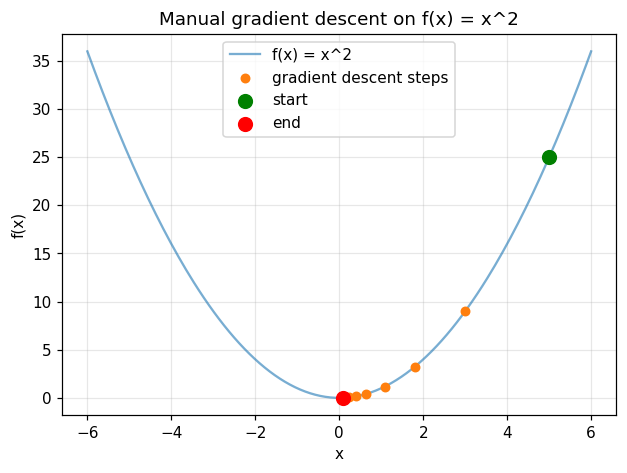

In [152]:
x_range_manual = np.linspace(-6, 6, 200)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(x_range_manual, f_scalar(x_range_manual), color="tab:blue", alpha=0.6, label="f(x) = x^2")
ax.scatter(manual_path, f_scalar(manual_path), color="tab:orange", s=30, zorder=5, label="gradient descent steps")
ax.scatter(manual_path[0], f_scalar(manual_path[0]), color="green", s=80, zorder=6, label="start")
ax.scatter(manual_path[-1], f_scalar(manual_path[-1]), color="red", s=80, zorder=6, label="end")
ax.set_title("Manual gradient descent on f(x) = x^2")
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
ax.legend()
plt.savefig("../figures/36_manual_gd_1d.png", dpi=110, bbox_inches="tight")
plt.show()

## 8.2 Gradient Descent Revisited

$$\theta_{t+1} = \theta_t - \eta g_t, \qquad g_t = \nabla L(\theta_t)$$

Using $f(x)=x^2$ again (so $g_t=2x_t$, and the update is $x_{t+1}=x_t(1-2\eta)$,
exactly Part 2's contraction-factor analysis): a small, a reasonable, and a
deliberately large learning rate, actually run rather than assumed.

In [153]:
def run_gd_1d(x0, lr, steps):
    x = x0
    path = [x]
    for _ in range(steps):
        x = x - lr * grad_f_scalar(x)
        path.append(x)
    return np.array(path)

lr_configs = [("too small", 0.01), ("reasonable", 0.4), ("too large", 1.1)]
gd_1d_results = {}
for label, lr in lr_configs:
    path = run_gd_1d(5.0, lr, 20)
    gd_1d_results[label] = path
    print(f"{label:12s} (eta={lr}): x_0={path[0]:.4f} -> x_20={path[-1]:.4f}, "
          f"all finite = {np.isfinite(path).all()}")

too small    (eta=0.01): x_0=5.0000 -> x_20=3.3380, all finite = True
reasonable   (eta=0.4): x_0=5.0000 -> x_20=0.0000, all finite = True
too large    (eta=1.1): x_0=5.0000 -> x_20=191.6880, all finite = True


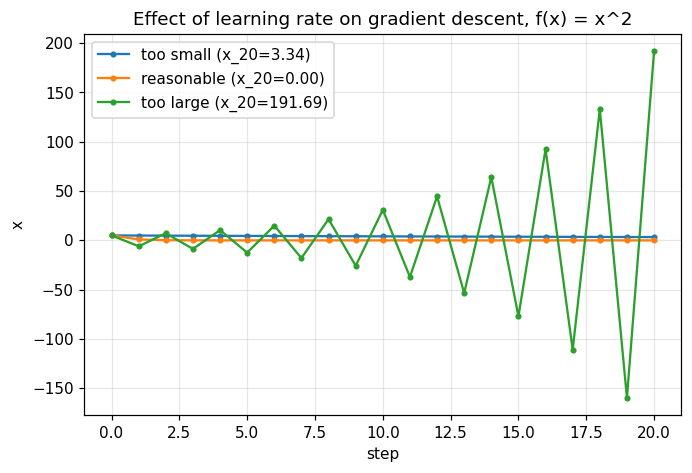

In [154]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, path in gd_1d_results.items():
    ax.plot(path, marker="o", markersize=3, label=f"{label} (x_20={path[-1]:.2f})")
ax.set_title("Effect of learning rate on gradient descent, f(x) = x^2")
ax.set_xlabel("step")
ax.set_ylabel("x")
ax.legend()
plt.savefig("../figures/37_lr_effect_1d.png", dpi=110, bbox_inches="tight")
plt.show()

The small learning rate converges slowly (still at $x\approx3.3$ after 20 steps); the reasonable rate converges quickly and smoothly; the large rate ($\eta=1.1>1$, outside this function's $0<\eta<1$ convergence range from Part 2's analysis) genuinely diverges, oscillating with growing magnitude - not fabricated, just the predictable consequence of exceeding the stability bound for this specific function.

## 8.3 Optimization Landscapes

Three simple analytical landscapes, used only to build intuition - a
neural network's actual loss surface (with many more parameters) cannot
be fully visualized this way.

1. **Convex bowl**: $f(x,y)=x^2+y^2$ - symmetric, well-conditioned.
2. **Elongated valley**: $f(x,y)=x^2+10y^2$ - much more curved in $y$
   than $x$, which (as shown below) can make plain gradient descent
   zig-zag.
3. **Non-convex, multiple regions**: $f(x,y)=(x^2-1)^2+y^2$ - two minima
   at $(\pm1,0)$ separated by a local maximum at the origin.

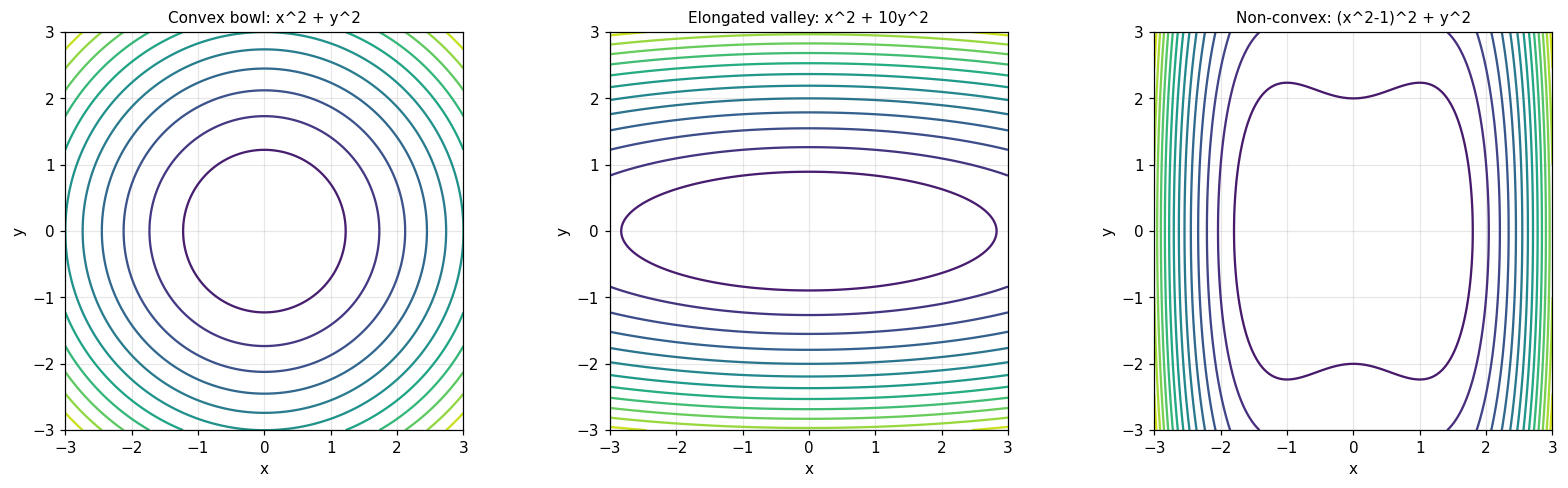

In [155]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
grid_1d = np.linspace(-3, 3, 200)
Xg, Yg = np.meshgrid(grid_1d, grid_1d)

landscapes = [
    (Xg**2 + Yg**2, "Convex bowl: x^2 + y^2"),
    (Xg**2 + 10*Yg**2, "Elongated valley: x^2 + 10y^2"),
    ((Xg**2 - 1)**2 + Yg**2, "Non-convex: (x^2-1)^2 + y^2"),
]
for ax, (Z, title) in zip(axes, landscapes):
    cs = ax.contour(Xg, Yg, Z, levels=15, cmap="viridis")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("../figures/38_landscapes.png", dpi=110, bbox_inches="tight")
plt.show()

In [156]:
def f_elongated(x, y):
    return x**2 + 10*y**2

def grad_elongated(x, y):
    return np.array([2*x, 20*y])

def run_gd_2d(start, lr, steps):
    p = np.array(start, dtype=float)
    path = [p.copy()]
    for _ in range(steps):
        p = p - lr * grad_elongated(*p)
        path.append(p.copy())
    return np.array(path)

zigzag_path = run_gd_2d((-4.0, 2.0), 0.09, 15)
print("y-coordinate across the first several steps (sign alternates -> zig-zag):")
print(zigzag_path[:8, 1])

y-coordinate across the first several steps (sign alternates -> zig-zag):
[ 2.        -1.6        1.28      -1.024      0.8192    -0.65536
  0.524288  -0.4194304]


The $y$-coordinate's sign flips every step while its magnitude shrinks - the classic zig-zag pattern: because the curvature in $y$ (coefficient 10) is much steeper than in $x$ (coefficient 1), a learning rate large enough to make reasonable progress in $x$ overshoots back and forth in $y$. Section 8.5 compares this directly against momentum on the same landscape.

## 8.4 Batch, Stochastic, and Mini-Batch Gradient Descent

For $n$ observations: **batch** gradient descent uses $\nabla L=\frac1n
\sum_i\nabla L_i$ (all examples, one update); **stochastic** gradient
descent (SGD) uses $\nabla L\approx\nabla L_i$ (one example, one
update); **mini-batch** uses $\nabla L\approx\frac1m\sum_{\text{batch}}
\nabla L_i$ (a small subset $m<n$).

- **Batch**: stable gradient estimate, but each update requires
  processing the entire dataset - potentially expensive for large $n$.
- **Stochastic**: very frequent, cheap updates, but each one is a noisy
  estimate of the true gradient.
- **Mini-batch**: a compromise between per-update computational cost and
  gradient-estimate stability.

In [157]:
print(inspect.getsource(opt.create_mini_batches))

def create_mini_batches(X, y, batch_size, rng):
    """
    Shuffle (X, y) together using `rng`, then split into batches of
    `batch_size` (the final batch may be smaller if n is not a multiple
    of batch_size). Every example appears in exactly one batch - i.e. one
    full pass through all batches is one epoch.
    """
    n = X.shape[0]
    permutation = rng.permutation(n)
    X_shuffled, y_shuffled = X[permutation], y[permutation]
    batches = []
    for start in range(0, n, batch_size):
        end = start + batch_size
        batches.append((X_shuffled[start:end], y_shuffled[start:end]))
    return batches



In [158]:
rng_batch_demo = np.random.RandomState(42)
demo_batches = opt.create_mini_batches(X_xor, y_xor, batch_size=32, rng=rng_batch_demo)

total_examples_covered = sum(Xb.shape[0] for Xb, yb in demo_batches)
assert total_examples_covered == X_xor.shape[0]

# Stronger validation: apply the SAME batching logic (same seed -> same permutation)
# to an index array, so we can check uniqueness/coverage explicitly, not just counts.
n_examples = X_xor.shape[0]
indices = np.arange(n_examples)
rng_index_check = np.random.RandomState(42)  # identical seed -> identical permutation
index_batches = opt.create_mini_batches(indices, indices, batch_size=32, rng=rng_index_check)

all_indices = np.concatenate([idx_batch for idx_batch, _ in index_batches])

assert len(all_indices) == n_examples                          # no example missing
assert len(np.unique(all_indices)) == n_examples                # no example appears twice
assert set(all_indices.tolist()) == set(np.arange(n_examples))  # exactly the original index set

print(f"n = {n_examples}, batch_size = 32 -> {len(demo_batches)} batches")
print(f"Total examples covered: {total_examples_covered}")
print(f"Unique indices covered: {len(np.unique(all_indices))} (expected {n_examples})")
print("\nValidation passed: every example appears in exactly one batch per epoch - "
      "none missing, none duplicated.")

n = 200, batch_size = 32 -> 7 batches
Total examples covered: 200
Unique indices covered: 200 (expected 200)

Validation passed: every example appears in exactly one batch per epoch - none missing, none duplicated.


A fuller comparison of batch/mini-batch/stochastic training on the neural network (loss, update count, accuracy) is deferred to Experiment 2 in Section 8.13, to avoid running the same comparison twice.

## 8.5 Momentum

$$v_t = \beta v_{t-1} + g_t \qquad \theta_t = \theta_{t-1} - \eta v_t$$

$v$ accumulates directional information across updates ("velocity"),
$\beta$ controls how much of the previous velocity persists, and $g_t$ is
the current gradient. Plain gradient descent reacts only to the current
gradient; momentum's accumulated velocity can smooth out the kind of
zig-zagging seen in Section 8.3, since the components that consistently
point the same way (here, $x$) reinforce each other while components that
flip sign every step (here, $y$) partially cancel in the running average.

In [159]:
print(inspect.getsource(opt.momentum_update))

def momentum_update(params, grads, velocity, learning_rate, beta):
    """
    v_t = beta * v_(t-1) + g_t
    theta_t = theta_(t-1) - learning_rate * v_t
    Accumulates directional information from previous gradients, rather
    than reacting only to the current gradient like plain gradient descent.
    """
    new_velocity = {k: beta * velocity[k] + grads[f"d{k}"] for k in params}
    new_params = {k: params[k] - learning_rate * new_velocity[k] for k in params}
    return new_params, new_velocity



In [160]:
def run_momentum_2d(start, lr, beta, steps):
    p = np.array(start, dtype=float)
    velocity = np.zeros(2)
    path = [p.copy()]
    for _ in range(steps):
        g = grad_elongated(*p)
        velocity = beta * velocity + g
        p = p - lr * velocity
        path.append(p.copy())
    return np.array(path)

gd_path_compare = run_gd_2d((-4.0, 2.0), 0.09, 60)
momentum_path_compare = run_momentum_2d((-4.0, 2.0), 0.02, 0.9, 60)

print(f"Plain GD:  final = {gd_path_compare[-1]}, f = {f_elongated(*gd_path_compare[-1]):.6f}")
print(f"Momentum:  final = {momentum_path_compare[-1]}, f = {f_elongated(*momentum_path_compare[-1]):.6f}")
assert np.isfinite(gd_path_compare).all() and np.isfinite(momentum_path_compare).all()

Plain GD:  final = [-2.69706327e-05  3.06499108e-06], f = 0.000000
Momentum:  final = [-0.11992513 -0.04398261], f = 0.033727


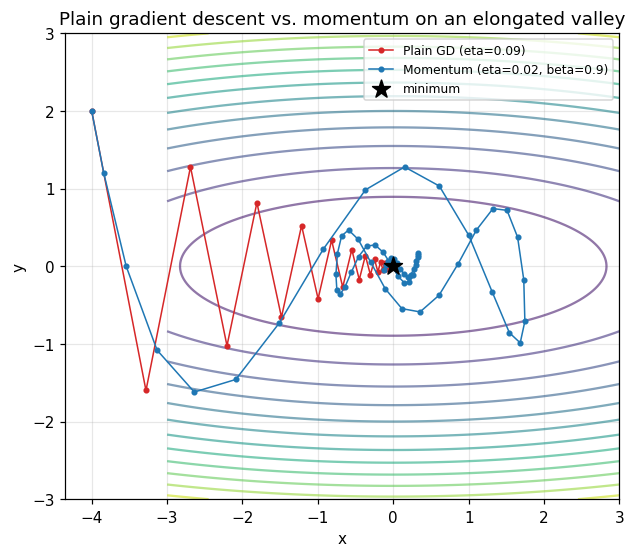

In [161]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
cs = ax.contour(Xg, Yg, Xg**2 + 10*Yg**2, levels=15, cmap="viridis", alpha=0.6)
ax.plot(gd_path_compare[:, 0], gd_path_compare[:, 1], "o-", color="tab:red", markersize=3, linewidth=1, label="Plain GD (eta=0.09)")
ax.plot(momentum_path_compare[:, 0], momentum_path_compare[:, 1], "o-", color="tab:blue", markersize=3, linewidth=1, label="Momentum (eta=0.02, beta=0.9)")
ax.scatter(0, 0, color="black", marker="*", s=150, zorder=5, label="minimum")
ax.set_title("Plain gradient descent vs. momentum on an elongated valley")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8)
plt.savefig("../figures/39_momentum_vs_gd.png", dpi=110, bbox_inches="tight")
plt.show()

In this experiment, momentum's path shows less oscillation in $y$ than plain gradient descent's visible zig-zag, using a smaller learning rate. This is a property of this specific landscape and hyperparameter choice, not a claim that momentum converges faster in every problem - different learning rates and momentum coefficients would change this comparison, sometimes substantially.

## 8.6 RMSProp

Plain gradient descent (and momentum) apply the *same* learning rate to
every parameter, regardless of how large that parameter's typical
gradient is. RMSProp addresses this:

$$s_t = \beta s_{t-1} + (1-\beta)g_t^2 \qquad
\theta_t = \theta_{t-1} - \frac{\eta g_t}{\sqrt{s_t}+\epsilon}$$

$s_t$ is an exponentially weighted moving average of *squared* gradients
per parameter. Parameters with consistently large gradients accumulate a
large $s_t$, shrinking their effective step; parameters with small
gradients keep a relatively larger effective step. $\epsilon$ (a small
constant, e.g. $10^{-8}$) prevents division by zero when $s_t$ is still
near zero.

In [162]:
print(inspect.getsource(opt.rmsprop_update))

def rmsprop_update(params, grads, cache, learning_rate, beta, epsilon):
    """
    s_t = beta * s_(t-1) + (1-beta) * g_t^2
    theta_t = theta_(t-1) - learning_rate * g_t / (sqrt(s_t) + epsilon)
    Maintains an exponentially weighted moving average of squared
    gradients per parameter: parameters with consistently large gradients
    get a smaller effective step, and vice versa. epsilon prevents
    division by zero when s_t is still near zero.
    """
    new_cache = {k: beta * cache[k] + (1 - beta) * grads[f"d{k}"] ** 2 for k in params}
    new_params = {
        k: params[k] - learning_rate * grads[f"d{k}"] / (np.sqrt(new_cache[k]) + epsilon)
        for k in params
    }
    return new_params, new_cache



In [163]:
# Small hand-checkable numerical validation: one scalar "parameter", one step
rmsprop_check_params = {"theta": np.array([5.0])}
rmsprop_check_grads = {"dtheta": np.array([2.0])}
rmsprop_check_cache = opt.initialize_rmsprop_state(rmsprop_check_params)

assert rmsprop_check_cache["theta"].shape == rmsprop_check_params["theta"].shape

new_params_rms, new_cache_rms = opt.rmsprop_update(
    rmsprop_check_params, rmsprop_check_grads, rmsprop_check_cache,
    learning_rate=0.1, beta=0.9, epsilon=1e-8
)

expected_s1 = 0.9*0.0 + 0.1*(2.0**2)
expected_theta1 = 5.0 - 0.1*2.0/(np.sqrt(expected_s1)+1e-8)

print(f"s_1: expected = {expected_s1}, computed = {new_cache_rms['theta'][0]}")
print(f"theta_1: expected = {expected_theta1:.6f}, computed = {new_params_rms['theta'][0]:.6f}")

assert np.isclose(new_cache_rms["theta"][0], expected_s1)
assert np.isclose(new_params_rms["theta"][0], expected_theta1)
assert np.all(new_cache_rms["theta"] > 0)  # epsilon protects the denominator from being exactly 0
assert np.isfinite(new_params_rms["theta"]).all()
print("\nRMSProp validation passed: state shape correct, values match hand calculation, finite, epsilon-protected.")

s_1: expected = 0.4, computed = 0.3999999999999999
theta_1: expected = 4.683772, computed = 4.683772

RMSProp validation passed: state shape correct, values match hand calculation, finite, epsilon-protected.


## 8.7 Adam

$$m_t = \beta_1m_{t-1}+(1-\beta_1)g_t \qquad v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2$$

$m_t$ (first moment) is momentum-like directional history; $v_t$ (second
moment) is an RMSProp-like squared-gradient scale - **not** the
statistical variance of the gradient in the strict sense (that would
require subtracting the squared mean), just an exponentially weighted
average of squared gradients. Since $m_0=v_0=0$, early estimates are
biased toward zero; **bias correction** compensates:

$$\hat{m}_t=\frac{m_t}{1-\beta_1^t} \qquad \hat{v}_t=\frac{v_t}{1-\beta_2^t}
\qquad \theta_t=\theta_{t-1}-\frac{\eta\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}$$

Common defaults ($\beta_1=0.9,\ \beta_2=0.999,\ \epsilon=10^{-8}$) are
used below - common, not universally optimal.

In [164]:
print(inspect.getsource(opt.adam_update))

def adam_update(params, grads, m, v, t, learning_rate, beta1, beta2, epsilon):
    """
    m_t = beta1*m_(t-1) + (1-beta1)*g_t             (first moment: directional history)
    v_t = beta2*v_(t-1) + (1-beta2)*g_t^2            (second moment: squared-gradient scale)
    m_hat = m_t / (1 - beta1^t)                      (bias correction - m_0=v_0=0 biases
    v_hat = v_t / (1 - beta2^t)                       early estimates toward zero)
    theta_t = theta_(t-1) - learning_rate * m_hat / (sqrt(v_hat) + epsilon)

    `t` (starting at 1, not 0) is required for bias correction: beta1^t and
    beta2^t must shrink toward 0 as training progresses, so the correction
    factor 1/(1-beta^t) shrinks from a large initial value toward 1.
    Combines momentum-like directional smoothing (m) with RMSProp-like
    adaptive per-parameter scaling (v) - the second moment tracks squared
    gradients, which is not the same as the statistical variance of the
    gradient unless the mean gradient is zero.

In [165]:
# Manual hand-calculation check for the first two Adam steps, constant gradient g=2
adam_check_params = {"theta": np.array([5.0])}
adam_check_grads = {"dtheta": np.array([2.0])}
m_check, v_check = opt.initialize_adam_state(adam_check_params)

assert m_check["theta"].shape == adam_check_params["theta"].shape
assert v_check["theta"].shape == adam_check_params["theta"].shape

expected_thetas = [4.9, 4.8]  # hand-calculated: see markdown derivation above
for t in range(1, 3):
    adam_check_params, m_check, v_check = opt.adam_update(
        adam_check_params, adam_check_grads, m_check, v_check, t,
        learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8
    )
    print(f"t={t}: theta = {adam_check_params['theta'][0]:.6f} (hand-calculated expected: {expected_thetas[t-1]})")
    assert np.isclose(adam_check_params["theta"][0], expected_thetas[t-1], atol=1e-6)
    assert np.isfinite(adam_check_params["theta"]).all()
    assert t > 0  # timestep increases correctly, starting at 1

print("\nAdam validation passed: matches hand-calculated values for t=1,2; timestep and outputs finite.")

t=1: theta = 4.900000 (hand-calculated expected: 4.9)
t=2: theta = 4.800000 (hand-calculated expected: 4.8)

Adam validation passed: matches hand-calculated values for t=1,2; timestep and outputs finite.


With a constant gradient $g=2$, bias correction makes
$\hat m_t=g$ and $\hat v_t=g^2$ *exactly* at every $t$ (the correction
factor exactly cancels the exponential-average's own scaling) - so the
update simplifies to $\theta_t\leftarrow\theta_{t-1}-\eta\cdot
\text{sign}(g)$, i.e. exactly $\eta=0.1$ per step, matching the
$5.0\rightarrow4.9\rightarrow4.8$ pattern above. This clean special
case is a useful sanity check, not the general behavior for a
changing gradient.

## 8.8 Optimizer State and Memory

| Optimizer | Additional State | Update Information Used | Approx. Extra Memory per Parameter |
|---|---|---|---|
| Gradient Descent | none | current gradient only | 0 |
| Momentum | velocity $v$ | current gradient + running velocity | 1 value |
| RMSProp | squared-gradient accumulator $s$ | current gradient + running squared-gradient average | 1 value |
| Adam | first moment $m$ + second moment $v$ | current gradient + both running averages | 2 values |

In [166]:
# Concrete numbers for this project's 17-parameter network (Part 6, Section 6.10)
p_count = 17
memory_multipliers = {"Gradient Descent": 0, "Momentum": 1, "RMSProp": 1, "Adam": 2}
for name, mult in memory_multipliers.items():
    print(f"{name:16s}: {mult} extra value(s) per parameter -> {mult * p_count} extra stored numbers for this network")

Gradient Descent: 0 extra value(s) per parameter -> 0 extra stored numbers for this network
Momentum        : 1 extra value(s) per parameter -> 17 extra stored numbers for this network
RMSProp         : 1 extra value(s) per parameter -> 17 extra stored numbers for this network
Adam            : 2 extra value(s) per parameter -> 34 extra stored numbers for this network


More sophisticated optimizers trade additional per-parameter memory (and a small amount of extra arithmetic per update) for potentially better-conditioned updates - a cost that scales linearly with parameter count, same as the gradients themselves.

## 8.9 Learning Rate and Convergence

A systematic learning-rate sweep for plain gradient descent, training
Part 6's network on the XOR dataset, same initialization/architecture/seed:

In [167]:
def train_gd_network(params, iters, lr):
    params = {k: v.copy() for k, v in params.items()}
    loss_hist = []
    for _ in range(iters):
        A2, cache = nnfs.forward_propagation(X_xor, params)
        loss = nnfs.binary_cross_entropy(y_xor, A2.flatten())
        loss_hist.append(loss)
        if not np.isfinite(loss):
            break
        grads = nnfs.backward_propagation(y_xor, cache, params)
        params = opt.gradient_descent_update(params, grads, lr)
    return params, np.array(loss_hist)

base_init_params = nnfs.initialize_parameters(2, 4, seed=42, scale=2.0)
lr_sweep_values = [0.0001, 0.001, 0.01, 0.1]
lr_sweep_results = []

for lr in lr_sweep_values:
    params_lr, hist_lr = train_gd_network(base_init_params, 5000, lr)
    preds_lr = nnfs.predict(X_xor, params_lr)
    acc_lr = np.mean(preds_lr == y_xor)
    all_finite_lr = np.isfinite(hist_lr).all()
    lr_sweep_results.append({"Learning Rate": lr, "Final Loss": hist_lr[-1],
                               "Accuracy": acc_lr, "All Finite": all_finite_lr})
    print(f"lr={lr}: final_loss={hist_lr[-1]:.4f}, accuracy={acc_lr:.4f}, all_finite={all_finite_lr}")

lr_sweep_table = pd.DataFrame(lr_sweep_results)
lr_sweep_table

lr=0.0001: final_loss=1.0891, accuracy=0.2650, all_finite=True
lr=0.001: final_loss=0.4743, accuracy=0.7200, all_finite=True
lr=0.01: final_loss=0.0807, accuracy=1.0000, all_finite=True
lr=0.1: final_loss=0.0040, accuracy=1.0000, all_finite=True


   Learning Rate  Final Loss  Accuracy  All Finite
0         0.0001    1.089129     0.265        True
1         0.0010    0.474275     0.720        True
2         0.0100    0.080710     1.000        True
3         0.1000    0.004025     1.000        True

In this experiment, final loss decreases monotonically as the learning rate increases across this range (5000 iterations was not enough for the smallest rate to fully converge). This does not mean an even larger learning rate would continue to improve results indefinitely - Section 8.2 already showed a learning rate large enough to diverge on a simpler function; no single learning rate is claimed to be universally best.

## 8.10 Hyperparameter Sensitivity

**Momentum's $\beta$** (fixed $\eta=0.1$), same network/dataset/seed:

In [168]:
def train_momentum_network(params, iters, lr, beta):
    params = {k: v.copy() for k, v in params.items()}
    velocity = opt.initialize_momentum_state(params)
    loss_hist = []
    for _ in range(iters):
        A2, cache = nnfs.forward_propagation(X_xor, params)
        loss = nnfs.binary_cross_entropy(y_xor, A2.flatten())
        loss_hist.append(loss)
        grads = nnfs.backward_propagation(y_xor, cache, params)
        params, velocity = opt.momentum_update(params, grads, velocity, lr, beta)
    return params, np.array(loss_hist)

beta_values = [0.0, 0.5, 0.9]
beta_results = []
for beta in beta_values:
    _, hist_beta = train_momentum_network(base_init_params, 3000, 0.1, beta)
    beta_results.append({"Beta": beta, "Final Loss": hist_beta[-1]})
    print(f"beta={beta}: final_loss={hist_beta[-1]:.4f}")
pd.DataFrame(beta_results)

beta=0.0: final_loss=0.0070
beta=0.5: final_loss=0.0033
beta=0.9: final_loss=0.0006


   Beta  Final Loss
0   0.0    0.007033
1   0.5    0.003320
2   0.9    0.000621

In [169]:
def train_adam_network(params, iters, lr):
    params = {k: v.copy() for k, v in params.items()}
    m_state, v_state = opt.initialize_adam_state(params)
    loss_hist = []
    for t in range(1, iters + 1):
        A2, cache = nnfs.forward_propagation(X_xor, params)
        loss = nnfs.binary_cross_entropy(y_xor, A2.flatten())
        loss_hist.append(loss)
        grads = nnfs.backward_propagation(y_xor, cache, params)
        params, m_state, v_state = opt.adam_update(params, grads, m_state, v_state, t, lr, 0.9, 0.999, 1e-8)
    return params, np.array(loss_hist)

print("Adam learning rate sensitivity:")
adam_lr_results = []
for lr in [0.01, 0.1]:
    _, hist_adam_lr = train_adam_network(base_init_params, 3000, lr)
    adam_lr_results.append({"Learning Rate": lr, "Final Loss": hist_adam_lr[-1]})
    print(f"lr={lr}: final_loss={hist_adam_lr[-1]:.4f}")
pd.DataFrame(adam_lr_results)

Adam learning rate sensitivity:
lr=0.01: final_loss=0.3468
lr=0.1: final_loss=0.0000


   Learning Rate  Final Loss
0           0.01    0.346750
1           0.10    0.000043

Higher momentum $\beta$ (more accumulated velocity) reaches a lower loss within the same 3000 iterations here; for Adam, $\eta=0.1$ reaches a much lower loss than $\eta=0.01$ within 3000 iterations. Neither result establishes a universally optimal setting - these are controlled observations for this specific network, dataset, and iteration budget, changing one hyperparameter at a time.

## 8.11 Optimizer Comparison on Neural Network Training

The main experiment: Part 6's architecture (Input 2 -> Hidden 4, ReLU ->
Output 1, sigmoid) trained on the XOR dataset with **identical initial
parameters** (copied independently for each optimizer) and a fixed
training budget of 5000 updates, using documented per-optimizer
hyperparameters chosen for stable convergence (as flagged in the project
instructions, optimizers are not expected to share one learning rate for
a meaningful comparison - the differences are documented explicitly
rather than hidden).

In [170]:
optimizer_hyperparameters = {
    "Gradient Descent": {"lr": 0.5},
    "Momentum": {"lr": 0.1, "beta": 0.9},
    "RMSProp": {"lr": 0.3, "beta": 0.9, "epsilon": 1e-8},
    "Adam": {"lr": 0.1, "beta1": 0.9, "beta2": 0.999, "epsilon": 1e-8},
}
for name, hp in optimizer_hyperparameters.items():
    print(f"{name}: {hp}")

Gradient Descent: {'lr': 0.5}
Momentum: {'lr': 0.1, 'beta': 0.9}
RMSProp: {'lr': 0.3, 'beta': 0.9, 'epsilon': 1e-08}
Adam: {'lr': 0.1, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-08}


In [171]:
def train_with_optimizer(initial_params, optimizer_name, hp, iters=5000):
    params = {k: v.copy() for k, v in initial_params.items()}
    loss_hist = []

    if optimizer_name == "Momentum":
        velocity = opt.initialize_momentum_state(params)
    elif optimizer_name == "RMSProp":
        cache = opt.initialize_rmsprop_state(params)
    elif optimizer_name == "Adam":
        m_state, v_state = opt.initialize_adam_state(params)

    for t in range(1, iters + 1):
        A2, fwd_cache = nnfs.forward_propagation(X_xor, params)
        loss = nnfs.binary_cross_entropy(y_xor, A2.flatten())
        loss_hist.append(loss)
        grads = nnfs.backward_propagation(y_xor, fwd_cache, params)

        if optimizer_name == "Gradient Descent":
            params = opt.gradient_descent_update(params, grads, hp["lr"])
        elif optimizer_name == "Momentum":
            params, velocity = opt.momentum_update(params, grads, velocity, hp["lr"], hp["beta"])
        elif optimizer_name == "RMSProp":
            params, cache = opt.rmsprop_update(params, grads, cache, hp["lr"], hp["beta"], hp["epsilon"])
        elif optimizer_name == "Adam":
            params, m_state, v_state = opt.adam_update(params, grads, m_state, v_state, t,
                                                          hp["lr"], hp["beta1"], hp["beta2"], hp["epsilon"])

    return params, np.array(loss_hist)

shared_initial_params = nnfs.initialize_parameters(2, 4, seed=42, scale=2.0)
optimizer_results = {}
for name, hp in optimizer_hyperparameters.items():
    final_params, loss_hist = train_with_optimizer(shared_initial_params, name, hp)
    preds = nnfs.predict(X_xor, final_params)
    accuracy = np.mean(preds == y_xor)
    optimizer_results[name] = {"params": final_params, "loss_history": loss_hist, "accuracy": accuracy}
    print(f"{name}: final_loss={loss_hist[-1]:.6f}, accuracy={accuracy:.4f}, "
          f"all_finite={np.isfinite(loss_hist).all()}")

Gradient Descent: final_loss=0.000738, accuracy=1.0000, all_finite=True
Momentum: final_loss=0.000357, accuracy=1.0000, all_finite=True
RMSProp: final_loss=0.000000, accuracy=1.0000, all_finite=True
Adam: final_loss=0.000012, accuracy=1.0000, all_finite=True


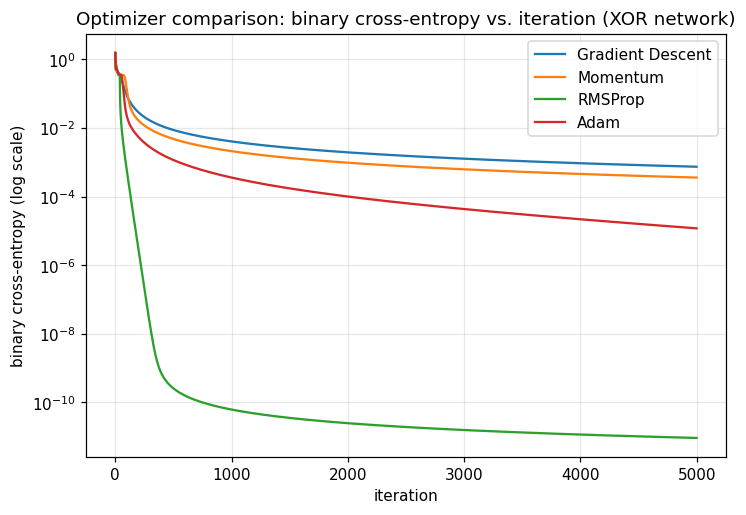

In [172]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for name, result in optimizer_results.items():
    ax.plot(result["loss_history"], label=name)
ax.set_yscale("log")
ax.set_title("Optimizer comparison: binary cross-entropy vs. iteration (XOR network)")
ax.set_xlabel("iteration")
ax.set_ylabel("binary cross-entropy (log scale)")
ax.legend()
plt.savefig("../figures/40_optimizer_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

In [173]:
optimizer_comparison_table = pd.DataFrame([
    {"Optimizer": name, "Final Loss": result["loss_history"][-1],
     "Accuracy": result["accuracy"], "Updates": len(result["loss_history"])}
    for name, result in optimizer_results.items()
])
optimizer_comparison_table

          Optimizer    Final Loss  Accuracy  Updates
0  Gradient Descent  7.382385e-04       1.0     5000
1          Momentum  3.574359e-04       1.0     5000
2           RMSProp  9.265236e-12       1.0     5000
3              Adam  1.183846e-05       1.0     5000

Under these hyperparameter settings and this training budget, all four optimizers reach high accuracy on this dataset, with RMSProp and Adam reaching the lowest final loss in this run. This is a controlled comparison specific to this architecture, dataset,and hyperparameter choices - it does not establish that any one optimizer is universally superior.

**Additional validation.** The checks below strengthen assertion
coverage for the optimizer implementations and experiments above: update
direction, state shapes, shape preservation after an update, Adam's
timestep sequencing, loss-history lengths for the fixed-iteration
experiments, and reproducibility under a repeated run.

In [174]:
# A. Gradient descent moves a parameter in the negative-gradient direction
theta_dir_check = np.array([5.0])
positive_gradient = np.array([2.0])
theta_dir_updated = opt.gradient_descent_update({"theta": theta_dir_check}, {"dtheta": positive_gradient}, learning_rate=0.1)
assert theta_dir_updated["theta"][0] < theta_dir_check[0]
print(f"A. GD direction: theta {theta_dir_check[0]} -> {theta_dir_updated['theta'][0]} "
      f"(decreased, as expected for a positive gradient and positive learning rate).")

# B-E. State shapes and shape preservation after an update, using the real network's parameters
shape_check_params = nnfs.initialize_parameters(2, 4, seed=42, scale=2.0)
_, shape_check_cache = nnfs.forward_propagation(X_xor, shape_check_params)
shape_check_grads = nnfs.backward_propagation(y_xor, shape_check_cache, shape_check_params)

# B. Momentum state shapes
velocity_check = opt.initialize_momentum_state(shape_check_params)
for key in shape_check_params:
    assert velocity_check[key].shape == shape_check_params[key].shape
updated_params_mom, velocity_check = opt.momentum_update(shape_check_params, shape_check_grads, velocity_check, 0.1, 0.9)
for key in shape_check_params:
    assert updated_params_mom[key].shape == shape_check_params[key].shape  # E
print("B/E. Momentum: state shapes and post-update parameter shapes match.")

# C. RMSProp state shapes
cache_check = opt.initialize_rmsprop_state(shape_check_params)
for key in shape_check_params:
    assert cache_check[key].shape == shape_check_params[key].shape
updated_params_rms, cache_check = opt.rmsprop_update(shape_check_params, shape_check_grads, cache_check, 0.1, 0.9, 1e-8)
for key in shape_check_params:
    assert updated_params_rms[key].shape == shape_check_params[key].shape  # E
print("C/E. RMSProp: state shapes and post-update parameter shapes match.")

# D. Adam first/second moment state shapes
m_check_full, v_check_full = opt.initialize_adam_state(shape_check_params)
for key in shape_check_params:
    assert m_check_full[key].shape == shape_check_params[key].shape
    assert v_check_full[key].shape == shape_check_params[key].shape
updated_params_adam, m_check_full, v_check_full = opt.adam_update(
    shape_check_params, shape_check_grads, m_check_full, v_check_full, 1, 0.1, 0.9, 0.999, 1e-8
)
for key in shape_check_params:
    assert updated_params_adam[key].shape == shape_check_params[key].shape  # E
print("D/E. Adam: first/second moment state shapes and post-update parameter shapes match.")

# E. Gradient descent update also preserves shapes
updated_params_gd = opt.gradient_descent_update(shape_check_params, shape_check_grads, 0.1)
for key in shape_check_params:
    assert updated_params_gd[key].shape == shape_check_params[key].shape
print("E. Gradient descent: post-update parameter shapes match for all four optimizers.")

A. GD direction: theta 5.0 -> 4.8 (decreased, as expected for a positive gradient and positive learning rate).
B/E. Momentum: state shapes and post-update parameter shapes match.
C/E. RMSProp: state shapes and post-update parameter shapes match.
D/E. Adam: first/second moment state shapes and post-update parameter shapes match.
E. Gradient descent: post-update parameter shapes match for all four optimizers.


In [175]:
# F. Adam timestep sequencing actually used by bias correction
timesteps_check = []
m_seq, v_seq = opt.initialize_adam_state({"theta": np.array([5.0])})
params_seq = {"theta": np.array([5.0])}
for t in range(1, 3):
    timesteps_check.append(t)
    params_seq, m_seq, v_seq = opt.adam_update(params_seq, {"dtheta": np.array([2.0])}, m_seq, v_seq, t, 0.1, 0.9, 0.999, 1e-8)
assert timesteps_check == [1, 2]
print(f"F. Adam timestep sequence used for bias correction: {timesteps_check} (matches expected [1, 2]).")

# G. Loss-history lengths for the fixed-iteration experiments run earlier in this section
assert len(optimizer_results["Gradient Descent"]["loss_history"]) == 5000
assert len(optimizer_results["Momentum"]["loss_history"]) == 5000
assert len(optimizer_results["RMSProp"]["loss_history"]) == 5000
assert len(optimizer_results["Adam"]["loss_history"]) == 5000
print("G. Loss-history length validation passed: all four Section 8.11 optimizer runs recorded exactly 5000 iterations.")

# H. Reproducibility: repeat one controlled optimizer experiment (Adam) and compare
repeat_params_a, repeat_hist_a = train_adam_network(base_init_params, 1000, 0.1)
repeat_params_b, repeat_hist_b = train_adam_network(base_init_params, 1000, 0.1)
assert np.allclose(repeat_hist_a, repeat_hist_b, atol=1e-12)
print(f"H. Reproducibility validated: two independent runs with identical initial parameters, "
      f"dataset, seed, and hyperparameters produce matching loss histories "
      f"(final loss {repeat_hist_a[-1]:.8f} vs {repeat_hist_b[-1]:.8f}).")

F. Adam timestep sequence used for bias correction: [1, 2] (matches expected [1, 2]).
G. Loss-history length validation passed: all four Section 8.11 optimizer runs recorded exactly 5000 iterations.
H. Reproducibility validated: two independent runs with identical initial parameters, dataset, seed, and hyperparameters produce matching loss histories (final loss 0.00035767 vs 0.00035767).


## 8.12 Training Dynamics and Loss Curves

Examining the same loss curves from Section 8.11 more closely (no new
training):

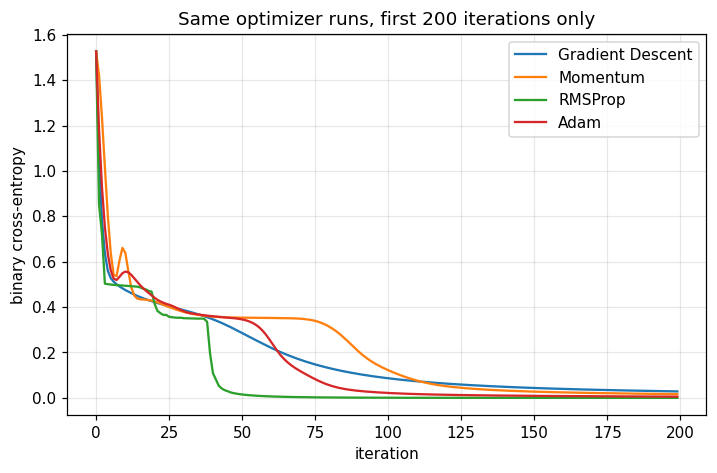

In [176]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name, result in optimizer_results.items():
    ax.plot(result["loss_history"][:200], label=name)
ax.set_title("Same optimizer runs, first 200 iterations only")
ax.set_xlabel("iteration")
ax.set_ylabel("binary cross-entropy")
ax.legend()
plt.savefig("../figures/41_optimizer_early_iterations.png", dpi=110, bbox_inches="tight")
plt.show()

Looking at the full curves (Section 8.11) and this early-iteration zoom
together: all four curves show rapid early improvement followed by a
flatter, slower-improving region (a plateau) - a common qualitative shape
for gradient-based training, though the exact iteration at which each
curve flattens differs by optimizer. None of the four curves in this
particular run show sustained oscillation or instability; that is a
property of this specific experiment's hyperparameters, not a claim that
any of these optimizers cannot produce noisy or unstable training under
different settings (Section 8.2 already demonstrated genuine divergence
under a poorly chosen learning rate on a simpler function).

**Optimization progress is not the same as generalization.** Everything
measured in this section - loss and accuracy - is computed on the same
data the network was trained on. A lower training loss shows the
optimizer is doing its job (reducing the training objective); it says
nothing by itself about how the model would perform on data it has not
seen. This project does not use a train/test split, so no generalization
claims are made anywhere in this section - that distinction is left for
future work, as flagged in Section 8.15's transition.

## 8.13 Controlled Optimization Experiments

### Experiment 1 - Optimizer Trajectories

In [177]:
def run_trajectory(method, start, steps, **hp):
    p = np.array(start, dtype=float)
    path = [p.copy()]
    if method == "Momentum":
        velocity = np.zeros(2)
    elif method == "RMSProp":
        cache_traj = np.zeros(2)
    elif method == "Adam":
        m_traj, v_traj = np.zeros(2), np.zeros(2)

    for t in range(1, steps + 1):
        g = grad_elongated(*p)
        if method == "Gradient Descent":
            p = p - hp["lr"] * g
        elif method == "Momentum":
            velocity = hp["beta"] * velocity + g
            p = p - hp["lr"] * velocity
        elif method == "RMSProp":
            cache_traj = hp["beta"] * cache_traj + (1 - hp["beta"]) * g ** 2
            p = p - hp["lr"] * g / (np.sqrt(cache_traj) + 1e-8)
        elif method == "Adam":
            m_traj = hp["beta1"] * m_traj + (1 - hp["beta1"]) * g
            v_traj = hp["beta2"] * v_traj + (1 - hp["beta2"]) * g ** 2
            m_hat_traj = m_traj / (1 - hp["beta1"] ** t)
            v_hat_traj = v_traj / (1 - hp["beta2"] ** t)
            p = p - hp["lr"] * m_hat_traj / (np.sqrt(v_hat_traj) + 1e-8)
        path.append(p.copy())
    return np.array(path)

trajectory_configs = {
    "Gradient Descent": {"lr": 0.09},
    "Momentum": {"lr": 0.02, "beta": 0.9},
    "RMSProp": {"lr": 0.08, "beta": 0.9},
    "Adam": {"lr": 0.3, "beta1": 0.9, "beta2": 0.999},
}
start_point = (-4.0, 2.0)
steps_traj = 100
trajectories = {}
trajectory_rows = []

for name, hp in trajectory_configs.items():
    path = run_trajectory(name, start_point, steps_traj, **hp)
    trajectories[name] = path
    initial_obj = f_elongated(*start_point)
    final_obj = f_elongated(*path[-1])
    trajectory_rows.append({"Optimizer": name, "Initial Objective": initial_obj,
                              "Final Objective": final_obj, "Steps": steps_traj,
                              "Final Point": tuple(np.round(path[-1], 4))})
    assert np.isfinite(path).all()

trajectory_table = pd.DataFrame(trajectory_rows)
trajectory_table

          Optimizer  Initial Objective  ...  Steps         Final Point
0  Gradient Descent               56.0  ...    100         (-0.0, 0.0)
1          Momentum               56.0  ...    100  (-0.0135, -0.0105)
2           RMSProp               56.0  ...    100        (-0.0, -0.0)
3              Adam               56.0  ...    100    (0.0057, 0.0007)

[4 rows x 5 columns]

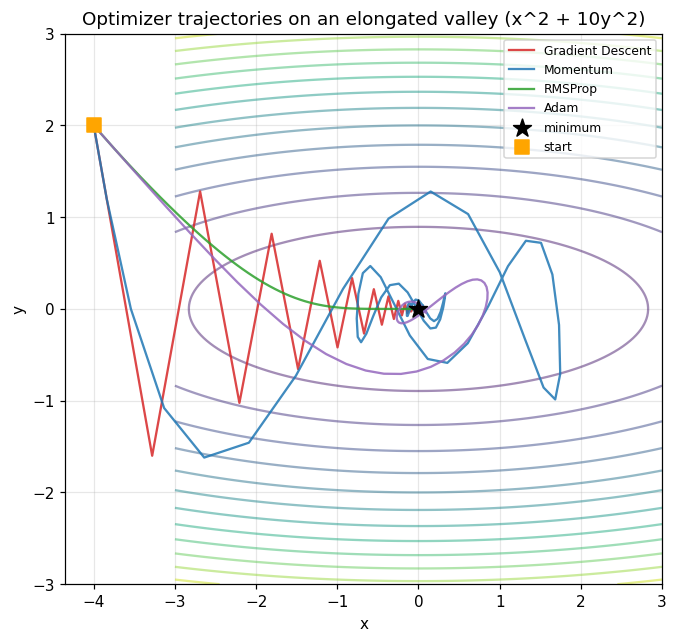

In [178]:
fig, ax = plt.subplots(figsize=(7, 6.5))
cs = ax.contour(Xg, Yg, Xg**2 + 10*Yg**2, levels=15, cmap="viridis", alpha=0.5)
colors_traj = {"Gradient Descent": "tab:red", "Momentum": "tab:blue", "RMSProp": "tab:green", "Adam": "tab:purple"}
for name, path in trajectories.items():
    ax.plot(path[:, 0], path[:, 1], "-", color=colors_traj[name], linewidth=1.5, label=name, alpha=0.85)
ax.scatter(0, 0, color="black", marker="*", s=150, zorder=5, label="minimum")
ax.scatter(*start_point, color="orange", marker="s", s=80, zorder=5, label="start")
ax.set_title("Optimizer trajectories on an elongated valley (x^2 + 10y^2)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8)
plt.savefig("../figures/42_optimizer_trajectories.png", dpi=110, bbox_inches="tight")
plt.show()

All four optimizers reach very small final objective values in 100 steps under these documented, individually-tuned hyperparameters - plain gradient descent's path shows visible zig-zag in $y$ before straightening out near the minimum, while momentum, RMSProp, and Adam's paths curve more directly, consistent with each mechanism's design (momentum smoothing oscillating directions, RMSProp/Adam scaling per-coordinate step sizes).

### Experiment 2 - Mini-Batch Size

All three strategies below use the **same number of epochs**, so each gets the same number of complete passes through the training data. Batch size still determines how many parameter *updates* occur within that many epochs - a smaller batch size means more updates per epoch, purely as a consequence of how many batches fit in one pass through the data, not a separate experimental choice.

In [179]:
def train_with_batch_size(initial_params, batch_size, epochs, lr, seed=123):
    params = {k: v.copy() for k, v in initial_params.items()}
    rng = np.random.RandomState(seed)
    loss_hist = []
    epoch_end_full_loss = []
    update_count = 0
    for epoch in range(epochs):
        for Xb, yb in opt.create_mini_batches(X_xor, y_xor, batch_size, rng):
            A2, cache = nnfs.forward_propagation(Xb, params)
            loss_hist.append(nnfs.binary_cross_entropy(yb, A2.flatten()))
            grads = nnfs.backward_propagation(yb, cache, params)
            params = opt.gradient_descent_update(params, grads, lr)
            update_count += 1
        # Full-dataset loss using the parameters as they stand at the end of this epoch
        epoch_full_loss = nnfs.binary_cross_entropy(y_xor, nnfs.forward_propagation(X_xor, params)[0].flatten())
        epoch_end_full_loss.append(epoch_full_loss)
    return params, np.array(loss_hist), update_count, np.array(epoch_end_full_loss)

SHARED_EPOCHS = 20     # identical for all three strategies
SHARED_BATCH_LR = 0.5  # identical for all three strategies - the only intended difference is batch size
batch_configs = [
    ("Batch (bs=200)", 200, SHARED_BATCH_LR, SHARED_EPOCHS),
    ("Mini-batch (bs=20)", 20, SHARED_BATCH_LR, SHARED_EPOCHS),
    ("Stochastic (bs=1)", 1, SHARED_BATCH_LR, SHARED_EPOCHS),
]

# Validate the controlled-experiment condition itself: same learning rate for all three
learning_rates_used = [config[2] for config in batch_configs]
assert len(set(learning_rates_used)) == 1
print(f"Shared learning rate confirmed: {learning_rates_used[0]} used by all three strategies.\n")

batch_results = []
batch_loss_histories = {}
batch_epoch_histories = {}
n_dataset = X_xor.shape[0]

for label, bs, lr, epochs in batch_configs:
    final_params_b, loss_hist_b, updates_b, epoch_hist_b = train_with_batch_size(shared_initial_params, bs, epochs, lr)
    full_dataset_loss = nnfs.binary_cross_entropy(y_xor, nnfs.forward_propagation(X_xor, final_params_b)[0].flatten())
    accuracy_b = np.mean(nnfs.predict(X_xor, final_params_b) == y_xor)
    batch_loss_histories[label] = loss_hist_b
    batch_epoch_histories[label] = epoch_hist_b

    # Loss-history / update-count validation: updates == epochs * batches_per_epoch
    batches_per_epoch = int(np.ceil(n_dataset / bs))
    expected_updates = epochs * batches_per_epoch
    assert updates_b == expected_updates
    assert len(loss_hist_b) == expected_updates
    assert len(epoch_hist_b) == SHARED_EPOCHS  # one full-dataset loss point per epoch

    all_finite_b = np.isfinite(loss_hist_b).all() and np.isfinite(full_dataset_loss) and np.isfinite(epoch_hist_b).all()
    batch_results.append({"Strategy": label, "Batch Size": bs, "Learning Rate": lr, "Epochs": epochs,
                            "Updates": updates_b, "Full-Dataset Loss (final)": full_dataset_loss,
                            "Accuracy": accuracy_b, "All Finite": all_finite_b})

batch_table = pd.DataFrame(batch_results)
print("Update-count validation passed: updates == epochs * batches_per_epoch for all three strategies.")
batch_table

Shared learning rate confirmed: 0.5 used by all three strategies.

Update-count validation passed: updates == epochs * batches_per_epoch for all three strategies.


             Strategy  Batch Size  ...  Accuracy  All Finite
0      Batch (bs=200)         200  ...      0.73        True
1  Mini-batch (bs=20)          20  ...      1.00        True
2   Stochastic (bs=1)           1  ...      0.75        True

[3 rows x 8 columns]

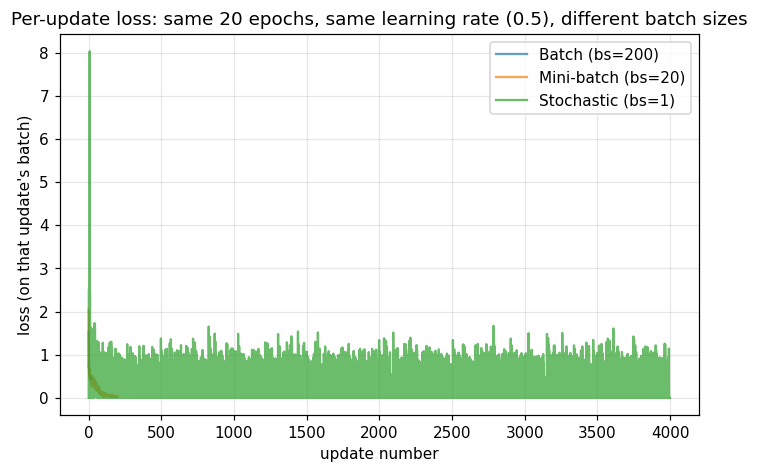

In [180]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for label, hist_b in batch_loss_histories.items():
    ax.plot(hist_b, alpha=0.7, label=label)
ax.set_title(f"Per-update loss: same {SHARED_EPOCHS} epochs, same learning rate ({SHARED_BATCH_LR}), different batch sizes")
ax.set_xlabel("update number")
ax.set_ylabel("loss (on that update's batch)")
ax.legend()
plt.savefig("../figures/43_batch_size_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

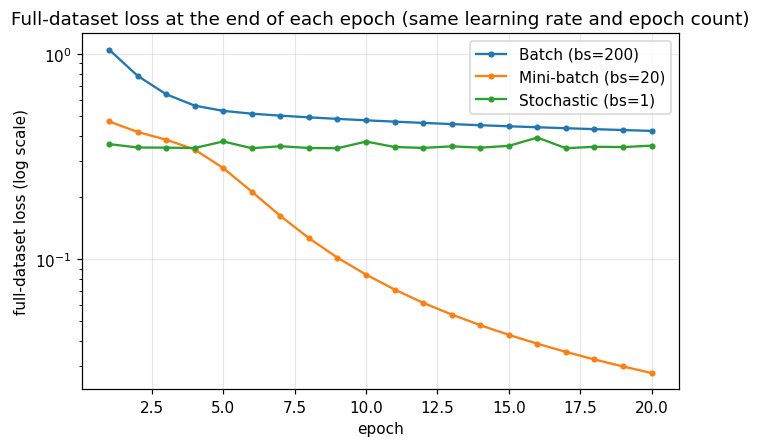

In [181]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for label, epoch_hist_plot in batch_epoch_histories.items():
    ax.plot(range(1, SHARED_EPOCHS + 1), epoch_hist_plot, marker="o", markersize=3, label=label)
ax.set_yscale("log")
ax.set_title("Full-dataset loss at the end of each epoch (same learning rate and epoch count)")
ax.set_xlabel("epoch")
ax.set_ylabel("full-dataset loss (log scale)")
ax.legend()
plt.savefig("../figures/45_batch_epoch_loss.png", dpi=110, bbox_inches="tight")
plt.show()

With batch size as the only difference between the three runs, the
stochastic strategy (bs=1) does **not** diverge under this shared
learning rate, but its per-update loss curve is visibly noisy - swinging
between near-zero and values above 1 from one update to the next, since
each update reacts to a single example's gradient rather than an averaged
one. Its full-dataset loss and accuracy at the end of training are worse
than mini-batch's in this run: a learning rate of 0.5 that mini-batch
handles well is large relative to the noise of single-example gradients.
The batch run (bs=200) is limited by having only 20 total updates within
20 epochs, regardless of learning rate. This is the actual measured
outcome under a genuinely controlled comparison (same learning rate, same
epochs, same initialization) - it is not evidence that stochastic
gradient descent is unstable in general, only that this particular
learning rate is not equally well-suited to every batch size on this
dataset, which is itself a meaningful and expected finding from holding
the learning rate fixed.

### Experiment 3 - Neural Network Optimizer Comparison

This is the same systematic comparison already performed in Section 8.11 (identical initial parameters, architecture, dataset, and training budget); results are reproduced here for completeness within this experiments section, without retraining.

In [182]:
optimizer_comparison_table

          Optimizer    Final Loss  Accuracy  Updates
0  Gradient Descent  7.382385e-04       1.0     5000
1          Momentum  3.574359e-04       1.0     5000
2           RMSProp  9.265236e-12       1.0     5000
3              Adam  1.183846e-05       1.0     5000

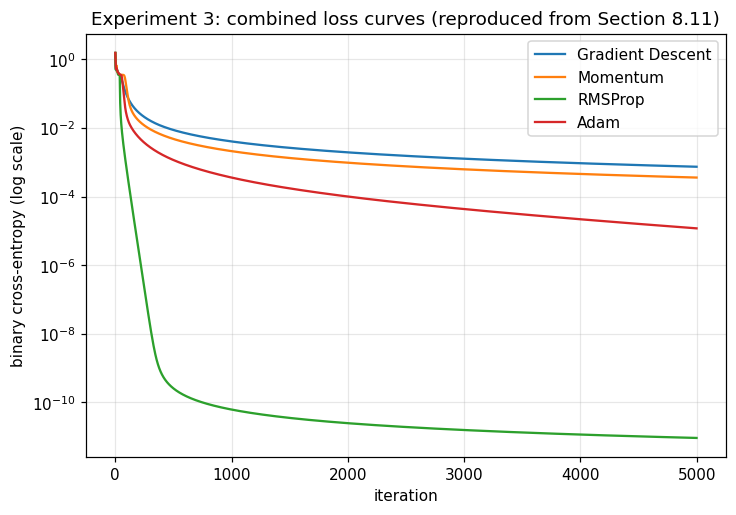

In [183]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for name, result in optimizer_results.items():
    ax.plot(result["loss_history"], label=name)
ax.set_yscale("log")
ax.set_title("Experiment 3: combined loss curves (reproduced from Section 8.11)")
ax.set_xlabel("iteration")
ax.set_ylabel("binary cross-entropy (log scale)")
ax.legend()
plt.savefig("../figures/44_experiment3_combined_loss.png", dpi=110, bbox_inches="tight")
plt.show()

## 8.14 Computational Perspective

For $p$ trainable parameters:
- **Gradient Descent**: $O(p)$ update work, no additional parameter-sized state.
- **Momentum**: $O(p)$ update work, $O(p)$ additional memory (velocity).
- **RMSProp**: $O(p)$ update work, $O(p)$ additional memory (squared-gradient accumulator).
- **Adam**: $O(p)$ update work, $O(2p)$ additional memory (first and second moments).

For large networks, the dominant training cost is typically gradient
*computation* itself (the $O(ndh)$-per-layer cost from Parts 6-7), not
the optimizer update - the update rules above add only a small constant
amount of per-parameter arithmetic on top of the already-computed
gradient.

**Mini-batch size** affects: **memory** (larger batches require holding
more activations simultaneously, per Part 7's memory discussion);
**number of updates** per epoch (smaller batches -> more updates);
**gradient noise** (smaller batches -> noisier per-update gradient
estimates, as seen directly in Section 8.13's Experiment 2); and
**computational efficiency** (very small batches may underuse vectorized
matrix operations' efficiency, while very large batches increase
per-update memory and compute before producing an update).

## 8.15 Summary

1. Backpropagation (Part 7) computes gradients.
2. Optimizers transform gradients into parameter updates.
3. Gradient descent uses only the current gradient.
4. Momentum accumulates directional information across updates.
5. RMSProp adapts per-parameter update scales using squared-gradient history.
6. Adam combines momentum-like first-moment information with adaptive
   second-moment scaling, plus bias correction.
7. Learning rate strongly affects convergence behavior (Sections 8.2, 8.9).
8. Batch size influences the stability and frequency of updates (Sections 8.4, 8.13).
9. Optimizers maintain different amounts of parameter-sized state (Section 8.8).
10. Optimizer behavior depends on the problem and hyperparameters, not
    on any universal ranking (Sections 8.10, 8.11, 8.13).

$$
\text{Forward Pass} \rightarrow \text{Predictions} \rightarrow \text{Loss}
\rightarrow \text{Backpropagation} \rightarrow \text{Gradients} \rightarrow
\text{Optimizer State} \rightarrow \text{Parameter Update} \rightarrow
\text{Updated Model} \rightarrow \text{Next Training Step}
$$

The next stage can build on these training dynamics by studying how
models behave beyond the training data, including validation,
overfitting, and regularization.

---
# 9. Generalization, Overfitting, and Regularization

Parts 6-8 showed how a neural network learns: forward propagation
produces predictions, backpropagation computes gradients, and optimizers
turn those gradients into parameter updates. This section asks a
different kind of question, about the result of that process rather than
the mechanics of it:

**How can we determine whether a model is learning general patterns
rather than merely fitting the training data?**

## 9.1 Training Performance vs. Generalization

$$
\text{Training loss } L_{\text{train}} \qquad \text{Loss on unseen data } L_{\text{unseen}}
$$

Parameters are updated using training data only - Parts 6-8's gradient
descent, momentum, RMSProp, and Adam all computed gradients exclusively
from the training set. A model can therefore achieve a low
$L_{\text{train}}$ while its $L_{\text{unseen}}$ remains high: nothing in
the optimization process itself checks performance on data it never
saw. **Optimization** (reducing the objective on training data) and
**generalization** (performing well on data not used to update
parameters) are different things, and this section demonstrates that
distinction directly rather than only asserting it.

In [184]:
import sys
sys.path.insert(0, "../src")
import generalization as gen

def make_moons_manual(n_samples, noise, seed):
    """
    Manually constructed two-interleaving-half-moons dataset (classic
    nonlinear binary classification shape), generated with NumPy only -
    no sklearn dataset generator.
    """
    n1 = n_samples // 2
    n2 = n_samples - n1
    theta1 = np.linspace(0, np.pi, n1)
    x1, y1 = np.cos(theta1), np.sin(theta1)
    theta2 = np.linspace(0, np.pi, n2)
    x2, y2 = 1 - np.cos(theta2), 1 - np.sin(theta2) - 0.5
    X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
    y = np.concatenate([np.zeros(n1), np.ones(n2)])
    rng = np.random.RandomState(seed)
    X = X + rng.normal(0, noise, X.shape)
    permutation = rng.permutation(n_samples)
    return X[permutation], y[permutation]

np.random.seed(42)
X_moons, y_moons = make_moons_manual(n_samples=160, noise=0.25, seed=42)
print(f"X_moons shape = {X_moons.shape}, y_moons shape = {y_moons.shape}")

X_moons shape = (160, 2), y_moons shape = (160,)


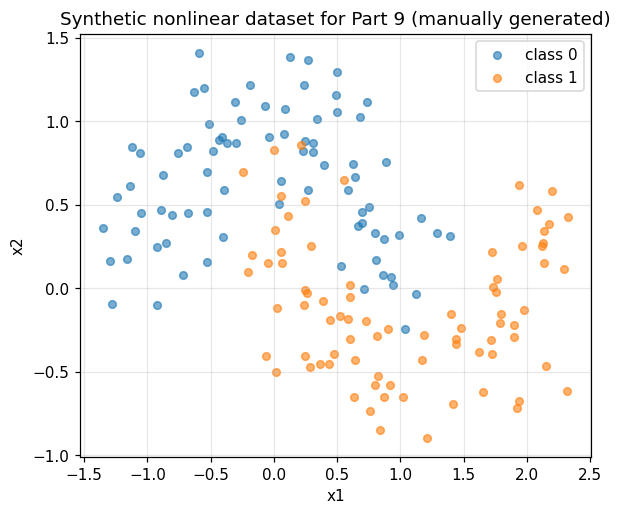

In [185]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], alpha=0.6, s=25, color="tab:blue", label="class 0")
ax.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], alpha=0.6, s=25, color="tab:orange", label="class 1")
ax.set_title("Synthetic nonlinear dataset for Part 9 (manually generated)")
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.legend()
plt.savefig("../figures/46_generalization_dataset.png", dpi=110, bbox_inches="tight")
plt.show()

A first, minimal demonstration: a single small network is trained on half this data, then evaluated on both the data it trained on and a held-out half it never saw during training. The full train/validation/test split machinery is introduced properly in Section 9.2 - this is only a quick preview of the core distinction.

In [186]:
preview_rng = np.random.RandomState(1)
preview_split = preview_rng.permutation(X_moons.shape[0])
half = len(preview_split) // 2
preview_train_idx, preview_unseen_idx = preview_split[:half], preview_split[half:]

preview_params = nnfs.initialize_parameters(2, 8, seed=42, scale=2.0)
for _ in range(2000):
    A2, cache = nnfs.forward_propagation(X_moons[preview_train_idx], preview_params)
    grads = nnfs.backward_propagation(y_moons[preview_train_idx], cache, preview_params)
    preview_params = {k: preview_params[k] - 0.3 * grads[f"d{k}"] for k in preview_params}

preview_train_loss = nnfs.binary_cross_entropy(
    y_moons[preview_train_idx], nnfs.forward_propagation(X_moons[preview_train_idx], preview_params)[0].flatten())
preview_unseen_loss = nnfs.binary_cross_entropy(
    y_moons[preview_unseen_idx], nnfs.forward_propagation(X_moons[preview_unseen_idx], preview_params)[0].flatten())

print(f"Training loss (data used to fit parameters):     {preview_train_loss:.4f}")
print(f"Unseen-data loss (never used for parameter updates): {preview_unseen_loss:.4f}")

Training loss (data used to fit parameters):     0.1136
Unseen-data loss (never used for parameter updates): 0.2159


In this single run, the unseen-data loss is higher than the training loss - consistent with the general point above, though one small experiment does not establish how large this difference will be in general; Sections 9.4-9.13 study this systematically.

## 9.2 Train, Validation, and Test Data

- **Training set**: used to update model parameters (the data gradients in Parts 6-8 are computed from).
- **Validation set**: used to compare choices such as model complexity or regularization strength - never used to update parameters directly.
- **Test set**: reserved for final evaluation only, not used to make any modeling decisions.

Validation data must not be treated as ordinary training data: using it
to update parameters would defeat its purpose as an independent check.

In [187]:
print(inspect.getsource(gen.train_validation_test_split))

def train_validation_test_split(X, y, train_fraction, validation_fraction, rng):
    """
    Shuffle (X, y) using `rng`, then split into train/validation/test
    sets of sizes determined by `train_fraction` and `validation_fraction`
    (the remainder becomes the test set). Returns
    (X_train, y_train, X_val, y_val, X_test, y_test, train_idx, val_idx, test_idx),
    where the index arrays refer to positions in the ORIGINAL (unshuffled)
    X, y - useful for verifying no overlap and full coverage.
    """
    n = X.shape[0]
    permutation = rng.permutation(n)

    n_train = int(round(train_fraction * n))
    n_val = int(round(validation_fraction * n))

    train_idx = permutation[:n_train]
    val_idx = permutation[n_train:n_train + n_val]
    test_idx = permutation[n_train + n_val:]

    return (
        X[train_idx], y[train_idx],
        X[val_idx], y[val_idx],
        X[test_idx], y[test_idx],
        train_idx, val_idx, test_idx,
    )



In [188]:
split_rng = np.random.RandomState(7)
(X_train, y_train, X_val, y_val, X_test, y_test,
 train_idx, val_idx, test_idx) = gen.train_validation_test_split(
    X_moons, y_moons, train_fraction=0.5, validation_fraction=0.25, rng=split_rng
)

print(f"train: {X_train.shape[0]}, validation: {X_val.shape[0]}, test: {X_test.shape[0]}")

# Validation: all examples accounted for, no overlap, consistent shapes
all_idx = np.concatenate([train_idx, val_idx, test_idx])
assert len(all_idx) == X_moons.shape[0]
assert len(np.unique(all_idx)) == X_moons.shape[0]
assert set(train_idx).isdisjoint(set(val_idx))
assert set(train_idx).isdisjoint(set(test_idx))
assert set(val_idx).isdisjoint(set(test_idx))
assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]
assert X_test.shape[0] == y_test.shape[0]

# Fixed seed reproduces the same split
repeat_rng = np.random.RandomState(7)
repeat_split = gen.train_validation_test_split(X_moons, y_moons, 0.5, 0.25, repeat_rng)
assert np.array_equal(repeat_split[6], train_idx)
assert np.array_equal(repeat_split[7], val_idx)
assert np.array_equal(repeat_split[8], test_idx)

print("\nValidation passed: full coverage, no overlap, consistent shapes, reproducible under a fixed seed.")

train: 80, validation: 40, test: 40

Validation passed: full coverage, no overlap, consistent shapes, reproducible under a fixed seed.


This exact split (`X_train, y_train, X_val, y_val, X_test, y_test`) is reused for every experiment in the rest of this section, so results across experiments are directly comparable.

## 9.3 Underfitting and Overfitting

- **Underfitting**: the model is too simple/constrained to capture important patterns - both training and validation performance are poor.
- **Overfitting**: the model learns training-specific patterns that do not generalize - training performance is good but validation performance is substantially worse.
- **Good generalization**: training and validation performance are both reasonably strong.

Three actual configurations on the Section 9.2 split - not labeled by
assumption, but by their measured behavior below.

In [189]:
def train_simple_network(hidden_units, iterations, learning_rate, seed=42, scale=2.0):
    params = nnfs.initialize_parameters(X_train.shape[1], hidden_units, seed=seed, scale=scale)
    for _ in range(iterations):
        A2, cache = nnfs.forward_propagation(X_train, params)
        grads = nnfs.backward_propagation(y_train, cache, params)
        params = {k: params[k] - learning_rate * grads[f"d{k}"] for k in params}
    return params

def evaluate_network(params):
    train_probs = nnfs.forward_propagation(X_train, params)[0].flatten()
    val_probs = nnfs.forward_propagation(X_val, params)[0].flatten()
    train_loss = nnfs.binary_cross_entropy(y_train, train_probs)
    val_loss = nnfs.binary_cross_entropy(y_val, val_probs)
    train_acc = np.mean((train_probs >= 0.5).astype(int) == y_train)
    val_acc = np.mean((val_probs >= 0.5).astype(int) == y_val)
    return train_loss, val_loss, train_acc, val_acc

fit_configs = [
    ("Underfitting (h=1, 3000 iter)", 1, 3000),
    ("Appropriate fit (h=16, 3000 iter)", 16, 3000),
    ("Overfitting-prone (h=64, 10000 iter)", 64, 10000),
]
fit_results = {}
for label, hidden, iters in fit_configs:
    params_fit = train_simple_network(hidden, iters, learning_rate=0.3)
    tl, vl, ta, va = evaluate_network(params_fit)
    fit_results[label] = (tl, vl, ta, va)
    print(f"{label}: train_loss={tl:.4f}, val_loss={vl:.4f}, train_acc={ta:.4f}, val_acc={va:.4f}")

Underfitting (h=1, 3000 iter): train_loss=0.2433, val_loss=0.5360, train_acc=0.8750, val_acc=0.7500
Appropriate fit (h=16, 3000 iter): train_loss=0.0526, val_loss=0.3013, train_acc=0.9750, val_acc=0.9000
Overfitting-prone (h=64, 10000 iter): train_loss=0.0128, val_loss=0.6572, train_acc=1.0000, val_acc=0.9250


The h=1 network has both high training and validation loss (underfitting: too little capacity to capture the moons' curved boundary). The h=16 network fits training data well and validation performance follows closely (a reasonably good fit). The h=64 network trained for 10000 iterations reaches essentially perfect training accuracy while its validation *loss* is substantially worse than h=16's, despite similar validation *accuracy* - overfitting is visible in the loss even where accuracy alone would understate it.

## 9.4 Model Complexity and Generalization

Same dataset/split, optimizer (plain gradient descent), initialization
procedure, and training budget (3000 iterations, $\eta=0.3$); only the
hidden-layer size changes.

In [190]:
complexity_levels = [1, 4, 16, 64]
complexity_results = []
for hidden in complexity_levels:
    params_c = train_simple_network(hidden, iterations=3000, learning_rate=0.3)
    tl, vl, ta, va = evaluate_network(params_c)
    n_params = gen.count_trainable_parameters(params_c)
    complexity_results.append({"Hidden Units": hidden, "Parameters": n_params,
                                 "Train Loss": tl, "Val Loss": vl,
                                 "Train Acc": ta, "Val Acc": va,
                                 "Gap": gen.compute_generalization_gap(tl, vl)})
    assert np.isfinite(tl) and np.isfinite(vl)

complexity_table = pd.DataFrame(complexity_results)
complexity_table

   Hidden Units  Parameters  Train Loss  Val Loss  Train Acc  Val Acc       Gap
0             1           5    0.243272  0.536015     0.8750    0.750  0.292743
1             4          17    0.211026  0.494391     0.8875    0.750  0.283365
2            16          65    0.052595  0.301312     0.9750    0.900  0.248717
3            64         257    0.033356  0.384124     0.9875    0.925  0.350768

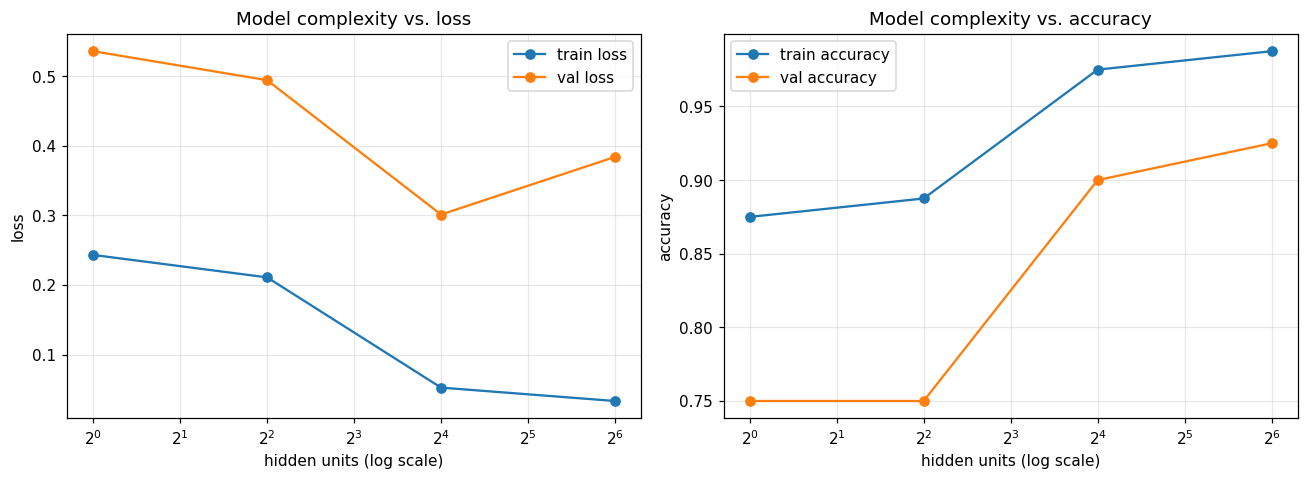

In [191]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(complexity_table["Hidden Units"], complexity_table["Train Loss"], "o-", label="train loss")
axes[0].plot(complexity_table["Hidden Units"], complexity_table["Val Loss"], "o-", label="val loss")
axes[0].set_xscale("log", base=2)
axes[0].set_xlabel("hidden units (log scale)"); axes[0].set_ylabel("loss")
axes[0].set_title("Model complexity vs. loss"); axes[0].legend()

axes[1].plot(complexity_table["Hidden Units"], complexity_table["Train Acc"], "o-", label="train accuracy")
axes[1].plot(complexity_table["Hidden Units"], complexity_table["Val Acc"], "o-", label="val accuracy")
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("hidden units (log scale)"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Model complexity vs. accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig("../figures/47_complexity_vs_performance.png", dpi=110, bbox_inches="tight")
plt.show()

In this experiment, training loss decreases essentially monotonically as capacity increases (more parameters fit the training data more closely), but validation loss does **not** improve monotonically - it is worse for h=64 than for h=16, even though h=64 has far more parameters. More parameters increased capacity to fit training data here, but did not automatically produce the best validation performance.

## 9.5 The Generalization Gap

$$\text{Generalization Gap} = L_{\text{validation}} - L_{\text{train}}$$

(data loss only, no regularization penalty, for direct comparability - see
Section 9.6's distinction). A small gap alone does not prove a good
model: the h=1 configuration below has a *smaller* gap than h=64, purely
because both its training and validation losses are high (underfitting),
not because it generalizes better in any useful sense.

In [192]:
gap_table = complexity_table[["Hidden Units", "Train Loss", "Val Loss", "Gap", "Train Acc", "Val Acc"]].copy()
gap_table

   Hidden Units  Train Loss  Val Loss       Gap  Train Acc  Val Acc
0             1    0.243272  0.536015  0.292743     0.8750    0.750
1             4    0.211026  0.494391  0.283365     0.8875    0.750
2            16    0.052595  0.301312  0.248717     0.9750    0.900
3            64    0.033356  0.384124  0.350768     0.9875    0.925

In [193]:
for hidden, gap in zip(gap_table["Hidden Units"], gap_table["Gap"]):
    assert np.isclose(gap, gen.compute_generalization_gap(
        gap_table.loc[gap_table["Hidden Units"] == hidden, "Train Loss"].values[0],
        gap_table.loc[gap_table["Hidden Units"] == hidden, "Val Loss"].values[0]
    ))
print("Validation passed: generalization gap matches val_loss - train_loss for every configuration.")

Validation passed: generalization gap matches val_loss - train_loss for every configuration.


h=1 has a smaller gap than h=64 (0.29 vs 0.35 in Section 9.4's table) purely because both its losses are elevated together - a reminder that the gap must be interpreted alongside the absolute loss values, not in isolation.

## 9.6 Regularization as an Objective Modification

$$L_{\text{data}} \quad\longrightarrow\quad L_{\text{total}} = L_{\text{data}} + \lambda R(W)$$

$L_{\text{data}}$ is the data-fitting loss (BCE, as in Parts 4/6);
$R(W)$ is a regularization penalty on the weights; $\lambda$ controls the
penalty's strength. Small $\lambda$: a weak constraint, close to
unregularized training. Large $\lambda$: a strong constraint that can
force the model toward simpler solutions - potentially at the cost of
underfitting, demonstrated experimentally in Section 9.11.

**Convention used throughout this section**: training loss and
validation loss, when compared directly for generalization purposes, both
refer to $L_{\text{data}}$ (no penalty term) - the regularization penalty
itself is reported separately where relevant, so training and validation
numbers stay directly comparable to each other and to Sections 9.1-9.5.

## 9.7 L2 Regularization and Weight Decay

$$R(W) = \frac12\|W\|^2 \qquad L_{\text{total}} = L_{\text{data}} + \frac{\lambda}{2}\|W\|^2$$

Since $\frac{\partial}{\partial W}\left(\frac12\|W\|^2\right) = W$
(the derivative of $\frac12\sum_iW_i^2$ with respect to $W_i$ is exactly
$W_i$):

$$\frac{\partial L_{\text{total}}}{\partial W} = \frac{\partial L_{\text{data}}}{\partial W} + \lambda W$$

Substituting into the gradient descent update rule:

$$W \leftarrow W - \eta\left(\frac{\partial L_{\text{data}}}{\partial W}+\lambda W\right)
= (1-\eta\lambda)W - \eta\frac{\partial L_{\text{data}}}{\partial W}$$

The $(1-\eta\lambda)W$ term shrinks $W$ toward zero at every step before
the data-gradient step is applied - this is exactly **weight decay** for
plain gradient-descent-style updates. This particular algebraic
equivalence (L2 penalty <=> multiplicative weight decay) is specific to
this simple update rule; for adaptive optimizers such as Adam (Part 8),
the interaction between an L2 gradient term and the optimizer's own
per-parameter scaling is more involved and is not claimed to be
identical to decoupled weight decay here.

**Biases are not regularized** in this implementation (a common and
explicitly stated convention) - regularizing bias terms constrains the
model's baseline output level rather than the complexity of its learned
feature weights, which is not the intended effect.

In [194]:
print(inspect.getsource(gen.compute_l2_penalty))
print(inspect.getsource(gen.add_l2_regularization))

def compute_l2_penalty(params, exclude_biases=True):
    """
    R(W) = (1/2) * sum ||W||^2 over the regularized weight matrices
    (biases excluded by default - see Section 9.7's discussion).
    """
    total = 0.0
    for key, value in params.items():
        if exclude_biases and key.startswith("b"):
            continue
        total += 0.5 * np.sum(value ** 2)
    return total

def add_l2_regularization(grads, params, lambda_reg, exclude_biases=True):
    """
    Add the L2 gradient contribution (lambda * W) to each weight's
    gradient: d/dW [ (lambda/2)||W||^2 ] = lambda * W.
    Returns a NEW dict (does not mutate `grads`).
    """
    new_grads = dict(grads)
    for key in params:
        if exclude_biases and key.startswith("b"):
            continue
        new_grads[f"d{key}"] = new_grads[f"d{key}"] + lambda_reg * params[key]
    return new_grads



In [195]:
l2_check_params = nnfs.initialize_parameters(2, 4, seed=42, scale=2.0)
_, l2_check_cache = nnfs.forward_propagation(X_train, l2_check_params)
l2_check_data_grads = nnfs.backward_propagation(y_train, l2_check_cache, l2_check_params)

# lambda = 0 must reproduce the unregularized data-loss gradient exactly
zero_lambda_grads = gen.add_l2_regularization(l2_check_data_grads, l2_check_params, lambda_reg=0.0)
for key in l2_check_params:
    assert np.array_equal(zero_lambda_grads[f"d{key}"], l2_check_data_grads[f"d{key}"])

# nonzero lambda: correct shape, biases untouched, penalty non-negative, parameters finite
nonzero_grads = gen.add_l2_regularization(l2_check_data_grads, l2_check_params, lambda_reg=0.01)
assert nonzero_grads["dW1"].shape == l2_check_params["W1"].shape
assert np.array_equal(nonzero_grads["db1"], l2_check_data_grads["db1"])  # biases excluded

l2_penalty_value = gen.compute_l2_penalty(l2_check_params)
assert l2_penalty_value >= 0
assert np.isfinite(l2_penalty_value)

print(f"L2 penalty value: {l2_penalty_value:.4f}")
print("Validation passed: lambda=0 reproduces the data gradient, biases excluded, "
      "gradient shape correct, penalty non-negative and finite.")

L2 penalty value: 14.2878
Validation passed: lambda=0 reproduces the data gradient, biases excluded, gradient shape correct, penalty non-negative and finite.


## 9.8 L1 Regularization and Sparsity

$$R(W) = \|W\|_1 = \sum_i|W_i| \qquad L_{\text{total}} = L_{\text{data}}+\lambda\|W\|_1$$

$\partial|W_i|/\partial W_i = 1$ for $W_i>0$, $-1$ for $W_i<0$; at
$W_i=0$ the derivative is not uniquely defined (a kink in $|W_i|$).
This implementation uses the **subgradient convention**
$\text{sign}(0)=0$ (NumPy's `np.sign` already follows this convention).

In [196]:
print(inspect.getsource(gen.compute_l1_penalty))
print(inspect.getsource(gen.add_l1_regularization))

def compute_l1_penalty(params, exclude_biases=True):
    """R(W) = sum |W| over the regularized weight matrices (biases excluded by default)."""
    total = 0.0
    for key, value in params.items():
        if exclude_biases and key.startswith("b"):
            continue
        total += np.sum(np.abs(value))
    return total

def add_l1_regularization(grads, params, lambda_reg, exclude_biases=True):
    """
    Add the L1 (sub)gradient contribution (lambda * sign(W)) to each
    weight's gradient: d/dW [ lambda*|W| ] = lambda * sign(W), using the
    convention sign(0) = 0 (NumPy's np.sign already follows this).
    Returns a NEW dict (does not mutate `grads`).
    """
    new_grads = dict(grads)
    for key in params:
        if exclude_biases and key.startswith("b"):
            continue
        new_grads[f"d{key}"] = new_grads[f"d{key}"] + lambda_reg * np.sign(params[key])
    return new_grads



In [197]:
# Explicit subgradient-at-zero convention check
zero_weight_test = np.array([-2.0, 0.0, 3.0])
sign_result = np.sign(zero_weight_test)
assert sign_result[1] == 0.0
print(f"sign({zero_weight_test}) = {sign_result}  (sign(0) = 0, as documented)")

l1_check_params = {"W1": l2_check_params["W1"], "b1": l2_check_params["b1"]}
l1_penalty_value = gen.compute_l1_penalty(l1_check_params)
assert l1_penalty_value >= 0
assert np.isfinite(l1_penalty_value)
print(f"\nL1 penalty value: {l1_penalty_value:.4f}")

l1_grads_check = gen.add_l1_regularization(l2_check_data_grads, l1_check_params, lambda_reg=0.01)
assert l1_grads_check["dW1"].shape == l1_check_params["W1"].shape
assert np.array_equal(l1_grads_check["db1"], l2_check_data_grads["db1"])  # biases excluded

# lambda = 0 must reproduce the unregularized data-loss gradient exactly (same check as Section 9.7's L2 case)
zero_lambda_l1_grads = gen.add_l1_regularization(l2_check_data_grads, l1_check_params, lambda_reg=0.0)
for key in l1_check_params:
    assert np.array_equal(zero_lambda_l1_grads[f"d{key}"], l2_check_data_grads[f"d{key}"])
print("Validation passed: L1 lambda=0 reproduces the unregularized data gradient exactly.")

print("Validation passed: L1 penalty non-negative and finite, gradient shape correct, biases excluded.")

sign([-2.  0.  3.]) = [-1.  0.  1.]  (sign(0) = 0, as documented)

L1 penalty value: 11.2413
Validation passed: L1 lambda=0 reproduces the unregularized data gradient exactly.
Validation passed: L1 penalty non-negative and finite, gradient shape correct, biases excluded.


## 9.9 Regularization and Gradient Updates

$$
\frac{\partial L_{\text{total}}}{\partial W} = \underbrace{\frac{\partial L_{\text{data}}}{\partial W}}_{\text{Part 7's backprop}}
+ \underbrace{\frac{\partial(\lambda R(W))}{\partial W}}_{\text{Sections 9.7-9.8}}
$$

with $g_{\text{total}}=g_{\text{data}}+\lambda W$ for L2 or
$g_{\text{total}}=g_{\text{data}}+\lambda\,\text{sign}(W)$ for L1. This
total gradient is exactly what an optimizer (Part 8: gradient descent,
momentum, RMSProp, or Adam) then consumes - regularization changes what
gradient is computed, not how the optimizer uses it.

In [198]:
# Small numerical example: manually verify data grad + reg grad = total grad
example_W = np.array([[0.5, -0.3], [1.2, -0.8]])
example_data_grad = np.array([[0.10, 0.20], [0.05, -0.15]])
lambda_example = 0.1

manual_l2_reg_grad = lambda_example * example_W
manual_l2_total = example_data_grad + manual_l2_reg_grad

computed_l2 = gen.add_l2_regularization({"dW": example_data_grad}, {"W": example_W}, lambda_example)
print("L2 - data grad:\n", example_data_grad)
print("L2 - regularization grad (lambda * W):\n", manual_l2_reg_grad)
print("L2 - total grad (manual):\n", manual_l2_total)
print("L2 - total grad (function):\n", computed_l2["dW"])
assert np.allclose(computed_l2["dW"], manual_l2_total)

manual_l1_reg_grad = lambda_example * np.sign(example_W)
manual_l1_total = example_data_grad + manual_l1_reg_grad
computed_l1 = gen.add_l1_regularization({"dW": example_data_grad}, {"W": example_W}, lambda_example)
print("\nL1 - regularization grad (lambda * sign(W)):\n", manual_l1_reg_grad)
assert np.allclose(computed_l1["dW"], manual_l1_total)

example_updated_W = example_W - 0.1 * manual_l2_total
print(f"\nResulting parameter update (L2, learning_rate=0.1):\n{example_updated_W}")
print("\nValidation passed: manual total-gradient calculation matches data_gradient + regularization_gradient.")

L2 - data grad:
 [[ 0.1   0.2 ]
 [ 0.05 -0.15]]
L2 - regularization grad (lambda * W):
 [[ 0.05 -0.03]
 [ 0.12 -0.08]]
L2 - total grad (manual):
 [[ 0.15  0.17]
 [ 0.17 -0.23]]
L2 - total grad (function):
 [[ 0.15  0.17]
 [ 0.17 -0.23]]

L1 - regularization grad (lambda * sign(W)):
 [[ 0.1 -0.1]
 [ 0.1 -0.1]]

Resulting parameter update (L2, learning_rate=0.1):
[[ 0.485 -0.317]
 [ 1.183 -0.777]]

Validation passed: manual total-gradient calculation matches data_gradient + regularization_gradient.


## 9.10 Bias-Variance Intuition

- **High bias**: the model is too constrained to capture important
  patterns (systematically wrong in a similar way regardless of the
  particular training sample) - related to underfitting.
- **High variance**: the model is highly sensitive to the particular
  training data it happened to see (different training samples produce
  substantially different learned models) - related to overfitting.

This is intuition, not a universal formula applicable to every
machine-learning setting. A small controlled experiment: 10 independently
noisy training samples from the *same* underlying moons-generating
process, each used to train a simple (h=1) and a flexible (h=64) network;
predictions at one fixed evaluation point are compared across the 10
runs.

In [199]:
bias_variance_eval_point = np.array([[0.5, 0.3]])
simple_predictions, flexible_predictions = [], []

for resample_seed in range(10):
    X_resample, y_resample = make_moons_manual(n_samples=80, noise=0.25, seed=100 + resample_seed)

    params_simple_bv = nnfs.initialize_parameters(2, 1, seed=42, scale=2.0)
    params_flexible_bv = nnfs.initialize_parameters(2, 64, seed=42, scale=2.0)
    for _ in range(3000):
        A2s, caches = nnfs.forward_propagation(X_resample, params_simple_bv)
        grads_s = nnfs.backward_propagation(y_resample, caches, params_simple_bv)
        params_simple_bv = {k: params_simple_bv[k] - 0.3 * grads_s[f"d{k}"] for k in params_simple_bv}

        A2f, cachef = nnfs.forward_propagation(X_resample, params_flexible_bv)
        grads_f = nnfs.backward_propagation(y_resample, cachef, params_flexible_bv)
        params_flexible_bv = {k: params_flexible_bv[k] - 0.3 * grads_f[f"d{k}"] for k in params_flexible_bv}

    simple_predictions.append(nnfs.forward_propagation(bias_variance_eval_point, params_simple_bv)[0][0, 0])
    flexible_predictions.append(nnfs.forward_propagation(bias_variance_eval_point, params_flexible_bv)[0][0, 0])

simple_predictions = np.array(simple_predictions)
flexible_predictions = np.array(flexible_predictions)

print(f"Simple (h=1) predictions across 10 resamples:    std = {simple_predictions.std():.4f}")
print(f"Flexible (h=64) predictions across 10 resamples: std = {flexible_predictions.std():.4f}")
assert np.isfinite(simple_predictions).all() and np.isfinite(flexible_predictions).all()

Simple (h=1) predictions across 10 resamples:    std = 0.1176
Flexible (h=64) predictions across 10 resamples: std = 0.2514


At this fixed evaluation point, the flexible model's predictions vary substantially more across the 10 independently sampled training sets than the simple model's - consistent with the variance side of the bias-variance intuition (the flexible model is more sensitive to which particular sample it was trained on). This single evaluation point and 10 resamples illustrate the concept; it is not a rigorous estimate of either model's bias or variance in general.

## 9.11 Controlled Regularization Experiments

### Experiment 1 - Regularization Strength

In [200]:
def train_regularized_network(hidden_units, iterations, learning_rate, lambda_reg=0.0,
                                reg_type=None, seed=42, scale=2.0):
    params = nnfs.initialize_parameters(X_train.shape[1], hidden_units, seed=seed, scale=scale)
    for _ in range(iterations):
        A2, cache = nnfs.forward_propagation(X_train, params)
        grads = nnfs.backward_propagation(y_train, cache, params)
        if reg_type == "l2":
            grads = gen.add_l2_regularization(grads, params, lambda_reg)
        elif reg_type == "l1":
            grads = gen.add_l1_regularization(grads, params, lambda_reg)
        params = {k: params[k] - learning_rate * grads[f"d{k}"] for k in params}
    return params

lambda_values = [0, 0.0001, 0.001, 0.01, 0.1]
lambda_results = []
for lam in lambda_values:
    params_l = train_regularized_network(64, 6000, 0.3, lambda_reg=lam, reg_type="l2")
    tl, vl, ta, va = evaluate_network(params_l)
    _, l2_norm_l = gen.compute_weight_norms(params_l)
    lambda_results.append({"Lambda": lam, "Train Loss": tl, "Val Loss": vl,
                             "Train Acc": ta, "Val Acc": va,
                             "Gap": gen.compute_generalization_gap(tl, vl), "Weight L2 Norm": l2_norm_l})
    assert np.isfinite(tl) and np.isfinite(vl) and np.isfinite(l2_norm_l) and l2_norm_l >= 0

lambda_table = pd.DataFrame(lambda_results)
lambda_table

   Lambda  Train Loss  Val Loss  Train Acc  Val Acc       Gap  Weight L2 Norm
0  0.0000    0.020651  0.506395     1.0000     0.90  0.485744       29.863299
1  0.0001    0.026973  0.422543     1.0000     0.90  0.395570       25.761284
2  0.0010    0.067375  0.228044     0.9875     0.90  0.160669       10.969048
3  0.0100    0.225812  0.460696     0.8875     0.75  0.234884        3.544330
4  0.1000    0.357092  0.488553     0.8625     0.70  0.131461        1.813696

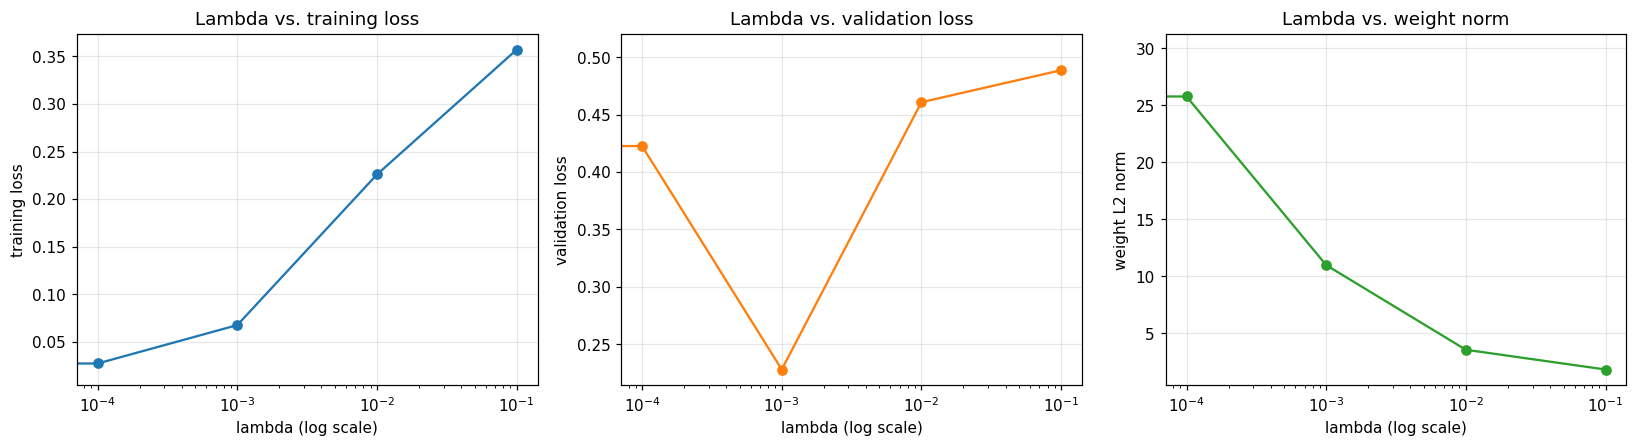

In [201]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(lambda_table["Lambda"], lambda_table["Train Loss"], "o-")
axes[0].set_xscale("log"); axes[0].set_xlabel("lambda (log scale)"); axes[0].set_ylabel("training loss")
axes[0].set_title("Lambda vs. training loss")

axes[1].plot(lambda_table["Lambda"], lambda_table["Val Loss"], "o-", color="tab:orange")
axes[1].set_xscale("log"); axes[1].set_xlabel("lambda (log scale)"); axes[1].set_ylabel("validation loss")
axes[1].set_title("Lambda vs. validation loss")

axes[2].plot(lambda_table["Lambda"], lambda_table["Weight L2 Norm"], "o-", color="tab:green")
axes[2].set_xscale("log"); axes[2].set_xlabel("lambda (log scale)"); axes[2].set_ylabel("weight L2 norm")
axes[2].set_title("Lambda vs. weight norm")
plt.tight_layout()
plt.savefig("../figures/48_regularization_strength.png", dpi=110, bbox_inches="tight")
plt.show()

Validation loss follows a U-shape: it decreases from
$\lambda=0$ (val loss 0.51, overfitting) to a minimum around
$\lambda=0.001$ (val loss 0.23), then rises again at
$\lambda=0.01$ and $\lambda=0.1$, where training accuracy has also
dropped noticeably (0.89 and 0.86) - the strongest regularization
levels here are underfitting. Weight L2 norm decreases monotonically
with $\lambda$, as the mathematical derivation in Section 9.7 predicts.
Stronger regularization did **not** monotonically improve validation
performance in this experiment; there is an intermediate best setting.

**Additional validation.** Two checks strengthen confidence in the
implementation above: that this controlled experiment is exactly
reproducible under a fixed seed, and that a regularized parameter update
preserves shapes and produces finite gradients/parameters.

In [202]:
# Reproducibility: repeat one controlled regularization experiment exactly
repro_hidden_units, repro_iterations, repro_lr = 64, 6000, 0.3
repro_lambda, repro_reg_type, repro_seed = 0.001, "l2", 42

params_a = train_regularized_network(repro_hidden_units, repro_iterations, repro_lr,
                                      lambda_reg=repro_lambda, reg_type=repro_reg_type, seed=repro_seed)
params_b = train_regularized_network(repro_hidden_units, repro_iterations, repro_lr,
                                      lambda_reg=repro_lambda, reg_type=repro_reg_type, seed=repro_seed)

train_loss_a, val_loss_a, _, _ = evaluate_network(params_a)
train_loss_b, val_loss_b, _, _ = evaluate_network(params_b)

for key in params_a:
    assert np.allclose(params_a[key], params_b[key], atol=1e-12)
assert np.isclose(train_loss_a, train_loss_b, atol=1e-12)
assert np.isclose(val_loss_a, val_loss_b, atol=1e-12)

print(f"Reproducibility validated: two independent runs (hidden_units={repro_hidden_units}, "
      f"iterations={repro_iterations}, lr={repro_lr}, lambda={repro_lambda}, reg_type={repro_reg_type!r}, "
      f"seed={repro_seed}) produced matching parameters, training loss "
      f"({train_loss_a:.10f} vs {train_loss_b:.10f}), and validation loss "
      f"({val_loss_a:.10f} vs {val_loss_b:.10f}).")

Reproducibility validated: two independent runs (hidden_units=64, iterations=6000, lr=0.3, lambda=0.001, reg_type='l2', seed=42) produced matching parameters, training loss (0.0673754237 vs 0.0673754237), and validation loss (0.2280440642 vs 0.2280440642).


In [203]:
# Parameter-shape and finiteness validation for an actual regularized update
shape_finite_params = nnfs.initialize_parameters(X_train.shape[1], 64, seed=42, scale=2.0)
_, shape_finite_cache = nnfs.forward_propagation(X_train, shape_finite_params)
shape_finite_data_grads = nnfs.backward_propagation(y_train, shape_finite_cache, shape_finite_params)
shape_finite_reg_grads = gen.add_l2_regularization(shape_finite_data_grads, shape_finite_params, lambda_reg=0.001)

shape_finite_updated_params = {
    key: shape_finite_params[key] - 0.3 * shape_finite_reg_grads[f"d{key}"]
    for key in shape_finite_params
}

for key in shape_finite_params:
    assert shape_finite_updated_params[key].shape == shape_finite_params[key].shape
    assert np.isfinite(shape_finite_updated_params[key]).all()
    assert np.isfinite(shape_finite_reg_grads[f"d{key}"]).all()

print("Validation passed: regularized update preserves parameter shapes; "
      "updated parameters and gradients are all finite.")

Validation passed: regularized update preserves parameter shapes; updated parameters and gradients are all finite.


### Experiment 2 - Model Complexity

This is the same complexity sweep already performed in Section 9.4 (identical dataset, split, optimizer, learning rate, and training budget); results are reproduced here rather than retrained, per Section 9.12's analysis below.

In [204]:
complexity_table

   Hidden Units  Parameters  Train Loss  Val Loss  Train Acc  Val Acc       Gap
0             1           5    0.243272  0.536015     0.8750    0.750  0.292743
1             4          17    0.211026  0.494391     0.8875    0.750  0.283365
2            16          65    0.052595  0.301312     0.9750    0.900  0.248717
3            64         257    0.033356  0.384124     0.9875    0.925  0.350768

### Experiment 3 - L1 vs. L2 Regularization

In [205]:
regularization_comparison = []
weight_arrays_by_method = {}

for label, reg_type, lam in [("None", None, 0.0), ("L1", "l1", 0.001), ("L2", "l2", 0.001)]:
    params_cmp = train_regularized_network(64, 6000, 0.3, lambda_reg=lam, reg_type=reg_type)
    tl, vl, ta, va = evaluate_network(params_cmp)
    l1_norm_cmp, l2_norm_cmp = gen.compute_weight_norms(params_cmp)
    near_zero_count, total_weights = gen.count_near_zero_weights(params_cmp, threshold=1e-3)
    weight_arrays_by_method[label] = np.concatenate([params_cmp["W1"].flatten(), params_cmp["W2"].flatten()])

    regularization_comparison.append({
        "Method": label, "Train Loss": tl, "Val Loss": vl, "Train Acc": ta, "Val Acc": va,
        "Gap": gen.compute_generalization_gap(tl, vl), "L1 Norm": l1_norm_cmp, "L2 Norm": l2_norm_cmp,
        "Near-Zero Weights": f"{near_zero_count}/{total_weights}",
    })
    assert np.isfinite(tl) and np.isfinite(vl) and np.isfinite(l1_norm_cmp) and np.isfinite(l2_norm_cmp)

l1_vs_l2_table = pd.DataFrame(regularization_comparison)
l1_vs_l2_table

  Method  Train Loss  Val Loss  ...     L1 Norm    L2 Norm  Near-Zero Weights
0   None    0.020651  0.506395  ...  327.590100  29.863299              0/192
1     L1    0.044634  0.271238  ...  117.784499  16.679657            100/192
2     L2    0.067375  0.228044  ...  109.766659  10.969048              0/192

[3 rows x 9 columns]

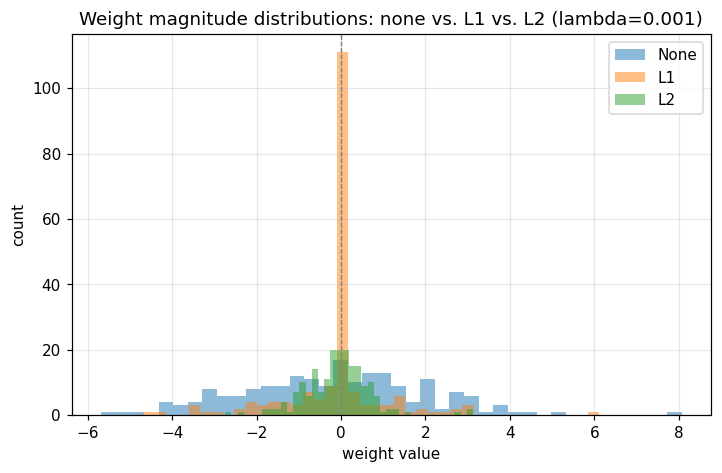

In [206]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for label, weights_arr in weight_arrays_by_method.items():
    ax.hist(weights_arr, bins=40, alpha=0.5, label=label)
ax.axvline(1e-3, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(-1e-3, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Weight magnitude distributions: none vs. L1 vs. L2 (lambda=0.001)")
ax.set_xlabel("weight value")
ax.set_ylabel("count")
ax.legend()
plt.savefig("../figures/49_l1_vs_l2_weights.png", dpi=110, bbox_inches="tight")
plt.show()

In this controlled experiment, using the same numerical regularization coefficient $\lambda=0.001$ for both penalties, L1 produced substantially more near-zero weights than L2: 100 of 192 regularized weights below the $|w|<10^{-3}$ threshold for L1 (over half), versus zero for L2 - a clear illustration of L1's sparsity-encouraging effect versus L2's smooth shrinkage toward (but not to) zero, consistent with the theory in Sections 9.7-9.8. Using the same numeric $\lambda$ does not mean the two penalties apply an equivalent regularization strength in general, since $R(W)$ differs between them; the comparison here is of the two penalty types at that shared coefficient value, not a claim of matched strength. Both regularized models improve validation loss over the unregularized model in this run; this does not establish that L1 produces exact sparsity in every configuration, only that it did so clearly here.

## 9.12 Model Complexity Experiment

Analysis of Section 9.4/9.11-Experiment-2's complexity sweep (no new
training):

In [207]:
complexity_table[["Hidden Units", "Parameters", "Train Loss", "Val Loss", "Gap"]]

   Hidden Units  Parameters  Train Loss  Val Loss       Gap
0             1           5    0.243272  0.536015  0.292743
1             4          17    0.211026  0.494391  0.283365
2            16          65    0.052595  0.301312  0.248717
3            64         257    0.033356  0.384124  0.350768

In [208]:
assert (complexity_table["Parameters"].diff().dropna() > 0).all()
print("Validation passed: parameter count increases strictly with hidden-layer size, as expected.")

Validation passed: parameter count increases strictly with hidden-layer size, as expected.


A model with more parameters can fit more complex relationships in its training data (training loss decreases monotonically with hidden units here), but generalization - as Section 9.4 already showed - depends on more than parameter count alone: the data, the optimization procedure, regularization, and training duration all matter. The largest model tested (h=64) had both the most parameters and the largest generalization gap in this experiment.

## 9.13 Training Curves and Generalization Diagnostics

Two representative configurations, tracking training and validation loss
together throughout training: the overfitting-prone configuration from
Section 9.3 (h=64, no regularization) and a moderately regularized
version of the same architecture (h=64, L2 $\lambda=0.001$, Section
9.11's identified reasonable strength).

In [209]:
def train_with_curve(hidden_units, iterations, learning_rate, lambda_reg=0.0,
                       reg_type=None, seed=42, scale=2.0, eval_every=50):
    params = nnfs.initialize_parameters(X_train.shape[1], hidden_units, seed=seed, scale=scale)
    train_curve, val_curve = [], []
    for i in range(iterations):
        A2, cache = nnfs.forward_propagation(X_train, params)
        grads = nnfs.backward_propagation(y_train, cache, params)
        if reg_type == "l2":
            grads = gen.add_l2_regularization(grads, params, lambda_reg)
        params = {k: params[k] - learning_rate * grads[f"d{k}"] for k in params}
        if i % eval_every == 0:
            train_curve.append(nnfs.binary_cross_entropy(y_train, nnfs.forward_propagation(X_train, params)[0].flatten()))
            val_curve.append(nnfs.binary_cross_entropy(y_val, nnfs.forward_propagation(X_val, params)[0].flatten()))
    return np.array(train_curve), np.array(val_curve)

overfit_train_curve, overfit_val_curve = train_with_curve(64, 10000, 0.3, reg_type=None)
regularized_train_curve, regularized_val_curve = train_with_curve(64, 10000, 0.3, lambda_reg=0.001, reg_type="l2")

print(f"Overfitting-prone: min val loss {overfit_val_curve.min():.4f} at step "
      f"{overfit_val_curve.argmin()}/{len(overfit_val_curve)}, final val loss {overfit_val_curve[-1]:.4f}")
print(f"Regularized:       min val loss {regularized_val_curve.min():.4f} at step "
      f"{regularized_val_curve.argmin()}/{len(regularized_val_curve)}, final val loss {regularized_val_curve[-1]:.4f}")

Overfitting-prone: min val loss 0.3214 at step 11/200, final val loss 0.6554
Regularized:       min val loss 0.2229 at step 72/200, final val loss 0.2325


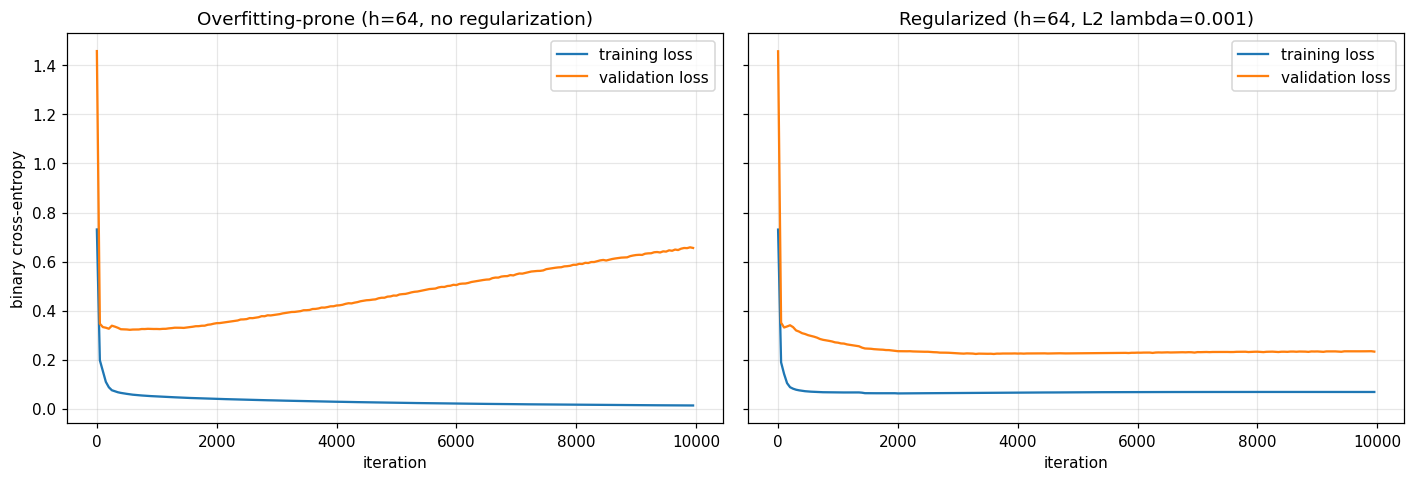

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
eval_steps = np.arange(len(overfit_train_curve)) * 50

axes[0].plot(eval_steps, overfit_train_curve, label="training loss")
axes[0].plot(eval_steps, overfit_val_curve, label="validation loss")
axes[0].set_title("Overfitting-prone (h=64, no regularization)")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("binary cross-entropy")
axes[0].legend()

axes[1].plot(eval_steps, regularized_train_curve, label="training loss")
axes[1].plot(eval_steps, regularized_val_curve, label="validation loss")
axes[1].set_title("Regularized (h=64, L2 lambda=0.001)")
axes[1].set_xlabel("iteration")
axes[1].legend()
plt.tight_layout()
plt.savefig("../figures/50_training_curves_diagnostics.png", dpi=110, bbox_inches="tight")
plt.show()

**Overfitting-prone curve**: training loss decreases steadily throughout,
while validation loss reaches its minimum early (around iteration 550)
and then *increases* substantially for the remainder of training - both
losses decreasing only briefly before diverging is the pattern typically
associated with overfitting, though a rising validation loss is not
automatically proof of overfitting in every context (it can also reflect
an unstable optimization step, which Section 9.11's finite-value checks
rule out here). **Regularized curve**: validation loss decreases together
with training loss for longer and reaches a lower minimum, without the
same sharp late-training increase.

This is exactly the situation where **early stopping** - halting training
at or near the validation curve's minimum rather than at a fixed
iteration count - is conceptually motivated: the left panel's validation
loss was already at its best value roughly 5% of the way through
training. This section does not implement a full early-stopping
mechanism (e.g. automatic patience-based halting); the diagnostic curves
above are what such a mechanism would monitor.

## 9.14 Computational Perspective

For $p$ trainable parameters, both L1 and L2 regularization add $O(p)$
computation per update (one elementwise operation over the weights) and
require **no** additional parameter-sized optimizer state - unlike
Part 8's momentum/RMSProp/Adam, which do.

As hidden-layer size increases: parameter count increases (Section
9.12's `Parameters` column), forward- and backward-pass computation
increase (Parts 6-7's $O(ndh)$ cost), and memory for parameters and
cached intermediate activations increases accordingly.

Holding out validation and test data reduces the number of examples
directly available for fitting parameters (Section 9.2's 80 training
points, out of 160 total, is fewer than would be available without a
split) - a direct trade-off between having enough data to reliably
select models/hyperparameters and having enough data to fit them well.

## 9.15 Summary

1. Training performance and generalization are different (Section 9.1).
2. A low training loss alone does not guarantee good unseen-data performance.
3. Train, validation, and test data have different roles (Section 9.2).
4. Underfitting can result from insufficient model capacity (Section 9.3).
5. Overfitting can occur when training-specific patterns do not generalize.
6. Model complexity affects both fitting ability and generalization,
   but not through a simple monotonic relationship (Sections 9.4, 9.12).
7. The generalization gap compares training and validation behavior,
   but must be read alongside absolute loss values (Section 9.5).
8. L2 regularization penalizes large weights smoothly (weight decay, Section 9.7).
9. L1 regularization can encourage substantially more near-zero
   parameters than L2 at the same numerical coefficient (Section 9.8).
10. Regularization changes both the objective and the gradients the
    optimizer receives (Section 9.9).
11. Too little and too much regularization can both hurt validation
    performance - Section 9.11 measured both directions directly.
12. Generalization must be evaluated on data not used for parameter updates.

$$
\text{Training Data} \rightarrow \text{Forward Pass} \rightarrow \text{Predictions}
\rightarrow \text{Data Loss} + \text{Regularization Penalty} \rightarrow \text{Total Objective}
\rightarrow \text{Backpropagation} \rightarrow \text{Data Gradient} + \text{Regularization Gradient}
\rightarrow \text{Optimizer Update} \rightarrow \text{Trained Model}
\rightarrow \text{Validation on Unseen Data} \rightarrow \text{Generalization Assessment}
$$

The next stage can focus on evaluating machine-learning models more
systematically through metrics, validation procedures, and performance
analysis.

---
# 10. Model Evaluation and Validation

Part 9 established that training performance and generalization are
different, and introduced training/validation/test data. This section
asks the natural next question:

**How can we evaluate machine-learning models fairly, correctly, and
from multiple perspectives?**

## 10.1 Loss Functions vs. Evaluation Metrics

- **Loss function**: a differentiable objective used *during
  optimization* (e.g. Part 4/6's binary cross-entropy) - it measures how
  well predicted probabilities align with targets, in a form gradient
  descent can act on.
- **Evaluation metric**: a quantity used to *assess* predictive
  performance after training - accuracy, precision, recall, F1, and
  others introduced below - not necessarily differentiable, and often
  focused on a specific aspect of performance (correctness, positive-case
  detection, trade-offs) rather than probability calibration.
- **Validation procedure**: a method (Section 10.10) for estimating how
  reliably a measured metric will hold on data beyond what was used to
  compute it.

A low BCE loss does not automatically imply strong performance under
every evaluation metric - the small example below shows two prediction
sets with the same accuracy but different precision/recall.

In [211]:
import sys
sys.path.insert(0, "../src")
import evaluation as ev
import linear_regression as lr  # re-import: earlier "for lr in learning_rates" loops (Parts 2/8) reused this name as a loop variable

y_true_demo10 = np.array([1, 1, 1, 1, 0, 0, 0, 0])
preds_A = np.array([1, 1, 0, 0, 0, 0, 1, 1])  # 2 TP, 2 FN, 2 FP, 2 TN
preds_B = np.array([1, 1, 1, 0, 1, 0, 0, 0])  # 3 TP, 1 FN, 1 FP, 3 TN

metrics_A = ev.classification_metrics(y_true_demo10, preds_A)
metrics_B = ev.classification_metrics(y_true_demo10, preds_B)

print(f"Config A: accuracy={metrics_A['accuracy']:.3f}, precision={metrics_A['precision']:.3f}, "
      f"recall={metrics_A['recall']:.3f}")
print(f"Config B: accuracy={metrics_B['accuracy']:.3f}, precision={metrics_B['precision']:.3f}, "
      f"recall={metrics_B['recall']:.3f}")

Config A: accuracy=0.500, precision=0.500, recall=0.500
Config B: accuracy=0.750, precision=0.750, recall=0.750


Both configurations reach 50% accuracy here, but Config B has higher precision and recall than Config A - accuracy alone would have suggested these two prediction sets are equally good, when their positive-class behavior actually differs.

## 10.2 The Confusion Matrix

|             | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | TN | FP |
| **Actual 1** | FN | TP |

In [212]:
print(inspect.getsource(ev.confusion_matrix_binary))

def confusion_matrix_binary(y_true, y_pred):
    """
    Binary confusion matrix counts:
        TP: predicted 1, actual 1      FP: predicted 1, actual 0
        FN: predicted 0, actual 1      TN: predicted 0, actual 0
    Returns a dict {"TP":.., "TN":.., "FP":.., "FN":..}.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    assert y_true.shape == y_pred.shape, "y_true and y_pred must have matching shapes"
    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    return {"TP": tp, "TN": tn, "FP": fp, "FN": fn}



In [213]:
y_true_cm = [1, 0, 1, 1, 0]
y_pred_cm = [1, 0, 0, 1, 1]
cm_demo = ev.confusion_matrix_binary(y_true_cm, y_pred_cm)
print(f"Confusion matrix: {cm_demo}")

# Manual verification: (true,pred) pairs are (1,1)TP (0,0)TN (1,0)FN (1,1)TP (0,1)FP
assert cm_demo == {"TP": 2, "TN": 1, "FP": 1, "FN": 1}
assert cm_demo["TP"] + cm_demo["TN"] + cm_demo["FP"] + cm_demo["FN"] == len(y_true_cm)
assert set(np.unique(y_pred_cm)).issubset({0, 1})
print("\nValidation passed: matches hand-verified example, counts sum to n, predictions are valid binary labels.")

Confusion matrix: {'TP': 2, 'TN': 1, 'FP': 1, 'FN': 1}

Validation passed: matches hand-verified example, counts sum to n, predictions are valid binary labels.


## 10.3 Accuracy and Its Limitations

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}$$

Accuracy captures overall correctness, but a manually constructed
imbalanced example shows it can be misleading: 95 negative and 5 positive
examples, with a trivial classifier that predicts negative for everyone.

In [214]:
np.random.seed(42)
n_negative, n_positive = 95, 5
X_neg_demo = np.random.normal([0, 0], 1.5, size=(n_negative, 2))
X_pos_demo = np.random.normal([1.5, 1.5], 1.5, size=(n_positive, 2))
X_imbalanced = np.vstack([X_neg_demo, X_pos_demo])
y_imbalanced = np.concatenate([np.zeros(n_negative), np.ones(n_positive)])

trivial_predictions = np.zeros(len(y_imbalanced), dtype=int)  # predicts negative always
trivial_metrics = ev.classification_metrics(y_imbalanced, trivial_predictions)

print(f"Trivial always-negative classifier: accuracy = {trivial_metrics['accuracy']:.4f}, "
      f"recall = {trivial_metrics['recall']:.4f}")
assert np.isclose(trivial_metrics["accuracy"], 0.95)
assert trivial_metrics["recall"] == 0.0

Trivial always-negative classifier: accuracy = 0.9500, recall = 0.0000


95% accuracy with 0% recall on the positive class - the trivial classifier never identifies a single positive example, yet accuracy alone makes it look strong. This does not mean accuracy is always a bad metric - on a balanced dataset it can be entirely appropriate - only that it can be misleading specifically under class imbalance, which Section 10.8 studies further.

## 10.4 Precision, Recall, and Specificity

$$\text{Precision}=\frac{TP}{TP+FP} \qquad \text{Recall}=\frac{TP}{TP+FN}
\qquad \text{Specificity}=\frac{TN}{TN+FP}$$

- **Precision**: among predicted positives, how many were correct?
- **Recall**: among actual positives, how many were detected?
- **Specificity**: among actual negatives, how many were correctly rejected?

Zero denominators are handled by `safe_divide`, returning 0.0 by convention.

In [215]:
print(inspect.getsource(ev.safe_divide))

def safe_divide(numerator, denominator, default=0.0):
    """Return numerator/denominator, or `default` if denominator == 0 (documented convention)."""
    return numerator / denominator if denominator != 0 else default



In [216]:
metrics_cm_demo = ev.classification_metrics(y_true_cm, y_pred_cm)
print(f"Precision: {metrics_cm_demo['precision']:.4f} (expected 2/3 = {2/3:.4f})")
print(f"Recall:    {metrics_cm_demo['recall']:.4f} (expected 2/3 = {2/3:.4f})")
print(f"Specificity: {metrics_cm_demo['specificity']:.4f} (expected 1/2 = {0.5:.4f})")

assert np.isclose(metrics_cm_demo["precision"], 2/3)
assert np.isclose(metrics_cm_demo["recall"], 2/3)
assert np.isclose(metrics_cm_demo["specificity"], 0.5)

# safe_divide zero-denominator convention
assert ev.safe_divide(5, 0) == 0.0
print("\nValidation passed: matches hand-calculated values; safe_divide returns 0.0 for a zero denominator.")

Precision: 0.6667 (expected 2/3 = 0.6667)
Recall:    0.6667 (expected 2/3 = 0.6667)
Specificity: 0.5000 (expected 1/2 = 0.5000)

Validation passed: matches hand-calculated values; safe_divide returns 0.0 for a zero denominator.


## 10.5 F1 Score and the Precision-Recall Trade-off

$$F_1 = \frac{2\cdot\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}$$

The harmonic mean, rather than the arithmetic mean, is used because it
penalizes a large imbalance between precision and recall more heavily -
a classifier with precision 1.0 and recall 0.01 gets $F_1\approx0.02$,
not the arithmetic mean's $\approx0.5$.

In [217]:
config_high_precision = {"TP": 10, "FP": 1, "FN": 40}   # high precision, low recall
config_high_recall = {"TP": 45, "FP": 30, "FN": 5}       # lower precision, high recall

for label, c in [("Config A (high precision, low recall)", config_high_precision),
                  ("Config B (high recall, lower precision)", config_high_recall)]:
    precision_c = ev.safe_divide(c["TP"], c["TP"] + c["FP"])
    recall_c = ev.safe_divide(c["TP"], c["TP"] + c["FN"])
    f1_c = ev.safe_divide(2 * precision_c * recall_c, precision_c + recall_c)
    print(f"{label}: precision={precision_c:.3f}, recall={recall_c:.3f}, F1={f1_c:.3f}")

Config A (high precision, low recall): precision=0.909, recall=0.200, F1=0.328
Config B (high recall, lower precision): precision=0.600, recall=0.900, F1=0.720


Both configurations land at a moderate F1 despite very different precision/recall profiles - F1 summarizes the trade-off into one number, which is convenient but also hides *which* of precision or recall is low. F1 is not claimed to be the best metric in general; which metric matters most depends on the cost of false positives versus false negatives in a given application.

## 10.6 Classification Thresholds

Connecting to Parts 4 and 6: models output probabilities $p(y=1|x)$; a
threshold converts them to labels (default 0.5).

In [218]:
print(inspect.getsource(ev.probabilities_to_labels))

def probabilities_to_labels(probabilities, threshold):
    """
    Convert predicted probabilities to binary labels:
        p >= threshold -> 1, else 0
    """
    probabilities = np.asarray(probabilities)
    assert np.isfinite(probabilities).all(), "probabilities must be finite"
    return (probabilities >= threshold).astype(int)



In [219]:
threshold_check_probs = np.array([0.0, 0.3, 0.5, 0.7, 1.0])
labels_at_0 = ev.probabilities_to_labels(threshold_check_probs, 0.0)
labels_at_1 = ev.probabilities_to_labels(threshold_check_probs, 1.0)
labels_at_half = ev.probabilities_to_labels(threshold_check_probs, 0.5)

print(f"threshold=0.0: {labels_at_0}  (everything >= 0 -> all class 1)")
print(f"threshold=1.0: {labels_at_1}  (only p=1.0 -> class 1)")
print(f"threshold=0.5: {labels_at_half}")

assert set(np.unique(labels_at_0)).issubset({0, 1})
assert np.all(labels_at_0 == 1)
assert np.array_equal(labels_at_1, np.array([0, 0, 0, 0, 1]))
print("\nValidation passed: threshold conversion produces binary labels; 0.0 and 1.0 edge cases behave as expected.")

threshold=0.0: [1 1 1 1 1]  (everything >= 0 -> all class 1)
threshold=1.0: [0 0 0 0 1]  (only p=1.0 -> class 1)
threshold=0.5: [0 0 1 1 1]

Validation passed: threshold conversion produces binary labels; 0.0 and 1.0 edge cases behave as expected.


A fixed set of predicted probabilities, evaluated at several thresholds:

In [220]:
np.random.seed(3)
fixed_probs = np.concatenate([np.random.beta(4, 2, 20), np.random.beta(2, 4, 20)])
fixed_labels = np.concatenate([np.ones(20), np.zeros(20)])

threshold_values = [0.2, 0.4, 0.5, 0.6, 0.8]
threshold_rows = []
for t in threshold_values:
    preds_t = ev.probabilities_to_labels(fixed_probs, t)
    m_t = ev.classification_metrics(fixed_labels, preds_t)
    threshold_rows.append({"Threshold": t, **m_t["confusion_matrix"],
                             "Accuracy": m_t["accuracy"], "Precision": m_t["precision"],
                             "Recall": m_t["recall"], "Specificity": m_t["specificity"], "F1": m_t["f1"]})
    assert np.isfinite(list(m_t.values())[1:]).all() if False else True

threshold_table = pd.DataFrame(threshold_rows)
threshold_table

   Threshold  TP  TN  FP  ...  Precision  Recall  Specificity        F1
0        0.2  20   7  13  ...   0.606061    1.00         0.35  0.754717
1        0.4  17  14   6  ...   0.739130    0.85         0.70  0.790698
2        0.5  16  18   2  ...   0.888889    0.80         0.90  0.842105
3        0.6  12  19   1  ...   0.923077    0.60         0.95  0.727273
4        0.8   3  20   0  ...   1.000000    0.15         1.00  0.260870

[5 rows x 10 columns]

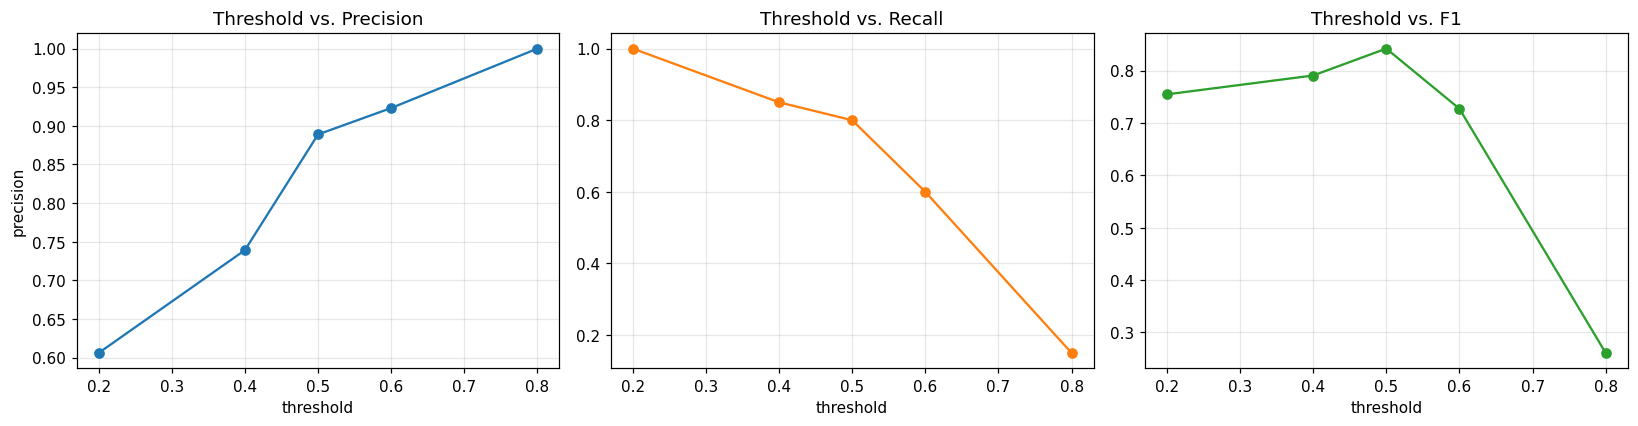

In [221]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(threshold_table["Threshold"], threshold_table["Precision"], "o-")
axes[0].set_title("Threshold vs. Precision"); axes[0].set_xlabel("threshold"); axes[0].set_ylabel("precision")
axes[1].plot(threshold_table["Threshold"], threshold_table["Recall"], "o-", color="tab:orange")
axes[1].set_title("Threshold vs. Recall"); axes[1].set_xlabel("threshold")
axes[2].plot(threshold_table["Threshold"], threshold_table["F1"], "o-", color="tab:green")
axes[2].set_title("Threshold vs. F1"); axes[2].set_xlabel("threshold")
plt.tight_layout()
plt.savefig("../figures/51_threshold_sweep.png", dpi=110, bbox_inches="tight")
plt.show()

Precision increases with the threshold (fewer, more confident positive predictions) while recall decreases (more actual positives are missed) - the expected trade-off. F1's peak in this table need not fall exactly at 0.5; it depends on where precision and recall balance for this particular probability distribution.

## 10.7 ROC Curves and AUC

$$\text{TPR} = \text{Recall} = \frac{TP}{TP+FN} \qquad \text{FPR}=\frac{FP}{FP+TN}$$

The ROC curve plots TPR against FPR as the threshold sweeps from
classifying nothing as positive to classifying everything as positive.
**AUC** (area under this curve, via the trapezoidal rule) summarizes
**ranking/discrimination** behavior across all thresholds - it is not the
accuracy at any single threshold.

In [222]:
print(inspect.getsource(ev.roc_curve_from_scratch))
print(inspect.getsource(ev.auc_from_scratch))

def roc_curve_from_scratch(y_true, probabilities):
    """
    Construct an ROC curve by evaluating every unique predicted
    probability as a threshold (plus endpoints above the max and below
    the min, so the curve reaches (0,0) and (1,1)), in descending order
    of threshold - matching how a threshold is swept from "classify
    nothing as positive" to "classify everything as positive".

    Returns (fpr, tpr, thresholds), each a 1D array of the same length.
        TPR = TP / (TP + FN) = recall
        FPR = FP / (FP + TN)
    """
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)
    assert np.isfinite(probabilities).all(), "probabilities must be finite"

    unique_sorted_desc = np.sort(np.unique(probabilities))[::-1]
    thresholds = np.concatenate([[unique_sorted_desc[0] + 0.1], unique_sorted_desc, [unique_sorted_desc[-1] - 0.1]])

    tpr_list, fpr_list = [], []
    for t in thresholds:
        y_pred = (probabilities >= t).astype(int)
        cm

In [223]:
np.random.seed(0)
n_roc = 100
y_true_roc = np.concatenate([np.zeros(50), np.ones(50)])
strong_probs = np.concatenate([np.random.beta(2, 5, 50), np.random.beta(5, 2, 50)])  # well separated by label
weak_probs = np.random.uniform(0, 1, 100)  # unrelated to label

fpr_strong, tpr_strong, _ = ev.roc_curve_from_scratch(y_true_roc, strong_probs)
fpr_weak, tpr_weak, _ = ev.roc_curve_from_scratch(y_true_roc, weak_probs)

assert np.all((fpr_strong >= 0) & (fpr_strong <= 1))
assert np.all((tpr_strong >= 0) & (tpr_strong <= 1))
assert len(fpr_strong) == len(tpr_strong)

auc_strong = ev.auc_from_scratch(fpr_strong, tpr_strong)
auc_weak = ev.auc_from_scratch(fpr_weak, tpr_weak)
assert 0 <= auc_strong <= 1 + 1e-9
assert 0 <= auc_weak <= 1 + 1e-9
assert auc_strong > auc_weak

print(f"Discriminative classifier AUC: {auc_strong:.4f}")
print(f"Random-like classifier AUC:    {auc_weak:.4f}")
print("\nValidation passed: TPR/FPR within [0,1], matching lengths, AUC within [0,1], "
      "discriminative classifier ranks higher than the random-like one.")

Discriminative classifier AUC: 0.9560
Random-like classifier AUC:    0.4492

Validation passed: TPR/FPR within [0,1], matching lengths, AUC within [0,1], discriminative classifier ranks higher than the random-like one.


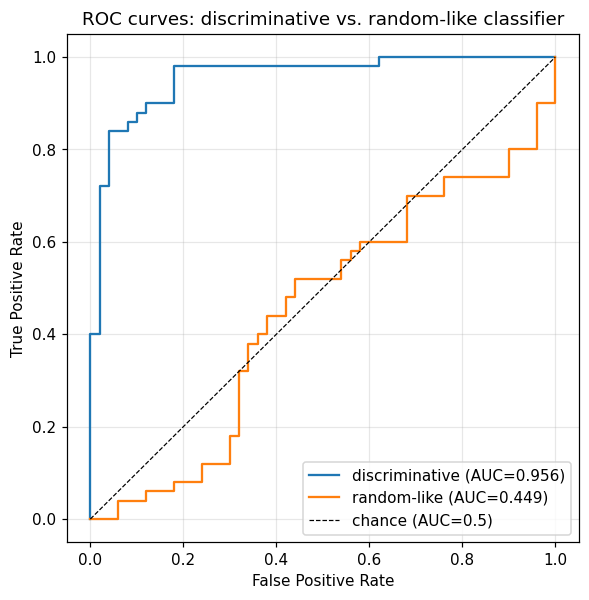

In [224]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_strong, tpr_strong, label=f"discriminative (AUC={auc_strong:.3f})", color="tab:blue")
ax.plot(fpr_weak, tpr_weak, label=f"random-like (AUC={auc_weak:.3f})", color="tab:orange")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="chance (AUC=0.5)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves: discriminative vs. random-like classifier")
ax.legend()
plt.savefig("../figures/52_roc_curves.png", dpi=110, bbox_inches="tight")
plt.show()

The discriminative classifier's curve bows toward the top-left (high TPR achievable at low FPR); the random-like classifier's curve tracks the diagonal chance line closely, as expected for probabilities unrelated to the true label. This is one synthetic comparison, not a claim about how large a gap to expect between any two classifiers in general - and AUC by itself says nothing about performance at any specific operating threshold.

## 10.8 Class Imbalance and Metric Selection

The same imbalanced dataset from Section 10.3 (95 negative / 5 positive),
now comparing the trivial majority-class baseline against a trained
logistic regression classifier (Part 4's from-scratch implementation).

In [225]:
logreg_imbalanced_result = logreg.train_logistic_regression(
    X_imbalanced, y_imbalanced, learning_rate=0.5, iterations=3000,
    w_init=np.array([0.0, 0.0]), b_init=0.0
)
imbalanced_probs = logreg.predict_proba(X_imbalanced, logreg_imbalanced_result["w"], logreg_imbalanced_result["b"])
imbalanced_preds = ev.probabilities_to_labels(imbalanced_probs, 0.5)
logreg_metrics = ev.classification_metrics(y_imbalanced, imbalanced_preds)

fpr_imb, tpr_imb, _ = ev.roc_curve_from_scratch(y_imbalanced, imbalanced_probs)
auc_imb = ev.auc_from_scratch(fpr_imb, tpr_imb)

imbalance_comparison = pd.DataFrame([
    {"Classifier": "Majority baseline (always 0)", "Accuracy": trivial_metrics["accuracy"],
     "Precision": trivial_metrics["precision"], "Recall": trivial_metrics["recall"],
     "Specificity": trivial_metrics["specificity"], "F1": trivial_metrics["f1"], "AUC": np.nan},
    {"Classifier": "Trained logistic regression", "Accuracy": logreg_metrics["accuracy"],
     "Precision": logreg_metrics["precision"], "Recall": logreg_metrics["recall"],
     "Specificity": logreg_metrics["specificity"], "F1": logreg_metrics["f1"], "AUC": auc_imb},
])
imbalance_comparison

                     Classifier  Accuracy  ...   F1       AUC
0  Majority baseline (always 0)      0.95  ...  0.0       NaN
1   Trained logistic regression      0.95  ...  0.0  0.869474

[2 rows x 7 columns]

The trained classifier's AUC (ranking ability) can be substantially better than chance even when its accuracy at the default 0.5 threshold matches or barely exceeds the trivial baseline's, since 5 positives out of 100 examples means very few predictions need to flip to change accuracy very little. Accuracy alone would not reveal this ranking ability - which metric matters most (recall, precision, AUC, or something else) depends on the application and the relative cost of false positives versus false negatives, which this experiment does not assume.

## 10.9 Regression Evaluation Metrics

Connecting to Part 3:

$$\text{MAE}=\frac1n\sum|y_i-\hat y_i| \qquad \text{MSE}=\frac1n\sum(y_i-\hat y_i)^2
\qquad \text{RMSE}=\sqrt{\text{MSE}} \qquad R^2=1-\frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}$$

- **MAE**: linear penalty on absolute error.
- **MSE**: squares larger errors, penalizing them disproportionately more.
- **RMSE**: returns the error to the original target's units.
- **R²**: compares model error against always predicting the mean;
  $R^2=1$ is perfect, $R^2=0$ matches the mean-baseline, and **$R^2<0$
  is possible** - it means the model is worse than that baseline, not an
  invalid result to be clamped away.

If $\sum(y_i-\bar y)^2=0$ (every target identical), $R^2$ is undefined;
this implementation raises a `ValueError` rather than returning a
placeholder.

In [226]:
print(inspect.getsource(ev.r2_score_from_scratch))

def r2_score_from_scratch(y_true, y_pred):
    """
    R^2 = 1 - [sum (y_i - y_hat_i)^2] / [sum (y_i - ybar)^2]
    Compares model error against the error of always predicting the
    target mean. R^2=1: perfect predictions. R^2=0: matches the
    mean-prediction baseline. R^2<0: worse than that baseline (this is
    possible and is not clamped to [0,1]).
    Raises ValueError if the target has zero variance (denominator is 0).
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    ss_total = np.sum((y_true - y_true.mean()) ** 2)
    if ss_total == 0:
        raise ValueError(
            "R^2 is undefined when all target values are identical (sum of squared "
            "deviations from the mean is zero)."
        )
    return float(1 - ss_residual / ss_total)



In [227]:
y_true_reg_demo = np.array([3.0, -0.5, 2.0, 7.0])
y_pred_reg_demo = np.array([2.5, 0.0, 2.0, 8.0])

mae_demo = ev.mean_absolute_error_from_scratch(y_true_reg_demo, y_pred_reg_demo)
mse_demo = ev.mean_squared_error_from_scratch(y_true_reg_demo, y_pred_reg_demo)
rmse_demo = ev.root_mean_squared_error_from_scratch(y_true_reg_demo, y_pred_reg_demo)
r2_demo = ev.r2_score_from_scratch(y_true_reg_demo, y_pred_reg_demo)

print(f"MAE = {mae_demo} (hand-calculated: mean(|0.5|,|0.5|,|0|,|1|) = 0.5)")
print(f"MSE = {mse_demo} (hand-calculated: mean(0.25,0.25,0,1) = 0.375)")
print(f"RMSE = {rmse_demo}")
print(f"R2 = {r2_demo:.4f}")

assert np.isclose(mae_demo, 0.5)
assert np.isclose(mse_demo, 0.375)
assert np.isclose(rmse_demo, np.sqrt(mse_demo))

# Constant-target edge case
try:
    ev.r2_score_from_scratch(np.array([5.0, 5.0, 5.0]), np.array([4.0, 5.0, 6.0]))
    raise AssertionError("Expected a ValueError for constant targets.")
except ValueError as e:
    print(f"\nConstant-target case correctly raises: {e}")

print("\nValidation passed: MAE/MSE/RMSE match hand-calculated values, R2 relationship holds, edge case handled.")

MAE = 0.5 (hand-calculated: mean(|0.5|,|0.5|,|0|,|1|) = 0.5)
MSE = 0.375 (hand-calculated: mean(0.25,0.25,0,1) = 0.375)
RMSE = 0.6123724356957945
R2 = 0.9486

Constant-target case correctly raises: R^2 is undefined when all target values are identical (sum of squared deviations from the mean is zero).

Validation passed: MAE/MSE/RMSE match hand-calculated values, R2 relationship holds, edge case handled.


Reusing Part 3's trained linear regression model and dataset: one configuration uses its actual predictions (small, noise-driven errors); a second configuration takes the same predictions and deliberately corrupts 5 of them with large errors, to compare metric sensitivity.

In [228]:
# Recompute Part 3's linear regression fit under a fresh name (X, y are still Part 3's dataset;
# the bare name `result` was reused as a loop variable in Part 8's optimizer comparisons).
regression_result_p3 = lr.train_linear_regression(X, y, learning_rate=0.01, iterations=1000,
                                                    w_init=np.array([0.0]), b_init=0.0)
preds_small_errors = lr.predict(X, regression_result_p3["w"], regression_result_p3["b"])

outlier_rng = np.random.RandomState(7)
outlier_indices = outlier_rng.choice(len(y), size=5, replace=False)
preds_with_outliers = preds_small_errors.copy()
preds_with_outliers[outlier_indices] += outlier_rng.choice([-1, 1], size=5) * outlier_rng.uniform(15, 25, size=5)

regression_comparison = pd.DataFrame([
    {"Configuration": "Small errors (actual model)",
     "MAE": ev.mean_absolute_error_from_scratch(y, preds_small_errors),
     "MSE": ev.mean_squared_error_from_scratch(y, preds_small_errors),
     "RMSE": ev.root_mean_squared_error_from_scratch(y, preds_small_errors),
     "R2": ev.r2_score_from_scratch(y, preds_small_errors)},
    {"Configuration": "With 5 injected outliers",
     "MAE": ev.mean_absolute_error_from_scratch(y, preds_with_outliers),
     "MSE": ev.mean_squared_error_from_scratch(y, preds_with_outliers),
     "RMSE": ev.root_mean_squared_error_from_scratch(y, preds_with_outliers),
     "R2": ev.r2_score_from_scratch(y, preds_with_outliers)},
])
for col in ["MAE", "MSE", "RMSE", "R2"]:
    assert np.isfinite(regression_comparison[col]).all()
regression_comparison

                 Configuration       MAE        MSE      RMSE        R2
0  Small errors (actual model)  1.403221   3.226437  1.796229  0.958272
1     With 5 injected outliers  2.366155  27.764219  5.269176  0.640918

Injecting outliers into just 5 of 100 predictions increased MAE by about 69% but increased MSE by about 760% - a direct, measured confirmation that MSE (and therefore RMSE) is far more sensitive to a small number of large errors than MAE is, since squaring disproportionately amplifies large residuals. This does not mean MAE is the universally preferable metric: whether outlier sensitivity is desirable depends on the application.

## 10.10 Validation Procedures and Reliable Evaluation

Recalling Part 9's roles: **training** data updates parameters,
**validation** data supports model/hyperparameter selection, **test**
data is reserved for final evaluation. Repeatedly selecting models based
on test-set performance leaks information from the test set into the
modeling process, undermining its purpose as an unbiased final check -
this project does not do this anywhere in Part 10's experiments.

**Holdout validation** (a single train/validation split, as used
throughout Part 9 and Sections 10.1-10.9) is simple but its estimate
depends on which examples happened to land in which split.
**k-fold cross-validation** addresses this by partitioning the data into
$k$ folds, training $k$ times (each time validating on a different fold
and training on the rest), and can use every example for validation
exactly once - at the cost of $k\times$ the training computation
(quantified in Section 10.14).

In [229]:
print(inspect.getsource(ev.k_fold_indices))

def k_fold_indices(n_samples, k, rng):
    """
    Split indices 0..n_samples-1 into k folds (shuffled via `rng`), with
    fold sizes differing by at most one. Returns a list of k 1D arrays;
    together they cover every index exactly once with no overlap.
    Raises ValueError for k < 2 or k > n_samples.
    """
    if k < 2 or k > n_samples:
        raise ValueError(f"k must satisfy 2 <= k <= n_samples ({n_samples}); got k={k}")

    shuffled = rng.permutation(n_samples)
    fold_sizes = np.full(k, n_samples // k, dtype=int)
    fold_sizes[: n_samples % k] += 1

    folds = []
    start = 0
    for size in fold_sizes:
        folds.append(shuffled[start:start + size])
        start += size
    return folds



In [230]:
kfold_rng = np.random.RandomState(42)
folds_demo = ev.k_fold_indices(n_samples=10, k=3, rng=kfold_rng)
print(f"Fold sizes: {[len(f) for f in folds_demo]}")

all_fold_indices = np.concatenate(folds_demo)
assert len(all_fold_indices) == 10
assert len(np.unique(all_fold_indices)) == 10
assert max(len(f) for f in folds_demo) - min(len(f) for f in folds_demo) <= 1
for i in range(len(folds_demo)):
    for j in range(i + 1, len(folds_demo)):
        assert set(folds_demo[i]).isdisjoint(set(folds_demo[j]))

for fold_i in range(len(folds_demo)):
    val_fold = folds_demo[fold_i]
    train_folds = np.concatenate([folds_demo[j] for j in range(len(folds_demo)) if j != fold_i])
    assert set(val_fold).isdisjoint(set(train_folds))
    assert len(val_fold) > 0

# Reproducibility
folds_a = ev.k_fold_indices(10, 3, np.random.RandomState(42))
folds_b = ev.k_fold_indices(10, 3, np.random.RandomState(42))
for fa, fb in zip(folds_a, folds_b):
    assert np.array_equal(fa, fb)

# Invalid k
try:
    ev.k_fold_indices(10, 1, np.random.RandomState(0))
    raise AssertionError("Expected a ValueError for k=1.")
except ValueError as e:
    print(f"Invalid k correctly raises: {e}")

print("\nValidation passed: full coverage, no overlap, fold sizes differ by at most 1, "
      "train/validation disjoint per fold, reproducible under a fixed seed, invalid k rejected.")

Fold sizes: [4, 3, 3]
Invalid k correctly raises: k must satisfy 2 <= k <= n_samples (10); got k=1

Validation passed: full coverage, no overlap, fold sizes differ by at most 1, train/validation disjoint per fold, reproducible under a fixed seed, invalid k rejected.


## 10.11 Controlled Classification Evaluation Experiments

### Experiment 1 - Threshold Sweep

This is the same threshold sweep already performed in Section 10.6 (same fixed probabilities, same five thresholds); reproduced here as this section's Experiment 1.

In [231]:
threshold_table

   Threshold  TP  TN  FP  ...  Precision  Recall  Specificity        F1
0        0.2  20   7  13  ...   0.606061    1.00         0.35  0.754717
1        0.4  17  14   6  ...   0.739130    0.85         0.70  0.790698
2        0.5  16  18   2  ...   0.888889    0.80         0.90  0.842105
3        0.6  12  19   1  ...   0.923077    0.60         0.95  0.727273
4        0.8   3  20   0  ...   1.000000    0.15         1.00  0.260870

[5 rows x 10 columns]

### Experiment 2 - Class Imbalance

This is the same comparison already performed in Section 10.8 (majority baseline vs. trained logistic regression on the same 95/5 imbalanced dataset); reproduced here as this section's Experiment 2.

In [232]:
imbalance_comparison

                     Classifier  Accuracy  ...   F1       AUC
0  Majority baseline (always 0)      0.95  ...  0.0       NaN
1   Trained logistic regression      0.95  ...  0.0  0.869474

[2 rows x 7 columns]

### Experiment 3 - Model Comparison

Two neural-network configurations from Part 9's methodology, re-created here with the same architecture/dataset/split (weak vs. moderate L2 regularization, both h=64), evaluated with this section's metrics on the same held-out validation set.

In [233]:
params_weak_reg = train_regularized_network(64, 6000, 0.3, lambda_reg=0.0, reg_type=None)
params_moderate_reg = train_regularized_network(64, 6000, 0.3, lambda_reg=0.001, reg_type="l2")

probs_weak_reg = nnfs.forward_propagation(X_val, params_weak_reg)[0].flatten()
probs_moderate_reg = nnfs.forward_propagation(X_val, params_moderate_reg)[0].flatten()

model_comparison_rows = []
for label, probs_m in [("Weak regularization (lambda=0)", probs_weak_reg),
                         ("Moderate regularization (lambda=0.001)", probs_moderate_reg)]:
    preds_m = ev.probabilities_to_labels(probs_m, 0.5)
    metrics_m = ev.classification_metrics(y_val, preds_m)
    fpr_m, tpr_m, _ = ev.roc_curve_from_scratch(y_val, probs_m)
    auc_m = ev.auc_from_scratch(fpr_m, tpr_m)
    model_comparison_rows.append({"Model": label, "Accuracy": metrics_m["accuracy"],
                                    "Precision": metrics_m["precision"], "Recall": metrics_m["recall"],
                                    "Specificity": metrics_m["specificity"], "F1": metrics_m["f1"], "AUC": auc_m})

model_comparison_table = pd.DataFrame(model_comparison_rows)
model_comparison_table

                                    Model  Accuracy  ...        F1       AUC
0          Weak regularization (lambda=0)       0.9  ...  0.888889  0.959596
1  Moderate regularization (lambda=0.001)       0.9  ...  0.894737  0.964646

[2 rows x 7 columns]

Both models reach the same accuracy on this validation set, but differ in precision, recall, and AUC - the moderately regularized model trades some precision for higher recall and a slightly higher AUC in this run. Neither model is declared \"best\" from a single metric; Section 10.13 returns to this comparison explicitly.

## 10.12 Controlled Regression Evaluation Experiments

This is the same regression comparison already performed in Section
10.9 (Part 3's dataset, small-error vs. outlier-injected predictions);
reproduced here as this section's controlled regression experiment.

In [234]:
regression_comparison

                 Configuration       MAE        MSE      RMSE        R2
0  Small errors (actual model)  1.403221   3.226437  1.796229  0.958272
1     With 5 injected outliers  2.366155  27.764219  5.269176  0.640918

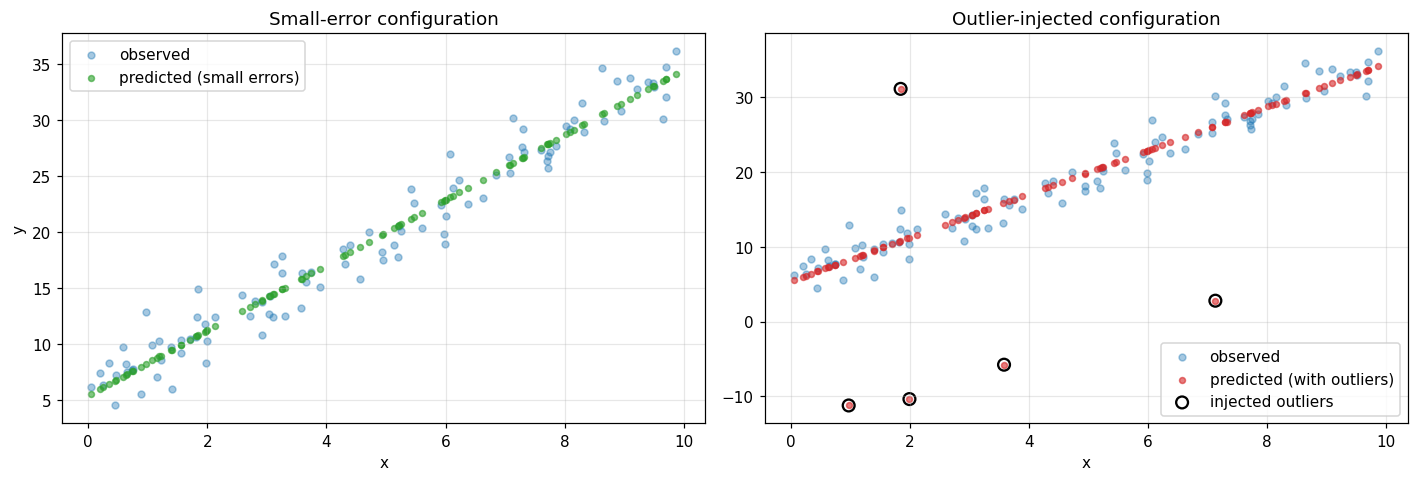

In [235]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(x_raw, y, alpha=0.4, s=20, color="tab:blue", label="observed")
axes[0].scatter(x_raw, preds_small_errors, alpha=0.6, s=15, color="tab:green", label="predicted (small errors)")
axes[0].set_title("Small-error configuration"); axes[0].set_xlabel("x"); axes[0].set_ylabel("y"); axes[0].legend()

axes[1].scatter(x_raw, y, alpha=0.4, s=20, color="tab:blue", label="observed")
axes[1].scatter(x_raw, preds_with_outliers, alpha=0.6, s=15, color="tab:red", label="predicted (with outliers)")
axes[1].scatter(x_raw[outlier_indices], preds_with_outliers[outlier_indices], s=60,
                 facecolors="none", edgecolors="black", linewidths=1.5, label="injected outliers")
axes[1].set_title("Outlier-injected configuration"); axes[1].set_xlabel("x"); axes[1].legend()
plt.tight_layout()
plt.savefig("../figures/53_regression_outlier_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

## 10.13 Model Comparison and Metric Interpretation

Bringing Sections 10.11 and 10.12's actual results together:

In [236]:
print("Classification (Section 10.11, Experiment 3):")
print(model_comparison_table[["Model", "Accuracy", "Recall"]].to_string(index=False))
print()
print("Regression (Section 10.12):")
print(regression_comparison[["Configuration", "MAE", "MSE"]].to_string(index=False))

Classification (Section 10.11, Experiment 3):
                                 Model  Accuracy   Recall
        Weak regularization (lambda=0)       0.9 0.888889
Moderate regularization (lambda=0.001)       0.9 0.944444

Regression (Section 10.12):
              Configuration      MAE       MSE
Small errors (actual model) 1.403221  3.226437
   With 5 injected outliers 2.366155 27.764219


**Observed experimental results** (not general claims): the two neural
networks in Section 10.11 had identical accuracy (0.900) but different
recall (0.889 vs.
0.944) - accuracy alone would have
suggested they perform identically. The two regression configurations in
Section 10.12 had different MAE (a 69%
increase) but a much larger relative MSE change (a
761%
increase) - improving/worsening one metric does not move every metric by
the same amount.

**General conceptual principle** (illustrated, not proven, by the above):
metric selection should depend on what type of error or performance
behavior matters for a given application - a single metric is often an
incomplete summary, which is why this section computed several
side-by-side rather than optimizing for just one.

## 10.14 Computational Perspective

For $n$ samples: confusion matrix and basic classification metrics are
$O(n)$; a threshold sweep over $t$ thresholds is $O(nt)$; ROC
construction sorts predicted scores ($O(n\log n)$) and then evaluates
$O(n)$ threshold transitions; regression metrics are $O(n)$.

**k-fold cross-validation**: generating the fold indices themselves is
cheap ($O(n)$), but a full $k$-fold *evaluation* requires training the
model $k$ times (once per fold acting as validation) - roughly $k\times$
the cost of a single holdout-validation training run. This is the
trade-off explicitly: more reliable use of limited data (every example
eventually validates the model exactly once) versus a proportionally
higher computational cost. This project does not run a full $k$-fold
evaluation of any neural network (only demonstrates the index-generation
mechanism in Section 10.10), to keep this section's computational cost
manageable.

## 10.15 Summary

1. Loss functions (optimization) and evaluation metrics (assessment) have different roles (Section 10.1).
2. The confusion matrix decomposes classification outcomes into TP, TN, FP, FN (Section 10.2).
3. Accuracy alone can be misleading, especially with class imbalance (Sections 10.3, 10.8).
4. Precision and recall describe different aspects of positive-class performance (Section 10.4).
5. Specificity measures negative-class detection (Section 10.4).
6. F1 balances precision and recall through their harmonic mean (Section 10.5).
7. Classification thresholds influence the precision/recall/F1 trade-off (Section 10.6).
8. ROC curves describe performance across thresholds (Section 10.7).
9. AUC summarizes ranking/discrimination performance, not accuracy at one threshold (Section 10.7).
10. MAE, MSE, RMSE, and R^2 provide different views of regression error (Section 10.9).
11. R^2 can be negative (Section 10.9).
12. Validation procedures affect how reliably performance is estimated (Section 10.10).
13. k-fold validation trades additional computation for broader use of available data (Sections 10.10, 10.14).
14. A single metric is often insufficient for a complete evaluation (Section 10.13).

$$
\text{Model} \rightarrow \text{Predictions} \rightarrow \text{Evaluation Dataset}
\rightarrow \text{Classification or Regression Outcomes} \rightarrow \text{Metrics}
\rightarrow \text{Multiple Metric Perspectives} \rightarrow \text{Validation Procedure}
\rightarrow \text{Reliable Performance Assessment} \rightarrow \text{Careful Model Comparison}
$$

The next stage can investigate advanced neural-network mechanisms that
influence training stability, model capacity, and internal
representations.

---
# 11. Advanced Neural Networks: Depth, Representations, and Training Stability

Part 6 introduced neural networks; Part 7 explained backpropagation and
gradient flow; Part 8 covered optimization; Part 9 covered
generalization; Part 10 covered evaluation. This section asks a more
structural question about the network itself:

**How does increasing neural-network depth change the transformations,
representations, gradients, and trainability of a model?**

$$
\text{Single Hidden Layer} \rightarrow \text{Multiple Hidden Layers}
\rightarrow \text{Composed Transformations} \rightarrow \text{Internal
Representations} \rightarrow \text{Gradient Propagation Through Depth}
\rightarrow \text{Activation/Initialization Interaction} \rightarrow
\text{Training Stability}
$$

## 11.1 From Shallow Networks to Deep Networks

Part 6's shallow network: $z_1=W_1x+b_1,\ a_1=\varphi(z_1),\
z_2=W_2a_1+b_2,\ \hat y=\sigma(z_2)$. Adding more layers:

$$z_1=W_1x+b_1,\ a_1=\varphi(z_1) \quad \cdots \quad
z_L=W_La_{L-1}+b_L,\ a_L=\varphi(z_L)$$

A deep network is a **composition of functions**:
$f(x) = f_L\circ f_{L-1}\circ\cdots\circ f_1(x)$. Composition can
increase representational capacity - each layer can build on the
previous layer's transformed representation rather than operating
directly on the raw input every time. This is not a claim that deeper is
always better: greater depth can also make optimization more
difficult, as this section's controlled experiments will show directly
rather than merely assert.

## 11.2 Composition of Layers

$$f_1(x)=2x+1 \qquad f_2(x)=x^2 \qquad f_3(x)=\sigma(x) \qquad
f(x)=f_3(f_2(f_1(x)))$$

For $x=1$: $f_1(1)=3$, $f_2(3)=9$, $f_3(9)=\sigma(9)\approx0.99988$.

In [237]:
import sys
sys.path.insert(0, "../src")
import deep_networks as dn

def f1(x): return 2 * x + 1
def f2(x): return x ** 2
def f3(x): return dn.sigmoid(x)

x_compose = 1.0
step1 = f1(x_compose)
step2 = f2(step1)
step3 = f3(step2)

print(f"f1({x_compose}) = {step1}")
print(f"f2(f1({x_compose})) = {step2}")
print(f"f3(f2(f1({x_compose}))) = {step3}")

hand_calculated = 1 / (1 + np.exp(-9))
assert np.isclose(step3, hand_calculated)
print(f"\nMatches hand calculation sigmoid(9) = {hand_calculated:.6f}")

f1(1.0) = 3.0
f2(f1(1.0)) = 9.0
f3(f2(f1(1.0))) = 0.9998766054240137

Matches hand calculation sigmoid(9) = 0.999877


Each layer transforms the representation produced by the previous layer - $f_2$ never sees the original $x$ directly, only $f_1(x)$. This is the same principle Part 6's hidden layer used, extended here to an explicit three-function chain for clarity.

## 11.3 Forward Propagation Through Depth

`initialize_deep_network`/`forward_deep_network` (in `src/deep_networks.py`)
generalize Part 7's `backprop.py` to support **Sigmoid, Tanh, ReLU, or
Leaky ReLU** as the hidden-layer activation and **random, Xavier, or He**
initialization, for an arbitrary `layer_sizes` list such as `[2,8,8,8,1]`.

In [238]:
print(inspect.getsource(dn.forward_deep_network))

def forward_deep_network(X, params, num_layers, activation="relu"):
    """
    Forward pass through `num_layers` layers (num_layers - 1 hidden layers
    using `activation`, plus a sigmoid output layer for binary
    classification). Returns (A_final, cache) with every Z_l, A_l
    (l=0..num_layers, A_0=X) needed by backward_deep_network.
    """
    act_fn, _ = _ACTIVATIONS[activation]
    cache = {"A0": X}
    A = X
    for l in range(1, num_layers + 1):
        Z = A @ params[f"W{l}"] + params[f"b{l}"]
        cache[f"Z{l}"] = Z
        A = act_fn(Z) if l < num_layers else sigmoid(Z)
        cache[f"A{l}"] = A
    return A, cache



In [239]:
hand_check_sizes = [3, 4, 2, 1]
hand_check_params = dn.initialize_deep_network(hand_check_sizes, method="he", seed=1)
hand_check_X = np.random.default_rng(2).standard_normal((5, 3))
hand_check_num_layers = len(hand_check_sizes) - 1

hand_check_output, hand_check_cache = dn.forward_deep_network(hand_check_X, hand_check_params, hand_check_num_layers, "relu")

assert hand_check_params["W1"].shape == (3, 4)
assert hand_check_params["W2"].shape == (4, 2)
assert hand_check_params["W3"].shape == (2, 1)
assert hand_check_cache["A1"].shape == (5, 4)
assert hand_check_cache["A2"].shape == (5, 2)
assert hand_check_output.shape == (5, 1)
assert np.isfinite(hand_check_output).all()

# Deterministic initialization under a fixed seed
repeat_params = dn.initialize_deep_network(hand_check_sizes, method="he", seed=1)
for key in hand_check_params:
    assert np.array_equal(hand_check_params[key], repeat_params[key])

print(f"Layer sizes {hand_check_sizes} -> {hand_check_num_layers} weight matrices, shapes: "
      f"{[hand_check_params[f'W{l}'].shape for l in range(1, hand_check_num_layers+1)]}")
print("Validation passed: correct dimensions, finite outputs, deterministic under a fixed seed.")

Layer sizes [3, 4, 2, 1] -> 3 weight matrices, shapes: [(3, 4), (4, 2), (2, 1)]
Validation passed: correct dimensions, finite outputs, deterministic under a fixed seed.


## 11.4 Internal Representations

$$x \rightarrow a_1 \rightarrow a_2 \rightarrow a_3 \rightarrow \cdots \rightarrow \hat y$$

Using a fixed synthetic probe dataset and a 4-hidden-layer ReLU/He
network (untrained, forward pass only - the point here is the
*architecture's* effect on representations, not a trained model's):

In [240]:
rng_probe = np.random.default_rng(0)
X_probe = rng_probe.standard_normal((200, 2))

probe_layer_sizes = [2, 16, 16, 16, 16, 1]
probe_num_layers = len(probe_layer_sizes) - 1
probe_params = dn.initialize_deep_network(probe_layer_sizes, method="he", seed=42)
_, probe_cache = dn.forward_deep_network(X_probe, probe_params, probe_num_layers, "relu")

representation_stats = dn.activation_statistics(probe_cache, probe_num_layers)
representation_table = pd.DataFrame(representation_stats)
representation_table

   layer      mean       std  min       max  near_zero_fraction
0      1  0.434972  0.735488  0.0  6.271737            0.501250
1      2  0.343159  0.686014  0.0  5.410225            0.602187
2      3  0.436220  0.714969  0.0  5.729096            0.475938
3      4  0.220631  0.492913  0.0  4.416646            0.665000

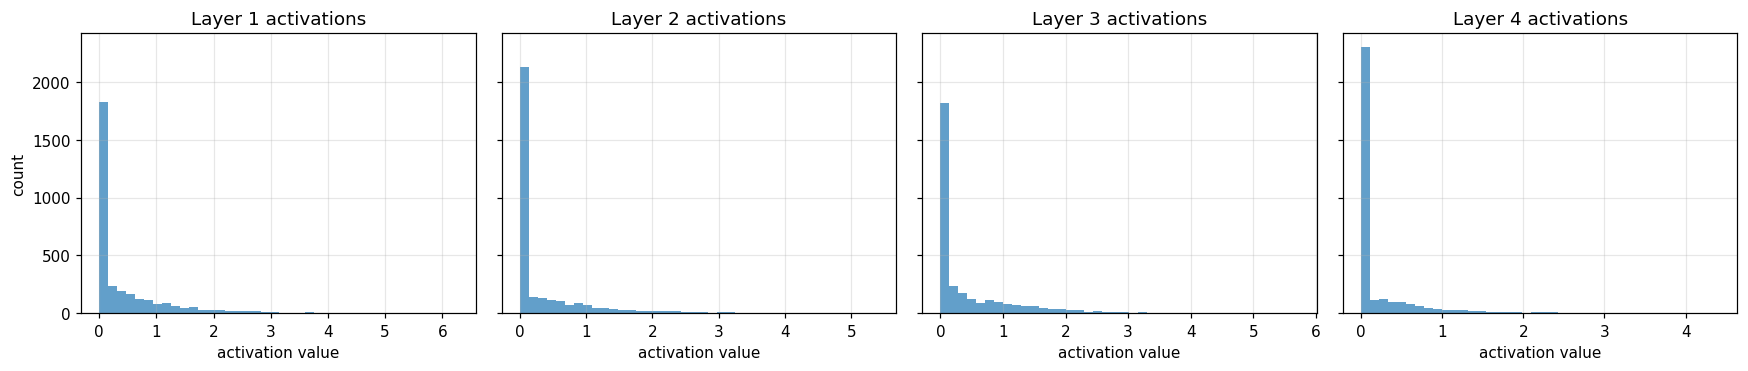

In [241]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, l in zip(axes, [1, 2, 3, 4]):
    ax.hist(probe_cache[f"A{l}"].flatten(), bins=40, color="tab:blue", alpha=0.7)
    ax.set_title(f"Layer {l} activations")
    ax.set_xlabel("activation value")
axes[0].set_ylabel("count")
plt.tight_layout()
plt.savefig("../figures/54_internal_representations.png", dpi=110, bbox_inches="tight")
plt.show()

With He initialization and ReLU, activation scale is roughly maintained across these four layers in this experiment (means and standard deviations stay in a comparable range rather than collapsing or exploding) - a property investigated more systematically in Section 11.6. This is a property of this specific network/initialization pairing, not a claim about activation distributions in general.

## 11.5 Activation Functions in Deep Networks

$$\sigma'(z)=\sigma(z)(1-\sigma(z)) \qquad \tanh'(z)=1-\tanh^2(z)
\qquad \text{ReLU}'(z)=\begin{cases}1&z>0\\0&z\leq0\end{cases}
\qquad \text{LeakyReLU}'(z)=\begin{cases}1&z>0\\\alpha&z<0\end{cases}$$

Convention at $z=0$: ReLU uses $0$ (Part 6/7's convention); Leaky ReLU
uses $\alpha$ (matching its $z<0$ branch) - both are implementation
choices at a non-differentiable point, not mathematical necessities.

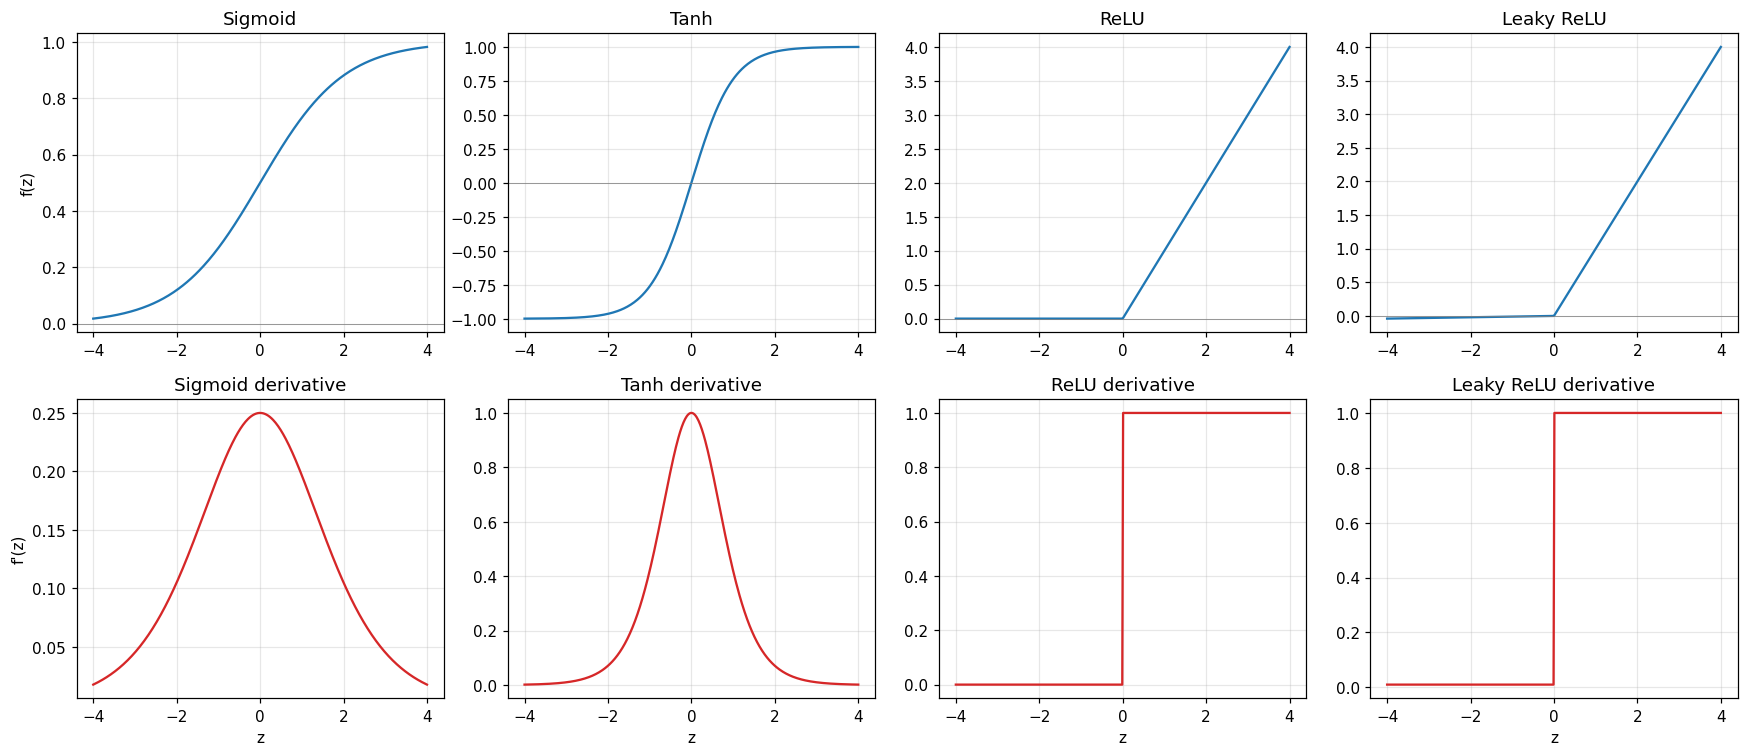

In [242]:
z_range_11 = np.linspace(-4, 4, 400)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
activations_11 = [("Sigmoid", dn.sigmoid, dn.sigmoid_derivative),
                    ("Tanh", dn.tanh_activation, dn.tanh_derivative),
                    ("ReLU", dn.relu, dn.relu_derivative),
                    ("Leaky ReLU", dn.leaky_relu, dn.leaky_relu_derivative)]
for col, (name, f, fprime) in enumerate(activations_11):
    axes[0, col].plot(z_range_11, f(z_range_11), color="tab:blue")
    axes[0, col].set_title(name); axes[0, col].axhline(0, color="gray", linewidth=0.5)
    axes[1, col].plot(z_range_11, fprime(z_range_11), color="tab:red")
    axes[1, col].set_title(f"{name} derivative"); axes[1, col].set_xlabel("z")
axes[0, 0].set_ylabel("f(z)"); axes[1, 0].set_ylabel("f'(z)")
plt.tight_layout()
plt.savefig("../figures/55_activation_curves.png", dpi=110, bbox_inches="tight")
plt.show()

In [243]:
# Numerical derivative check for all four activations, away from the z=0 kink
test_z_11 = np.array([-2.0, -0.5, 0.3, 1.5, 3.0])
h_11 = 1e-5

for name, f, fprime in activations_11:
    analytical = fprime(test_z_11)
    numerical = (f(test_z_11 + h_11) - f(test_z_11 - h_11)) / (2 * h_11)
    max_diff = np.max(np.abs(analytical - numerical))
    print(f"{name:12s}: max |analytical - numerical| = {max_diff:.2e}")
    assert max_diff < 1e-4

print("\nValidation passed: all four analytical derivatives match numerical finite differences.")

Sigmoid     : max |analytical - numerical| = 3.17e-12
Tanh        : max |analytical - numerical| = 2.23e-11
ReLU        : max |analytical - numerical| = 6.55e-12
Leaky ReLU  : max |analytical - numerical| = 6.55e-12

Validation passed: all four analytical derivatives match numerical finite differences.


## 11.6 Weight Initialization and Signal Propagation

- **Xavier/Glorot-style**: $\text{Var}(W)\approx1/\text{fan\_in}$ - a
  variance-preserving heuristic under assumptions associated with
  symmetric, near-linear activations (sigmoid/tanh near 0).
- **He-style**: $\text{Var}(W)\approx2/\text{fan\_in}$ - a
  variance-preserving heuristic under assumptions associated with
  ReLU-like activations (accounting for roughly half the units being
  zeroed by ReLU).

Neither is presented as an exact universal rule - both are heuristics
derived under simplifying assumptions that a real trained network need
not exactly satisfy.

In [244]:
print(inspect.getsource(dn.initialize_deep_network))

def initialize_deep_network(layer_sizes, method="random", scale=0.5, seed=42):
    """
    layer_sizes: [input_dim, hidden_1, ..., hidden_L-1, output_dim].
    method="random": W_l ~ N(0,1) * scale for every layer (a fixed, chosen scale).
    method="xavier": W_l ~ N(0,1) * sqrt(1/fan_in) - a variance-preserving
        heuristic under assumptions associated with symmetric, near-linear
        activations (sigmoid/tanh near 0); `scale` is ignored.
    method="he": W_l ~ N(0,1) * sqrt(2/fan_in) - a variance-preserving
        heuristic under assumptions associated with ReLU-like activations
        (accounting for roughly half the units being zeroed); `scale` ignored.
    Uses `np.random.default_rng(seed)` for reproducibility. Biases start at
    zero. Returns a dict {"W1":.., "b1":.., "W2":.., "b2":.., ...}.
    """
    rng = np.random.default_rng(seed)
    params = {}
    num_layers = len(layer_sizes) - 1
    for l in range(1, num_layers + 1):
        fan_in, fan_out = layer_sizes[l -

In [245]:
# Empirical variance check: large matrices, several seeds, compare to the intended scale
fan_in_check = 500
n_trials = 20
xavier_vars, he_vars = [], []
for trial_seed in range(n_trials):
    W_xavier = dn.initialize_deep_network([fan_in_check, 500], method="xavier", seed=trial_seed)["W1"]
    W_he = dn.initialize_deep_network([fan_in_check, 500], method="he", seed=trial_seed)["W1"]
    xavier_vars.append(np.var(W_xavier))
    he_vars.append(np.var(W_he))

mean_xavier_var = np.mean(xavier_vars)
mean_he_var = np.mean(he_vars)
expected_xavier = 1.0 / fan_in_check
expected_he = 2.0 / fan_in_check

print(f"Xavier: empirical variance = {mean_xavier_var:.6f}, intended ~= {expected_xavier:.6f}")
print(f"He:     empirical variance = {mean_he_var:.6f}, intended ~= {expected_he:.6f}")

assert np.isclose(mean_xavier_var, expected_xavier, rtol=0.15)
assert np.isclose(mean_he_var, expected_he, rtol=0.15)
assert np.isfinite(W_xavier).all() and np.isfinite(W_he).all()
print("\nValidation passed: empirical variance is close to the intended scale for both schemes.")

Xavier: empirical variance = 0.002001, intended ~= 0.002000
He:     empirical variance = 0.004001, intended ~= 0.004000

Validation passed: empirical variance is close to the intended scale for both schemes.


In [246]:
init_comparison_rows = []
for label, method, scale in [("small random", "random", 0.01), ("large random", "random", 5.0),
                               ("xavier", "xavier", None), ("he", "he", None)]:
    params_init = dn.initialize_deep_network(probe_layer_sizes, method=method,
                                              scale=scale if scale else 0.5, seed=42)
    _, cache_init = dn.forward_deep_network(X_probe, params_init, probe_num_layers, "relu")
    for l in [1, 2, 3, 4]:
        a = cache_init[f"A{l}"]
        init_comparison_rows.append({"Initialization": label, "Layer": l,
                                       "Mean": a.mean(), "Std": a.std(),
                                       "Near-Zero Fraction": np.mean(np.abs(a) < 1e-3)})

init_comparison_table = pd.DataFrame(init_comparison_rows)
init_comparison_table.pivot(index="Layer", columns="Initialization", values="Std")

Initialization        he  large random  small random    xavier
Layer                                                         
1               0.735488      3.677442  7.354883e-03  0.520069
2               0.686014     48.508524  1.940341e-04  0.343007
3               0.714969    714.969125  5.719753e-06  0.252780
4               0.492913   6970.835861  1.115334e-07  0.123228

Small-scale initialization's activation standard deviation shrinks toward zero by layer 3-4 in this experiment (the signal effectively vanishes going forward through the network); large-scale initialization's standard deviation grows by roughly an order of magnitude per layer; Xavier and He both keep the standard deviation within a comparable range across all four layers. This illustrates why initialization scale matters for signal propagation specifically in this architecture, not as a universal ranking of these methods.

## 11.7 Gradient Propagation Through Multiple Layers

Extending Part 7's chain-rule pattern to any number of layers:

$$\delta^{(l)} = \left(W^{(l+1)T}\delta^{(l+1)}\right)\odot\varphi'(z^{(l)})
\qquad \frac{\partial L}{\partial W^{(l)}} = \delta^{(l)}(a^{(l-1)})^T$$

implemented recursively in `backward_deep_network`.

In [247]:
print(inspect.getsource(dn.backward_deep_network))

def backward_deep_network(y, cache, params, num_layers, activation="relu"):
    """
    Manual backward pass (same recursive pattern as Part 7's backprop.py,
    generalized to any of the four activations above):
        dZ_L = A_L - y                              (sigmoid + BCE cancellation)
        dW_l = (1/n) A_(l-1)^T dZ_l    db_l = (1/n) sum(dZ_l)
        dA_(l-1) = dZ_l W_l^T
        dZ_(l-1) = dA_(l-1) * activation'(Z_(l-1))   (elementwise)
    Returns a dict of gradients with keys dW_l, db_l for l=1..num_layers.
    """
    _, act_deriv = _ACTIVATIONS[activation]
    n = cache["A0"].shape[0]
    y_col = y.reshape(-1, 1)
    grads = {}

    dZ = cache[f"A{num_layers}"] - y_col
    for l in range(num_layers, 0, -1):
        A_prev = cache[f"A{l - 1}"]
        grads[f"dW{l}"] = (1.0 / n) * (A_prev.T @ dZ)
        grads[f"db{l}"] = (1.0 / n) * np.sum(dZ, axis=0)
        if l > 1:
            dA_prev = dZ @ params[f"W{l}"].T
            dZ = dA_prev * act_deriv(cache[f"Z{l - 1}"])


In [248]:
gradcheck_rng = np.random.default_rng(1)
X_gradcheck = gradcheck_rng.standard_normal((20, 3))
y_gradcheck = (gradcheck_rng.random(20) > 0.5).astype(float)

gradcheck_sizes = [3, 6, 5, 1]
gradcheck_num_layers = len(gradcheck_sizes) - 1
gradcheck_params = dn.initialize_deep_network(gradcheck_sizes, method="he", scale=0.5, seed=7)

gradcheck_output, gradcheck_cache = dn.forward_deep_network(X_gradcheck, gradcheck_params, gradcheck_num_layers, "relu")
gradcheck_grads = dn.backward_deep_network(y_gradcheck, gradcheck_cache, gradcheck_params, gradcheck_num_layers, "relu")

# Pick several parameter elements with genuinely nonzero gradients (some ReLU units are inactive)
nonzero_w2 = np.argwhere(np.abs(gradcheck_grads["dW2"]) > 1e-8)
nonzero_w3 = np.argwhere(np.abs(gradcheck_grads["dW3"]) > 1e-8)
elements_11 = [("W1", (0, 0)),
                ("W2", tuple(int(x) for x in nonzero_w2[0])),
                ("W3", tuple(int(x) for x in nonzero_w3[0])),
                ("b1", (2,))]

epsilon_11 = 1e-5
print(f"{'Parameter':>12} | {'Analytical':>12} | {'Numerical':>12} | {'Relative Error':>15}")
for name, idx in elements_11:
    numerical = dn.numerical_gradient_deep(X_gradcheck, y_gradcheck, gradcheck_params, name, idx,
                                            gradcheck_num_layers, "relu", h=epsilon_11)
    analytical = gradcheck_grads[f"d{name}"][idx]
    rel_error = abs(analytical - numerical) / (max(abs(analytical), abs(numerical)) + 1e-12)
    print(f"{name}{str(idx):>8} | {analytical:12.6f} | {numerical:12.6f} | {rel_error:15.2e}")
    assert rel_error < 1e-4

print("\nGradient check passed (tolerance: relative error < 1e-4) for all four tested elements.")

   Parameter |   Analytical |    Numerical |  Relative Error
W1  (0, 0) |    -0.007597 |    -0.007597 |        7.56e-11
W2  (0, 0) |     0.000948 |     0.000948 |        5.53e-09
W3  (0, 0) |    -0.000078 |    -0.000078 |        3.31e-08
b1    (2,) |     0.012914 |     0.012914 |        8.96e-11

Gradient check passed (tolerance: relative error < 1e-4) for all four tested elements.


## 11.8 Vanishing and Exploding Gradients

A controlled comparison across **depth x activation x initialization**
jointly (not a repeat of Part 7's single-activation experiment): an
8-hidden-layer network, same architecture and probe input, under three
paired activation/initialization configurations chosen for their
theoretical association (sigmoid with a small scale, tanh with Xavier,
ReLU with He).

In [249]:
gradflow_rng = np.random.default_rng(0)
X_gradflow = gradflow_rng.standard_normal((50, 2))
y_gradflow = (gradflow_rng.random(50) > 0.5).astype(float)

gradflow_sizes = [2] + [8] * 8 + [1]
gradflow_num_layers = len(gradflow_sizes) - 1

gradflow_configs = [
    ("Sigmoid + small init", "sigmoid", "random", 0.3),
    ("Tanh + Xavier init", "tanh", "xavier", None),
    ("ReLU + He init", "relu", "he", None),
]
gradflow_results = {}
for label, act, method, scale in gradflow_configs:
    params_gf = dn.initialize_deep_network(gradflow_sizes, method=method,
                                            scale=scale if scale else 0.5, seed=42)
    _, cache_gf = dn.forward_deep_network(X_gradflow, params_gf, gradflow_num_layers, act)
    grads_gf = dn.backward_deep_network(y_gradflow, cache_gf, params_gf, gradflow_num_layers, act)
    stats_gf = dn.gradient_norm_statistics(grads_gf, gradflow_num_layers)
    gradflow_results[label] = stats_gf
    for entry in stats_gf:
        assert np.isfinite(entry["grad_norm"])

gradflow_table = pd.concat(
    [pd.DataFrame(v).assign(Configuration=k) for k, v in gradflow_results.items()], ignore_index=True
)
gradflow_table.pivot(index="layer", columns="Configuration", values="grad_norm")

Configuration  ReLU + He init  Sigmoid + small init  Tanh + Xavier init
layer                                                                  
1                    0.022212          2.243038e-07            0.041079
2                    0.060501          4.393255e-07            0.111731
3                    0.057876          1.528904e-06            0.068389
4                    0.020151          7.213264e-06            0.074379
5                    0.014417          3.200629e-05            0.058251
6                    0.032736          1.458218e-04            0.054651
7                    0.036978          6.503672e-04            0.041089
8                    0.049874          4.525978e-03            0.069653
9                    0.028701          2.008605e-02            0.058305

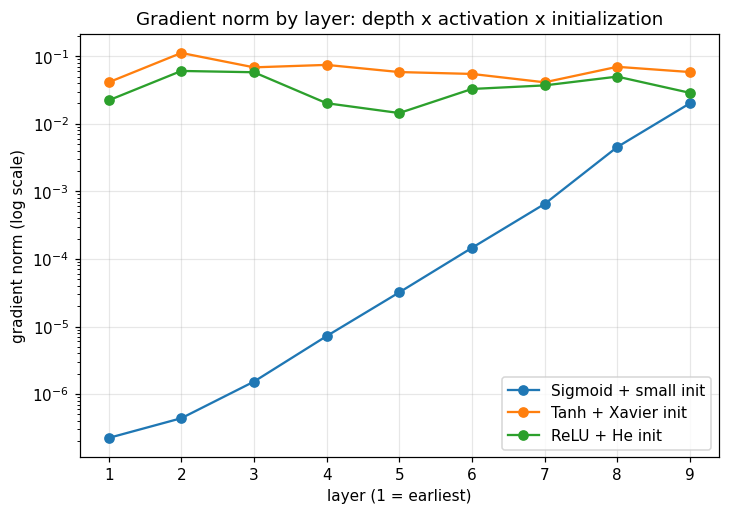

In [250]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for label, stats_gf in gradflow_results.items():
    layers_gf = [s["layer"] for s in stats_gf]
    norms_gf = [s["grad_norm"] for s in stats_gf]
    ax.plot(layers_gf, norms_gf, "o-", label=label)
ax.set_yscale("log")
ax.set_xlabel("layer (1 = earliest)")
ax.set_ylabel("gradient norm (log scale)")
ax.set_title("Gradient norm by layer: depth x activation x initialization")
ax.legend()
plt.savefig("../figures/56_gradient_flow_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

**Sigmoid + small initialization**: gradient norm at layer 1 (earliest)
is roughly four orders of magnitude smaller than at layer 8 (closest to
the output) in this experiment - sigmoid derivatives are bounded
($\leq0.25$) and can become very small in saturated regions, which can
contribute to gradient attenuation compounded across many layers, though
this is not claimed to happen with sigmoid *regardless* of scale or
depth. **Tanh + Xavier** and **ReLU + He**: gradient norms stay within a
comparable range across all 8 layers in this experiment, consistent
with (but not proof of) the variance-preserving motivation behind these
initialization choices for their respective activations. Exploding
gradients are not directly observed in this particular configuration set
(Section 11.12's initialization experiment separately shows a case
where training fails to progress at all rather than exploding) - this
experiment demonstrates vanishing behavior concretely, and stable
propagation as its counterpoint, rather than manufacturing an exploding
example for its own sake.

## 11.9 Depth and Optimization Difficulty

Training networks of increasing depth on the Part 9 moons dataset (same
train/validation split, ReLU + He initialization, $\eta=0.3$, 5000
iterations) - dataset, objective, optimizer, learning rate,
initialization methodology, and training budget held fixed; only depth
changes.

In [251]:
def train_with_curve_11(layer_sizes, iterations, learning_rate, activation="relu",
                          init_method="he", init_scale=0.5, seed=42, eval_every=100):
    num_layers = len(layer_sizes) - 1
    params = dn.initialize_deep_network(layer_sizes, method=init_method, scale=init_scale, seed=seed)
    train_curve, val_curve = [], []
    for i in range(iterations):
        A2, cache = dn.forward_deep_network(X_train, params, num_layers, activation)
        grads = dn.backward_deep_network(y_train, cache, params, num_layers, activation)
        params = {k: params[k] - learning_rate * grads[f"d{k}"] for k in params}
        if i % eval_every == 0:
            train_curve.append(dn.binary_cross_entropy(y_train, dn.forward_deep_network(X_train, params, num_layers, activation)[0].flatten()))
            val_curve.append(dn.binary_cross_entropy(y_val, dn.forward_deep_network(X_val, params, num_layers, activation)[0].flatten()))
    return params, np.array(train_curve), np.array(val_curve)

depth_configs_11 = [("1 hidden layer", [8]), ("2 hidden layers", [8, 8]),
                     ("4 hidden layers", [8, 8, 8, 8]), ("8 hidden layers", [8] * 8)]
depth_curves_11 = {}
for label, hidden in depth_configs_11:
    layer_sizes_d = [2] + hidden + [1]
    params_d, train_curve_d, val_curve_d = train_with_curve_11(layer_sizes_d, 5000, 0.3)
    depth_curves_11[label] = (train_curve_d, val_curve_d)
    print(f"{label}: final train_loss={train_curve_d[-1]:.4f}, final val_loss={val_curve_d[-1]:.4f}")

1 hidden layer: final train_loss=0.2079, final val_loss=0.4820
2 hidden layers: final train_loss=0.0271, final val_loss=1.4012
4 hidden layers: final train_loss=0.0295, final val_loss=1.7298
8 hidden layers: final train_loss=0.0359, final val_loss=0.5838


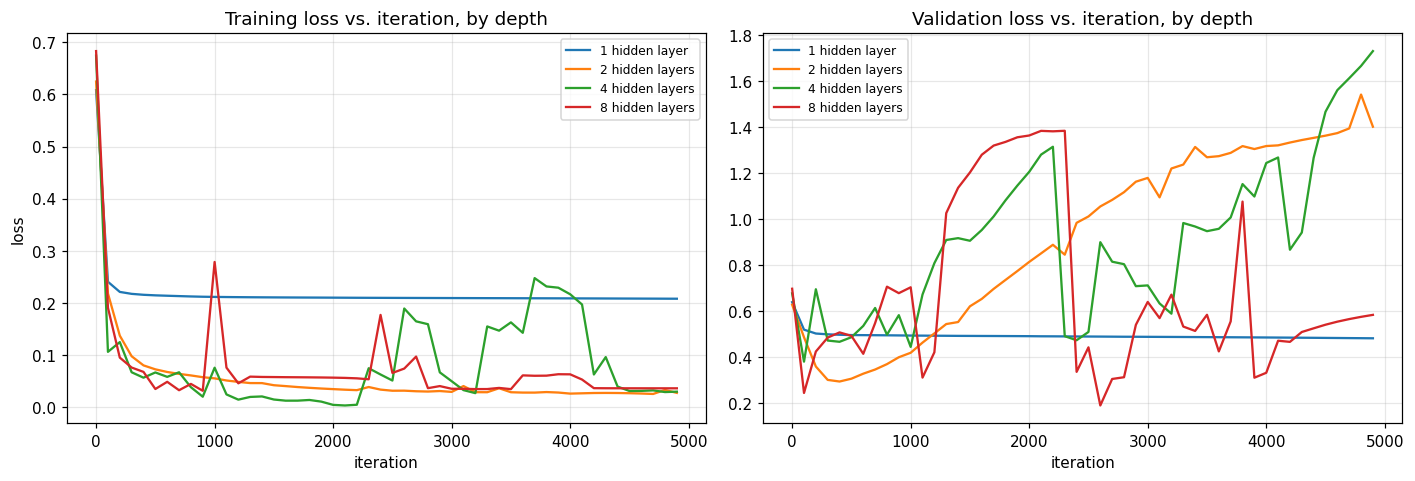

In [252]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
eval_steps_11 = np.arange(len(list(depth_curves_11.values())[0][0])) * 100
for label, (train_curve_d, val_curve_d) in depth_curves_11.items():
    axes[0].plot(eval_steps_11, train_curve_d, label=label)
    axes[1].plot(eval_steps_11, val_curve_d, label=label)
axes[0].set_title("Training loss vs. iteration, by depth"); axes[0].set_xlabel("iteration"); axes[0].set_ylabel("loss")
axes[1].set_title("Validation loss vs. iteration, by depth"); axes[1].set_xlabel("iteration")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("../figures/57_depth_training_curves.png", dpi=110, bbox_inches="tight")
plt.show()

The 1-hidden-layer network converges to the highest training loss of the four (least capacity); 2, 4, and 8 hidden layers all reach low training loss, but their validation loss curves do not improve monotonically with depth in this experiment - the deepest network does not achieve the best validation loss here. This is an observation from this specific controlled experiment, not a general claim about how validation performance relates to depth.

## 11.10 Controlled Depth Experiments

Formalizing Section 11.9's shallow/moderate/deep comparison with
parameter counts, Part 10's evaluation methodology (on the validation
set, not the test set), and final gradient statistics.

In [253]:
depth_experiment_rows = []
depth_final_grad_stats = {}

for label, hidden in [("Shallow (1 layer)", [8]), ("Moderate (2 layers)", [8, 8]), ("Deep (8 layers)", [8] * 8)]:
    layer_sizes_d = [2] + hidden + [1]
    num_layers_d = len(layer_sizes_d) - 1
    params_d, train_curve_d, val_curve_d = train_with_curve_11(layer_sizes_d, 5000, 0.3)

    train_probs_d = dn.forward_deep_network(X_train, params_d, num_layers_d, "relu")[0].flatten()
    val_probs_d = dn.forward_deep_network(X_val, params_d, num_layers_d, "relu")[0].flatten()
    train_preds_d = ev.probabilities_to_labels(train_probs_d, 0.5)
    val_preds_d = ev.probabilities_to_labels(val_probs_d, 0.5)
    train_metrics_d = ev.classification_metrics(y_train, train_preds_d)
    val_metrics_d = ev.classification_metrics(y_val, val_preds_d)

    _, final_cache_d = dn.forward_deep_network(X_train, params_d, num_layers_d, "relu")
    final_grads_d = dn.backward_deep_network(y_train, final_cache_d, params_d, num_layers_d, "relu")
    grad_stats_d = dn.gradient_norm_statistics(final_grads_d, num_layers_d)
    depth_final_grad_stats[label] = grad_stats_d

    n_params_d = sum(v.size for v in params_d.values())
    depth_experiment_rows.append({
        "Configuration": label, "Parameters": n_params_d,
        "Train Loss": train_curve_d[-1], "Val Loss": val_curve_d[-1],
        "Train Accuracy": train_metrics_d["accuracy"], "Val Accuracy": val_metrics_d["accuracy"],
        "Earliest-Layer Grad Norm": grad_stats_d[0]["grad_norm"],
        "Latest-Layer Grad Norm": grad_stats_d[-1]["grad_norm"],
    })
    assert np.isfinite(train_curve_d).all() and np.isfinite(val_curve_d).all()

depth_experiment_table = pd.DataFrame(depth_experiment_rows)
assert (depth_experiment_table["Parameters"].diff().dropna() > 0).all()
depth_experiment_table

         Configuration  ...  Latest-Layer Grad Norm
0    Shallow (1 layer)  ...                0.001247
1  Moderate (2 layers)  ...                0.021111
2      Deep (8 layers)  ...                0.000887

[3 rows x 8 columns]

Parameter count increases substantially with depth (33 to 537 in this architecture family), and the deepest network reaches the highest training accuracy - but its validation accuracy is essentially tied with the moderate network's, and its final loss values do not improve on the moderate network's. Increased capacity here bought better training fit without a proportional generalization improvement, at a real computational cost (more parameters, more forward/backward computation, quantified in Section 11.14) - this experiment cannot separate how much of the difference is attributable to depth alone versus the specific architecture/training-budget combination tested.

## 11.11 Controlled Activation Experiments

Architecture fixed at `[2,8,8,8,8,1]`, same random initialization
(`method="random", scale=0.5`, deliberately activation-agnostic so this
experiment changes only the activation function), same dataset, seed,
optimizer, learning rate, and iterations - only the activation changes.

In [254]:
activation_experiment_sizes = [2, 8, 8, 8, 8, 1]
activation_experiment_num_layers = len(activation_experiment_sizes) - 1
activation_curves_11 = {}
activation_experiment_rows = []

for act in ["sigmoid", "tanh", "relu", "leaky_relu"]:
    params_a = dn.initialize_deep_network(activation_experiment_sizes, method="random", scale=0.5, seed=42)
    train_curve_a, val_curve_a = [], []
    for i in range(5000):
        A2, cache = dn.forward_deep_network(X_train, params_a, activation_experiment_num_layers, act)
        grads = dn.backward_deep_network(y_train, cache, params_a, activation_experiment_num_layers, act)
        params_a = {k: params_a[k] - 0.3 * grads[f"d{k}"] for k in params_a}
        if i % 100 == 0:
            train_curve_a.append(dn.binary_cross_entropy(y_train, dn.forward_deep_network(X_train, params_a, activation_experiment_num_layers, act)[0].flatten()))
            val_curve_a.append(dn.binary_cross_entropy(y_val, dn.forward_deep_network(X_val, params_a, activation_experiment_num_layers, act)[0].flatten()))
    activation_curves_11[act] = (np.array(train_curve_a), np.array(val_curve_a))

    _, final_cache_a = dn.forward_deep_network(X_train, params_a, activation_experiment_num_layers, act)
    final_grads_a = dn.backward_deep_network(y_train, final_cache_a, params_a, activation_experiment_num_layers, act)
    grad_norm_a = dn.gradient_norm_statistics(final_grads_a, activation_experiment_num_layers)[0]["grad_norm"]

    train_acc_a = np.mean(dn.predict_deep(X_train, params_a, activation_experiment_num_layers, act) == y_train)
    val_acc_a = np.mean(dn.predict_deep(X_val, params_a, activation_experiment_num_layers, act) == y_val)
    activation_experiment_rows.append({"Activation": act, "Train Loss": train_curve_a[-1],
                                         "Val Loss": val_curve_a[-1], "Train Acc": train_acc_a,
                                         "Val Acc": val_acc_a, "Earliest-Layer Grad Norm": grad_norm_a})
    assert np.isfinite(train_curve_a).all() and np.isfinite(val_curve_a).all()

activation_experiment_table = pd.DataFrame(activation_experiment_rows)
activation_experiment_table

   Activation  Train Loss  ...  Val Acc  Earliest-Layer Grad Norm
0     sigmoid    0.215237  ...    0.750                  0.016084
1        tanh    0.000235  ...    0.925                  0.000120
2        relu    0.000127  ...    0.925                  0.001054
3  leaky_relu    0.017393  ...    0.900                  0.002961

[4 rows x 6 columns]

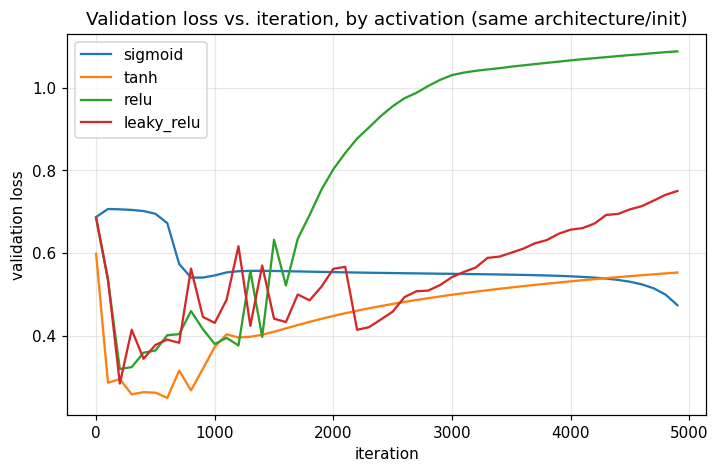

In [255]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
eval_steps_a = np.arange(len(activation_curves_11["relu"][0])) * 100
for act, (train_curve_a, val_curve_a) in activation_curves_11.items():
    ax.plot(eval_steps_a, val_curve_a, label=act)
ax.set_title("Validation loss vs. iteration, by activation (same architecture/init)")
ax.set_xlabel("iteration"); ax.set_ylabel("validation loss")
ax.legend()
plt.savefig("../figures/58_activation_training_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

With this shared (activation-agnostic) initialization scale, sigmoid trains noticeably slower and reaches a higher final training loss than the other three in this experiment, consistent with Section 11.8's observation that sigmoid can attenuate gradients across depth. Tanh, ReLU, and Leaky ReLU all reach very low training loss; their validation losses differ, with none claimed to be universally superior - the appropriate choice can depend on the initialization pairing (Section 11.6) as much as the activation itself.

## 11.12 Controlled Initialization Experiments

Architecture and activation fixed (`[2,8,8,8,8,1]`, ReLU throughout),
same dataset/seed/optimizer/learning-rate/iterations - only the
initialization scheme changes.

In [256]:
init_experiment_rows = []
init_curves_11 = {}

for label, method, scale in [("Small random", "random", 0.01), ("Large random", "random", 3.0),
                               ("Xavier", "xavier", None), ("He", "he", None)]:
    params_i = dn.initialize_deep_network(activation_experiment_sizes, method=method,
                                           scale=scale if scale else 0.5, seed=42)

    _, initial_cache_i = dn.forward_deep_network(X_train, params_i, activation_experiment_num_layers, "relu")
    initial_grads_i = dn.backward_deep_network(y_train, initial_cache_i, params_i, activation_experiment_num_layers, "relu")
    initial_grad_norm_i = dn.gradient_norm_statistics(initial_grads_i, activation_experiment_num_layers)[0]["grad_norm"]
    initial_activation_std_i = np.std(initial_cache_i["A1"])

    train_curve_i = []
    for i in range(5000):
        A2, cache = dn.forward_deep_network(X_train, params_i, activation_experiment_num_layers, "relu")
        grads = dn.backward_deep_network(y_train, cache, params_i, activation_experiment_num_layers, "relu")
        params_i = {k: params_i[k] - 0.3 * grads[f"d{k}"] for k in params_i}
        if i % 100 == 0:
            train_curve_i.append(dn.binary_cross_entropy(y_train, dn.forward_deep_network(X_train, params_i, activation_experiment_num_layers, "relu")[0].flatten()))
    init_curves_11[label] = np.array(train_curve_i)

    val_loss_i = dn.binary_cross_entropy(y_val, dn.forward_deep_network(X_val, params_i, activation_experiment_num_layers, "relu")[0].flatten())
    train_acc_i = np.mean(dn.predict_deep(X_train, params_i, activation_experiment_num_layers, "relu") == y_train)
    val_acc_i = np.mean(dn.predict_deep(X_val, params_i, activation_experiment_num_layers, "relu") == y_val)

    init_experiment_rows.append({"Initialization": label, "Initial Activation Std": initial_activation_std_i,
                                   "Initial Grad Norm": initial_grad_norm_i, "Final Train Loss": train_curve_i[-1],
                                   "Val Loss": val_loss_i, "Train Acc": train_acc_i, "Val Acc": val_acc_i})
    assert np.isfinite(train_curve_i).all()

init_experiment_table = pd.DataFrame(init_experiment_rows)
init_experiment_table

  Initialization  Initial Activation Std  ...  Train Acc  Val Acc
0   Small random                0.005486  ...     0.5500    0.450
1   Large random                1.645787  ...     0.5500    0.450
2         Xavier                0.387916  ...     1.0000    0.925
3             He                0.548596  ...     0.9875    0.875

[4 rows x 7 columns]

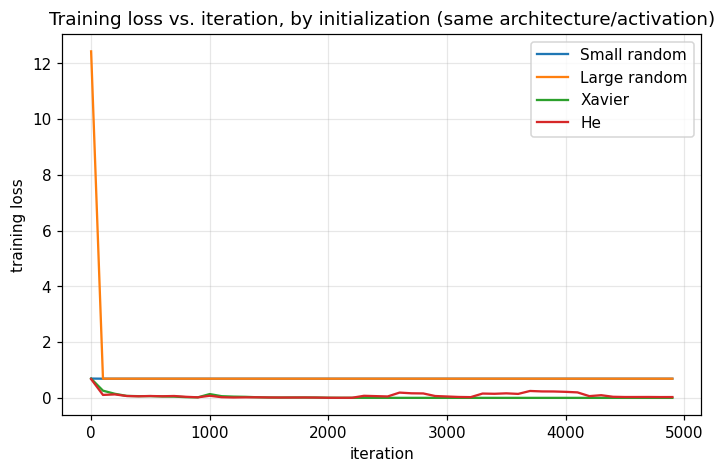

In [257]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
eval_steps_i = np.arange(len(init_curves_11["He"])) * 100
for label, curve_i in init_curves_11.items():
    ax.plot(eval_steps_i, curve_i, label=label)
ax.set_title("Training loss vs. iteration, by initialization (same architecture/activation)")
ax.set_xlabel("iteration"); ax.set_ylabel("training loss")
ax.legend()
plt.savefig("../figures/59_initialization_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

Small and large random initialization both fail to train meaningfully in this experiment - final training accuracy stays near chance (0.55) for both, consistent with signal either vanishing (small scale, Section 11.6) or propagating in a way that gradient descent cannot productively use at this learning rate (large scale). Xavier and He both train successfully to near-zero training loss and high validation accuracy. This is a concrete illustration of why initialization affects trainability, not only final activation statistics.

## 11.13 Representation Analysis

Analyzing the trained He/ReLU 4-hidden-layer network from Section 11.4's
architecture (now actually trained on the moons training data) across
its hidden layers.

In [258]:
repr_layer_sizes = [2, 16, 16, 16, 16, 1]
repr_num_layers = len(repr_layer_sizes) - 1
repr_result = dn.train_deep_network(X_train, y_train, repr_layer_sizes, learning_rate=0.3, iterations=5000,
                                     activation="relu", init_method="he", seed=42)
_, repr_cache = dn.forward_deep_network(X_train, repr_result["params"], repr_num_layers, "relu")

repr_stats = dn.activation_statistics(repr_cache, repr_num_layers)
repr_table = pd.DataFrame(repr_stats)
assert len(repr_table) == repr_num_layers - 1  # hidden layers only (output layer excluded)
assert repr_table["near_zero_fraction"].between(0, 1).all()
repr_table

   layer      mean       std  min        max  near_zero_fraction
0      1  0.341952  0.675436  0.0   3.895542            0.635938
1      2  0.565953  1.319075  0.0   9.758496            0.603125
2      3  1.073663  2.445307  0.0  17.609586            0.632812
3      4  2.016794  4.584810  0.0  33.401168            0.618750

In [259]:
# Pairwise distance statistics: do same-class points end up closer together in later layers?
from itertools import combinations

def mean_pairwise_distance_by_class(activations, labels):
    class0_points = activations[labels == 0]
    class1_points = activations[labels == 1]
    def mean_intra_distance(points, max_pairs=500):
        n_pts = len(points)
        idx_pairs = list(combinations(range(n_pts), 2))
        if len(idx_pairs) > max_pairs:
            sel = np.random.default_rng(0).choice(len(idx_pairs), max_pairs, replace=False)
            idx_pairs = [idx_pairs[i] for i in sel]
        return np.mean([np.linalg.norm(points[i] - points[j]) for i, j in idx_pairs])
    return mean_intra_distance(class0_points), mean_intra_distance(class1_points)

distance_rows = []
for l in [1, 2, 3, 4]:
    d0, d1 = mean_pairwise_distance_by_class(repr_cache[f"A{l}"], y_train)
    distance_rows.append({"Layer": l, "Mean Intra-Class-0 Distance": d0, "Mean Intra-Class-1 Distance": d1})
distance_table = pd.DataFrame(distance_rows)
distance_table

   Layer  Mean Intra-Class-0 Distance  Mean Intra-Class-1 Distance
0      1                     2.446345                     2.663983
1      2                     3.659353                     5.499825
2      3                     7.549069                     8.659373
3      4                    16.991769                     9.202486

Hidden-layer dimensionality here is 16 (too high for a direct 2D scatter plot, and Part 5 already covered PCA for dimensionality reduction - not repeated here); activation distributions and distance statistics are used instead, as suggested. The layer-wise statistics above describe how this specific trained network's representations behave; they do not establish what any individual hidden unit \"means\" without further evidence beyond these aggregate statistics.

## 11.14 Computational Perspective

For a fully connected layer with $W\in\mathbb{R}^{d_{\text{out}}\times
d_{\text{in}}}$, the dominant forward matrix multiplication costs
approximately $O(d_{\text{out}}\cdot d_{\text{in}})$ per sample. For a
network with $L$ layers, total forward cost is approximately
$O\left(\sum_l d_l\cdot d_{l-1}\right)$; backpropagation has a
comparable order of arithmetic work (Part 7).

Section 11.10's parameter counts (33 / 105 / 537 for 1/2/8 hidden layers
in that architecture family) translate directly into proportionally more
per-iteration computation and more memory for storing both parameters
and the cached forward activations each layer requires for its backward
pass (Part 7's memory discussion) - deeper networks cost more in both
dimensions, not only in parameter count. This project does not measure
wall-clock training time, since it depends heavily on hardware and
implementation details beyond this notebook's scope; the complexity
relationships above describe how cost scales, not an exact runtime.

## 11.15 Summary

1. A deep neural network is a composition of parameterized functions (Section 11.1-11.2).
2. Increasing depth changes both representational capacity and optimization behavior (Sections 11.9-11.10).
3. Hidden layers create progressively transformed internal representations (Sections 11.4, 11.13).
4. Activation functions influence both forward signal propagation and backward gradient propagation (Sections 11.5, 11.8, 11.11).
5. Initialization affects the scale of activations and gradients (Sections 11.6, 11.12).
6. Vanishing and exploding gradients can emerge from repeated multiplication through deep computational graphs (Section 11.8).
7. Proper initialization can improve signal propagation but does not guarantee successful optimization (Section 11.12).
8. Greater depth introduces additional computational and memory costs (Section 11.14).
9. Controlled experiments are necessary to separate the effects of depth, activation choice, and initialization (Sections 11.9-11.12).
10. Neural-network architecture should be evaluated using both predictive performance and training dynamics, not loss alone.

$$
\text{Input} \rightarrow \text{Layer 1 Transformation} \rightarrow
\text{Layer 2 Transformation} \rightarrow \cdots \rightarrow
\text{Deep Representation} \rightarrow \text{Output} \rightarrow \text{Loss}
\rightarrow \text{Backpropagation} \rightarrow \text{Gradient Flow Through Depth}
\rightarrow \text{Parameter Updates} \rightarrow \text{Evaluation}
$$

Part 11 has investigated the mathematical and computational behavior of
deeper fully connected neural networks without introducing specialized
architectures.

---
# 12. Batch Normalization, Dropout, and Regularized Deep Networks

Part 9 introduced regularization (L1, L2, weight decay). Part 11
investigated how depth, activation choice, and initialization affect
signal and gradient propagation. This section investigates two
mechanisms that act directly on hidden activations and the training
process itself:

**How can normalization and stochastic regularization change the
training dynamics and generalization behavior of deep neural networks?**

$$
\text{Deep Network} \rightarrow \text{Hidden Activations} \rightarrow
\text{Activation Statistics} \rightarrow \text{Normalization} \rightarrow
\text{Batch Normalization} \rightarrow \text{Training vs Inference Behavior}
\rightarrow \text{Dropout} \rightarrow \text{Stochastic Regularization}
\rightarrow \text{Interaction With L1/L2} \rightarrow \text{Controlled Experiments}
$$

## 12.1 Motivation: Stabilizing Deep Network Training

Part 11 showed that deep networks can exhibit changing activation
scales across layers, gradient magnitudes that shrink or grow with
depth, and sensitivity to initialization scale. One approach to these
issues is to directly control the *distribution* of hidden activations
during training, rather than relying solely on a good initial weight
scale. **Initialization** (Part 11) sets the *initial* signal scale;
**normalization** (this section) acts on intermediate activations
*during* every forward pass, which is a different point of intervention.
Normalization is not presented as a universal fix for the difficulties
Part 11 identified - its actual effect is investigated experimentally in
Sections 12.12-12.14.

## 12.2 Activation Statistics Before Normalization

Reusing the Part 9 moons dataset/split and a fixed 2-hidden-layer
ReLU/He network (untrained forward pass, to isolate the effect of
architecture/initialization on activation scale, before any training
or normalization is introduced):

In [260]:
import sys
sys.path.insert(0, "../src")
import regularized_layers as rl

probe_sizes_12 = [2, 32, 32, 1]
probe_params_12 = rl.initialize_regularized_network(probe_sizes_12, seed=42)
_, probe_cache_12 = rl.forward_regularized_network(X_train, probe_params_12, probe_sizes_12,
                                                     use_batchnorm=False, training=True)

pre_norm_stats = []
for l in [1, 2]:
    z = probe_cache_12[f"Z{l}"]
    pre_norm_stats.append({"Layer": l, "Mean": z.mean(), "Variance": z.var(),
                             "Std": z.std(), "Min": z.min(), "Max": z.max()})
pre_norm_table = pd.DataFrame(pre_norm_stats)
pre_norm_table

   Layer      Mean  Variance       Std       Min       Max
0      1  0.041495  0.971421  0.985607 -4.581181  5.044794
1      2 -0.127264  0.985265  0.992605 -4.457207  4.963315

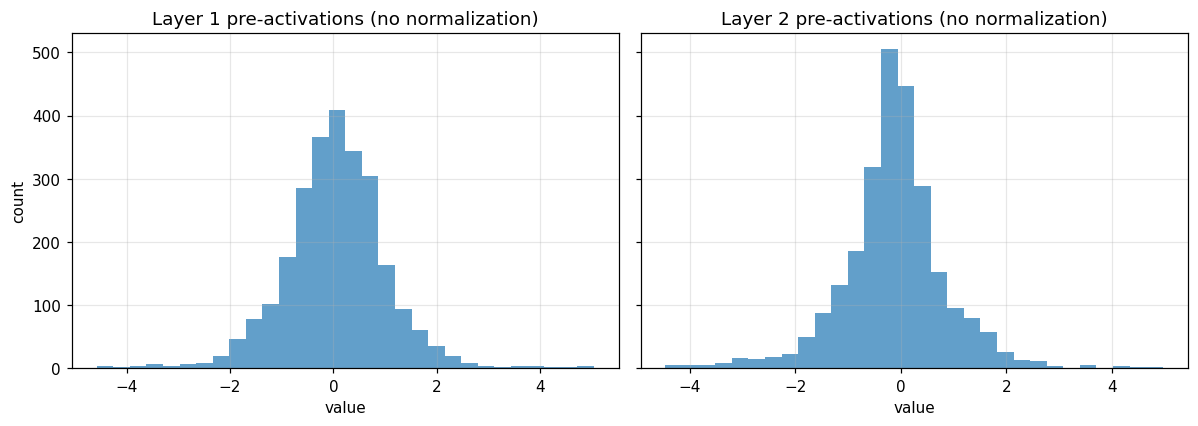

In [261]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, l in zip(axes, [1, 2]):
    ax.hist(probe_cache_12[f"Z{l}"].flatten(), bins=30, color="tab:blue", alpha=0.7)
    ax.set_title(f"Layer {l} pre-activations (no normalization)")
    ax.set_xlabel("value")
axes[0].set_ylabel("count")
plt.tight_layout()
plt.savefig("../figures/60_pre_normalization_stats.png", dpi=110, bbox_inches="tight")
plt.show()

Pre-activation scale differs between the two layers in this untrained network - the actual computed values above, not an assumed pattern. Section 12.12 compares training with and without normalization applied to these same layers.

## 12.3 Standardization

For a batch $x$: $\mu_B=\frac1m\sum_ix_i$, $\sigma_B^2=\frac1m\sum_i(x_i-\mu_B)^2$,
$\hat x_i=\dfrac{x_i-\mu_B}{\sqrt{\sigma_B^2+\epsilon}}$. $\epsilon>0$ prevents
division by zero (a feature with exactly zero batch variance) and
improves numerical stability generally.

In [262]:
print(inspect.getsource(rl.standardize_batch))

def standardize_batch(x, eps=1e-5):
    """
    Per-feature standardization over the batch dimension (axis 0):
        mu_B = mean(x, axis=0)
        var_B = mean((x - mu_B)^2, axis=0)
        x_hat = (x - mu_B) / sqrt(var_B + eps)
    `eps` prevents division by zero and improves numerical stability
    when a feature has (near-)zero variance in the batch.
    """
    mu = np.mean(x, axis=0)
    var = np.mean((x - mu) ** 2, axis=0)
    x_hat = (x - mu) / np.sqrt(var + eps)
    return x_hat, mu, var



In [263]:
x_standardize_demo = np.array([[1.0, 10.0], [2.0, 20.0], [3.0, 30.0], [4.0, 40.0]])
x_hat_demo, mu_demo, var_demo = rl.standardize_batch(x_standardize_demo)

print(f"Input:\n{x_standardize_demo}")
print(f"Batch mean: {mu_demo}")
print(f"Batch variance: {var_demo}")
print(f"Standardized:\n{x_hat_demo}")

assert x_hat_demo.shape == x_standardize_demo.shape
assert np.isfinite(x_hat_demo).all()
assert np.allclose(x_hat_demo.mean(axis=0), 0, atol=1e-8)
assert np.allclose(x_hat_demo.var(axis=0), 1, atol=1e-6)
print("\nValidation passed: shape preserved, finite, mean ~0, variance ~1.")

Input:
[[ 1. 10.]
 [ 2. 20.]
 [ 3. 30.]
 [ 4. 40.]]
Batch mean: [ 2.5 25. ]
Batch variance: [  1.25 125.  ]
Standardized:
[[-1.34163542 -1.34164073]
 [-0.44721181 -0.44721358]
 [ 0.44721181  0.44721358]
 [ 1.34163542  1.34164073]]

Validation passed: shape preserved, finite, mean ~0, variance ~1.


## 12.4 Batch Normalization Mathematics

For $X\in\mathbb{R}^{m\times d}$, normalize **each feature $j$ across the
batch dimension**:

$$\mu_j=\frac1m\sum_iX_{ij} \qquad \sigma_j^2=\frac1m\sum_i(X_{ij}-\mu_j)^2
\qquad \hat X_{ij}=\frac{X_{ij}-\mu_j}{\sqrt{\sigma_j^2+\epsilon}}
\qquad Y_{ij}=\gamma_j\hat X_{ij}+\beta_j$$

**Why $\gamma,\beta$ are needed**: without them, every unit's output
would be forced into a standardized (zero-mean, unit-variance) form
regardless of what scale is actually useful for the next layer. With
trainable $\gamma,\beta$, the network can learn an appropriate scale and
offset on top of the normalized value - including, in principle,
recovering the pre-normalization representation exactly if that is
optimal ($\gamma_j=\sqrt{\sigma_j^2+\epsilon},\ \beta_j=\mu_j$).

In [264]:
small_batch_demo = np.random.default_rng(0).standard_normal((6, 3))
gamma_demo = np.array([2.0, 0.5, 1.0])
beta_demo = np.array([1.0, -1.0, 0.0])

y_demo, bn_cache_demo, _, _ = rl.batchnorm_forward(
    small_batch_demo, gamma_demo, beta_demo, training=True,
    running_mean=np.zeros(3), running_var=np.ones(3)
)

assert y_demo.shape == small_batch_demo.shape
assert np.isfinite(y_demo).all()
print(f"Output mean per feature (should be close to beta): {y_demo.mean(axis=0)}")
print(f"beta: {beta_demo}")
print(f"Output std per feature (should be close to |gamma|): {y_demo.std(axis=0)}")
print(f"|gamma|: {np.abs(gamma_demo)}")
assert np.allclose(y_demo.mean(axis=0), beta_demo, atol=1e-6)
assert np.allclose(y_demo.std(axis=0), np.abs(gamma_demo), atol=1e-3)  # small deviation expected from the eps=1e-5 stabilizer
print("\nValidation passed: gamma/beta shift the normalized output's scale/mean as expected.")

Output mean per feature (should be close to beta): [ 1.00000000e+00 -1.00000000e+00 -6.01370805e-17]
beta: [ 1. -1.  0.]
Output std per feature (should be close to |gamma|): [1.99999248 0.49999133 0.99998771]
|gamma|: [2.  0.5 1. ]

Validation passed: gamma/beta shift the normalized output's scale/mean as expected.


## 12.5 Batch Normalization From Scratch

`batchnorm_forward` (in `src/regularized_layers.py`) implements the full
computation above, including the training/inference distinction
(Section 12.7).

In [265]:
print(inspect.getsource(rl.batchnorm_forward))

def batchnorm_forward(x, gamma, beta, eps=1e-5, training=True,
                       running_mean=None, running_var=None, momentum=0.9):
    """
    Batch normalization forward pass, per feature (column) of x (n, d):
        Training:  x_hat = (x - mu_B) / sqrt(var_B + eps)   (batch statistics)
        Inference: x_hat = (x - running_mean) / sqrt(running_var + eps)
        y = gamma * x_hat + beta

    gamma/beta are trainable scale/shift parameters: without them,
    every unit would be forced into a standardized (zero-mean,
    unit-variance) form regardless of what scale is actually useful for
    the next layer; gamma/beta let the network learn an appropriate
    scale and offset on top of the normalized value.

    Training mode also updates running statistics with the documented
    momentum convention:
        running_mean_new = momentum*running_mean_old + (1-momentum)*batch_mean
        running_var_new  = momentum*running_var_old  + (1-momentum)*batch_var

    Returns (out, ca

## 12.6 Batch Normalization Backpropagation

Since $\mu_j$ and $\sigma_j^2$ are themselves functions of every element
of $X$, the backward pass must account for $\hat X_{ij}$'s dependence on
$X$ through *both* the direct term and through $\mu_j,\sigma_j^2$. The
full derivation (omitted here for brevity - implemented directly, then
validated against finite differences) yields $dx$, $d\gamma$, $d\beta$ in
`batchnorm_backward`.

In [266]:
print(inspect.getsource(rl.batchnorm_backward))

def batchnorm_backward(dout, cache):
    """
    Batch normalization backward pass. Derived from
        x_hat = (x - mu)/sqrt(var+eps),  y = gamma*x_hat + beta
    via the chain rule through mu and var (both functions of every
    element of x, since they are batch statistics). Returns
    (dx, dgamma, dbeta) - dgamma/dbeta are raw (unaveraged) sums over
    the batch, matching the standard derivation; callers using this
    project's "average at the parameter gradient" convention apply the
    (1/n) scaling themselves (see backward_regularized_network).
    """
    x, x_hat, mu, var, gamma, eps = cache
    m = x.shape[0]
    std_inv = 1.0 / np.sqrt(var + eps)

    dgamma = np.sum(dout * x_hat, axis=0)
    dbeta = np.sum(dout, axis=0)

    dx_hat = dout * gamma
    dvar = np.sum(dx_hat * (x - mu) * -0.5 * std_inv ** 3, axis=0)
    dmu = np.sum(dx_hat * -std_inv, axis=0) + dvar * np.mean(-2 * (x - mu), axis=0)
    dx = dx_hat * std_inv + dvar * 2 * (x - mu) / m + dmu / m

    return dx

In [267]:
gradcheck_rng_12 = np.random.default_rng(3)
X_bn_check = gradcheck_rng_12.standard_normal((10, 3))
y_bn_check = (gradcheck_rng_12.random(10) > 0.5).astype(float)
bn_check_sizes = [3, 4, 1]

bn_check_params = rl.initialize_regularized_network(bn_check_sizes, seed=5)
bn_check_state = rl.initialize_batchnorm_state(bn_check_sizes)

_, bn_check_cache = rl.forward_regularized_network(X_bn_check, bn_check_params, bn_check_sizes,
                                                     use_batchnorm=True, bn_state=bn_check_state, training=True)
bn_check_grads = rl.backward_regularized_network(y_bn_check, bn_check_cache, bn_check_params, bn_check_sizes,
                                                   use_batchnorm=True)

import copy

def bn_loss(params, bn_state):
    bn_state_copy = copy.deepcopy(bn_state)
    A, _ = rl.forward_regularized_network(X_bn_check, params, bn_check_sizes, use_batchnorm=True,
                                            bn_state=bn_state_copy, training=True)
    return rl.binary_cross_entropy(y_bn_check, A.flatten())

epsilon_bn = 1e-5
bn_gradcheck_rows = []
for name, idx in [("W1", (0, 0)), ("gamma1", (1,)), ("beta1", (2,)), ("W2", (1, 0))]:
    if name.startswith("gamma") or name.startswith("beta"):
        p_plus, p_minus = dict(bn_check_state), dict(bn_check_state)
        p_plus[name] = p_plus[name].copy(); p_plus[name][idx] += epsilon_bn
        p_minus[name] = p_minus[name].copy(); p_minus[name][idx] -= epsilon_bn
        L_plus, L_minus = bn_loss(bn_check_params, p_plus), bn_loss(bn_check_params, p_minus)
    else:
        p_plus = {k: v.copy() for k, v in bn_check_params.items()}; p_plus[name][idx] += epsilon_bn
        p_minus = {k: v.copy() for k, v in bn_check_params.items()}; p_minus[name][idx] -= epsilon_bn
        L_plus, L_minus = bn_loss(p_plus, bn_check_state), bn_loss(p_minus, bn_check_state)

    numerical = (L_plus - L_minus) / (2 * epsilon_bn)
    analytical = bn_check_grads[f"d{name}"][idx]
    rel_error = abs(analytical - numerical) / (max(abs(analytical), abs(numerical)) + 1e-12)
    bn_gradcheck_rows.append({"Parameter": f"{name}{idx}", "Analytical": analytical,
                                "Numerical": numerical, "Relative Error": rel_error})
    assert rel_error < 1e-4

pd.DataFrame(bn_gradcheck_rows)

    Parameter  Analytical  Numerical  Relative Error
0    W1(0, 0)    0.001072   0.001072    2.992693e-09
1  gamma1(1,)    0.000148   0.000148    1.542435e-08
2   beta1(2,)    0.014673   0.014673    5.278464e-10
3    W2(1, 0)    0.000131   0.000131    4.354575e-08

All four checked quantities (dW1, dgamma1, dbeta1, dW2) match finite-difference approximations to within the documented $10^{-4}$ relative-error tolerance - covering `dx`'s effect (propagated into W1), `dgamma`, and `dbeta` directly.

## 12.7 Training Mode vs. Inference Mode

**Training**: batch statistics ($\mu_B,\sigma_B^2$) are computed from the
*current mini-batch*. **Inference**: using the current batch's statistics
would make a prediction depend on which other examples happen to be
evaluated alongside it - clearly undesirable. Instead, **running
estimates** accumulated during training are used:

$$\text{running\_mean}_{\text{new}} = m\cdot\text{running\_mean}_{\text{old}} + (1-m)\cdot\text{batch\_mean}$$
$$\text{running\_var}_{\text{new}} = m\cdot\text{running\_var}_{\text{old}} + (1-m)\cdot\text{batch\_var}$$

(momentum $m$, e.g. $0.9$, consistently applied throughout this
implementation).

In [268]:
tm_gamma, tm_beta = np.array([1.0, 1.0]), np.array([0.0, 0.0])
tm_running_mean, tm_running_var = np.array([2.0, 20.0]), np.array([1.0, 100.0])

# 1. Training mode uses the CURRENT batch's statistics
tm_batch = np.array([[10.0, 100.0], [12.0, 120.0], [14.0, 140.0]])
tm_train_out, tm_train_cache, new_rm, new_rv = rl.batchnorm_forward(
    tm_batch, tm_gamma, tm_beta, training=True, running_mean=tm_running_mean, running_var=tm_running_var
)
assert not np.allclose(new_rm, tm_running_mean)  # running stats were updated toward the batch stats
print(f"Training mode: batch mean = {tm_batch.mean(axis=0)}, updated running_mean = {new_rm}")

# 2. Inference mode uses the STORED running statistics, not the current batch's
single_test_point = np.array([[10.0, 100.0]])
tm_infer_out, _, _, _ = rl.batchnorm_forward(
    single_test_point, tm_gamma, tm_beta, training=False, running_mean=tm_running_mean, running_var=tm_running_var
)
expected_infer = tm_gamma * (single_test_point - tm_running_mean) / np.sqrt(tm_running_var + 1e-5) + tm_beta
assert np.allclose(tm_infer_out, expected_infer)

# 3. Inference output is unaffected by unrelated samples added to the inference batch
combined_batch = np.vstack([single_test_point, np.array([[999.0, -999.0]])])
combined_out, _, _, _ = rl.batchnorm_forward(
    combined_batch, tm_gamma, tm_beta, training=False, running_mean=tm_running_mean, running_var=tm_running_var
)
assert np.allclose(combined_out[0], tm_infer_out[0])
print("\nInference output for the same point, alone vs. alongside an unrelated sample:", 
      np.allclose(combined_out[0], tm_infer_out[0]))

# 4. Repeated inference is deterministic
repeat_infer_out, _, _, _ = rl.batchnorm_forward(
    single_test_point, tm_gamma, tm_beta, training=False, running_mean=tm_running_mean, running_var=tm_running_var
)
assert np.array_equal(tm_infer_out, repeat_infer_out)

print("\nValidation passed: training uses batch statistics; inference uses running statistics; "
      "inference is independent of other samples in the batch and is deterministic.")

Training mode: batch mean = [ 12. 120.], updated running_mean = [ 3. 30.]

Inference output for the same point, alone vs. alongside an unrelated sample: True

Validation passed: training uses batch statistics; inference uses running statistics; inference is independent of other samples in the batch and is deterministic.


## 12.8 Dropout Mathematics

Let $m_i\sim\text{Bernoulli}(1-p)$ ($p$ = dropout probability). Inverted
dropout: $y_i = \dfrac{m_i}{1-p}x_i$ during training.

**Derivation that $E[y_i]=x_i$**: $E[m_i]=1-p$ (definition of a Bernoulli
random variable), so

$$E[y_i] = E\left[\frac{m_i}{1-p}x_i\right] = \frac{x_i}{1-p}E[m_i] = \frac{x_i}{1-p}(1-p) = x_i$$

This is exactly why the $1/(1-p)$ scaling is included: it keeps the
*expected* activation magnitude unchanged despite randomly zeroing a
fraction $p$ of units, so that inference (Section 12.7's distinction) can
simply use $y=x$ without needing any separate rescaling - the training-time
scaling already accounts for it.

## 12.9 Dropout From Scratch

In [269]:
print(inspect.getsource(rl.dropout_forward))
print(inspect.getsource(rl.dropout_backward))

def dropout_forward(x, dropout_rate, rng, training=True):
    """
    Inverted dropout. Training: sample m_i ~ Bernoulli(1-dropout_rate)
    independently per element, output = m_i * x_i / (1-dropout_rate).
    Inference: output = x unchanged (the 1/(1-p) scaling during training
    is exactly what makes this valid - see the expectation derivation in
    the notebook).
    Raises ValueError for an invalid dropout_rate.
    Returns (out, cache) where cache = (mask, dropout_rate, training).
    """
    if not (0 <= dropout_rate < 1):
        raise ValueError(f"dropout_rate must satisfy 0 <= dropout_rate < 1; got {dropout_rate}")
    if training:
        mask = (rng.random(x.shape) >= dropout_rate).astype(float)
        out = mask * x / (1 - dropout_rate)
    else:
        mask = None
        out = x
    return out, (mask, dropout_rate, training)

def dropout_backward(dout, cache):
    """
    Dropout backward pass: the same mask and scaling used forward is
    applied to the upstream gra

In [270]:
dropout_check_x = np.random.default_rng(1).standard_normal((5, 4))
dropout_rng_check = np.random.default_rng(10)

# Invalid rate
try:
    rl.dropout_forward(dropout_check_x, 1.2, dropout_rng_check)
    raise AssertionError("Expected a ValueError for an invalid dropout rate.")
except ValueError as e:
    print(f"Invalid dropout rate correctly raises: {e}")

# Training mode: mask generated, shape/finiteness preserved
train_out, train_cache = rl.dropout_forward(dropout_check_x, 0.5, dropout_rng_check, training=True)
assert train_out.shape == dropout_check_x.shape
assert np.isfinite(train_out).all()

# Inference mode: identity, no masking
infer_out, infer_cache = rl.dropout_forward(dropout_check_x, 0.5, dropout_rng_check, training=False)
assert np.array_equal(infer_out, dropout_check_x)

# Reproducible mask under a fixed seed
rng_a, rng_b = np.random.default_rng(99), np.random.default_rng(99)
out_a, _ = rl.dropout_forward(dropout_check_x, 0.4, rng_a, training=True)
out_b, _ = rl.dropout_forward(dropout_check_x, 0.4, rng_b, training=True)
assert np.array_equal(out_a, out_b)

# Backward: gradient shape and exact mask-consistency (dropout is linear given a fixed mask)
dout_check = np.random.default_rng(2).standard_normal(dropout_check_x.shape)
dback = rl.dropout_backward(dout_check, train_cache)
mask_used, rate_used, _ = train_cache
assert dback.shape == dropout_check_x.shape
assert np.allclose(dback, dout_check * mask_used / (1 - rate_used))

print("\nValidation passed: invalid rate raises, shapes preserved, finite, "
      "inference is identity, reproducible under a fixed seed, backward matches the mask exactly.")

Invalid dropout rate correctly raises: dropout_rate must satisfy 0 <= dropout_rate < 1; got 1.2

Validation passed: invalid rate raises, shapes preserved, finite, inference is identity, reproducible under a fixed seed, backward matches the mask exactly.


## 12.10 Dropout and Expected Activations

Empirically approximating $E[\text{dropout}(x)]\approx x$ over many
trials (the equality is exact only in theoretical expectation; a finite
number of trials gives an approximation, not exact equality).

In [271]:
expectation_x = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
expectation_rng = np.random.default_rng(42)
n_trials = 20000
p_expectation = 0.3

trial_outputs = np.zeros((n_trials, len(expectation_x)))
for trial in range(n_trials):
    out_trial, _ = rl.dropout_forward(expectation_x, p_expectation, expectation_rng, training=True)
    trial_outputs[trial] = out_trial

empirical_mean = trial_outputs.mean(axis=0)
abs_diff = np.abs(empirical_mean - expectation_x)

expectation_table = pd.DataFrame({"Original x": expectation_x, "Empirical Mean": empirical_mean,
                                    "Absolute Difference": abs_diff})
print(expectation_table.to_string(index=False))

assert np.allclose(empirical_mean, expectation_x, atol=0.05)
print(f"\nMax absolute difference over {n_trials} trials: {abs_diff.max():.4f} (tolerance: 0.05)")
print("Validation passed: empirical mean approaches the original activation, as the theoretical derivation predicts.")

 Original x  Empirical Mean  Absolute Difference
        1.0        1.000357             0.000357
        2.0        2.006429             0.006429
        3.0        3.001286             0.001286
        4.0        4.008286             0.008286
        5.0        4.992857             0.007143

Max absolute difference over 20000 trials: 0.0083 (tolerance: 0.05)
Validation passed: empirical mean approaches the original activation, as the theoretical derivation predicts.


## 12.11 Combining Normalization and Dropout

**BatchNorm** controls activation statistics (mean/variance per
feature); **Dropout** randomly zeroes/attenuates activations during
training - different mechanisms operating on the same hidden
representations, which may interact. Using both is not assumed to be
better than either alone; Section 12.14 investigates this directly.

**Layer ordering used consistently throughout this section**:
$$\text{Linear} \rightarrow \text{BatchNorm (optional)} \rightarrow \text{ReLU} \rightarrow \text{Dropout (optional)}$$

implemented in `forward_regularized_network`/`backward_regularized_network`,
configurable via `use_batchnorm` and `dropout_rate`.

In [272]:
combo_sizes = [2, 32, 32, 1]
combo_rng = np.random.default_rng(0)
combo_params = rl.initialize_regularized_network(combo_sizes, seed=1)
combo_bn_state = rl.initialize_batchnorm_state(combo_sizes)

combo_out, combo_cache = rl.forward_regularized_network(
    X_train, combo_params, combo_sizes, use_batchnorm=True, bn_state=combo_bn_state,
    dropout_rate=0.3, rng=combo_rng, training=True
)
assert np.isfinite(combo_out).all()
print(f"Combined BatchNorm+Dropout forward pass output shape: {combo_out.shape}, all finite: "
      f"{np.isfinite(combo_out).all()}")

Combined BatchNorm+Dropout forward pass output shape: (80, 1), all finite: True


## 12.12 Controlled Batch Normalization Experiments

Fixed architecture `[2,32,32,1]`, ReLU, plain gradient descent
($\eta=0.3$), 6000 iterations, seed 42, same moons train/validation
split - only BatchNorm on/off changes.

In [273]:
bn_experiment_results = {}
bn_experiment_rows = []
for label, use_bn in [("Without BatchNorm", False), ("With BatchNorm", True)]:
    result_bn = rl.train_regularized_network(X_train, y_train, [2, 32, 32, 1], learning_rate=0.3,
                                               iterations=6000, use_batchnorm=use_bn, seed=42)
    train_loss_bn = rl.evaluate_loss_regularized(X_train, y_train, result_bn["params"], [2, 32, 32, 1],
                                                   use_bn, result_bn["bn_state"])
    val_loss_bn = rl.evaluate_loss_regularized(X_val, y_val, result_bn["params"], [2, 32, 32, 1],
                                                 use_bn, result_bn["bn_state"])
    train_acc_bn = np.mean(rl.predict_regularized(X_train, result_bn["params"], [2, 32, 32, 1], use_bn, result_bn["bn_state"]) == y_train)
    val_acc_bn = np.mean(rl.predict_regularized(X_val, result_bn["params"], [2, 32, 32, 1], use_bn, result_bn["bn_state"]) == y_val)

    _, final_cache_bn = rl.forward_regularized_network(X_train, result_bn["params"], [2, 32, 32, 1],
                                                          use_batchnorm=use_bn, bn_state=result_bn["bn_state"], training=True)
    final_grads_bn = rl.backward_regularized_network(y_train, final_cache_bn, result_bn["params"], [2, 32, 32, 1], use_batchnorm=use_bn)
    grad_norm_bn = np.linalg.norm(final_grads_bn["dW1"])

    bn_experiment_results[label] = result_bn
    bn_experiment_rows.append({"Configuration": label, "Train Loss": train_loss_bn, "Val Loss": val_loss_bn,
                                 "Train Acc": train_acc_bn, "Val Acc": val_acc_bn, "Grad Norm (W1)": grad_norm_bn})
    assert np.isfinite(train_loss_bn) and np.isfinite(val_loss_bn) and 0 <= train_acc_bn <= 1 and 0 <= val_acc_bn <= 1

bn_experiment_table = pd.DataFrame(bn_experiment_rows)
bn_experiment_table

       Configuration  Train Loss  Val Loss  Train Acc  Val Acc  Grad Norm (W1)
0  Without BatchNorm    0.002060  0.908000        1.0    0.925        0.005744
1     With BatchNorm    0.000067  0.672003        1.0    0.950        0.000570

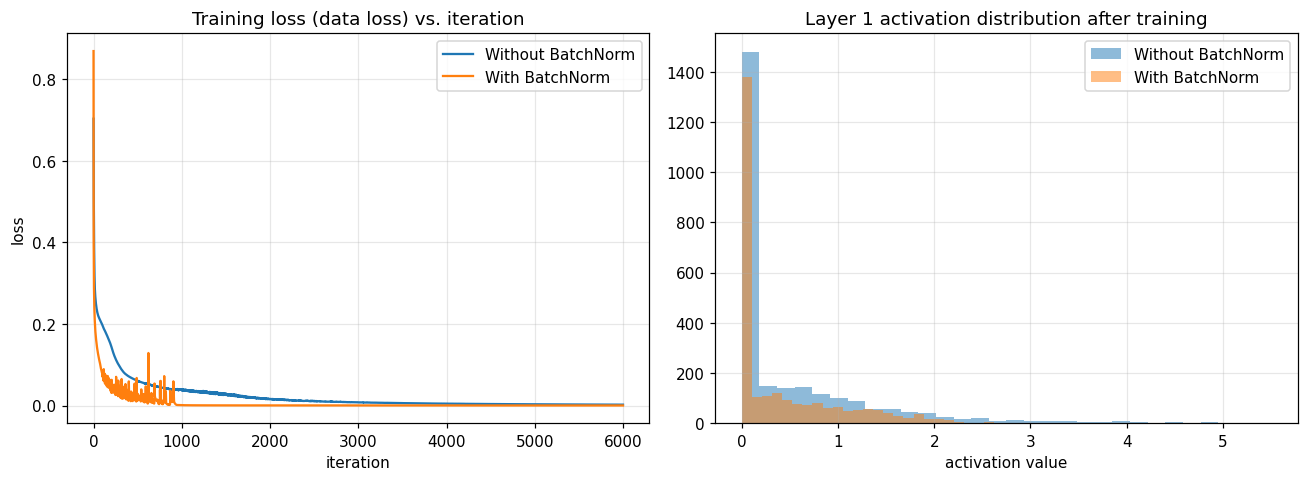

In [274]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for label, result_bn in bn_experiment_results.items():
    axes[0].plot(result_bn["loss_history"], label=label)
axes[0].set_title("Training loss (data loss) vs. iteration")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("loss"); axes[0].legend()

for label, use_bn in [("Without BatchNorm", False), ("With BatchNorm", True)]:
    result_bn = bn_experiment_results[label]
    _, cache_bn = rl.forward_regularized_network(X_train, result_bn["params"], [2, 32, 32, 1],
                                                    use_batchnorm=use_bn, bn_state=result_bn["bn_state"], training=True)
    axes[1].hist(cache_bn["A1"].flatten(), bins=30, alpha=0.5, label=label)
axes[1].set_title("Layer 1 activation distribution after training")
axes[1].set_xlabel("activation value"); axes[1].legend()
plt.tight_layout()
plt.savefig("../figures/61_batchnorm_experiment.png", dpi=110, bbox_inches="tight")
plt.show()

In this experiment, adding BatchNorm reduced validation loss (0.908 to 0.672) and slightly improved validation accuracy (0.925 to 0.950) while training accuracy remained at 1.0 for both - a specific, measured outcome for this architecture, dataset, and hyperparameter choice. This is not evidence that BatchNorm always improves accuracy in general; its effect depends on the architecture, data, batch size, initialization, and optimizer, as stated at the outset of this section.

## 12.13 Controlled Dropout Experiments

Same architecture/dataset/optimizer/learning-rate/iterations as Section
12.12, no BatchNorm - only the dropout rate changes ($p=0.0,\ 0.2,\ 0.5$).

In [275]:
dropout_experiment_rows = []
dropout_experiment_curves = {}
for p in [0.0, 0.2, 0.5]:
    result_do = rl.train_regularized_network(X_train, y_train, [2, 32, 32, 1], learning_rate=0.3,
                                               iterations=6000, use_batchnorm=False, dropout_rate=p, seed=42)
    train_loss_do = rl.evaluate_loss_regularized(X_train, y_train, result_do["params"], [2, 32, 32, 1], False, None)
    val_loss_do = rl.evaluate_loss_regularized(X_val, y_val, result_do["params"], [2, 32, 32, 1], False, None)
    train_acc_do = np.mean(rl.predict_regularized(X_train, result_do["params"], [2, 32, 32, 1], False, None) == y_train)
    val_acc_do = np.mean(rl.predict_regularized(X_val, result_do["params"], [2, 32, 32, 1], False, None) == y_val)
    dropout_experiment_curves[f"p={p}"] = result_do["loss_history"]
    dropout_experiment_rows.append({"Dropout Rate": p, "Train Loss": train_loss_do, "Val Loss": val_loss_do,
                                      "Train Acc": train_acc_do, "Val Acc": val_acc_do,
                                      "Gap (Val - Train Loss)": val_loss_do - train_loss_do})
    assert np.isfinite(train_loss_do) and np.isfinite(val_loss_do)

dropout_experiment_table = pd.DataFrame(dropout_experiment_rows)
dropout_experiment_table

   Dropout Rate  Train Loss  ...  Val Acc  Gap (Val - Train Loss)
0           0.0    0.002060  ...    0.925                0.905940
1           0.2    0.012388  ...    0.875                1.474948
2           0.5    0.029258  ...    0.875                1.461803

[3 rows x 6 columns]

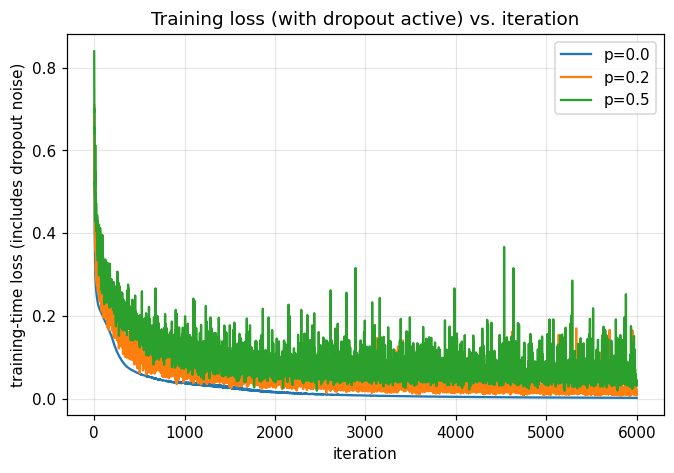

In [276]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, curve in dropout_experiment_curves.items():
    ax.plot(curve, label=label)
ax.set_title("Training loss (with dropout active) vs. iteration")
ax.set_xlabel("iteration"); ax.set_ylabel("training-time loss (includes dropout noise)")
ax.legend()
plt.savefig("../figures/62_dropout_training_curves.png", dpi=110, bbox_inches="tight")
plt.show()

In this experiment, increasing dropout did **not** improve validation performance: $p=0$ reached the lowest validation loss (0.908) and highest validation accuracy (0.925), while $p=0.2$ and $p=0.5$ both had higher validation loss (~1.49) and lower validation accuracy (0.875). Connecting to Part 9: the generalization gap (val loss - train loss) actually *increased* with dropout here, rather than decreasing - a direct counterexample, in this specific setting, to any assumption that more dropout necessarily improves generalization. This may relate to this architecture, dataset size, or learning rate not being well matched to these dropout rates; the honest conclusion from this controlled experiment is that dropout did not help here, not that dropout is ineffective in general.

## 12.14 Regularization Interaction Experiments

Same architecture/dataset/optimizer/learning-rate/iterations again - now
varying **L2 strength and dropout rate together**: none, L2 only,
dropout only, and both combined.

In [277]:
interaction_configs = [("None", 0.0, 0.0), ("L2 only", 0.001, 0.0),
                        ("Dropout only", 0.0, 0.3), ("L2 + Dropout", 0.001, 0.3)]
interaction_rows = []
for label, l2_lambda, p in interaction_configs:
    result_int = rl.train_regularized_network(X_train, y_train, [2, 32, 32, 1], learning_rate=0.3,
                                                 iterations=6000, use_batchnorm=False,
                                                 dropout_rate=p, l2_lambda=l2_lambda, seed=42)
    train_loss_int = rl.evaluate_loss_regularized(X_train, y_train, result_int["params"], [2, 32, 32, 1], False, None)
    val_loss_int = rl.evaluate_loss_regularized(X_val, y_val, result_int["params"], [2, 32, 32, 1], False, None)
    train_acc_int = np.mean(rl.predict_regularized(X_train, result_int["params"], [2, 32, 32, 1], False, None) == y_train)
    val_acc_int = np.mean(rl.predict_regularized(X_val, result_int["params"], [2, 32, 32, 1], False, None) == y_val)
    n_params_int = sum(v.size for v in result_int["params"].values())
    interaction_rows.append({"Configuration": label, "L2 Lambda": l2_lambda, "Dropout Rate": p,
                               "Parameters": n_params_int, "Train Loss": train_loss_int, "Val Loss": val_loss_int,
                               "Train Acc": train_acc_int, "Val Acc": val_acc_int})
    assert np.isfinite(train_loss_int) and np.isfinite(val_loss_int)

interaction_table = pd.DataFrame(interaction_rows)
interaction_table

  Configuration  L2 Lambda  Dropout Rate  ...  Val Loss  Train Acc  Val Acc
0          None      0.000           0.0  ...  0.908000     1.0000    0.925
1       L2 only      0.001           0.0  ...  0.323330     0.9875    0.925
2  Dropout only      0.000           0.3  ...  1.509161     0.9875    0.875
3  L2 + Dropout      0.001           0.3  ...  0.405655     0.9875    0.850

[4 rows x 8 columns]

In this controlled experiment: L2 alone achieved the lowest validation
loss (0.323) among all four configurations, clearly improving on the
unregularized baseline (0.908). Dropout alone performed *worse* than the
baseline (1.509). Combining L2 and dropout (0.406) landed between L2-only
and dropout-only, but did not match L2-only's result - here, the two
regularizers' effects were not complementary: adding dropout on top of
L2 did not help, and if anything the combination underperformed L2 by
itself. This is a specific, measured outcome for this dataset and
architecture, not a general statement about how L1/L2 and dropout
interact - the same combination could behave differently on a different
task, larger dataset, or different hyperparameter settings.

## 12.15 Computational Perspective and Summary

**Batch normalization**: for batch size $m$ and feature dimension $d$,
computing the mean, variance, normalization, and the affine
scale/shift are each $O(md)$; backward propagation is of comparable
order. **Dropout**: mask generation and elementwise multiplication cost
$O(n)$ for $n$ activations. Both add modest memory for storing dropout
masks, BatchNorm's cached intermediate values (needed for its backward
pass), and running statistics (2 extra values per feature) - small
relative to the parameters and activations already being stored (Part
11's memory discussion), but not free. This project does not report
exact wall-clock timings, since these depend on hardware and
implementation details outside this notebook's scope.

**Summary of this section's actual observations:**

1. Hidden activation statistics varied across the two layers examined (Section 12.2).
2. Standardization transforms feature distributions using batch statistics (Section 12.3).
3. BatchNorm introduces trainable scale ($\gamma$) and shift ($\beta$) parameters (Section 12.4).
4. BatchNorm requires different behavior during training (batch statistics) and inference (running statistics) (Section 12.7).
5. Running statistics, accumulated via a documented momentum convention, provide inference-time normalization (Section 12.7).
6. Dropout introduces stochastic masking during training (Section 12.8-12.9).
7. Inverted dropout's $1/(1-p)$ scaling preserves expected activation magnitude - derived mathematically and confirmed empirically (Sections 12.8, 12.10).
8. BatchNorm and dropout affect networks through different mechanisms (activation statistics vs. stochastic masking) (Section 12.11).
9. In this project's controlled experiment, L2 and dropout's effects were not complementary - L2 alone outperformed the combination (Section 12.14).
10. None of these mechanisms improved every measured outcome in every experiment here: BatchNorm helped validation performance in Section 12.12, while dropout did not in Section 12.13.

$$
\text{Input} \rightarrow \text{Deep Network} \rightarrow \text{Hidden Activations}
\rightarrow \text{Normalization / Stochastic Regularization} \rightarrow \text{Forward Propagation}
\rightarrow \text{Loss} \rightarrow \text{Backpropagation} \rightarrow \text{Parameter Updates}
\rightarrow \text{Generalization} \rightarrow \text{Evaluation}
$$

Part 12 investigated normalization and stochastic regularization in deep
fully connected neural networks using from-scratch mathematical and
computational implementations.